# FR3 — Structural Analysis and Five-Year Forecast of Average Monthly Wages in Azerbaijan

**Model:** AZWAGE-FR3
**Requirement:** Module 15.5.2, FR3 — *"Orta aylıq əmək haqqının (onların iqtisadiyyatın sahələri, dövlət və qeyri-dövlət
sektoru, büdcə və qeyri-büdcə təşkilatları, neft və qeyri-neft sektoru üzrə səviyyəsi və artım sürətləri) təhlili və
proqnozlaşdırılması"* — analysis and forecasting of the average monthly wage, its **level** and **growth rate**, broken down by
economic sector, state and non-state sector, budget and non-budget organisations, and oil and non-oil sector.

**Source:** `Statistik data dinamika 05.06.2026 +.xlsx`
**Actuals:** annual through **2025**; monthly through **February 2026** for every published wage series
**Forecast:** **2026–2030**, on the three macro scenarios produced by FR1

---

## What this notebook is, and what it deliberately is not

A **structural simultaneous-equation model of wage determination**. Every wage forecast comes from an economic relationship
linking that wage to productivity, prices, the minimum wage, fiscal capacity and *other sectors' wages*. Nothing is
extrapolated from its own past.

**No AR, ARIMA, ARCH or GARCH component appears anywhere.** No behavioural equation contains a lagged dependent variable;
uncertainty comes from a block bootstrap of structural residual vectors plus parameter and macro-driver draws (Part 15.3), not
from a variance model. Where lags or autoregressive
arithmetic appear they are flagged, and in each case the coefficient is imposed by accounting rather than fitted:
price levels cumulating estimated inflation rates, and the wage-bill and aggregation identities.

## The four required breakdowns do not nest — and that shapes the whole model

This is the first substantive finding, established in Part 4 and verified numerically:

| Breakdown | Structure | Verified |
|---|---|---|
| **State × non-state** | An **exact partition** of hired employees | Aggregate wage = employment-weighted average to **0.2%** |
| **Oil / non-oil** | **Cross-cutting** — oil firms are both state (SOCAR) and private (AIOC) | Adding it as a third group double-counts by **7–10%** |
| **Budget / non-budget** | A **sub-partition of the state sector**, only partly observable | Employment and contributions observed; the wage level must be inferred |
| **Economic sectors** | An **exact partition** of hired employees (8 DSK sectors) | Sector employment sums to the total **exactly** |

So the model cannot be a single hierarchical tree. It maintains **two independent exact aggregations** to the same national
average wage — one by institutional sector, one by economic sector — and requires them to reconcile.

## Revision note (2026-09-27)

This version implements an external review. What changed and why:

* **Second round (2026-09-28).** The hold-out now anchors exactly as the forecast does (own 2020 residual); long-run
  homogeneity is imposed in every forecasting equation on theory grounds (disclosed where rejected; unrestricted forms are
  sensitivities); the D18 break dummy is kept out of the baseline because it cannot be scored before 2018 (0.843 version is a
  sensitivity); Diebold–Mariano tests are overlap-robust (Bartlett HAC, h−1 lags); E1 is a cross-check, not a level constraint;
  fan charts use historical residual-path resampling (no estimated residual dynamics); a policy-lever coherence rule excludes
  the minimum wage from the private equation (wrong sign, a timing artefact of the 2018 reform).
* **Selection vs validation separated.** Every specification choice (drivers, homogeneity, the 2018 break dummy) is now made on
  data ending in 2020 — break and homogeneity tests on ≤2020 data and a rolling-origin forecast comparison (origins 2014–2016,
  scored to 2020, Diebold–Mariano/HLN). 2021–2025 is used only as the final hold-out, reported against a random walk **and**
  constant growth. The oil-wage check now validates the mechanism the forecast uses (non-oil wage × premium lever), and the
  wage bill is dropped from the validation table (its error equals the average-wage error by construction).
* **Estimation and tests (common contract).** Long-run coefficients by DOLS (leads/lags of regressor differences only) with a
  degrees-of-freedom rule; HAC with n/(n−k) scaling and t/F(n−k) inference; proper Engle–Granger p-values (MacKinnon); a
  difference-form comparison for every equation. No equation establishes cointegration, so t-statistics are labelled descriptive.
* **Homogeneity** is tested as the restriction the real form actually imposes (CPI + nominal minimum-wage/wage elasticities = 1),
  per equation, and reported; it is imposed in all forecasting equations on theory grounds (see second round above).
* **Private wage** is no longer regressed on the non-oil wage (near-tautological); it has its own fundamentals.
* **Minimum wage:** removed from the instrument set, tested for endogeneity with the lagged decree level as instrument (DWH),
  a 2018 break dummy/test added, elasticities reported as a range, and its exclusion from the private equation re-decided on
  forecasting evidence.
* **Aggregation:** both breakdowns (state × private and oil × non-oil) are reconciled jointly by weighted least squares over the
  component equations, so both identities hold exactly; E1 is a cross-check; adjustment factors are reported.
* **Nowcast:** multi-year seasonal ratio with a backtest error band; its increment decays with a one-year half-life.
* **Hired employment:** wedge calibrated on 2021–23 and validated on 2024–25; history spliced to the DVX level (no wage-bill jump).
* **Panels:** true between estimator; Driscoll–Kraay bandwidth floor(T^¼) and t(T−1) inference.
* **Non-oil productivity** now divides by non-oil employment. **Fan charts** implemented (Part 15.3, `FR3_fan_wages.csv`).

## An honest statement of scope, up front

FR3 asks for wages by economic sector. The workbook publishes average wages for the **aggregate**, **oil/non-oil**,
**state/private**, and for **29 industrial sub-branches (27 with value added)** — but **not** for agriculture, construction, trade, tourism,
transport, ICT or other services. Part 11 documents two serious attempts to derive them and why both fail, with the numbers:

* value added per hired worker over-predicts the industry wage by **25–42%**, because industrial value added is largely
  resource **rent** rather than labour productivity;
* the same method makes **agriculture the highest-paid sector in the economy (about 1.4× the average)**, because only 50 of roughly
  1,000 thousand agricultural workers are *hired* — the output is produced by the self-employed.

Publishing a forecast built on that would be indefensible. What this notebook delivers instead for the sector dimension is:
**industry at 2-digit level (29 branches with actual wages)**, a full forecast of **sector employment composition** for all eight
sectors, and the quantified contribution of that composition to aggregate wage growth. The precise missing series is named in
Part 20.

### Roadmap

| Part | Content |
|---|---|
| 1 | Configuration and the data layer |
| 2 | The wage and employment variable map |
| 3 | Employment concepts: total employed vs **hired employees** — a 2.5× wedge that matters |
| 4 | How the four breakdowns nest, and the aggregation identities |
| 5 | Estimation toolkit (identical to FR1, revalidated here) |
| 6 | Stylised facts: premia, convergence, the minimum-wage bite |
| 7 | Panel block I — industrial sub-branches |
| 8 | Panel block II — 14 economic regions |
| 9 | Structural wage equations, block by block |
| 10 | Specifications that failed, with the numbers |
| 11 | Sector wages: two derivations attempted, both rejected |
| 12 | System estimation and diagnostics |
| 13 | Solver, joint reconciliation and dynamic ex-post hold-out validation |
| 14 | Nowcasting 2026 from monthly actuals |
| 15 | Scenarios, the 2026–2030 forecast and fan charts |
| 16 | Decomposition: within-sector wage growth vs between-sector reallocation |
| 17 | Complete wage accounts: level, growth, real level, real growth, wage bill |
| 18 | Budget vs non-budget organisations |
| 19 | Export |
| 20 | Limitations |

## Part 1 — Configuration and the data layer

FR3 reads the workbook directly for its wage and employment series, and reads **FR1's exported scenarios** for the macro
drivers (sector value added, prices, employment, fiscal aggregates). That dependency is deliberate: the Ministry should have
**one** macro scenario across the functional modules, not a different one per module. The minimum wage is the exception — it is
a wage-policy instrument, so FR3 owns it and sets its own paths.

In [1]:
import os, re, sys, math, warnings, unicodedata, itertools
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220, 'display.max_columns', 90,
              'display.float_format', lambda v: f'{v:,.3f}')
np.set_printoptions(suppress=True, linewidth=200)

XL       = Path("/Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/data/"
                "Statistik data dinamika 05.06.2026 +.xlsx")
FR1DIR   = XL.parent.parent / "output"          # FR1's exported scenarios and dataset
OUTDIR   = XL.parent.parent / "output"; OUTDIR.mkdir(exist_ok=True)
BASE_YEAR = 2015
LAST_ACT  = 2025
NOWCAST_Y = 2026
H_END     = 2030
SEED      = 20260605

assert XL.exists(), f"workbook not found: {XL}"
FR1_FC   = FR1DIR/'FR1_forecast_full.csv'
FR1_DATA = FR1DIR/'FR1_analysis_dataset.csv'
FR1_RAW  = FR1DIR/'FR1_annual_raw.csv'
for p in (FR1_FC, FR1_DATA, FR1_RAW):
    assert p.exists(), (f"FR1 output missing: {p.name}. Run FR1.ipynb first - FR3 uses FR1's "
                        f"macro scenarios so that both modules share one consistent projection.")
# Cross-module contract: FR1 exports baseline bootstrap replications (FR1_fan_draws.csv) and a
# population column. FR3 uses the draws for its fan charts so that macro-driver uncertainty
# propagates; FR3 itself has no population assumption (no FR3 equation uses population).
FR1_DRAWS = FR1DIR/'FR1_fan_draws.csv'
if not FR1_DRAWS.exists():
    print("WARNING: FR1_fan_draws.csv not found - FR1 has not been re-run under the revised contract. "
          "FR3 fan charts will hold the macro drivers at FR1's baseline (no macro-driver uncertainty).")
N_BOOT = 1000                                   # bootstrap replications for the fan charts
print("workbook      :", XL.name)
print("FR1 scenarios :", FR1_FC.name)
print("forecast      :", NOWCAST_Y, "->", H_END)

PAL = ['#2B5D8A', '#C2543D', '#4E8C6E', '#B08A2E', '#6B5B95', '#3D8C99',
       '#8C5A3D', '#7A8C3D', '#993D6B', '#5A6B7A', '#C98A5A', '#3D5A8C']
mpl.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.prop_cycle': mpl.cycler(color=PAL), 'figure.facecolor': 'white'})

workbook      : Statistik data dinamika 05.06.2026 +.xlsx
FR1 scenarios : FR1_forecast_full.csv
forecast      : 2026 -> 2030


### 1.1 Workbook parsing

The parser is the same as FR1's, including the two Azerbaijani casing traps. It matters again here because several wage rows
are matched by label: `"İ".lower()` returns `i` + U+0307 rather than `"i"`, while `"I".lower()` returns `i` rather than the
dotless `ı`, so only the combining-dot case may be folded.

One new feature matters for FR3. For **stock and average variables** — which is what a wage is — the workbook's monthly columns
hold the **cumulative-period average**, not a cumulated flow. `2026 yanvar-fevral` for the average wage is the mean wage over
January–February, and the annual figure exceeds the January–November average because of December bonuses. The nowcast in Part 14
uses this correctly.

In [2]:
import openpyxl

MONTHS = {'yanvar':1,'fevral':2,'mart':3,'aprel':4,'may':5,'iyun':6,
          'iyul':7,'avqust':8,'sentyabr':9,'oktyabr':10,'noyabr':11,'dekabr':12}

def az_lower(s):
    '''Lower-case that survives Azerbaijani dotted capital I.
    Only the combining-dot case is folded: dotless i (U+0131) is left alone, because folding it
    would break matching against literals such as buraxılış, sayı or balıqçılıq.'''
    return str(s).lower().replace('i̇', 'i')

def clean(s):
    return re.sub(r'\s+', ' ', str(s).replace('\n', ' ')).strip()

def parse_header(h):
    if h is None: return None
    s = clean(h)
    if re.fullmatch(r'(19|20)\d\d(\s*-ci il)?', s): return (int(s[:4]), 12, 'A')
    ym = re.search(r'(19|20)\d\d', s)
    if not ym: return None
    year, low = int(ym.group(0)), az_lower(s)
    hits = [(low.rfind(k), v) for k, v in MONTHS.items() if k in low]
    if hits: return (year, max(hits)[1], 'YTD')
    q = re.search(r'\(\s*([ivx]+)\s*rüb', low)
    if q: return (year, {'i':3,'ii':6,'iii':9,'iv':12}.get(q.group(1), 12), 'YTD')
    return None

def to_num(v):
    if v is None or isinstance(v, bool): return np.nan
    if isinstance(v, (int, float)): return float(v)
    s = str(v).strip().replace('\xa0','').replace(' ','').replace(' ','').replace('%','')
    if s in ('', '-', '–', '—', 'n/a', 'N/A', '...', '..', 'x'): return np.nan
    if   re.fullmatch(r'-?\d{1,3}(\.\d{3})+,\d+', s): s = s.replace('.','').replace(',','.')
    elif re.fullmatch(r'-?\d{1,3}(,\d{3})+\.\d+', s): s = s.replace(',','')
    elif re.fullmatch(r'-?\d+,\d+', s):               s = s.replace(',','.')
    else:                                             s = s.replace(',','')
    try:    return float(s)
    except ValueError: return np.nan

for k, want in {'2019':(2019,12,'A'), '2026 yanvar-fevral':(2026,2,'YTD'), 'Mənbə':None}.items():
    assert parse_header(k) == want, f"header parse failed on {k!r}"
assert to_num('1 234,5') == 1234.5 and np.isnan(to_num('-'))
assert az_lower('İqtisadiyyatda').startswith('iqtisadiyyatda')
assert 'sayı' in az_lower('Əhalinin sayı')
print("parser self-tests passed")

WB = openpyxl.load_workbook(XL, read_only=True, data_only=True)

def sheet_matrix(ws):
    n = ws.max_column
    return [list(r) + [None]*(n-len(r))
            for r in ws.iter_rows(min_row=1, max_row=ws.max_row, max_col=n, values_only=True)]

def find_header_row(mat, scan=4):
    best = (0, 0)
    for i in range(min(scan, len(mat))):
        c = sum(1 for v in mat[i] if parse_header(v))
        if c > best[0]: best = (c, i)
    return best[1]

_CACHE = {}
def sheet_parsed(sh):
    if sh not in _CACHE:
        mat = sheet_matrix(WB[sh]); h = find_header_row(mat)
        per = [(j, parse_header(mat[h][j])) for j in range(len(mat[h]))]
        _CACHE[sh] = (mat, h, [(j, p) for j, p in per if p])
    return _CACHE[sh]

def row_series(sh, rn, kind='A'):
    '''Annual series (kind='A') or monthly cumulative-period series (kind='YTD') for one row.'''
    mat, h, per = sheet_parsed(sh)
    assert rn <= len(mat), f"{sh}: row {rn} beyond sheet"
    row = mat[rn-1]
    if kind == 'A':
        return pd.Series({p[0]: to_num(row[j]) for j, p in per if p[2] == 'A'}).dropna().sort_index()
    return pd.Series({(p[0], p[1]): to_num(row[j]) for j, p in per if p[2] == 'YTD'}).dropna().sort_index()

def row_label(sh, rn):
    mat, _, _ = sheet_parsed(sh)
    row = mat[rn-1]
    return next((clean(row[c]) for c in (0,1,2) if row[c] is not None and clean(row[c])), '')

print(f"{len(WB.sheetnames)} sheets loaded")

parser self-tests passed


41 sheets loaded


## Part 2 — The wage and employment variable map

Every series is addressed by **(sheet, row)** and asserted against its expected label, exactly as in FR1: labels repeat across
blocks, so only the address is unambiguous, and a future row insertion then fails loudly instead of silently modelling the wrong
series.

Three sources are combined, and they measure genuinely different populations, which is why each is labelled by source:

| Source | What it gives FR3 | Sample |
|---|---|---|
| **DSK** (Sosial sektor) | Published average monthly wage: total, oil, non-oil, state, private; minimum wage; subsistence minimum; pensions | 1995/2000/2005–2025, **monthly to Feb 2026** |
| **DVX** (State Tax Service) | Hired employment by **economic sector** and by **state / non-state / oil**; total wage fund; budget-organisation employment and social contributions | 2021–2025 |
| **Industry sheets** | Average wage **and** headcount for 27 industrial sub-branches | 2016–2025 |
| **Regional sheets** | Average wage and hired employment for 14 economic regions | 2021–2025 |

In [3]:
S_, V_, F_ = 'Sosial sektor ', 'DVX üzrə göstəricilər', 'Fiskal sektor'

# name : (sheet, row, expected label fragment)
WAGEMAP = {
 # ---- DSK published wages (the headline series FR3 must forecast)
 'w_avg'    : (S_, 52, 'orta aylıq nominal əmək haqqı'),
 'w_oil'    : (S_, 53, 'Neft-qaz sektorunda'),
 'w_non'    : (S_, 54, 'Qeyri neft-qaz sektorunda'),
 'w_state'  : (S_, 55, 'Dövlət sektorunda'),
 'w_priv'   : (S_, 56, 'Özəl sektorda'),
 'minwage'  : (S_, 51, 'Minimum əmək haqqı'),
 # ---- labour market and reservation-wage variables
 'lf'       : (S_, 58, 'İqtisadi fəal əhalinin sayı'),
 'emp_tot'  : (S_, 59, 'Məşğul əhalinin sayı'),
 'unemp'    : (S_, 65, 'İşsizlik səviyyəsi'),
 'newjobs'  : (S_, 67, 'Yeni iş yerlərinin sayı'),
 'subsist'  : (S_, 69, 'Yaşayış minimumu'),
 'pension'  : (S_, 71, 'Orta aylıq pensiya'),
 'comp_emp' : (S_, 41, 'işçilərə əmək ödənişləri'),
 'hhinc'    : (S_, 35, 'Əhalinin nominal gəlirlərin'),
 # ---- DVX: hired employment by economic sector (an exact partition)
 'e_tot'    : (V_, 91, 'Cəmi əmək müqavilələri'),
 'e_oil'    : (V_, 92, 'Neft sektoru'),
 'e_state'  : (V_, 93, 'Dövlət'),
 'e_nonstate':(V_, 94, 'Qeyri dövlət'),
 'e_ind'    : (V_, 95, 'Sənaye üzrə əmək müqavilələrinin sayı'),
 'e_indnon' : (V_, 96, 'qeyri neft-qaz sənayesi üzrə'),
 'e_agr'    : (V_, 97, 'Kənd təsərrüfatı üzrə'),
 'e_con'    : (V_, 98, 'Tikinti üzrə'),
 'e_trd'    : (V_, 99, 'Ticarət üzrə'),
 'e_tou'    : (V_,100, 'Turizm və ictimai iaşə üzrə'),
 'e_tra'    : (V_,101, 'Nəqliyyat və anbar təsərrüfatı üzrə'),
 'e_ict'    : (V_,102, 'İnformasiya və rabitə üzrə'),
 'e_oth'    : (V_,103, 'Sosial və digər xidmətlər üzrə'),
 # ---- DVX: wage fund and tax-record wage
 'wf_tot'   : (V_,104, 'Cəmi əmək haqqı fondu'),
 'wf_non'   : (V_,105, 'Qeyri-neft qaz sektorunda cəmi əmək haqqı fondu'),
 'wf_nonstate':(V_,106,'Qeyri-neft qeyri-dövlət bölməsində'),
 'hired_dvx': (V_,107, 'Muzdla işləyənlərin sayı'),
 'w_dvx'    : (V_,108, 'Orta aylıq əmək haqqı'),
 'hired_non_dvx':(V_,109,'Qeyri-neft qaz sektorunda muzdla işləyənlərin sayı'),
 'w_non_dvx': (V_,110, 'Qeyri-neft qaz sektorunda orta aylıq əmək haqqı'),
 # ---- budget vs non-budget organisations
 'e_budget' : (V_,130, 'Büdcə təşkilatları üzrə işçi sayı'),
 'si_tot'   : (V_, 26, 'Məcburi dövlət sosial sığortası üzrə daxilolma'),
 'si_budget': (V_, 27, 'Büdcə təşkilatları üzrə'),
 'si_nonbud': (V_, 28, 'Qeyri-büdcə təşkilatları üzrə'),
 'mi_tot'   : (V_, 37, 'İcbari tibbi sığorta haqları üzrə daxilolma'),
 'mi_budget': (V_, 38, 'Büdcə təşkilatları üzrə'),
 'mi_nonbud': (V_, 39, 'Qeyri-büdcə təşkilatları üzrə'),
 'ui_budget': (V_, 33, 'Büdcə təşkilatları üzrə'),
 'ui_nonbud': (V_, 34, 'Qeyri-büdcə təşkilatları üzrə'),
 'tax_wage' : (V_, 71, 'muzdlu işlə əlaqədar gəlir vergisi'),
 # ---- fiscal wage lines (the budget's own economic-classification pay items)
 'fisc_w_staff'  : (F_, 94, '211100'),
 'fisc_w_nonstaff':(F_, 95, '211200'),
 'fisc_w_other'  : (F_, 97, '211900'),
 'fisc_si'       : (F_, 98, '212100'),
 'fisc_edu'      : (F_, 36, '400 Təhsil'),
 'fisc_health'   : (F_, 45, '500 Səhiyyə'),
}

ANN, MON, AUD = {}, {}, []
for k, (sh, rn, frag) in WAGEMAP.items():
    lab = row_label(sh, rn)
    ok = az_lower(frag).replace(' ','') in az_lower(lab).replace(' ','')
    AUD.append(dict(name=k, sheet=sh, row=rn, expected=frag, found=lab[:60], ok=ok))
    ANN[k] = row_series(sh, rn, 'A')
    MON[k] = row_series(sh, rn, 'YTD')
AUD = pd.DataFrame(AUD)
bad = AUD[~AUD.ok]
print(f"variables mapped: {len(AUD)};  label mismatches: {len(bad)}")
if len(bad):
    display(bad); raise AssertionError("variable map out of sync with the workbook")
W = pd.DataFrame(ANN); W.index.name = 'year'
print(f"annual frame: {W.shape[0]} years x {W.shape[1]} variables")
cov = pd.DataFrame({'n': W.notna().sum(),
                    'first': W.apply(lambda s: s.dropna().index.min()),
                    'last':  W.apply(lambda s: s.dropna().index.max())})
display(cov.sort_values('n'))

variables mapped: 50;  label mismatches: 0
annual frame: 31 years x 50 variables


,n,first,last
e_budget,4,2022,2025
e_tra,5,2021,2025
w_dvx,5,2021,2025
hired_dvx,5,2021,2025
wf_nonstate,5,2021,2025
wf_non,5,2021,2025
wf_tot,5,2021,2025
e_oth,5,2021,2025
e_ict,5,2021,2025
e_tou,5,2021,2025


### 2.1 The FR1 macro drivers

Sector value added, prices, employment and fiscal aggregates come from FR1, for history and for all three scenarios, so the two
modules rest on one projection.

In [4]:
D1   = pd.read_csv(FR1_DATA, index_col=0)     # FR1 analysis dataset (history)
A1   = pd.read_csv(FR1_RAW,  index_col=0)     # FR1 raw annual (history)
FC1  = pd.read_csv(FR1_FC,   index_col=0)     # FR1 forecasts, all scenarios
SCEN_NAMES = list(FC1.scenario.unique())
FY = sorted(FC1[FC1.scenario == SCEN_NAMES[0]].index.astype(int).tolist())
print("FR1 scenarios :", SCEN_NAMES)
print("forecast years:", FY)
SECT = ['agr','min','man','elc','wat','con','trd','tou','tra','ict','oth']
DRIVERS = ['cpi','p_gdp','rgdp','rgdpnon','rgdpoil','rexp_cur','emp','lf','unemp','infl',
           'rhhdisp','wage'] + [f'rva_{s}' for s in SECT] + [f'p_{s}' for s in SECT]
missing = [c for c in DRIVERS if c not in FC1.columns or c not in D1.columns]
assert not missing, f"FR1 driver columns missing: {missing}"
print(f"{len(DRIVERS)} macro drivers available for history and all scenarios")

# cross-check: FR1's own wage series must equal the DSK series read here
chk = pd.DataFrame({'FR3 (from workbook)': W.w_avg, 'FR1 (exported)': D1.wage}).dropna()
chk['diff'] = chk.iloc[:,0] - chk.iloc[:,1]
assert chk['diff'].abs().max() < 1e-6, "FR1 and FR3 disagree on the average wage series"
print(f"cross-check passed: FR1 and FR3 read the identical wage series "
      f"({len(chk)} years, max difference {chk['diff'].abs().max():.2e})")

FR1 scenarios : ['Baseline', 'Adverse', 'Reform']
forecast years: [2026, 2027, 2028, 2029, 2030]
34 macro drivers available for history and all scenarios
cross-check passed: FR1 and FR3 read the identical wage series (31 years, max difference 0.00e+00)


## Part 3 — Employment concepts: a 2.5× wedge that has to be handled

A wage is paid to a **hired employee** (*muzdla çalışan*). The workbook also reports **total employed persons**
(*məşğul əhali*), which includes the self-employed and unpaid family workers. In Azerbaijan the two differ enormously:
about **2.06 million** hired employees against **5.11 million** employed persons in 2025 — the hired share is only ~40%,
because agriculture and much of retail is self-employed.

This matters in three separate places, and getting it wrong silently corrupts each:

1. **The wage bill.** `wage × total employed × 12` gives 67.6 bn AZN for 2025 against a reported wage fund of 26.5 bn — an
   overstatement of 2.5×. Using hired employment gives 27.3 bn, within 2.8% of the tax-record figure.
2. **Labour productivity in the wage equation.** Output per *hired* worker and output per *employed person* grow at different
   rates, because the hired share has been rising (formalisation).
3. **Aggregation weights.** The employment-weighted average wage must be weighted by hired employees.

Hired employment is published only for 2021–2025 (DVX). For the estimation sample it is therefore **derived** from the national
accounts, with a wedge **calibrated on 2021–2023 and validated out of sample on 2024–2025**. Because the forecast starts from the
published DVX level, the historical series is then **spliced** to the DVX level (DVX itself for 2021–2025), so the wage bill has no
level break at the forecast origin.

In [5]:
# Derived hired employment: compensation of employees divided by the annual wage gives a
# hired-employment equivalent, which exceeds the true count because compensation also covers
# employers' social contributions and payments in kind. One wedge converts it.
# REVISION: the wedge is CALIBRATED on 2021-2023 only and VALIDATED out of sample on 2024-2025,
# so the reported error is not an in-sample fit statistic.
implied = W.comp_emp/(W.w_avg*12/1000)                 # thousand persons
ov = [y for y in W.index if np.isfinite(implied.get(y, np.nan))
      and np.isfinite(W.hired_dvx.get(y, np.nan))]
WEDGE_CAL, WEDGE_VAL = ov[:3], ov[3:]
WEDGE = float((implied.loc[WEDGE_CAL]/W.hired_dvx.loc[WEDGE_CAL]).mean())
W['hired_derived'] = implied/WEDGE
err = (W.hired_derived.loc[ov]/W.hired_dvx.loc[ov] - 1)*100
print(f"compensation-to-wage-bill wedge calibrated on {min(WEDGE_CAL)}-{max(WEDGE_CAL)}: {WEDGE:.4f}")
print(f"  (employers' social contributions plus in-kind pay; 22% statutory contribution alone "
      f"would give about 1.22)")
display(pd.DataFrame({'derived hired': W.hired_derived, 'DVX hired (published)': W.hired_dvx,
                      'error %': err, 'total employed': W.emp_tot,
                      'hired share of employed %': W.hired_derived/W.emp_tot*100})
        .loc[[2005, 2010, BASE_YEAR, 2020, 2021, 2022, 2023, 2024, LAST_ACT]].round(2))
HIRED_ERR_CAL = float(err.loc[WEDGE_CAL].abs().max()); HIRED_ERR_VAL = float(err.loc[WEDGE_VAL].abs().max())
print(f"max |error|, calibration years {min(WEDGE_CAL)}-{max(WEDGE_CAL)} (in sample)   : {HIRED_ERR_CAL:.2f}%")
print(f"max |error|, validation years {min(WEDGE_VAL)}-{max(WEDGE_VAL)} (out of sample): {HIRED_ERR_VAL:.2f}%")
assert err.abs().max() < 6, "derived hired-employment series does not track the published one"

# SPLICE. The forecast is built on the published DVX level (2025 = DVX), so the historical series
# must be on the same level, otherwise the wage bill jumps between 2025 (derived) and 2026 (DVX).
# History = DVX where published (2021-2025); before 2021 the derived series is ratio-spliced to the
# DVX level at the first overlap year, so pre-2021 growth rates are the derived series' own.
SPLICE_Y = min(ov)
W['hired'] = W.hired_derived*float(W.hired_dvx[SPLICE_Y]/W.hired_derived[SPLICE_Y])
W.loc[ov, 'hired'] = W.hired_dvx.loc[ov]
print(f"hired employment spliced to the DVX level at {SPLICE_Y} (factor "
      f"{float(W.hired_dvx[SPLICE_Y]/W.hired_derived[SPLICE_Y]):.4f}); {LAST_ACT} level = DVX "
      f"{W.hired[LAST_ACT]:,.1f} thousand, so the wage bill has no level break at the forecast origin")
print("\nwage bill, three ways (2025, mln AZN) - why the concept matters:")
wb_tab = pd.DataFrame({
 'wage x HIRED x 12':        [W.w_avg[LAST_ACT]*W.hired_dvx[LAST_ACT]*12/1000],
 'DVX reported wage fund':   [W.wf_tot[LAST_ACT]],
 'compensation of employees':[W.comp_emp[LAST_ACT]],
 'wage x TOTAL EMPLOYED x 12':[W.w_avg[LAST_ACT]*W.emp_tot[LAST_ACT]*12/1000]}, index=[LAST_ACT])
display(wb_tab.round(0).T.rename(columns={LAST_ACT: 'mln AZN'}))
print(f'''The first two agree to {abs(W.w_avg[LAST_ACT]*W.hired_dvx[LAST_ACT]*12/1000/W.wf_tot[LAST_ACT]-1)*100:.1f}%, which validates the concept.
Compensation of employees is larger because it adds employers' contributions and in-kind pay.
The last line is wrong by a factor of {W.emp_tot[LAST_ACT]/W.hired_dvx[LAST_ACT]:.2f} and is shown only to make the trap explicit.

NOTE FOR FR1: FR1's household-income equation uses a wage bill built on TOTAL employment. The
level is therefore overstated. Because the variable enters in logs, the error is absorbed by the
intercept and the estimated elasticity is affected only through the slow drift in the hired share,
so FR1's results stand - but the variable is mislabelled and should be rebuilt on hired employment
in the next revision.''')

compensation-to-wage-bill wedge calibrated on 2021-2023: 1.4523
  (employers' social contributions plus in-kind pay; 22% statutory contribution alone would give about 1.22)


,derived hired,DVX hired (published),error %,total employed,hired share of employed %
year,,,,,
2005,"1,378.120",NaN,NaN,"4,062.300",33.920
2010,"1,216.350",NaN,NaN,"4,329.100",28.100
2015,"1,356.420",NaN,NaN,"4,671.600",29.040
2020,"1,738.220",NaN,NaN,"4,721.200",36.820
2021,"1,782.340","1,807.620",-1.400,"4,831.100",36.890
2022,"1,893.310","1,865.130",1.510,"4,901.100",38.630
2023,"1,943.970","1,946.170",-0.110,"4,963.300",39.170
2024,"1,978.430","2,073.810",-4.600,"5,029.800",39.330
2025,"1,988.770","2,059.920",-3.450,"5,105.200",38.960


max |error|, calibration years 2021-2023 (in sample)   : 1.51%
max |error|, validation years 2024-2025 (out of sample): 4.60%
hired employment spliced to the DVX level at 2021 (factor 1.0142); 2025 level = DVX 2,059.9 thousand, so the wage bill has no level break at the forecast origin

wage bill, three ways (2025, mln AZN) - why the concept matters:


,mln AZN
wage x HIRED x 12,"27,263.000"
DVX reported wage fund,"26,527.000"
compensation of employees,"38,227.000"
wage x TOTAL EMPLOYED x 12,"67,566.000"


The first two agree to 2.8%, which validates the concept.
Compensation of employees is larger because it adds employers' contributions and in-kind pay.
The last line is wrong by a factor of 2.48 and is shown only to make the trap explicit.

NOTE FOR FR1: FR1's household-income equation uses a wage bill built on TOTAL employment. The
level is therefore overstated. Because the variable enters in logs, the error is absorbed by the
intercept and the estimated elasticity is affected only through the slow drift in the hired share,
so FR1's results stand - but the variable is mislabelled and should be rebuilt on hired employment
in the next revision.


## Part 4 — How the four required breakdowns nest, and the aggregation identities

FR3 names four breakdowns. Before modelling them it has to be established how they relate, because the answer determines
whether the model can be a single hierarchy or must carry two parallel aggregations. This is settled numerically, not assumed.

In [6]:
yrs = [y for y in W.index if np.isfinite(W.e_tot.get(y, np.nan))]
print("=== TEST 1: do the eight economic sectors partition hired employment exactly? ===")
SEC8 = ['ind','agr','con','trd','tou','tra','ict','oth']
s8 = sum(W[f'e_{k}'] for k in SEC8)
t1 = pd.DataFrame({'sum of 8 sectors': s8, 'reported total': W.e_tot,
                   'difference': s8 - W.e_tot}).loc[yrs]
display(t1.round(6))
assert t1['difference'].abs().max() < 1e-6
print("=> EXACT partition. The eight DSK sectors are mutually exclusive and exhaustive.\n")

print("=== TEST 2: do oil + state + non-state partition hired employment exactly? ===")
s3 = W.e_oil + W.e_state + W.e_nonstate
t2 = pd.DataFrame({'oil + state + non-state': s3, 'reported total': W.e_tot,
                   'difference': s3 - W.e_tot}).loc[yrs]
display(t2.round(6))
assert t2['difference'].abs().max() < 1e-6
print("=> also EXACT. But note what this means: in the EMPLOYMENT data the oil sector is carved")
print("   out, so 'state' and 'non-state' there cover only the NON-OIL economy.\n")

print("=== TEST 3: which partition reproduces the published average wage? ===")
# state x private, using the DSK wages with state/non-state employment weights
w_sp = (W.e_state*W.w_state + W.e_nonstate*W.w_priv)/(W.e_state + W.e_nonstate)
# oil / non-oil, using oil employment as the weight
w_on = (W.e_oil*W.w_oil + (W.e_tot - W.e_oil)*W.w_non)/W.e_tot
# a three-way attempt that treats oil as a separate group alongside state and private
w_3  = (W.e_oil*W.w_oil + W.e_state*W.w_state + W.e_nonstate*W.w_priv)/W.e_tot
t3 = pd.DataFrame({'published w_avg': W.w_avg,
                   'state x private': w_sp, 'error % (s x p)': (w_sp/W.w_avg-1)*100,
                   'oil / non-oil': w_on, 'error % (oil)': (w_on/W.w_avg-1)*100,
                   'three-way': w_3,   'error % (3-way)': (w_3/W.w_avg-1)*100}).loc[yrs]
display(t3.round(3))
print(f'''READING
  state x private  : max |error| {t3["error % (s x p)"].abs().max():.2f}%  -> an EXACT partition of employees
  oil / non-oil    : max |error| {t3["error % (oil)"].abs().max():.2f}%  -> close but not exact; the DSK oil/non-oil
                     wage split and the DVX oil employment count use different populations
  three-way        : max |error| {t3["error % (3-way)"].abs().max():.2f}%  -> DOUBLE COUNTS

The three-way failure is the informative one. Oil companies are BOTH state (SOCAR) and private
(the AIOC consortium), so "oil" is not a third institutional group - it is a CROSS-CUTTING
classification. Adding it alongside state and private counts oil employees twice and, because
their wage is about 3.7x the average, inflates the implied mean by 7-10%.

CONSEQUENCE FOR THE MODEL: there is no single hierarchy. FR3 therefore maintains TWO independent
exact aggregations to the same national average wage -
    (a) by institution : state x non-state
    (b) by economic sector : the eight DSK sectors
and treats oil / non-oil as a cross-cutting dimension that must be reconciled with, not nested
inside, either. Budget / non-budget is a sub-partition of the state sector (Part 18).''')
AGG_SP_ERR = float(t3['error % (s x p)'].abs().max())

=== TEST 1: do the eight economic sectors partition hired employment exactly? ===


,sum of 8 sectors,reported total,difference
year,,,
2021,"1,684.797","1,684.797",0.000
2022,"1,746.309","1,746.309",0.000
2023,"1,808.779","1,808.779",0.000
2024,"1,872.863","1,872.863",0.000
2025,"1,895.378","1,895.378",0.000


=> EXACT partition. The eight DSK sectors are mutually exclusive and exhaustive.

=== TEST 2: do oil + state + non-state partition hired employment exactly? ===


,oil + state + non-state,reported total,difference
year,,,
2021,"1,684.797","1,684.797",0.000
2022,"1,746.309","1,746.309",0.000
2023,"1,808.779","1,808.779",0.000
2024,"1,872.863","1,872.863",-0.000
2025,"1,895.378","1,895.378",0.000


=> also EXACT. But note what this means: in the EMPLOYMENT data the oil sector is carved
   out, so 'state' and 'non-state' there cover only the NON-OIL economy.

=== TEST 3: which partition reproduces the published average wage? ===


,published w_avg,state x private,error % (s x p),oil / non-oil,error % (oil),three-way,error % (3-way)
year,,,,,,,
2021,732.100,734.176,0.284,759.106,3.689,808.143,10.387
2022,840.000,841.439,0.171,864.903,2.965,914.466,8.865
2023,933.900,935.768,0.200,958.620,2.647,"1,007.962",7.930
2024,"1,009.400","1,012.536",0.311,"1,034.479",2.485,"1,085.887",7.577
2025,"1,102.900","1,105.145",0.204,"1,123.496",1.867,"1,176.569",6.680


READING
  state x private  : max |error| 0.31%  -> an EXACT partition of employees
  oil / non-oil    : max |error| 3.69%  -> close but not exact; the DSK oil/non-oil
                     wage split and the DVX oil employment count use different populations
  three-way        : max |error| 10.39%  -> DOUBLE COUNTS

The three-way failure is the informative one. Oil companies are BOTH state (SOCAR) and private
(the AIOC consortium), so "oil" is not a third institutional group - it is a CROSS-CUTTING
classification. Adding it alongside state and private counts oil employees twice and, because
their wage is about 3.7x the average, inflates the implied mean by 7-10%.

CONSEQUENCE FOR THE MODEL: there is no single hierarchy. FR3 therefore maintains TWO independent
exact aggregations to the same national average wage -
    (a) by institution : state x non-state
    (b) by economic sector : the eight DSK sectors
and treats oil / non-oil as a cross-cutting dimension that must be reconciled with

In [7]:
print("=== TEST 4: wage-bill identity, and DSK against DVX ===")
t4 = pd.DataFrame({
 'wage bill from DSK wage x hired x 12': W.w_avg*W.hired_dvx*12/1000,
 'DVX reported wage fund':               W.wf_tot,
 'DSK average wage':                     W.w_avg,
 'DVX average wage (tax records)':       W.w_dvx}).loc[yrs]
t4['wage-bill error %'] = (t4.iloc[:,0]/t4.iloc[:,1]-1)*100
t4['wage-level gap %']  = (t4['DVX average wage (tax records)']/t4['DSK average wage']-1)*100
display(t4.round(2))
print('''The two sources differ by -4% to +2% on the average wage: DSK is an establishment survey,
DVX is administrative tax data, and they cover slightly different populations. FR3 forecasts the
DSK series, because it is the official wage statistic, has history back to 1995 and is the one with
monthly 2026 observations. DVX supplies the employment weights and serves as an independent check.''')

print("\n=== structure of hired employment and of the wage bill, 2025 ===")
SECLAB = {'ind':'Industry','agr':'Agriculture','con':'Construction','trd':'Trade',
          'tou':'Tourism & catering','tra':'Transport & storage','ict':'Information & communication',
          'oth':'Social & other services'}
st = pd.DataFrame({'hired employment (thousand)': [W[f'e_{k}'][LAST_ACT] for k in SEC8]},
                  index=[SECLAB[k] for k in SEC8])
st['share of employment %'] = st.iloc[:,0]/st.iloc[:,0].sum()*100
display(st.sort_values('share of employment %', ascending=False).round(2))
inst = pd.DataFrame({'thousand': [W.e_oil[LAST_ACT], W.e_state[LAST_ACT], W.e_nonstate[LAST_ACT]],
                     'average wage (AZN)': [W.w_oil[LAST_ACT], W.w_state[LAST_ACT], W.w_priv[LAST_ACT]]},
                    index=['Oil sector', 'State (non-oil)', 'Non-state (non-oil)'])
inst['share of employment %'] = inst.thousand/inst.thousand.sum()*100
inst['relative to national average'] = inst['average wage (AZN)']/W.w_avg[LAST_ACT]
display(inst.round(3))
print(f'''The oil sector is {inst.loc["Oil sector","share of employment %"]:.1f}% of hired employment but pays {inst.loc["Oil sector","relative to national average"]:.2f}x the average wage.
Social and other services - health, education, public administration - is {st.loc["Social & other services","share of employment %"]:.0f}% of hired
employment, so it dominates any aggregate wage movement through sheer weight.''')

=== TEST 4: wage-bill identity, and DSK against DVX ===


,wage bill from DSK wage x hired x 12,DVX reported wage fund,DSK average wage,DVX average wage (tax records),wage-bill error %,wage-level gap %
year,,,,,,
2021,"15,880.290","16,045.700",732.100,739.730,-1.030,1.040
2022,"18,800.510","19,127.600",840.000,854.610,-1.710,1.740
2023,"21,810.290","21,690.800",933.900,928.780,0.550,-0.550
2024,"25,119.670","24,081.100","1,009.400",967.670,4.310,-4.130
2025,"27,262.610","26,526.900","1,102.900","1,073.140",2.770,-2.700


The two sources differ by -4% to +2% on the average wage: DSK is an establishment survey,
DVX is administrative tax data, and they cover slightly different populations. FR3 forecasts the
DSK series, because it is the official wage statistic, has history back to 1995 and is the one with
monthly 2026 observations. DVX supplies the employment weights and serves as an independent check.

=== structure of hired employment and of the wage bill, 2025 ===


,hired employment (thousand),share of employment %
Social & other services,"1,008.500",53.210
Trade,308.300,16.270
Industry,196.760,10.380
Construction,120.240,6.340
Transport & storage,90.130,4.760
Tourism & catering,84.920,4.480
Agriculture,50.090,2.640
Information & communication,36.440,1.920


,thousand,average wage (AZN),share of employment %,relative to national average
Oil sector,47.777,"3,938.600",2.521,3.571
State (non-oil),815.935,"1,080.800",43.049,0.980
Non-state (non-oil),"1,031.666","1,124.400",54.431,1.019


The oil sector is 2.5% of hired employment but pays 3.57x the average wage.
Social and other services - health, education, public administration - is 53% of hired
employment, so it dominates any aggregate wage movement through sheer weight.


## Part 5 — Estimation toolkit

The estimators are **identical to FR1's**, reproduced here so that FR3 is self-contained, and **revalidated against
`statsmodels`** in this session rather than on trust. `linearmodels` is not installed in this environment, so OLS with HC/HAC
covariance, 2SLS, 3SLS, SUR, DOLS and two-way panel fixed effects with Driscoll–Kraay errors are implemented directly.

Common inference rules (shared with FR1/FR4/FR5): HAC (Newey–West, Bartlett) with the finite-sample scaling n/(n−k) and p-values
from t(n−k); multi-restriction tests as HAC-F(m, n−k); Engle–Granger p-values from the ADF statistic on the residuals mapped
through MacKinnon's response surface (not the plain ADF p-value); long-run relations by DOLS(±1) when the residual df stay ≥ 10,
DOLS(0) when ≥ 8, OLS otherwise; forecast comparisons by Diebold–Mariano with the Harvey–Leybourne–Newbold correction.

On the two constructs that involve lags: **HAC standard errors** correct inference only and never change a fitted value or a
forecast; **DOLS** augments a levels regression with leads and lags of the *differences of the regressors*, so the dependent
variable's own lags never enter — which is exactly why it is the cointegrating estimator compatible with this model's
no-autoregression rule.

In [8]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.adfvalues import mackinnonp

class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval},
                         index=self.names)
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in self.pval]
        return t.round(digits)
    def summary(self, title=''):
        out = [f"{title or self.kind}   n={self.n}  R2={self.r2:.4f}  adj={self.r2a:.4f}"]
        if getattr(self, 'extra', None): out.append("  " + self.extra)
        out.append(self.table().to_string())
        return "\n".join(out)
    def __repr__(self): return self.summary()

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_lags(n): return max(1, int(np.floor(4*(n/100)**(2/9))))

def hac_cov(X, u, XtXi, lags=None, small=True):
    '''Newey-West (Bartlett) HAC covariance with the finite-sample scaling n/(n-k) (contract
    decision 3). It corrects INFERENCE only; it never changes a fitted value or a forecast.'''
    n, k = X.shape
    if lags is None: lags = hac_lags(n)
    Xu = X * u[:, None]
    S = Xu.T @ Xu
    for L in range(1, lags+1):
        G = Xu[L:].T @ Xu[:-L]
        S += (1 - L/(lags+1)) * (G + G.T)
    V = XtXi @ S @ XtXi
    return V * (n/max(n-k, 1)) if small else V

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv)
    b = XtXi @ Xv.T @ yv
    u = yv - Xv @ b
    dof = max(n-k, 1)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags)
    elif cov == 'hac_nocorr': V = hac_cov(Xv, u, XtXi, lags, small=False)
    elif cov == 'hc1': V = XtXi @ ((Xv*u[:,None]).T @ (Xv*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    tss = ((yv-yv.mean())**2).sum() if add_const else (yv**2).sum()
    r2 = 1 - (u@u)/tss
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, X=Xv, y=yv, index=idx,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv@b, index=idx), sigma2=(u@u)/dof,
               dof=dof)

def tsls(y, X_endog, X_exog, Z, cov='hac', lags=None):
    '''2SLS for a structural equation. X_endog: jointly determined regressors;
    X_exog: included exogenous; Z: EXCLUDED instruments.
    Reports first-stage F (weak-instrument screen) and Sargan J (over-identification).'''
    En = list(X_endog.columns)
    Xn = [] if X_exog is None or X_exog.shape[1]==0 else list(X_exog.columns)
    Zn = list(Z.columns)
    parts = [p for p in (X_endog, X_exog, Z) if p is not None and p.shape[1] > 0]
    d = pd.concat([y.rename('__y__')] + parts, axis=1).dropna()
    yv = d['__y__'].to_numpy(float)
    E  = d[En].to_numpy(float)
    Xx = d[Xn].to_numpy(float) if Xn else np.empty((len(d), 0))
    Zz = d[Zn].to_numpy(float)
    one = np.ones((len(d), 1))
    W = np.column_stack([one, E, Xx])          # regressors
    I = np.column_stack([one, Xx, Zz])         # instrument set
    names = ['const'] + En + Xn
    n, k = W.shape
    if I.shape[1] < k:
        raise ValueError(f"under-identified: {I.shape[1]} instruments for {k} parameters")
    PiI = np.linalg.pinv(I.T @ I)
    Wh = I @ (PiI @ (I.T @ W))
    b = np.linalg.pinv(Wh.T @ W) @ (Wh.T @ yv)
    u = yv - W @ b
    dof = max(n-k, 1)
    XtXi = np.linalg.pinv(Wh.T @ Wh)
    if   cov == 'hac': V = hac_cov(Wh, u, XtXi, lags)
    elif cov == 'hc1': V = XtXi @ ((Wh*u[:,None]).T @ (Wh*u[:,None])) @ XtXi * n/dof
    else:              V = XtXi * (u@u)/dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b/se
    X0 = np.column_stack([one, Xx]); q = Zz.shape[1]
    fsF = {}
    for j, nm in enumerate(En):
        ru = E[:,j] - I @ (PiI @ (I.T @ E[:,j]))
        rr = E[:,j] - X0 @ (np.linalg.pinv(X0.T@X0) @ (X0.T @ E[:,j]))
        den = (ru@ru)/max(n-I.shape[1], 1)
        fsF[nm] = ((rr@rr - ru@ru)/q)/den if den > 0 else np.nan
    over = I.shape[1] - k
    if over > 0:
        uh = I @ (PiI @ (I.T @ u)); J = n*(uh@uh)/(u@u); Jp = 1-stats.chi2.cdf(J, over)
    else:
        J, Jp = np.nan, np.nan
    r2 = 1 - (u@u)/((yv-yv.mean())**2).sum()
    extra = ("first-stage F: " + ", ".join(f"{m}={v:.1f}" for m, v in fsF.items()) +
             (f" | Sargan J({over})={J:.2f} p={Jp:.3f}" if over > 0 else " | just-identified"))
    return Fit(kind=f'2SLS[{cov}]', beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, r2a=1-(1-r2)*(n-1)/dof, V=V, index=d.index,
               resid=pd.Series(u, index=d.index), fitted=pd.Series(W@b, index=d.index),
               first_stage_F=fsF, J=J, J_p=Jp, extra=extra, sigma2=(u@u)/dof, dof=dof)

def wald_F(fit, R, q):
    '''HAC-F: Wald statistic / m, referred to F(m, n-k). Also returns the standard error of the
    tested combination (single restriction) as a power proxy.'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q
    Vr = R @ fit.V @ R.T
    m = R.shape[0]
    Wst = float(d @ np.linalg.pinv(Vr) @ d)
    F = Wst/m
    p = 1 - stats.f.cdf(F, m, fit.dof)
    se_c = float(np.sqrt(Vr[0, 0])) if m == 1 else np.nan
    return F, p, se_c, float((R @ fit.beta)[0])

def restrict_row(fit, name, value=1.0):
    R = np.zeros(len(fit.beta)); R[fit.names.index(name)] = 1.0
    F, p, se, v = wald_F(fit, R, [value]); return F, p

def restrict_sum(fit, names, value=1.0):
    R = np.zeros(len(fit.beta))
    for nm in names: R[fit.names.index(nm)] = 1.0
    return wald_F(fit, R, [value])

def eg_coint_p(u, n_i1, trend=False):
    '''Residual-based Engle-Granger cointegration p-value: ADF t on the residuals (no
    deterministic terms in the auxiliary regression, maxlag 1 fixed) mapped through MacKinnon's
    response surface with N = number of I(1) variables in the relation.'''
    u = pd.Series(u).dropna().to_numpy(float)
    stat = adfuller(u, maxlag=1, regression='n', autolag=None)[0]
    return float(stat), float(mackinnonp(stat, regression='ct' if trend else 'c', N=n_i1))

def dols(y, X, det=None, leads=1, lags_=1, cov='hac'):
    '''Stock-Watson DOLS. Levels regression of y on the I(1) regressors X (and deterministic
    terms det) augmented with leads and lags of the DIFFERENCES OF THE REGRESSORS X only.
    The dependent variable's own lags never enter.'''
    aug = {}
    for c in X.columns:
        dx = X[c].diff()
        for L in range(-leads, lags_+1):
            aug[f'd_{c}_{"F" if L<0 else "L"}{abs(L)}' if L != 0 else f'd_{c}'] = dx.shift(L)
    parts = [X] + ([det] if det is not None and det.shape[1] else []) + [pd.DataFrame(aug, index=X.index)]
    Xa = pd.concat(parts, axis=1)
    f = ols(y, Xa, cov=cov)
    f.kind = f'DOLS[+-{leads}]'
    return f

def estimate_lr(y, X, det=None, cov='hac', force=None):
    '''Contract decision 2. Long-run (level) relation by DOLS: +-1 lead/lag of the regressor
    differences if the residual df stay >= 10; otherwise DOLS(0) (contemporaneous differences
    only, Saikkonen) if df >= 8; otherwise OLS with a note. `y` defines the estimation sample;
    X may extend before it, so the lagged differences use genuine pre-sample regressor data.
    force = 1 / 0 / 'ols' overrides the rule (used only for reporting alternatives).
    The LONG-RUN coefficients (levels part) are the ones used in forecasting.'''
    det = det if det is not None else pd.DataFrame(index=X.index)
    fit, est = None, None
    order = [1, 0, 'ols'] if force is None else [force]
    for ll in order:
        if ll == 'ols':
            fit = ols(y, pd.concat([X, det], axis=1), cov=cov); est = 'OLS (df too small for DOLS)'
            break
        f = dols(y, X, det, leads=ll, lags_=ll, cov=cov)
        if f.dof >= (10 if ll == 1 else 8) or force is not None:
            fit, est = f, (f'DOLS(+-{ll})' if ll else 'DOLS(0)'); break
    lr_names = ['const'] + list(X.columns) + list(det.columns)
    ix = [fit.names.index(c) for c in lr_names]
    fit.lr = pd.Series(fit.beta[ix], index=lr_names)
    fit.lr_se = pd.Series(fit.se[ix], index=lr_names)
    fit.lr_p = pd.Series(fit.pval[ix], index=lr_names)
    fit.lr_V = fit.V[np.ix_(ix, ix)]
    fit.estimator = est
    Xall = pd.concat([X, det], axis=1)
    lr_fit = fit.lr['const'] + (Xall[lr_names[1:]]*fit.lr[lr_names[1:]]).sum(axis=1, min_count=len(lr_names)-1)
    u = (y - lr_fit).dropna()
    fit.lr_resid = u                            # long-run (static) residual, whole available sample
    fit.n_i1 = X.shape[1] + 1
    return fit

def dm_hln(e1, e2, h=1):
    '''Diebold-Mariano on squared-error loss with the Harvey-Leybourne-Newbold small-sample
    correction; p from t(T-1). Positive statistic => model 1 has LARGER loss. h-1 Bartlett-weighted
    autocovariances make it robust to the serial correlation of overlapping multi-step errors.'''
    d = np.asarray(e1, float)**2 - np.asarray(e2, float)**2
    T = len(d); db = d.mean()
    g = [np.mean((d[k:]-db)*(d[:T-k]-db)) for k in range(h)]
    V = (g[0] + 2*sum((1 - k/h)*g[k] for k in range(1, h)))/T      # Bartlett HAC, h-1 lags
    if V <= 0: V = g[0]/T
    dm = db/np.sqrt(V)
    k = np.sqrt((T + 1 - 2*h + h*(h-1)/T)/T)
    s = dm*k
    return float(s), float(2*(1-stats.t.cdf(abs(s), T-1)))

def vif(X):
    Xd = X.dropna()
    out = {}
    for c in Xd.columns:
        rest = Xd.drop(columns=c)
        if rest.shape[1] == 0: out[c] = 1.0; continue
        r2 = ols(Xd[c], rest, cov='nonrobust').r2
        out[c] = np.inf if r2 >= 1 else 1/(1-r2)
    return pd.Series(out)
print("estimators defined: ols (HAC with n/(n-k) scaling, t(n-k) p-values), tsls, dols, estimate_lr (DOLS rule),\n"
      "                    wald_F (HAC-F), eg_coint_p (MacKinnon), dm_hln (Diebold-Mariano, HLN), vif")

estimators defined: ols (HAC with n/(n-k) scaling, t(n-k) p-values), tsls, dols, estimate_lr (DOLS rule),
                    wald_F (HAC-F), eg_coint_p (MacKinnon), dm_hln (Diebold-Mariano, HLN), vif


In [9]:
def sur(eqs, restrictions=None, iterate=3):
    '''Seemingly-unrelated regressions by feasible GLS.
    `restrictions` = (R, q) imposes R*beta = q exactly (used for adding-up in share systems).'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Y = [eqs[nm][0].loc[idx].to_numpy(float) for nm in names]
    Xs = [np.column_stack([np.ones(len(idx)), eqs[nm][1].loc[idx].to_numpy(float)]) for nm in names]
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y); Xb = np.zeros((n*m, sum(ks))); c = 0
    for i, x in enumerate(Xs):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = x; c += ks[i]
    b = np.linalg.pinv(Xb.T@Xb) @ Xb.T @ yb
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        Amat = Xb.T @ Om @ Xb; rhs = Xb.T @ Om @ yb
        if restrictions is not None:
            Rm, qv = restrictions
            KKT = np.block([[Amat, Rm.T], [Rm, np.zeros((Rm.shape[0], Rm.shape[0]))]])
            b = (np.linalg.pinv(KKT) @ np.concatenate([rhs, qv]))[:Amat.shape[0]]
        else:
            b = np.linalg.pinv(Amat) @ rhs
    V = np.linalg.pinv(Xb.T @ Om @ Xb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, c = {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; out[nm] = t; c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(U.T, index=idx, columns=names), U@U.T/n

def system_3sls(eqs, instruments, iterate=2):
    '''Three-stage least squares for a simultaneous structural system.
    Stage 1-2: project all regressors on the instrument set (2SLS).
    Stage 3: re-weight by the cross-equation error covariance for efficiency.'''
    names = list(eqs); idx = None
    for nm in names:
        y, X = eqs[nm]
        d = pd.concat([y, X, instruments], axis=1).dropna()
        idx = d.index if idx is None else idx.intersection(d.index)
    Z = np.column_stack([np.ones(len(idx)), instruments.loc[idx].to_numpy(float)])
    Pz = Z @ np.linalg.pinv(Z.T@Z) @ Z.T
    Y, Xs, Xh = [], [], []
    for nm in names:
        y, X = eqs[nm]
        Xv = np.column_stack([np.ones(len(idx)), X.loc[idx].to_numpy(float)])
        Y.append(y.loc[idx].to_numpy(float)); Xs.append(Xv); Xh.append(Pz @ Xv)
    n, m = len(idx), len(names); ks = [x.shape[1] for x in Xs]
    yb = np.concatenate(Y)
    Xb = np.zeros((n*m, sum(ks))); Hb = np.zeros((n*m, sum(ks))); c = 0
    for i in range(m):
        Xb[i*n:(i+1)*n, c:c+ks[i]] = Xs[i]; Hb[i*n:(i+1)*n, c:c+ks[i]] = Xh[i]; c += ks[i]
    b = np.linalg.pinv(Hb.T@Xb) @ (Hb.T@yb)
    Om = np.eye(n*m)
    for _ in range(iterate):
        U = (yb - Xb@b).reshape(m, n); S = U@U.T/n
        Om = np.kron(np.linalg.pinv(S), np.eye(n))
        b = np.linalg.pinv(Hb.T @ Om @ Hb) @ (Hb.T @ Om @ yb)
    V = np.linalg.pinv(Hb.T @ Om @ Hb); se = np.sqrt(np.maximum(np.diag(V), 0))
    out, res, c = {}, {}, 0
    for i, nm in enumerate(names):
        cols = ['const'] + list(eqs[nm][1].columns)
        t = pd.DataFrame({'coef': b[c:c+ks[i]], 'se': se[c:c+ks[i]]}, index=cols)
        t['t'] = t.coef/t.se; t['p'] = 2*(1-stats.norm.cdf(t.t.abs()))
        t['sig'] = ['***' if p<.01 else '**' if p<.05 else '*' if p<.10 else '' for p in t.p]
        out[nm] = t
        res[nm] = pd.Series(Y[i] - Xs[i]@b[c:c+ks[i]], index=idx); c += ks[i]
    U = (yb - Xb@b).reshape(m, n)
    return out, pd.DataFrame(res), U@U.T/n, idx

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=None):
    '''Two-way (entity and time) fixed-effects within estimator with Driscoll-Kraay
    standard errors, robust to cross-sectional dependence and limited time dependence.
    DK bandwidth floor(T^(1/4)) and p-values from t(T-1): with T = 5 or 10 periods the
    time dimension, not the number of observations, governs the precision.'''
    d = df[[entity, time, dep] + regs].dropna().copy()
    cols = [dep] + regs
    if twoway:
        for c in cols:
            d[c] = (d[c] - d.groupby(entity)[c].transform('mean')
                         - d.groupby(time)[c].transform('mean') + d[c].mean())
    else:
        for c in cols:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T@Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv@b
    nN, nT = d[entity].nunique(), d[time].nunique()
    if dk_lags is None: dk_lags = int(np.floor(nT**0.25))
    k = len(regs) + nN + (nT-1 if twoway else 0)
    ht = (pd.DataFrame(Xv*u[:,None], index=d[time].to_numpy())
            .groupby(level=0).sum().sort_index().to_numpy())
    S = ht.T @ ht
    for L in range(1, dk_lags+1):
        G = ht[L:].T @ ht[:-L]; S += (1 - L/(dk_lags+1))*(G + G.T)
    V = XtXi @ S @ XtXi * (len(d)/max(len(d)-k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b/se; dof = max(nT-1, 1)
    r2 = 1 - (u@u)/(yv@yv)
    return Fit(kind='Panel 2-way FE [Driscoll-Kraay]' if twoway else 'Panel entity FE [DK]',
               beta=b, se=se, tstat=t, pval=2*(1-stats.t.cdf(np.abs(t), dof)), names=regs,
               n=len(d), k=k, r2=r2, r2a=1-(1-r2)*(len(d)-1)/max(len(d)-k, 1), V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof,
               extra=f"units={nN}  periods={nT}  DK lags={dk_lags}  p-values from t({dof})")

def panel_between(df, dep, regs, entity='unit'):
    '''The BETWEEN estimator: OLS of unit means of the dependent variable on unit means of the
    regressors (one observation per unit, HC1 errors). This - not a one-way entity-FE within
    regression - is the cross-sectional (permanent-difference) elasticity.'''
    d = df[[entity, dep] + regs].replace([np.inf, -np.inf], np.nan).dropna()
    m = d.groupby(entity)[[dep] + regs].mean()
    f = ols(m[dep], m[regs], cov='hc1')
    f.kind = 'Between (unit means) [HC1]'; f.extra = f"units={len(m)}"
    return f

def gauss_seidel(eq_funcs, order, state, exog, max_iter=800, tol=1e-9, damp=0.55):
    '''Solve one period of the simultaneous nonlinear system by damped Gauss-Seidel.
    eq_funcs: variable -> f(state, exog) returning that variable's new value.'''
    s = dict(state)
    err = np.inf
    for it in range(max_iter):
        err = 0.0
        for v in order:
            new = eq_funcs[v](s, exog)
            old = s.get(v, new)
            if old is None or not np.isfinite(old): old = new
            upd = damp*new + (1-damp)*old
            err = max(err, abs(upd-old)/max(abs(old), 1e-6))
            s[v] = upd
        if err < tol:
            return s, it+1, err
    return s, max_iter, err
print("estimators defined: sur, system_3sls, panel_fe (DK), panel_between, gauss_seidel")

estimators defined: sur, system_3sls, panel_fe (DK), panel_between, gauss_seidel


In [10]:
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

rng = np.random.default_rng(SEED); n = 80
Xt = pd.DataFrame(rng.standard_normal((n,3)), columns=['a','b','c'])
yt = pd.Series(1 + 2*Xt.a - 1.5*Xt.b + .5*Xt.c + rng.standard_normal(n)*.3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta-r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se-r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se-r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC',
        cov_kwds={'maxlags':3, 'use_correction':True})
rows.append(['Newey-West HAC SE, n/(n-k) scaling', np.abs(f2.se-r2_.bse.values).max()])
# Engle-Granger cointegration p-value against statsmodels' coint (same ADF, same MacKinnon surface)
from statsmodels.tsa.stattools import coint
rw_x = pd.Series(np.cumsum(rng.standard_normal(40))); rw_y = 0.5 + 0.8*rw_x + rng.standard_normal(40)*.5
_, p_eg = eg_coint_p(ols(rw_y, rw_x.to_frame('x'), cov='nonrobust').resid, 2)
rows.append(['Engle-Granger p (MacKinnon)', abs(p_eg - coint(rw_y, rw_x, trend='c', maxlag=1, autolag=None)[1])])
Zt = pd.DataFrame(rng.standard_normal((n,2)), columns=['z1','z2'])
en = pd.Series(.8*Zt.z1 + .6*Zt.z2 + rng.standard_normal(n)*.5, name='en')
y2 = pd.Series(1 + 1.5*en + .7*Xt.a + rng.standard_normal(n)*.4, name='y2')
g = tsls(y2, en.to_frame(), Xt[['a']], Zt, cov='nonrobust')
r3 = IV2SLS(y2, sm.add_constant(pd.concat([en, Xt.a], axis=1)),
                sm.add_constant(pd.concat([Xt.a, Zt], axis=1))).fit()
rows.append(['2SLS coefficients', np.abs(g.beta-r3.params.values).max()])
rows.append(['2SLS standard errors', np.abs(g.se-r3.bse.values).max()])
# 3SLS on a just-identified single equation must reproduce 2SLS
o3, _, _, _ = system_3sls({'eq': (y2, pd.concat([en, Xt.a], axis=1))},
                          pd.concat([Xt.a, Zt], axis=1))
rows.append(['3SLS vs 2SLS (just-identified)', np.abs(o3['eq'].coef.values - g.beta).max()])
# panel FE within-transform must reproduce OLS on demeaned data
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = rng.standard_normal(80); pdf['fe'] = pdf.unit*0.3
pdf['y'] = 1 + 0.6*pdf.x + pdf.fe + rng.standard_normal(80)*.2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y','x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
chk = pd.DataFrame(rows, columns=['check','max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), "estimator validation failed"
print("all estimators reproduce statsmodels to machine precision")
print(f"\nHAC-F machinery sanity check: H0 slope on 'a' = 2 (true value) -> "
      f"p = {restrict_row(f0, 'a', 2.0)[1]:.3f}  (should not reject)")
print(f"                             H0 slope on 'a' = 0            -> "
      f"p = {restrict_row(f0, 'a', 0.0)[1]:.3f}  (should reject)")

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,"Newey-West HAC SE, n/(n-k) scaling",0.000,exact
4,Engle-Granger p (MacKinnon),0.000,exact
5,2SLS coefficients,0.000,exact
6,2SLS standard errors,0.000,exact
7,3SLS vs 2SLS (just-identified),0.000,exact
8,panel FE coefficient,0.000,exact


all estimators reproduce statsmodels to machine precision

HAC-F machinery sanity check: H0 slope on 'a' = 2 (true value) -> p = 0.660  (should not reject)
                             H0 slope on 'a' = 0            -> p = 0.000  (should reject)


## Part 6 — Stylised facts that drive the specification

Five facts about Azerbaijani wages shape every equation that follows. Each is established from the data before it is used.

In [11]:
L = lambda s: np.log(s.replace(0, np.nan))
W['trend'] = W.index - 2005.0
W['rw_avg']   = W.w_avg  /D1.cpi*100
W['rw_oil']   = W.w_oil  /D1.cpi*100
W['rw_non']   = W.w_non  /D1.cpi*100
W['rw_state'] = W.w_state/D1.cpi*100
W['rw_priv']  = W.w_priv /D1.cpi*100
W['rminwage'] = W.minwage/D1.cpi*100
W['cpi'] = D1.cpi; W['infl'] = D1.infl
W['prod_tot'] = D1.rgdp/W.emp_tot            # output per employed person (standard measure)
# NON-OIL productivity must divide non-oil output by NON-OIL employment. Oil-sector employment is
# published only by DVX (2021-2025). Before 2021 it is proxied by the mining headcount of the
# industry sheets (2016-2020), ratio-spliced to the DVX level at 2021, and before 2016 held at its
# 2016 share of total employment - a stated proxy. Oil is ~1% of employed persons, so the
# correction is small, but the denominator is now conceptually right.
_e_min_hc = row_series('Mədənçıxarma', 7)/1000.0           # mining headcount, thousand
_ov = min(y for y in W.index if np.isfinite(W.e_oil.get(y, np.nan)))
W['e_oil_proxy'] = W.e_oil
for y in range(2016, _ov):
    W.loc[y, 'e_oil_proxy'] = float(_e_min_hc[y]*W.e_oil[_ov]/_e_min_hc[_ov])
_sh16 = float(W.e_oil_proxy[2016]/W.emp_tot[2016])
for y in W.index[W.index < 2016]:
    W.loc[y, 'e_oil_proxy'] = _sh16*W.emp_tot[y]
W['emp_non'] = W.emp_tot - W.e_oil_proxy
OIL_EMP_SHARE = float(W.e_oil_proxy[LAST_ACT]/W.emp_tot[LAST_ACT])   # held in the forecast
W['prod_non'] = D1.rgdpnon/W.emp_non
_old = D1.rgdpnon/W.emp_tot
print(f"non-oil productivity now uses non-oil employment (oil share of employed {OIL_EMP_SHARE*100:.2f}% in {LAST_ACT});")
print(f"  level difference vs the old all-employed denominator: {((W.prod_non/_old-1)*100).loc[2005:LAST_ACT].min():.2f}% to "
      f"{((W.prod_non/_old-1)*100).loc[2005:LAST_ACT].max():.2f}%; 2005-2025 growth "
      f"{(W.prod_non[LAST_ACT]/W.prod_non[2005]-1)*100:+.1f}% (old {(_old[LAST_ACT]/_old[2005]-1)*100:+.1f}%)")
W['prod_h']   = D1.rgdp/W.hired              # output per HIRED worker - shown in the chart only
W['rexp_cur'] = D1.rexp_cur
W['exp_per_emp'] = D1.rexp_cur/W.emp_tot     # fiscal capacity per worker (public pay constraint)
W['kaitz'] = W.minwage/W.w_avg               # minimum-wage bite
W['prem_oil'] = W.w_oil/W.w_non
W['prem_sp']  = W.w_state/W.w_priv
W['wagebill'] = W.w_avg*W.hired*12/1000      # mln AZN, on HIRED employment

print("FACT 1 - real wages have risen strongly, but by less than productivity")
f1 = pd.DataFrame({'nominal wage': W.w_avg, 'real wage (2015=100 prices)': W.rw_avg,
                   'output per employed person': W.prod_tot,
                   'real wage index': W.rw_avg/W.rw_avg[2005]*100,
                   'productivity index': W.prod_tot/W.prod_tot[2005]*100})
display(f1.loc[[2005, 2010, BASE_YEAR, 2020, LAST_ACT]].round(2))
print(f"   real wage 2005-2025: {(W.rw_avg[LAST_ACT]/W.rw_avg[2005]-1)*100:+.0f}%   "
      f"productivity: {(W.prod_tot[LAST_ACT]/W.prod_tot[2005]-1)*100:+.0f}%")

print("\nFACT 2 - the oil wage premium is COMPRESSING, and that is the single biggest relative-wage move")
display(pd.DataFrame({'oil / non-oil wage': W.prem_oil, 'oil wage': W.w_oil,
                      'non-oil wage': W.w_non}).loc[2005:LAST_ACT].round(2).T)
print(f"   premium peaked at {W.prem_oil.max():.2f}x in {int(W.prem_oil.idxmax())} and is {W.prem_oil[LAST_ACT]:.2f}x in {LAST_ACT}")

print("\nFACT 3 - state pay has almost fully caught up with private pay")
print(f"   state / private wage: {W.prem_sp[2005]:.3f} (2005) -> {W.prem_sp[LAST_ACT]:.3f} ({LAST_ACT})")
display(W[['w_state','w_priv','prem_sp']].loc[[2005,2010,BASE_YEAR,2019,2022,LAST_ACT]].round(3))

print("\nFACT 4 - the minimum wage is a powerful instrument here, not a marginal one")
display(pd.DataFrame({'minimum wage': W.minwage, 'average wage': W.w_avg,
                      'Kaitz index (min/avg)': W.kaitz,
                      'subsistence minimum': W.subsist, 'average pension': W.pension})
        .loc[[2005, 2010, BASE_YEAR, 2018, 2019, 2022, LAST_ACT]].round(3))
print(f"   the Kaitz index rose from {W.kaitz[2005]:.2f} to {W.kaitz[2018]:.2f} at the 2018 reform and is {W.kaitz[LAST_ACT]:.2f} now -")
print("   high by international standards, so minimum-wage decisions move the whole distribution")

print("\nFACT 5 - measured unemployment is administratively smooth, so there is little tightness signal")
display(pd.DataFrame({'unemployment rate %': W.unemp,
                      'employment / labour force %': W.emp_tot/W.lf*100}).loc[2010:LAST_ACT].round(2).T)
print("   unemployment has stayed inside 4.9-5.6% every year except 2020. Part 10 shows this leaves")
print("   no usable Phillips-curve channel, which is a finding about the data, not a modelling choice.")

non-oil productivity now uses non-oil employment (oil share of employed 0.94% in 2025);
  level difference vs the old all-employed denominator: 0.94% to 1.17%; 2005-2025 growth +147.6% (old +148.1%)
FACT 1 - real wages have risen strongly, but by less than productivity


,nominal wage,real wage (2015=100 prices),output per employed person,real wage index,productivity index
year,,,,,
2005,123.600,241.860,5.570,100.000,100.000
2010,331.500,388.290,11.170,160.540,200.610
2015,466.900,466.900,11.640,193.040,209.120
2020,707.700,531.600,11.150,219.790,200.250
2025,"1,102.900",573.860,12.210,237.270,219.360


   real wage 2005-2025: +137%   productivity: +119%

FACT 2 - the oil wage premium is COMPRESSING, and that is the single biggest relative-wage move


year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
oil / non-oil wage,4.430,4.680,4.300,4.010,3.570,3.160,3.440,3.860,3.930,4.280,5.170,6.300,6.580,6.160,5.380,5.140,4.630,4.260,3.960,3.880,3.750
oil wage,482.200,624.400,838.800,"1,005.900",989.800,986.700,"1,175.400","1,430.400","1,554.700","1,758.500","2,197.200","2,802.400","3,082.600","3,007.600","3,115.800","3,348.600","3,166.600","3,367.900","3,506.300","3,725.800","3,938.600"
non-oil wage,108.900,133.500,194.900,250.800,277.500,312.100,341.500,370.100,395.500,411.200,425.000,444.800,468.800,488.400,579.200,651.100,683.600,790.400,885.000,959.700,"1,050.700"


   premium peaked at 6.58x in 2017 and is 3.75x in 2025

FACT 3 - state pay has almost fully caught up with private pay
   state / private wage: 0.464 (2005) -> 0.961 (2025)


...


FACT 4 - the minimum wage is a powerful instrument here, not a marginal one


,minimum wage,average wage,Kaitz index (min/avg),subsistence minimum,average pension
year,,,,,
2005,30.000,123.600,0.243,"109,802.000",24.000
2010,93.500,331.500,0.282,87.000,100.400
2015,105.000,466.900,0.225,131.000,173.400
2018,250.000,544.600,0.459,173.000,208.400
2019,250.000,635.100,0.394,180.000,221.400
2022,345.000,840.000,0.411,210.000,331.800
2025,400.000,"1,102.900",0.363,285.000,496.600


   the Kaitz index rose from 0.24 to 0.46 at the 2018 reform and is 0.36 now -
   high by international standards, so minimum-wage decisions move the whole distribution

FACT 5 - measured unemployment is administratively smooth, so there is little tightness signal


year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
unemployment rate %,5.600,5.400,5.200,5.000,4.900,5.000,5.000,5.000,4.900,5.000,7.200,6.000,5.600,5.500,5.300,5.200
employment / labour force %,94.370,94.580,94.810,95.030,95.090,95.040,94.960,95.040,95.060,95.000,92.760,93.960,94.350,94.540,94.690,94.820


   unemployment has stayed inside 4.9-5.6% every year except 2020. Part 10 shows this leaves
   no usable Phillips-curve channel, which is a finding about the data, not a modelling choice.


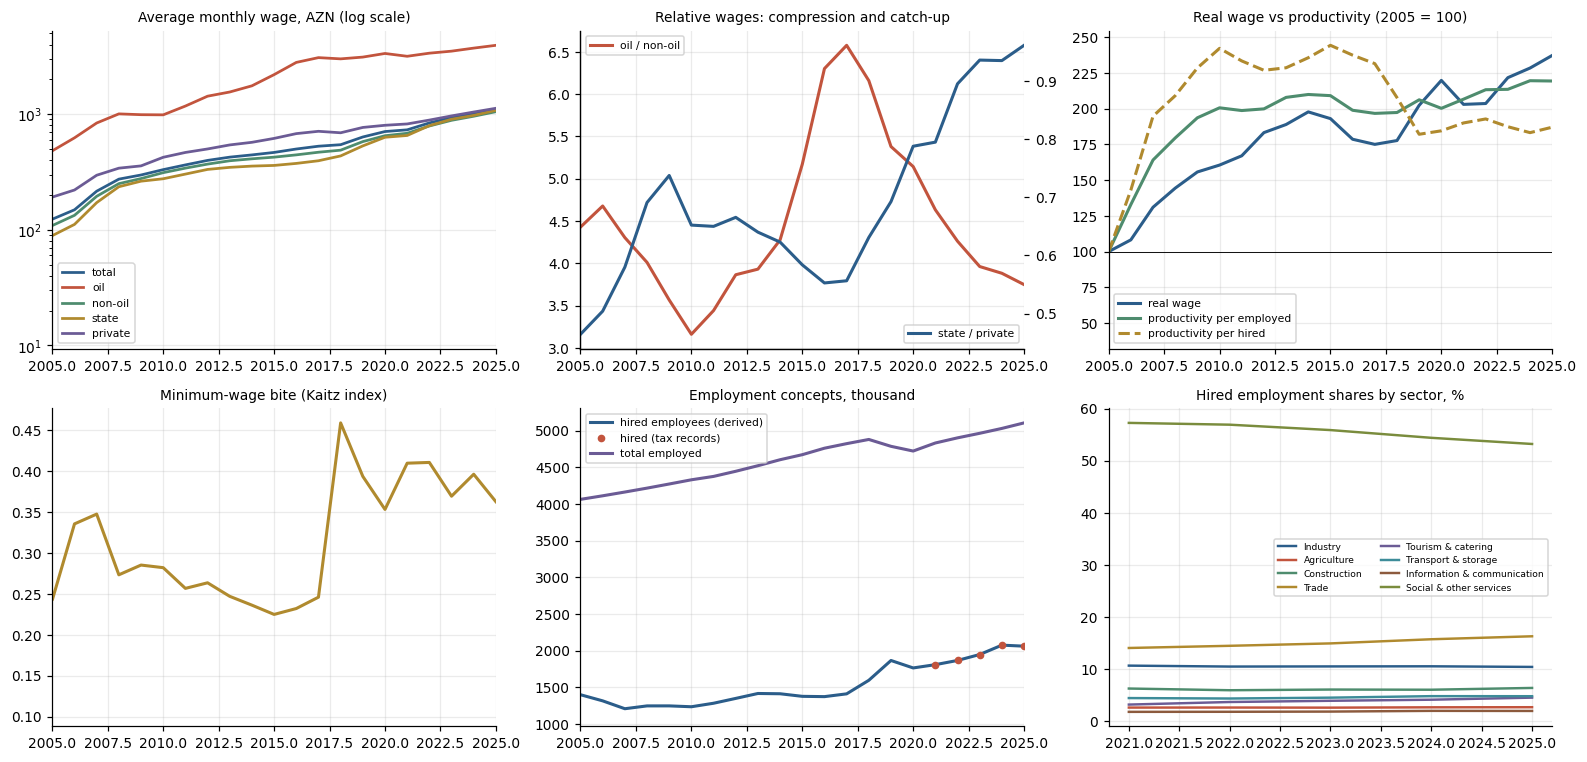

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(14.5, 7))
a = ax[0,0]
for i,(c,l) in enumerate([('w_avg','total'),('w_oil','oil'),('w_non','non-oil'),
                          ('w_state','state'),('w_priv','private')]):
    a.plot(W.index, W[c], label=l, color=PAL[i], lw=1.8)
a.set_yscale('log'); a.set_xlim(2005, LAST_ACT); a.legend(fontsize=7)
a.set_title('Average monthly wage, AZN (log scale)', fontsize=9)
a = ax[0,1]
a.plot(W.index, W.prem_oil, color=PAL[1], lw=2, label='oil / non-oil')
a2 = a.twinx(); a2.plot(W.index, W.prem_sp, color=PAL[0], lw=2, label='state / private'); a2.grid(False)
a.set_xlim(2005, LAST_ACT); a.set_title('Relative wages: compression and catch-up', fontsize=9)
a.legend(fontsize=7, loc='upper left'); a2.legend(fontsize=7, loc='lower right')
a = ax[0,2]
a.plot(W.index, W.rw_avg/W.rw_avg[2005]*100, lw=2, color=PAL[0], label='real wage')
a.plot(W.index, W.prod_tot/W.prod_tot[2005]*100, lw=2, color=PAL[2], label='productivity per employed')
a.plot(W.index, W.prod_h/W.prod_h[2005]*100, lw=2, ls='--', color=PAL[3], label='productivity per hired')
a.set_xlim(2005, LAST_ACT); a.axhline(100, color='k', lw=.6); a.legend(fontsize=7)
a.set_title('Real wage vs productivity (2005 = 100)', fontsize=9)
a = ax[1,0]
a.plot(W.index, W.kaitz, lw=2, color=PAL[3]); a.set_xlim(2005, LAST_ACT)
a.set_title('Minimum-wage bite (Kaitz index)', fontsize=9)
a = ax[1,1]
a.plot(W.index, W.hired, lw=2, color=PAL[0], label='hired employees (derived)')
a.plot(W.index, W.hired_dvx, 'o', ms=4, color=PAL[1], label='hired (tax records)')
a.plot(W.index, W.emp_tot, lw=2, color=PAL[4], label='total employed')
a.set_xlim(2005, LAST_ACT); a.legend(fontsize=7); a.set_title('Employment concepts, thousand', fontsize=9)
a = ax[1,2]
sh = pd.DataFrame({k: W[f'e_{k}'] for k in SEC8}).dropna()
sh = sh.div(sh.sum(axis=1), axis=0)*100
for i,k in enumerate(SEC8): a.plot(sh.index, sh[k], label=SECLAB[k], color=PAL[i], lw=1.6)
a.set_title('Hired employment shares by sector, %', fontsize=9); a.legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

## Part 7 — Panel block I: industrial sub-branches

The aggregate wage series give 21–26 annual observations. The industry sheets give a genuine panel — **29 sub-branches with published wages (27 of them also with value added) and
both the average wage and the headcount, 2016–2025** — which is the only place in this workbook where sector wages and sector
labour input are observed together. It is used for two purposes: to estimate the wage–productivity elasticity, and to forecast
**industrial wages at 2-digit level**, which is the sector dimension FR3 asks for and the data genuinely support.

In [13]:
IND_SHEETS = [('Mədənçıxarma', 6, 7), ('Emal Sənayesi', 7, 8),
              ('Su təchizatı', 7, 8), ('Elektrik enerjisi ', 7, 8)]

def industry_wage_panel():
    '''Branch-level wage, headcount, output and value added. A branch's output row is followed by
    its value-added, investment, wage and headcount rows, so the branch name is carried forward.'''
    recs = []
    for sh, _, _ in IND_SHEETS:
        mat, h, per = sheet_parsed(sh)
        acols = [(j, p[0]) for j, p in per if p[2] == 'A']
        branch = None
        for i in range(h+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            lab = clean(row[0]); low = az_lower(lab)
            vals = {y: to_num(row[j]) for j, y in acols}
            if not any(np.isfinite(v) for v in vals.values()): continue
            var = None
            if 'buraxılış' in low:
                branch = re.sub(r'\s*(üzrə\s*)?(məhsul\s*)?buraxılış[ıi]?\s*$', '', lab, flags=re.I)
                branch = re.sub(r'\s*üzrə$', '', branch).strip(' ;,.')
                var = 'output'
            elif 'əlavə dəyər' in low:                            var = 'gva'
            elif low.startswith('üdm') or 'sahə üzrə üdm' in low:  var = 'gva'
            elif 'əsas kapitala' in low:                          var = 'inv'
            elif 'əmək haqları' in low:                           var = 'wage'
            elif 'orta siyahı sayı' in low:                       var = 'emp'
            if var is None or branch is None: continue
            for y, v in vals.items():
                if np.isfinite(v):
                    recs.append(dict(sheet=sh, branch=branch, year=y, var=var, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['sheet','branch','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

IP = industry_wage_panel()
AGG_ROWS = {'Emal sənayesi', 'Mədənçıxarma sənayesi'}      # would double-count their branches
IP = IP[~IP.branch.isin(AGG_ROWS)].sort_values(['branch','year']).reset_index(drop=True)
IP['unit'] = IP.branch
IP['prod'] = IP.gva*1e6/IP.emp                             # value added per worker, AZN per year
IP['wagebill'] = IP.wage*12*IP.emp/1e6                     # mln AZN
IP['lshare'] = IP.wagebill/IP.gva
for c in ['wage','emp','prod','gva','output']:
    IP['ln_'+c] = np.log(IP[c].replace(0, np.nan))
IP['rwage'] = IP.wage/IP.year.map(D1.cpi)*100
IP['ln_rwage'] = np.log(IP.rwage.replace(0, np.nan))
print(f"industry wage panel: {IP.branch.nunique()} branches x {IP.year.nunique()} years "
      f"= {len(IP)} observations ({int(IP.year.min())}-{int(IP.year.max())})")
display(IP[IP.year==LAST_ACT].nlargest(10,'wage')[['branch','wage','emp','prod','lshare']].round(2))
display(IP[IP.year==LAST_ACT].nsmallest(5,'wage')[['branch','wage','emp','prod','lshare']].round(2))

industry wage panel: 29 branches x 10 years = 290 observations (2016-2025)


,branch,wage,emp,prod,lshare
259,Xam neft və təbii qaz hasilatı,"3,788.400","18,387.000","1,685,538.700",0.030
169,Neft məhsullarının istehsalı,"2,827.300","3,788.000","591,393.880",0.060
139,Metal filizlərinin hasilatı,"2,602.200","2,447.000",NaN,NaN
89,"Komputer, elektron və optik məhsulların istehsalı","1,839.200",248.000,"86,693.550",0.250
79,Kimya sənayesi,"1,616.200","8,696.000","71,193.650",0.270
109,Maşın və avadanlıqların quraşdırılması və təmiri,"1,540.000","10,071.000","46,251.610",0.400
249,Tütün məmulatlarının istehsalı,"1,342.600","1,322.000","344,780.640",0.050
289,Əczaçılıq məhsullarının istehsalı,"1,285.200",477.000,"21,593.290",0.710
29,Elektrik avadanlıqlarının istehsalı,"1,186.200","2,888.000","32,686.980",0.440
149,Metallurgiya sənayesi,"1,164.500","6,361.000","49,772.050",0.280


,branch,wage,emp,prod,lshare
49,Geyim istehsalı,496.500,"5,293.000","9,937.650",0.600
129,Mebellərin istehsalı,509.500,"8,242.000","17,046.830",0.360
19,"Dəri və dəridən məmulatların,ayaqqabıların ist...",569.000,571.000,"14,886.160",0.460
119,Mebeldən başqa ağacın emalı və ağacdan məmulat...,617.600,797.000,"17,440.400",0.420
269,"Zərgərlik məmulatları, musiqi alətləri,idman m...",697.400,"1,973.000","21,844.910",0.380


In [14]:
print("=== wage-productivity elasticity in the industry panel ===")
pw1 = panel_fe(IP, 'ln_wage', ['ln_prod'], entity='unit', time='year')
pw2 = panel_fe(IP, 'ln_wage', ['ln_prod'], entity='unit', time='year', twoway=False)
pw3 = panel_fe(IP, 'ln_wage', ['ln_prod','ln_emp'], entity='unit', time='year')
pwb = panel_between(IP, 'ln_wage', ['ln_prod'])
print(pw1.summary('ln wage ~ ln value added per worker  [WITHIN: branch AND year effects]')); print()
print(pw2.summary('ln wage ~ ln value added per worker  [WITHIN: branch effects only]')); print()
print(pw3.summary('ln wage ~ ln productivity + ln employment  [two-way]')); print()
print(pwb.summary('ln wage ~ ln value added per worker  [BETWEEN: branch means, one obs per branch]')); print()
BETA_PANEL_WITHIN = float(pw1.beta[0]); BETA_PANEL_BETWEEN = float(pwb.beta[1])
BETA_PANEL_BETWEEN_SE = float(pwb.se[1]); BETA_PANEL_ONEWAY = float(pw2.beta[0])
print("observed labour share of value added in the panel:")
ls = IP.lshare[IP.lshare.between(0.02, 1.5)]
display(pd.Series({'median': ls.median(), 'mean': ls.mean(),
                   'p25': ls.quantile(.25), 'p75': ls.quantile(.75), 'n': len(ls)}).round(3))
print(f'''INTERPRETATION
  within branches, year to year (two-way FE)       : {BETA_PANEL_WITHIN:+.3f}
  within branches, branch effects only (one-way FE): {BETA_PANEL_ONEWAY:+.3f}  - still a WITHIN estimator: it
                                                      absorbs every permanent branch difference
  BETWEEN branches (branch means)                  : {BETA_PANEL_BETWEEN:+.3f} (se {BETA_PANEL_BETWEEN_SE:.3f})
  implied by the median labour share               : {ls.median():.3f}

Year-to-year, wages move little with measured productivity (within {BETA_PANEL_WITHIN:+.3f}); the one-way
estimate is larger only because it also picks up the common time trend. Across branches, permanently
more productive branches pay more, with an elasticity of about {BETA_PANEL_BETWEEN:.2f}. The between estimate is the
cross-sectional elasticity that Part 11 uses when testing whether sector wages can be derived from
productivity. It is a statement about cross-branch LEVEL differences; it says nothing about whether
the national wage and productivity series are cointegrated over time (Part 9 tests that directly).''')


=== wage-productivity elasticity in the industry panel ===
ln wage ~ ln value added per worker  [WITHIN: branch AND year effects]   n=269  R2=0.0375  adj=-0.1119
  units=27  periods=10  DK lags=1  p-values from t(9)
         coef    se     t     p sig
ln_prod 0.065 0.032 1.992 0.078   *

ln wage ~ ln value added per worker  [WITHIN: branch effects only]   n=269  R2=0.4092  adj=0.3430
  units=27  periods=10  DK lags=1  p-values from t(9)
         coef    se     t     p  sig
ln_prod 0.336 0.071 4.699 0.001  ***

ln wage ~ ln productivity + ln employment  [two-way]   n=269  R2=0.0389  adj=-0.1150
  units=27  periods=10  DK lags=1  p-values from t(9)
          coef    se      t     p sig
ln_prod  0.066 0.034  1.954 0.082   *
ln_emp  -0.022 0.082 -0.266 0.796    

ln wage ~ ln value added per worker  [BETWEEN: branch means, one obs per branch]   n=27  R2=0.6859  adj=0.6733
  units=27
         coef    se     t     p  sig
const   3.457 0.505 6.842 0.000  ***
ln_prod 0.305 0.049 6.175 0.000  *

median     0.339
mean       0.392
p25        0.233
p75        0.485
n        255.000
dtype: float64

INTERPRETATION
  within branches, year to year (two-way FE)       : +0.065
  within branches, branch effects only (one-way FE): +0.335  - still a WITHIN estimator: it
                                                      absorbs every permanent branch difference
  BETWEEN branches (branch means)                  : +0.305 (se 0.049)
  implied by the median labour share               : 0.339

Year-to-year, wages move little with measured productivity (within +0.065); the one-way
estimate is larger only because it also picks up the common time trend. Across branches, permanently
more productive branches pay more, with an elasticity of about 0.30. The between estimate is the
cross-sectional elasticity that Part 11 uses when testing whether sector wages can be derived from
productivity. It is a statement about cross-branch LEVEL differences; it says nothing about whether
the national wage and productivity series are cointegrated over time (Part 9 tests that directly).


## Part 8 — Panel block II: 14 economic regions

The regional sheets give average wage and hired employment for **14 economic regions, 2021–2025**. Regions face a common
national minimum wage and a common price level, so cross-region variation identifies how much of a wage difference local
productivity and local labour-market conditions explain — variation that the national time series cannot provide.

In [15]:
REGION_SHEETS = ['Regionlar'] + [f'Regionlar {i}' for i in range(1, 14)]
def region_wage_panel():
    recs = []
    KEYS = {'muzdla çalışanların orta aylıq nominal əmək haqqı':'wage',
            'iqtisadiyyatda muzdla çalışanların sayı':'emp',
            'əhalinin sayı':'pop', 'müəssisə və təşkilatların sayı':'firms',
            'yeni açılmış iş yerləri':'newjobs', 'cəmi kredit qoyuluşu':'credit',
            'ümumi daxilolma':'tax', 'cəmi mallar və xidmətlər üzrə':'cpi_reg'}
    for sh in REGION_SHEETS:
        if sh not in WB.sheetnames: continue
        mat = sheet_matrix(WB[sh])
        title = clean(mat[0][0]) if mat[0][0] else sh
        region = re.sub(r'\s*iqtisadi rayonun.*$', '', title, flags=re.I).strip() or sh
        if len(region) > 40: region = sh
        hdr = None
        for i in range(4):
            ys = [(j, int(clean(mat[i][j])[:4])) for j in range(len(mat[i]))
                  if mat[i][j] is not None and re.fullmatch(r'(19|20)\d\d', clean(mat[i][j]))]
            if len(ys) >= 3: hdr = (i, ys); break
        if hdr is None: continue
        hrow, ycols = hdr; block = None
        for i in range(hrow+1, len(mat)):
            row = mat[i]
            if row[0] is None or not clean(row[0]): continue
            low = az_lower(clean(row[0])).rstrip(' *:')
            vals = {y: to_num(row[j]) for j, y in ycols}
            if 'milyon manat' in low and 'ümumi məhsul' in low: block = 'lvl'; continue
            if 'fiziki həcm' in low: block = 'vol'; continue
            if not any(np.isfinite(v) for v in vals.values()): continue
            name = None
            if block == 'lvl' and low.startswith('ümumi məhsul buraxılışı'): name = 'out_lvl'
            else:
                for k, v in KEYS.items():
                    if low.startswith(k): name = v; break
            if name is None: continue
            for y, v in vals.items():
                if np.isfinite(v): recs.append(dict(region=region, year=y, var=name, value=v))
    P = (pd.DataFrame(recs).pivot_table(index=['region','year'], columns='var',
                                        values='value', aggfunc='first').reset_index())
    P.columns.name = None
    return P

RP = region_wage_panel().sort_values(['region','year']).reset_index(drop=True)
RP['unit'] = RP.region
RP['prod'] = RP.out_lvl*1e6/(RP.emp*1e3)          # output per hired worker, AZN per year
RP['emp_rate'] = RP.emp/RP['pop']*100
for c in ['wage','prod','emp','out_lvl','credit','firms','pop']:
    if c in RP: RP['ln_'+c] = np.log(RP[c].replace(0, np.nan))
print(f"regional wage panel: {RP.region.nunique()} regions x {RP.year.nunique()} years = {len(RP)} observations")
display(RP[RP.year==LAST_ACT][['region','wage','emp','prod','emp_rate']]
        .set_index('region').sort_values('wage', ascending=False).round(2))
print("\n=== regional wage equations ===")
for regs in [['ln_prod'], ['ln_prod','emp_rate'], ['ln_prod','ln_firms']]:
    if any(r not in RP for r in regs): continue
    f = panel_fe(RP, 'ln_wage', regs, entity='unit', time='year')
    print(f"  ln wage ~ {'+'.join(regs):<22} n={f.n:<3} R2={f.r2:.3f}  " +
          "  ".join(f"{r}={f.beta[i]:+.4f}(p={f.pval[i]:.3f})" for i, r in enumerate(regs)))
f = panel_fe(RP, 'ln_wage', ['ln_prod'], entity='unit', time='year', twoway=False)
print(f"  (region effects only, still WITHIN)  n={f.n:<3} ln_prod={f.beta[0]:+.4f}(p={f.pval[0]:.3f})")
fb = panel_between(RP, 'ln_wage', ['ln_prod'])
BETA_REG_BETWEEN, BETA_REG_BETWEEN_SE = float(fb.beta[1]), float(fb.se[1])
print(f"  BETWEEN (region means)               n={fb.n:<3} ln_prod={BETA_REG_BETWEEN:+.4f} (se {BETA_REG_BETWEEN_SE:.3f}, p={fb.pval[1]:.3f})")
BETA_REG_WITHIN = float(panel_fe(RP,'ln_wage',['ln_prod'],entity='unit',time='year').beta[0])
print(f'''
The regional two-way within elasticity, {BETA_REG_WITHIN:+.3f}, is close to the industry panel's within estimate
({BETA_PANEL_WITHIN:+.3f}); the regional BETWEEN elasticity, {BETA_REG_BETWEEN:+.3f} (se {BETA_REG_BETWEEN_SE:.2f}, only {fb.n} regions), is
imprecise but of the same order as the industry between estimate ({BETA_PANEL_BETWEEN:+.3f}). Two independent panels
agree that year-to-year wage adjustment to measured productivity is weak while permanent
cross-unit productivity differences are partly paid. These are cross-sectional facts; they do not
establish a cointegrating levels relation for the national series - whether one exists is tested
equation by equation in Part 9, and where it is not established the level equations are labelled
descriptive.''')


regional wage panel: 14 regions x 5 years = 70 observations


,wage,emp,prod,emp_rate
region,,,,
Bakı,"1,381.000","1,007.900","95,031.450",42.780
Abşeron-Xızı,872.200,120.400,"70,841.540",13.680
Naxçıvan,822.300,61.000,NaN,12.910
Şərqi Zəngəzur,794.900,20.300,"154,672.720",6.680
Şirvan-Salyan,786.500,54.300,"51,871.110",10.860
Gəncə-Daşkəsən,772.800,77.800,"38,116.350",12.960
Qazax-Tovuz,739.900,58.900,"58,263.830",8.620
Quba-Xaçmaz,728.100,57.300,"48,781.880",10.370
Qarabağ,718.800,66.200,"74,753.240",8.810



=== regional wage equations ===
  ln wage ~ ln_prod                n=65  R2=0.351  ln_prod=+0.0695(p=0.020)
  ln wage ~ ln_prod+emp_rate       n=65  R2=0.372  ln_prod=+0.0628(p=0.030)  emp_rate=-0.0043(p=0.204)
  ln wage ~ ln_prod+ln_firms       n=65  R2=0.362  ln_prod=+0.0684(p=0.021)  ln_firms=+0.0442(p=0.605)
  (region effects only, still WITHIN)  n=65  ln_prod=+0.5464(p=0.004)
  BETWEEN (region means)               n=13  ln_prod=+0.2688 (se 0.186, p=0.175)

The regional two-way within elasticity, +0.070, is close to the industry panel's within estimate
(+0.065); the regional BETWEEN elasticity, +0.269 (se 0.19, only 13 regions), is
imprecise but of the same order as the industry between estimate (+0.305). Two independent panels
agree that year-to-year wage adjustment to measured productivity is weak while permanent
cross-unit productivity differences are partly paid. These are cross-sectional facts; they do not
establish a cointegrating levels relation for the national series - wh

## Part 9 — Structural wage equations, block by block

### The theory being imposed

A wage is the price of labour, set by bargaining between employers and workers. The standard structural wage equation is

$$\ln W = \alpha + \beta \ln(\text{productivity}) + \gamma \ln P + \delta \ln(\text{reservation wage}) + \theta\,\text{tightness} + \sum_j \phi_j \ln W_j$$

with four testable implications, each of which is tested here rather than assumed:

1. **Nominal homogeneity**: a doubling of all prices — the CPI *and* every nominal regressor (the minimum wage, other
   sectors' wages) — doubles the nominal wage. With the minimum wage in the equation this is $\gamma + \delta = 1$, **not**
   $\gamma = 1$: that is the restriction the real-terms form imposes. It is tested per equation (9.1) and imposed only where it
   is not rejected; otherwise ln CPI enters separately.
2. **Productivity elasticity** $\beta = 1$ in the long run under competitive labour markets and constant returns — equivalently,
   a constant labour share.
3. **The reservation wage** — here the statutory **minimum wage**, an administered instrument in Azerbaijan — shifts the whole
   distribution, more strongly where the bite is larger.
4. **Cross-wage spillovers** $\phi_j$: this is the "related sectors" mechanism FR3 requires. Three channels are tested:
   * **oil-sector wage leadership** — the classic Dutch-disease / Scandinavian wage-leader channel, in which a
     high-productivity rent-rich enclave pulls up wages elsewhere through labour mobility and reference-wage effects;
   * **public-sector wage leadership** — administered public pay competing for the same workers;
   * **inter-sector competition** inside the non-oil economy.

Spillovers enter as *other* wages, never as the equation's own lag, so no autoregressive term is introduced.

### The registry

Every equation is stored with its estimator (DOLS rule), residual df, long-run coefficients, Engle–Granger (MacKinnon)
cointegration p-value, the difference-form coefficients and every restriction and break test, so the whole model can be
audited from one table.

In [16]:
from statsmodels.tsa.stattools import kpss

# ---------------------------------------------------------------------------------------------
# Specification machinery. A specification is (dependent wage, driver list, form, dummies).
#   form 'real'    : nominal homogeneity IMPOSED - wage and every nominal regressor deflated by CPI
#   form 'nominal' : ln CPI enters as a separate regressor (homogeneity NOT imposed)
# Real drivers (productivity, fiscal capacity) enter as they are. Nominal drivers are the minimum
# wage ('mw') and other sectors' wages ('w_state', 'w_non', 'w_oil'). The special dependent
# 'rel_priv' is ln(private / state wage), a relative-wage (ratio) model of the private wage.
# ---------------------------------------------------------------------------------------------
W['D18'] = (W.index >= 2018).astype(float)          # 2018 minimum-wage reform (level shift)
REAL_DRV = {'prod_tot': 'prod_tot', 'prod_non': 'prod_non', 'exp_pe': 'exp_per_emp'}
NOM_DRV  = {'mw': 'minwage', 'w_state': 'w_state', 'w_non': 'w_non', 'w_oil': 'w_oil', 'w_priv': 'w_priv'}
SAMPLE0  = {'w_avg': 2000}                           # other wages start in 2005

def xname(r, form):
    if r in REAL_DRV: return 'ln_' + r
    return ('ln_r' + r.replace('w_', 'w_')) if form == 'real' else 'ln_' + r

def design(spec, upto=LAST_ACT, data=None):
    '''y, X (I(1) regressors) and det (dummies) for a specification, using data <= upto.
    X is not trimmed at the start of the dependent's sample, so DOLS lags use pre-sample data.'''
    D = W if data is None else data
    dep, regs, form, dums = spec['dep'], spec['regs'], spec['form'], spec.get('dummies', ())
    cpi = D.cpi
    if dep == 'rel_priv':
        y = L(D.w_priv/D.w_state)
    else:
        y = L(D[dep]/cpi*100) if form == 'real' else L(D[dep])
    y = y.loc[SAMPLE0.get(dep, 2005):upto]
    X = {}
    for r in regs:
        if r in REAL_DRV: X[xname(r, form)] = L(D[REAL_DRV[r]])
        else:             X[xname(r, form)] = L(D[NOM_DRV[r]]/cpi*100) if form == 'real' else L(D[NOM_DRV[r]])
    X = pd.DataFrame(X)
    if form == 'nominal': X['ln_cpi'] = L(cpi)
    X = X.loc[:upto]
    det = pd.DataFrame({d: D[d] for d in dums}).loc[:upto]
    return y, X, det

def xrow(spec, drv):
    '''Regressor values for one period from a dict of NOMINAL levels (cpi, minwage, wages) and real
    drivers - the forecasting counterpart of design().'''
    form, x = spec['form'], {}
    for r in spec['regs']:
        if r in REAL_DRV: x[xname(r, form)] = np.log(drv[REAL_DRV[r]])
        else:
            v = drv[NOM_DRV[r]]
            x[xname(r, form)] = np.log(v/drv['cpi']*100) if form == 'real' else np.log(v)
    if form == 'nominal': x['ln_cpi'] = np.log(drv['cpi'])
    for d in spec.get('dummies', ()): x[d] = drv.get(d, 1.0)
    return x

def predict_ln_nominal(spec, coef, drv, addf=0.0):
    '''ln NOMINAL wage implied by a specification's long-run coefficients (+ add-factor).'''
    x = xrow(spec, drv)
    v = coef['const'] + sum(coef[k]*x[k] for k in x) + addf
    if spec['dep'] == 'rel_priv': return np.log(drv['w_state']) + v
    return v + (np.log(drv['cpi']/100) if spec['form'] == 'real' else 0.0)

def spec_label(spec):
    dep = 'ln(private/state)' if spec['dep'] == 'rel_priv' else spec['dep']
    d = ' + D18' if spec.get('dummies') else ''
    return f"{dep} ~ {' + '.join(spec['regs'])}{d}  [{spec['form']}]"

# ---------------------------------------------------------------------------------------------
# Registry: every forecasting equation is stored with its estimator, df, cointegration test,
# restriction tests and the difference-form comparison, so the model can be audited from one table.
# ---------------------------------------------------------------------------------------------
REG, RESID_OF = {}, {}
def diff_form(spec, upto=LAST_ACT):
    '''The same equation in first differences (contract decision 3): d ln y on d ln x.'''
    y, X, det = design(spec, upto)
    f = ols(y.diff(), X.diff().loc[y.index], cov='hac')
    return f

def register(name, spec, fit, block, note='', tests=None):
    u = fit.lr_resid.dropna()
    dw = float((np.diff(u.values)**2).sum()/(u.values**2).sum()) if len(u) > 2 else np.nan
    eg_stat, eg_p = eg_coint_p(u, fit.n_i1)
    jb = stats.jarque_bera(u.values)[1]
    rho = float(np.corrcoef(u.values[1:], u.values[:-1])[0, 1])
    fd = diff_form(spec)
    flags = []
    for c in fit.lr.index:
        if c in fd.names and c != 'const':
            j = fd.names.index(c); lo, hi = fd.beta[j]-stats.t.ppf(.975, fd.dof)*fd.se[j], fd.beta[j]+stats.t.ppf(.975, fd.dof)*fd.se[j]
            if not (lo <= fit.lr[c] <= hi): flags.append(c)
    REG[name] = dict(name=name, block=block, spec=spec, dep=spec['dep'], label=spec_label(spec), fit=fit,
                     coef=fit.lr, se=fit.lr_se, p=fit.lr_p, V=fit.lr_V,
                     n=fit.n, dof=fit.dof, estimator=fit.estimator, r2=fit.r2, dw=dw,
                     eg_stat=eg_stat, eg_coint_p=eg_p, jb_p=jb, rho=rho,
                     sample=(int(u.index.min()), int(u.index.max())),
                     diff=pd.Series(fd.beta, index=fd.names), diff_se=pd.Series(fd.se, index=fd.names),
                     outside_diff_ci=flags, tests=tests or {}, note=note,
                     inference='t-stats descriptive (cointegration not established)' if eg_p > 0.10 else 'standard')
    RESID_OF[name] = fit.lr_resid
    return fit

def show(name, title=None):
    e = REG[name]; f = e['fit']
    print(f"{title or name}:  {e['label']}")
    print(f"  estimator {e['estimator']}   n={e['n']}  residual df={e['dof']}  R2={e['r2']:.3f}   sample {e['sample'][0]}-{e['sample'][1]}")
    t = pd.DataFrame({'long-run coef': e['coef'], 'se (HAC)': e['se'], 'p': e['p']})
    t['difference-form coef'] = e['diff'].reindex(t.index)
    t['diff se'] = e['diff_se'].reindex(t.index)
    print(t.round(3).to_string())
    print(f"  Engle-Granger (MacKinnon) coint p = {e['eg_coint_p']:.3f}  -> {e['inference']};  DW={e['dw']:.2f}  "
          f"residual rho={e['rho']:.2f}  Jarque-Bera p={e['jb_p']:.3f}")
    if e['outside_diff_ci']: print(f"  FLAG: level coefficient outside the difference-form 95% CI for {e['outside_diff_ci']}")
    for k, v in e['tests'].items(): print(f"  {k}: {v}")
    if e['note']: print(f"  NOTE: {e['note']}")
    print()
print("specification machinery and registry initialised")


specification machinery and registry initialised


### 9.1 Break and homogeneity tests — decided on data ending in 2020

For every candidate specification, in the general nominal form (ln CPI and the nominal drivers entering separately), two tests
are run within the DOLS rule with HAC-F inference:

* a **break test** for a level shift at the **2018 minimum-wage reform** (D18 = 1 from 2018); the dummy is kept at 5%;
* the **homogeneity test** — the sum of the CPI and nominal-driver elasticities equals one (zero for the ratio model).

Both are run on **data ending in 2020**, so the 2021–2025 hold-out plays no part in any choice. Homogeneity is then **imposed in
every forecasting equation on theory grounds** (no long-run money illusion); where the test rejects it this is disclosed and the
unrestricted form is a forecast sensitivity. The break dummy cannot be scored out of sample before 2018, so it enters only a
sensitivity. The same tests on the full
sample are shown for information, and disagreements are flagged (and carried into a forecast sensitivity in Part 15).


In [17]:
# ---------------------------------------------------------------------------------------------
# Design rule (contract decision 5): EVERY choice - driver set, homogeneity imposed or not, break
# dummy in or out - is made on data ending in CUT_SEL = 2020. The 2021-2025 window is kept purely
# as the final hold-out test (Part 13). Full-sample (to 2025) versions of each test are reported
# alongside for information only; where they disagree with the pre-2021 decision this is flagged.
# ---------------------------------------------------------------------------------------------
CUT_SEL = 2020
ALPHA = 0.05
CANDS = {   # equation -> candidate driver sets (the dependent is fixed)
 'E1': ('w_avg',   [['prod_tot', 'mw'], ['prod_tot']]),
 'E2': ('w_non',   [['prod_non', 'mw'], ['prod_non']]),
 'E3': ('w_priv',  [['prod_non'], ['prod_non', 'mw'], ['prod_non', 'w_state'], ['prod_non', 'w_oil']]),
 'E3r':('rel_priv',[['prod_non', 'mw']]),            # ratio model: ln(private/state)
 'E4': ('w_state', [['prod_non', 'mw'], ['mw'], ['exp_pe', 'mw']]),
 'E5': ('w_oil',   [['w_non']]),
}

def homog_names(spec_nom):
    '''Coefficients whose sum is restricted by nominal homogeneity in the nominal form.'''
    y, X, det = design(spec_nom, CUT_SEL)
    return ['ln_cpi'] + [c for c in X.columns if c not in ('ln_cpi',) and c.replace('ln_', '') in NOM_DRV]

def test_spec(dep, regs, upto):
    '''Break test (level shift at the 2018 reform, HAC-F on D18 in the general nominal form) and
    the homogeneity test (sum of nominal elasticities = 1, or = 0 for the ratio model), both within
    the DOLS rule.'''
    out = {}
    sp = dict(dep=dep, regs=regs, form='nominal', dummies=('D18',))
    y, X, det = design(sp, upto); f = estimate_lr(y, X, det)
    Fb, pb, seb, vb = restrict_sum(f, ['D18'], 0.0)
    out.update(D18=vb, D18_se=seb, break_p=pb)
    keep = pb < ALPHA
    sp = dict(dep=dep, regs=regs, form='nominal', dummies=('D18',) if keep else ())
    y, X, det = design(sp, upto); f = estimate_lr(y, X, det)
    target = 0.0 if dep == 'rel_priv' else 1.0
    nm = homog_names(sp)
    Fh, ph, seh, vh = restrict_sum(f, nm, target)
    out.update(break_kept=keep, homog_sum=vh, homog_se=seh, homog_F=Fh, homog_p=ph,
               homog_df=(1, f.dof), estimator=f.estimator, n=f.n)
    return out

rows, DECIDE = [], {}
for eq, (dep, cand) in CANDS.items():
    for regs in cand:
        pre, full = test_spec(dep, regs, CUT_SEL), test_spec(dep, regs, LAST_ACT)
        form = 'real' if pre['homog_p'] >= ALPHA else 'nominal'
        DECIDE[(eq, tuple(regs))] = dict(form=form, dummies=('D18',) if pre['break_kept'] else ())
        rows.append({'eq': eq, 'drivers': ' + '.join(regs),
                     'D18 (<=2020)': round(pre['D18'], 3), 'break p (<=2020)': round(pre['break_p'], 3),
                     'break p (<=2025)': round(full['break_p'], 3),
                     'sum of price elast. (<=2020)': round(pre['homog_sum'], 3), 'se': round(pre['homog_se'], 3),
                     f'HAC-F p (<=2020)': round(pre['homog_p'], 3), 'estimator (<=2020)': pre['estimator'],
                     'sum (<=2025)': round(full['homog_sum'], 3), 'HAC-F p (<=2025)': round(full['homog_p'], 3),
                     'decision': f"{form}{' + D18' if pre['break_kept'] else ''}",
                     'full sample agrees': ((full['homog_p'] >= ALPHA) == (pre['homog_p'] >= ALPHA)) and
                                           (full['break_kept'] == pre['break_kept'])})
HOMOG = pd.DataFrame(rows).set_index(['eq', 'drivers'])
print("BREAK AND HOMOGENEITY TESTS - decided on data <= 2020, reported to 2025 for information")
print("  nominal form: ln W = a + b ln(real driver) + c ln CPI + d ln(nominal driver) [+ g D18]")
print("  homogeneity H0: c + d = 1 (the restriction the real-terms form imposes); ratio model: c + d = 0")
display(HOMOG)
n_imp = int((HOMOG.decision.str.startswith('real')).sum())
print(f"homogeneity imposed (not rejected at {ALPHA:.0%} on <=2020 data) for {n_imp} of {len(HOMOG)} candidate specifications;")
print(f"break dummy retained for {int(HOMOG.decision.str.contains('D18').sum())} of {len(HOMOG)}.")
dis = HOMOG[~HOMOG['full sample agrees']]
if len(dis):
    print("DISAGREEMENTS between the pre-2021 decision and the full-sample test (flagged, not acted on,")
    print("because the 2021-2025 window may not be used for choices):")
    for (e, d), r in dis.iterrows(): print(f"   {e} [{d}]: decision {r.decision}; full-sample break p={r['break p (<=2025)']}, homogeneity p={r['HAC-F p (<=2025)']}")
print('''
Where the restriction is "not rejected", the standard error of the tested sum is the power proxy: a
se of 0.1-0.2 means a sum anywhere between about 0.7 and 1.3 would also not be rejected, so these
are "not rejected (low power)" results, never confirmations.''')

# the aggregate table the original notebook reported, now with the CORRECT restriction
print("\nAggregate wage, OLS-in-levels variants (the table of the original version), HAC-F:")
rows = []
for nm, xd in [('productivity + CPI', {'ln_prod': L(W.prod_tot), 'ln_cpi': L(W.cpi)}),
               ('productivity + CPI + minimum wage', {'ln_prod': L(W.prod_tot), 'ln_cpi': L(W.cpi), 'ln_mw': L(W.minwage)})]:
    X = pd.DataFrame(xd); f = ols(L(W.w_avg), X, cov='hac')
    nmz = ['ln_cpi'] + (['ln_mw'] if 'ln_mw' in X else [])
    Fh, ph, seh, vh = restrict_sum(f, nmz, 1.0)
    rows.append(dict(specification=nm, n=f.n, **{c: round(f.beta[f.names.index(c)], 3) for c in X.columns},
                     restriction=' + '.join(nmz) + ' = 1', sum=round(vh, 3), se=round(seh, 3), F=round(Fh, 2), p=round(ph, 3)))
AGG_H = pd.DataFrame(rows).set_index('specification'); display(AGG_H)
_p = float(AGG_H.p.iloc[1])
print(f"The original version tested only c = 1 in the second row and imposed the real form; but the real form")
print(f"restricts c + d = 1, which is {'REJECTED' if _p < ALPHA else 'not rejected'} for the aggregate in OLS levels (HAC-F p = {_p:.3f}).")
print("That is why the restriction is now tested per equation, within DOLS, before it is imposed.")


BREAK AND HOMOGENEITY TESTS - decided on data <= 2020, reported to 2025 for information
  nominal form: ln W = a + b ln(real driver) + c ln CPI + d ln(nominal driver) [+ g D18]
  homogeneity H0: c + d = 1 (the restriction the real-terms form imposes); ratio model: c + d = 0


D18 (<=2020)  break p (<=2020)  break p (<=2025)  sum of price elast. (<=2020)    se  HAC-F p (<=2020)           estimator (<=2020)  sum (<=2025)  HAC-F p (<=2025)       decision  \
eq  drivers                                                                                                                                                                                                  
E1  prod_tot + mw             -0.129             0.054             0.007                         1.053 0.122             0.670                      DOLS(0)         1.228             0.019           real   
    prod_tot                   0.039             0.559             0.446                         1.305 0.148             0.057                      DOLS(0)         1.290             0.000           real   
E2  prod_non + mw             -0.259             0.000             0.000                         0.871 0.070             0.104                      DOLS(0)         0.918             0.208     real + D18   
    prod_non                  -0.005             0.961             0.280                         1.017 0.196             0.932                      DOLS(0)         1.028             0.849           real   
E3  prod_non                   0.010             0.754             0.451                         0.805 0.043             0.001                      DOLS(0)         0.588             0.009        nominal   
    prod_non + mw              0.001             0.982             0.567                         0.771 0.101             0.049                      DOLS(0)         0.504             0.012        nominal   
    prod_non + w_state        -0.016             0.518             0.999                         0.782 0.073             0.018                      DOLS(0)         0.583             0.001        nominal   
    prod_non + w_oil          -0.022             0.207             0.534                         0.945 0.066             0.425                      DOLS(0)         0.614             0.000           real   
E3r prod_non + mw              0.377             0.000             0.020                        -0.199 0.266             0.476                      DOLS(0)        -0.632             0.122     real + D18   
E4  prod_non + mw             -0.376             0.000             0.000                         0.970 0.156             0.850                      DOLS(0)         1.177             0.365     real + D18   
    mw                        -0.387             0.000             0.000                         1.215 0.062             0.006                      DOLS(0)         1.203             0.000  nominal + D18   
    exp_pe + mw               -0.119             0.746             0.024                         0.710 0.134             0.067  OLS (df too small for DOLS)         1.303             0.031           real   
E5  w_non                      0.096             0.371             0.731                         2.185 0.261             0.001                      DOLS(0)         1.569             0.116        nominal   

                        full sample agrees  
eq  drivers                                 
E1  prod_tot + mw                    False  
    prod_tot                         False  
E2  prod_non + mw                     True  
    prod_non                          True  
E3  prod_non                          True  
    prod_non + mw                     True  
    prod_non + w_state                True  
    prod_non + w_oil                 False  
E3r prod_non + mw                     True  
E4  prod_non + mw                     True  
    mw                                True  
    exp_pe + mw                      False  
E5  w_non                            False

homogeneity imposed (not rejected at 5% on <=2020 data) for 8 of 13 candidate specifications;
break dummy retained for 4 of 13.
DISAGREEMENTS between the pre-2021 decision and the full-sample test (flagged, not acted on,
because the 2021-2025 window may not be used for choices):
   E1 [prod_tot + mw]: decision real; full-sample break p=0.007, homogeneity p=0.019
   E1 [prod_tot]: decision real; full-sample break p=0.446, homogeneity p=0.0
   E3 [prod_non + w_oil]: decision real; full-sample break p=0.534, homogeneity p=0.0
   E4 [exp_pe + mw]: decision real; full-sample break p=0.024, homogeneity p=0.031
   E5 [w_non]: decision nominal; full-sample break p=0.731, homogeneity p=0.116

Where the restriction is "not rejected", the standard error of the tested sum is the power proxy: a
se of 0.1-0.2 means a sum anywhere between about 0.7 and 1.3 would also not be rejected, so these
are "not rejected (low power)" results, never confirmations.

Aggregate wage, OLS-in-levels variants (the tab

,n,ln_prod,ln_cpi,restriction,sum,se,F,p,ln_mw
specification,,,,,,,,,
productivity + CPI,26,0.771,1.269,ln_cpi = 1,1.269,0.060,20.260,0.000,NaN
productivity + CPI + minimum wage,26,0.620,1.042,ln_cpi + ln_mw = 1,1.186,0.073,6.550,0.018,0.144


The original version tested only c = 1 in the second row and imposed the real form; but the real form
restricts c + d = 1, which is REJECTED for the aggregate in OLS levels (HAC-F p = 0.018).
That is why the restriction is now tested per equation, within DOLS, before it is imposed.


### 9.2 Choosing the equations on rolling origins, and the final estimates

Candidate driver sets are compared by **pseudo-out-of-sample forecasting from origins 2014, 2015 and 2016, scored on years up
to 2020** in the homogeneous form, with actual drivers and the same constant add-factor the live forecast uses. The
Diebold–Mariano statistic uses Bartlett-weighted autocovariances up to h−1 = 5 lags, so it is robust to the overlap of
multi-origin, multi-step errors. The lowest RMSE wins, unless a simpler
candidate is not significantly worse (Diebold–Mariano with the Harvey–Leybourne–Newbold correction, p > 0.10), in which case the
simpler one is kept. A **policy-lever coherence rule** applies first: the minimum wage may enter only if its sign is
consistent with theory (or its difference-form estimate is significantly of the same sign) and it survives the 2018 break
control; failing candidates are scored and shown but cannot be selected. The private wage is now modelled on its own fundamentals: the earlier regression on the non-oil wage was
near-tautological (private pay is over half the non-oil wage bill). Candidates include the minimum wage, a state-wage
spillover, an oil-wage (Dutch-disease) spillover and a private/state **ratio** model.

The chosen specifications are then estimated on the full sample by DOLS; their **long-run coefficients are the ones used in the
forecast**. E5 (oil wage) is estimated for reference only.


In [18]:
# ---------------------------------------------------------------------------------------------
# SPECIFICATION SELECTION ON ROLLING ORIGINS THAT END BEFORE THE HOLD-OUT
# Origins 2014, 2015, 2016: estimate on data <= origin (DOLS rule), anchor on the origin year's own
# residual (the constant add-factor the live forecast uses), predict every year to 2020 with actual
# drivers. 15 errors per candidate (6 + 5 + 4 horizons). Nothing from 2021-2025 is used.
# The D18 dummy cannot be estimated at origins before 2018, so candidates are scored without it;
# DECISION: long-run nominal homogeneity is imposed in every forecasting equation on theory grounds
# (no money illusion in the long run), so every candidate is scored in the homogeneous (real) form.
# Where 9.1 rejects the restriction on the short sample this is disclosed, and the unrestricted form
# is carried as a forecast sensitivity (Part 15).
# Rule: lowest RMSE wins unless a simpler candidate is not significantly worse (Diebold-Mariano
# with the Harvey-Leybourne-Newbold correction, p > 0.10) - then the simpler one is preferred.
# ---------------------------------------------------------------------------------------------
ORIGINS = [2014, 2015, 2016]
H_DM = CUT_SEL - min(ORIGINS)       # 6: overlap-robust DM (h-1 = 5 Bartlett lags on the pooled errors)

def spec_for(eq, regs, drop_dummy=False, homog=True):
    dep = CANDS[eq][0]; dc = DECIDE[(eq, tuple(regs))]
    return dict(dep=dep, regs=list(regs), form='real' if homog else dc['form'],
                dummies=() if drop_dummy else dc['dummies'])

def rolling_errors(spec, target, origins=ORIGINS, last=CUT_SEL):
    errs = []
    for o in origins:
        y, X, det = design(spec, o)
        f = estimate_lr(y, X, det)
        u0 = float(f.lr_resid.loc[o])
        for t in range(o+1, last+1):
            drv = {c: float(W[c][t]) for c in ['cpi', 'minwage', 'w_state', 'w_non', 'w_oil', 'w_priv',
                                               'prod_tot', 'prod_non', 'exp_per_emp']}
            lp = predict_ln_nominal(spec, f.lr, drv, u0)
            errs.append(dict(origin=o, year=t, h=t-o, err=(lp - np.log(W[target][t]))*100,
                             estimator=f.estimator))
    return pd.DataFrame(errs)

# POLICY-LEVER COHERENCE RULE (common to FR1/FR3/FR5). A policy-lever regressor (here the minimum
# wage) may enter a baseline equation only if (a) its long-run sign is consistent with theory (a higher
# floor does not lower wages), or its difference-form estimate is significantly (10%) of the same sign,
# AND (b) it survives the break control: with the 2018 dummy added it keeps its sign and stays
# significant at 10%. Checked on data <= 2020, like every other choice. Failing candidates are still
# scored and shown, but cannot be selected.
def lever_coherence(eq, regs, upto=CUT_SEL):
    if 'mw' not in regs or eq == 'E3r': return True, ''
    c = xname('mw', 'real')
    sp = dict(dep=CANDS[eq][0], regs=list(regs), form='real', dummies=())
    y, X, det = design(sp, upto); f0 = estimate_lr(y, X, det)
    fd = ols(y.diff(), X.diff().loc[y.index], cov='hac'); j = fd.names.index(c)
    b0, bd, pd_ = f0.lr[c], fd.beta[j], fd.pval[j]
    a_ok = (b0 >= 0) or (np.sign(bd) == np.sign(b0) and pd_ < 0.10)
    y, X, det = design(dict(sp, dummies=('D18',)), upto); f1 = estimate_lr(y, X, det)
    b_ok = (np.sign(f1.lr[c]) == np.sign(b0)) and (f1.lr_p[c] < 0.10)
    return a_ok and b_ok, (f"level {b0:+.3f}; diff-form {bd:+.3f} (p={pd_:.2f}); with D18 {f1.lr[c]:+.3f} "
                           f"(p={f1.lr_p[c]:.2f}) -> (a) {'pass' if a_ok else 'FAIL'}, (b) {'pass' if b_ok else 'FAIL'}")
COHERENCE = {}
SEL_ROWS, SEL_ERR, CHOSEN = [], {}, {}
GROUPS = {'E1': ['E1'], 'E2': ['E2'], 'E3': ['E3', 'E3r'], 'E4': ['E4']}
TARGET = {'E1': 'w_avg', 'E2': 'w_non', 'E3': 'w_priv', 'E4': 'w_state'}
for g, eqs in GROUPS.items():
    cands = []
    for eq in eqs:
        for regs in CANDS[eq][1]:
            sp = spec_for(eq, regs, drop_dummy=True)
            e = rolling_errors(sp, TARGET[g])
            key = f"{'ratio: ' if eq == 'E3r' else ''}{' + '.join(regs)}"
            cands.append((key, eq, regs, e))
            SEL_ERR[(g, key)] = e
            COHERENCE[(g, key)] = lever_coherence(eq, regs)
    rm = {k: float(np.sqrt((e.err**2).mean())) for k, _, _, e in cands}
    best = min((k for k in rm if COHERENCE[(g, k)][0]), key=rm.get)
    eb = SEL_ERR[(g, best)].err.values
    ok = []
    for k, eq, regs, e in cands:
        s_, p_ = (np.nan, np.nan) if k == best else dm_hln(e.err.values, eb, h=H_DM)
        nk = len(regs) + (1 if eq == 'E3r' else 0)          # the ratio model also needs the state wage
        dc = DECIDE[(eq, tuple(regs))]
        SEL_ROWS.append(dict(group=g, candidate=k, lever_coherent='yes' if COHERENCE[(g, k)][0] else 'NO', homogeneity_test='rejected' if dc['form'] == 'nominal' else 'not rejected',
                             break_test='break' if dc['dummies'] else '-',
                             n_drivers=nk, rolling_RMSE=round(rm[k], 2),
                             mean_error=round(float(e.err.mean()), 2),
                             DM_vs_best=round(s_, 2) if np.isfinite(s_) else np.nan,
                             DM_p=round(p_, 3) if np.isfinite(p_) else np.nan,
                             estimators='/'.join(sorted(set(e.estimator.str.split('(').str[0])))))
        if COHERENCE[(g, k)][0] and (k == best or p_ > 0.10): ok.append((nk, rm[k], k, eq, regs))
    nk, _, k, eq, regs = sorted(ok)[0]
    CHOSEN[g] = dict(key=k, eq=eq, regs=regs, best=best)
SEL = pd.DataFrame(SEL_ROWS).set_index(['group', 'candidate'])
print("ROLLING-ORIGIN SPECIFICATION SELECTION (origins 2014-2016, scored on 2015-2020, log errors x100)")
display(SEL)
print("policy-lever coherence checks (minimum wage, data <= 2020):")
for (g, k), (okc, txt) in COHERENCE.items():
    if txt: print(f"  {g} [{k}]: {txt}")
for g, c in CHOSEN.items():
    why = ('lowest RMSE among lever-coherent candidates' if c['key'] == c['best'] else
           f"not significantly worse than the lowest-RMSE candidate ({c['best']}) and simpler")
    print(f"  {g}: CHOSEN {c['key']:<28} - {why}")

# ---------------------------------------------------------------------------------------------
# FINAL EQUATIONS: the chosen specifications re-estimated on the full sample (DOLS rule). Their
# LONG-RUN coefficients are the ones used in the forecast.
# ---------------------------------------------------------------------------------------------
print()
BLOCK = {'E1': 'aggregate', 'E2': 'oil / non-oil', 'E3': 'state / private', 'E4': 'state / private'}
EQNAME = {'E1': 'E1_w_avg', 'E2': 'E2_w_non', 'E3': 'E3_w_priv', 'E4': 'E4_w_state', 'E5': 'E5_w_oil'}
SPEC = {}
for g, c in CHOSEN.items():
    sp = spec_for(c['eq'], c['regs'], drop_dummy=True)      # the form that was actually scored and won
    notes = [f"chosen on rolling origins <= {CUT_SEL} (Part 9.2)"]
    if DECIDE[(c['eq'], tuple(c['regs']))]['dummies']:
        notes.append('the D18 dummy passed the break test but could not be scored out of sample (not estimable '
                     'before 2018), so the baseline uses the scored specification without it; the D18 version is a sensitivity')
    if DECIDE[(c['eq'], tuple(c['regs']))]['form'] == 'nominal':
        notes.append('long-run homogeneity IMPOSED on theory grounds although rejected on this short sample: with '
                     'a sum of price elasticities c != 1 the real wage would drift by (c-1) x inflation every year '
                     'forever (money illusion). The rejection reflects episodes such as the 2021-22 inflation spike, '
                     'when nominal pay lagged prices, and the 2018 floor reform. The unrestricted version is a sensitivity')
    SPEC[EQNAME[g]] = sp
    y, X, det = design(sp)
    f = estimate_lr(y, X, det)
    h = HOMOG.loc[(c['eq'], ' + '.join(c['regs']))]
    tests = {'homogeneity (<=2020, decides)': f"sum={h['sum of price elast. (<=2020)']:.3f} (se {h['se']:.3f}) "
                                              f"p={h['HAC-F p (<=2020)']:.3f} -> "
                                              f"{'not rejected (low power); imposed' if h['HAC-F p (<=2020)'] >= ALPHA else 'REJECTED; imposed on theory grounds (see note)'}",
             'homogeneity (<=2025, information)': f"sum={h['sum (<=2025)']:.3f} p={h['HAC-F p (<=2025)']:.3f}",
             'break at 2018 (<=2020 decides / <=2025)': f"p={h['break p (<=2020)']:.3f} / p={h['break p (<=2025)']:.3f} -> "
                                              f"{'break found; D18 NOT in the baseline (unscorable), sensitivity only' if h['break p (<=2020)'] < ALPHA else 'no dummy'}"}
    register(EQNAME[g], sp, f, BLOCK[g], tests=tests, note='; '.join(notes))
    show(EQNAME[g])

# E5 is estimated and reported, but it is NOT used in the forecast: the oil wage is forecast as the
# (reconciled) non-oil wage times the oil-premium scenario lever (Part 15), and Part 13 validates
# THAT mechanism.
sp5 = spec_for('E5', ['w_non'], homog=False); SPEC['E5_w_oil'] = sp5
y, X, det = design(sp5); f = estimate_lr(y, X, det)
register('E5_w_oil', sp5, f, 'oil / non-oil (analytical only)',
         note='NOT used to forecast: the oil wage is the non-oil wage times the premium lever. Oil-sector '
              'productivity and the oil price were rejected as drivers (Part 10).')
show('E5_w_oil')

AUDIT = pd.DataFrame([{'equation': k, 'specification': v['label'], 'estimator': v['estimator'], 'n': v['n'],
                       'residual_df': v['dof'], 'R2': round(v['r2'], 3), 'eg_coint_p': round(v['eg_coint_p'], 3),
                       'inference': v['inference'],
                       'level_outside_diff_CI': ', '.join(v['outside_diff_ci']) or '-'} for k, v in REG.items()]).set_index('equation')
print("EQUATION AUDIT (Engle-Granger p from MacKinnon's response surface on the long-run residual)")
display(AUDIT)


ROLLING-ORIGIN SPECIFICATION SELECTION (origins 2014-2016, scored on 2015-2020, log errors x100)


lever_coherent homogeneity_test break_test  n_drivers  rolling_RMSE  mean_error  DM_vs_best  DM_p estimators
group candidate                                                                                                                        
E1    prod_tot + mw                   yes     not rejected          -          2        10.240       6.910       0.420 0.679       DOLS
      prod_tot                        yes     not rejected          -          1         8.870      -2.910         NaN   NaN       DOLS
E2    prod_non + mw                   yes     not rejected      break          2        12.360       9.600       1.660 0.119       OLS 
      prod_non                        yes     not rejected          -          1         8.260       0.080         NaN   NaN  DOLS/OLS 
E3    prod_non                        yes         rejected          -          1         5.090       4.030         NaN   NaN  DOLS/OLS 
      prod_non + mw                    NO         rejected          -          2         3.650       2.600      -2.100 0.054       OLS 
      prod_non + w_state              yes         rejected          -          2         5.180       3.250       0.190 0.853       OLS 
      prod_non + w_oil                yes     not rejected          -          2         5.840       5.010       1.490 0.160       OLS 
      ratio: prod_non + mw            yes     not rejected      break          3        12.620      -9.000       3.200 0.006       OLS 
E4    prod_non + mw                   yes     not rejected      break          2        15.960      11.600         NaN   NaN       OLS 
      mw                              yes         rejected      break          1        46.430      36.770       3.300 0.005  DOLS/OLS 
      exp_pe + mw                      NO     not rejected          -          2        22.080      17.530       0.760 0.461       OLS

policy-lever coherence checks (minimum wage, data <= 2020):
  E1 [prod_tot + mw]: level +0.269; diff-form +0.046 (p=0.43); with D18 +0.272 (p=0.00) -> (a) pass, (b) pass
  E2 [prod_non + mw]: level +0.204; diff-form +0.063 (p=0.35); with D18 +0.549 (p=0.00) -> (a) pass, (b) pass
  E3 [prod_non + mw]: level -0.044; diff-form -0.029 (p=0.66); with D18 +0.008 (p=0.93) -> (a) FAIL, (b) FAIL
  E4 [prod_non + mw]: level +0.401; diff-form +0.121 (p=0.12); with D18 +0.869 (p=0.00) -> (a) pass, (b) pass
  E4 [mw]: level +0.878; diff-form +0.126 (p=0.25); with D18 +1.196 (p=0.00) -> (a) pass, (b) pass
  E4 [exp_pe + mw]: level +0.236; diff-form +0.151 (p=0.09); with D18 +0.892 (p=0.15) -> (a) pass, (b) FAIL
  E1: CHOSEN prod_tot                     - lowest RMSE among lever-coherent candidates
  E2: CHOSEN prod_non                     - lowest RMSE among lever-coherent candidates
  E3: CHOSEN prod_non                     - lowest RMSE among lever-coherent candidates
  E4: CHOSEN prod_non + mw   

,specification,estimator,n,residual_df,R2,eg_coint_p,inference,level_outside_diff_CI
equation,,,,,,,,
E1_w_avg,w_avg ~ prod_tot [real],DOLS(+-1),25,20,0.974,0.339,t-stats descriptive (cointegration not establi...,ln_prod_tot
E2_w_non,w_non ~ prod_non [real],DOLS(+-1),20,15,0.956,0.794,t-stats descriptive (cointegration not establi...,-
E3_w_priv,w_priv ~ prod_non [real],DOLS(+-1),20,15,0.851,0.614,t-stats descriptive (cointegration not establi...,-
E4_w_state,w_state ~ prod_non + mw [real],DOLS(+-1),20,11,0.981,0.330,t-stats descriptive (cointegration not establi...,ln_rmw
E5_w_oil,w_oil ~ w_non [nominal],DOLS(0),20,15,0.916,0.927,t-stats descriptive (cointegration not establi...,-


### 9.3 The minimum wage: indexation, endogeneity and the 2018 break

The minimum wage is the model's main wage-policy lever and in the forecast it is **set by scenario**. But historically it has
responded to wages (P1), so as a regressor it may be endogenous. This section instruments it with its **lagged decree level** —
fixed before the year's wage outcomes, hence exogenous in timing; it is an instrument, not an autoregressive term — reports
Durbin–Wu–Hausman tests, and reports the elasticity as a **range** across OLS, DOLS and IV, with and without the 2018 break.
A Gregory–Hansen-type test asks whether a cointegrating relation appears once one level shift is allowed.


In [19]:
# ---- P1: the historical minimum-wage indexation pattern (reported, not used to forecast) ------
yP, XP = L(W.minwage).loc[2000:], pd.DataFrame({'ln_w_avg': L(W.w_avg)})
fP = estimate_lr(yP, XP)
FP1, pP1 = restrict_row(fP, 'ln_w_avg', 1.0)
_, egP1 = eg_coint_p(fP.lr_resid, 2)
P1_EL = float(fP.lr['ln_w_avg'])
print(f"P1  ln minimum wage ~ ln average wage   [{fP.estimator}, n={fP.n}, df={fP.dof}]")
print(f"    long-run elasticity {P1_EL:.3f} (se {fP.lr_se['ln_w_avg']:.3f});  H0 unit indexation: HAC-F={FP1:.2f} p={pP1:.3f};"
      f"  Engle-Granger coint p={egP1:.3f}")
print(f'''    The minimum wage has risen about {P1_EL:.2f}% for every 1% on the average wage: it RESPONDS to wages.
    Treating it as a strictly exogenous regressor is therefore questionable; it is tested below.''')

# ---- minimum-wage endogeneity: IV with the LAGGED decree level --------------------------------
# The statutory minimum wage in force last year is fixed before this year's wage outcomes are
# realised, so it is exogenous in timing and strongly correlated with this year's level. It is an
# INSTRUMENT (a lag of a regressor in the first stage) - not a lag of the dependent variable, so no
# autoregressive term enters any equation.
def mw_variants(eq, regs):
    form = 'real'                      # homogeneity imposed, as in the forecasting equations
    out = []
    for dums in [(), ('D18',)]:
        sp = dict(dep=CANDS[eq][0], regs=list(regs), form=form, dummies=dums)
        y, X, det = design(sp)
        mwc = xname('mw', form)
        XX = pd.concat([X, det], axis=1)
        o = ols(y, XX, cov='hac')
        d_ = estimate_lr(y, X, det)
        z = X[[mwc]].shift(1).rename(columns={mwc: mwc + '_lag'})
        ex = XX.drop(columns=[mwc])
        iv = tsls(y, X[[mwc]], ex if ex.shape[1] else None, z, cov='hac')
        # Durbin-Wu-Hausman (control function): add the first-stage residual to the OLS regression
        fs = ols(X[mwc], pd.concat([ex, z], axis=1), cov='nonrobust')
        cf = ols(y, pd.concat([XX, fs.resid.rename('v_hat')], axis=1), cov='hac')
        tag = ' + D18' if dums else ''
        out += [dict(eq=eq, drivers=' + '.join(regs), form=form, variant='OLS levels' + tag, mw_coef=o.beta[o.names.index(mwc)], se=o.se[o.names.index(mwc)]),
                dict(eq=eq, drivers=' + '.join(regs), form=form, variant='DOLS long run' + tag, mw_coef=d_.lr[mwc], se=d_.lr_se[mwc]),
                dict(eq=eq, drivers=' + '.join(regs), form=form, variant='2SLS, lagged decree' + tag, mw_coef=iv.beta[iv.names.index(mwc)], se=iv.se[iv.names.index(mwc)],
                     first_stage_F=iv.first_stage_F[mwc], DWH_p=cf.pval[cf.names.index('v_hat')])]
    return out

rows = []
for eq, regs in [('E1', ['prod_tot', 'mw']), ('E2', ['prod_non', 'mw']), ('E3', ['prod_non', 'mw']),
                 ('E4', ['prod_non', 'mw'])]:
    rows += mw_variants(eq, regs)
MWV = pd.DataFrame(rows)
print("\nMINIMUM-WAGE ELASTICITY ACROSS ESTIMATORS AND BREAK TREATMENTS (full sample, reporting only)")
display(MWV.set_index(['eq', 'variant'])[['drivers', 'form', 'mw_coef', 'se', 'first_stage_F', 'DWH_p']].round(3))
MWV['weak_iv'] = MWV.first_stage_F < 10
CRED = MWV[~MWV.weak_iv.fillna(False).astype(bool)]
MW_RANGE = CRED.groupby('eq').mw_coef.agg(['min', 'max']).round(3)
MW_RANGE['variants'] = CRED.groupby('eq').size()
MW_RANGE['in forecast?'] = [f"yes: {REG[n]['coef']['ln_rmw']:.3f}" if 'ln_rmw' in REG[n]['coef'] else 'no (not selected)'
                            for n in ['E1_w_avg', 'E2_w_non', 'E3_w_priv', 'E4_w_state']]
MW_RANGE.index = ['aggregate (E1 candidate)', 'non-oil (E2 candidate)', 'private (E3 candidate)', 'state (E4)']
print("minimum-wage elasticity - RANGE across the credible variants per equation")
print("(2SLS variants with a first-stage F below 10 are weak-instrument estimates and are excluded):")
display(MW_RANGE)
dwh = MWV[MWV.variant.str.startswith('2SLS')][['eq', 'variant', 'DWH_p', 'first_stage_F']]
strong = dwh[dwh.first_stage_F >= 10]
n_rej = int((strong.DWH_p < 0.05).sum())
if 'ln_rmw' in REG['E3_w_priv']['coef']:
    PRIV_MW_TXT = (f"In the homogeneous form it WINS the pre-2021 selection (rolling RMSE "
                   f"{SEL.loc[('E3','prod_non + mw'),'rolling_RMSE']:.2f}% vs {SEL.loc[('E3','prod_non'),'rolling_RMSE']:.2f}% without it, DM p = {float(SEL.loc[('E3','prod_non'),'DM_p']):.3f}), so it is\n"
                   f"    in the forecasting equation with a NEGATIVE long-run coefficient ({REG['E3_w_priv']['coef']['ln_rmw']:+.3f}): a higher real floor goes with\n"
                   f"    lower private pay in these data (the 2018 reform raised public pay; private pay did not follow).\n"
                   f"    It is kept because the evidence selects it, not because of its sign; minimum-wage scenario results\n"
                   f"    for the private wage are correspondingly uncertain.")
else:
    PRIV_MW_TXT = (f"In the homogeneous form it has the lowest rolling RMSE ({SEL.loc[('E3','prod_non + mw'),'rolling_RMSE']:.2f}%),\n"
                   f"    but it FAILS the policy-lever coherence rule (Part 9.2): {COHERENCE[('E3','prod_non + mw')][1]}.\n"
                   f"    The negative level coefficient is a timing artefact of the 2018 reform (it disappears with the break\n"
                   f"    dummy), so the minimum wage is excluded from E3; the E3-with-minimum-wage variant is a labelled sensitivity.")
print(f'''READING
  * Without the break dummy the lagged decree level is a strong instrument ({len(strong)} cases, first-stage
    F {strong.first_stage_F.min():.0f}-{strong.first_stage_F.max():.0f}); in the D18 variants it is weak (F {dwh[dwh.first_stage_F < 10].first_stage_F.min():.1f}-{dwh[dwh.first_stage_F < 10].first_stage_F.max():.1f}) - once the 2018 jump is absorbed by the dummy,
    little identifying variation is left - and those IV estimates are not used.
  * Where the instrument is strong, Durbin-Wu-Hausman rejects exogeneity of the minimum wage at 5% in
    {n_rej} of {len(strong)} cases, so OLS-in-levels minimum-wage coefficients are not to be read causally. The forecast
    uses DOLS, whose leads and lags of the regressor differences are the standard correction for
    regressor endogeneity in a cointegrating relation - but cointegration is NOT established for these
    equations (audit table), so the elasticity is best read as the RANGE above rather than as a point.
  * The 2018 break matters: adding the D18 level shift moves the minimum-wage coefficients, because the
    reform nearly doubled the real floor in a single year and that one jump carries most of the
    identifying variation.
  * PRIVATE SECTOR: the minimum-wage coefficient ranges from {MW_RANGE.loc['private (E3 candidate)','min']:+.3f} to {MW_RANGE.loc['private (E3 candidate)','max']:+.3f} across
    credible variants (largest |t| = {(CRED[CRED['eq']=='E3'].mw_coef/CRED[CRED['eq']=='E3'].se).abs().max():.2f}). {PRIV_MW_TXT}
  * STATE SECTOR: the floor is the dominant driver of public pay in every variant ({MW_RANGE.loc['state (E4)','min']:.2f} to
    {MW_RANGE.loc['state (E4)','max']:.2f}; 3SLS in Part 12). The forecast uses the specification that won the pre-2021 selection,
    DOLS without the break dummy ({REG['E4_w_state']['coef']['ln_rmw']:.3f}). The D18 version (DOLS {float(MWV[(MWV['eq']=='E4') & (MWV.variant=='DOLS long run + D18')].mw_coef.iloc[0]):.3f})
    passed the break test but could not be scored out of sample, so it is a sensitivity (Part 15).
    Minimum-wage scenario results for the state wage should be read against the range.''')

# ---- Gregory-Hansen-type test: cointegration allowing one level shift at an unknown date ------
GH_CV = {1: (-5.13, -4.61, -4.34), 2: (-5.44, -4.95, -4.68), 3: (-5.77, -5.28, -5.02)}   # GH (1996) model C
def gregory_hansen(y, X, trim=0.15):
    d = pd.concat([y.rename('y'), X], axis=1).dropna(); n = len(d); yrs = list(d.index)
    best = (np.inf, None)
    for tb in yrs[int(np.floor(trim*n)):int(np.ceil((1-trim)*n))]:
        Z = X.loc[d.index].copy(); Z['shift'] = (d.index >= tb).astype(float)
        u = ols(d.y, Z, cov='nonrobust').resid
        st = adfuller(u.values, maxlag=1, regression='n', autolag=None)[0]
        if st < best[0]: best = (st, tb)
    return best
rows = []
for nm in ['E1_w_avg', 'E2_w_non', 'E3_w_priv', 'E4_w_state']:
    sp = dict(REG[nm]['spec']); sp['dummies'] = ()
    y, X, det = design(sp)
    st, tb = gregory_hansen(y, X)
    m = X.shape[1]; cv = GH_CV.get(m, GH_CV[3])
    rows.append(dict(equation=nm, ADF_star=round(st, 2), break_year=tb, cv_10=cv[2], cv_5=cv[1],
                     verdict='cointegration with a break (5%)' if st < cv[1] else
                             ('at 10%' if st < cv[2] else 'not established')))
GH = pd.DataFrame(rows).set_index('equation')
print("\nGREGORY-HANSEN (level-shift model) - is there cointegration once one break is allowed?")
display(GH)


P1  ln minimum wage ~ ln average wage   [DOLS(+-1), n=25, df=20]
    long-run elasticity 1.502 (se 0.052);  H0 unit indexation: HAC-F=92.40 p=0.000;  Engle-Granger coint p=0.905
    The minimum wage has risen about 1.50% for every 1% on the average wage: it RESPONDS to wages.
    Treating it as a strictly exogenous regressor is therefore questionable; it is tested below.

MINIMUM-WAGE ELASTICITY ACROSS ESTIMATORS AND BREAK TREATMENTS (full sample, reporting only)


drivers  form  mw_coef    se  first_stage_F  DWH_p
eq variant                                                                            
E1 OLS levels                 prod_tot + mw  real    0.209 0.048            NaN    NaN
   DOLS long run              prod_tot + mw  real    0.292 0.060            NaN    NaN
   2SLS, lagged decree        prod_tot + mw  real    0.295 0.070         32.230  0.005
   OLS levels + D18           prod_tot + mw  real    0.136 0.065            NaN    NaN
   DOLS long run + D18        prod_tot + mw  real    0.317 0.066            NaN    NaN
   2SLS, lagged decree + D18  prod_tot + mw  real    0.287 0.137         10.396  0.016
E2 OLS levels                 prod_non + mw  real    0.061 0.046            NaN    NaN
   DOLS long run              prod_non + mw  real    0.114 0.075            NaN    NaN
   2SLS, lagged decree        prod_non + mw  real    0.216 0.133         12.983  0.002
   OLS levels + D18           prod_non + mw  real    0.300 0.105            NaN    NaN
   DOLS long run + D18        prod_non + mw  real    0.493 0.127            NaN    NaN
   2SLS, lagged decree + D18  prod_non + mw  real    2.435 2.682          0.499  0.000
E3 OLS levels                 prod_non + mw  real   -0.169 0.073            NaN    NaN
   DOLS long run              prod_non + mw  real   -0.247 0.131            NaN    NaN
   2SLS, lagged decree        prod_non + mw  real   -0.231 0.110         12.983  0.340
   OLS levels + D18           prod_non + mw  real   -0.025 0.048            NaN    NaN
   DOLS long run + D18        prod_non + mw  real   -0.012 0.224            NaN    NaN
   2SLS, lagged decree + D18  prod_non + mw  real   -0.456 0.698          0.499  0.493
E4 OLS levels                 prod_non + mw  real    0.236 0.080            NaN    NaN
   DOLS long run              prod_non + mw  real    0.386 0.074            NaN    NaN
   2SLS, lagged decree        prod_non + mw  real    0.532 0.192         12.983  0.000
   OLS levels + D18           prod_non + mw  real    0.474 0.166            NaN    NaN
   DOLS long run + D18        prod_non + mw  real    0.843 0.101            NaN    NaN
   2SLS, lagged decree + D18  prod_non + mw  real    4.160 4.466          0.499  0.000

minimum-wage elasticity - RANGE across the credible variants per equation
(2SLS variants with a first-stage F below 10 are weak-instrument estimates and are excluded):


,min,max,variants,in forecast?
aggregate (E1 candidate),0.136,0.317,6,no (not selected)
non-oil (E2 candidate),0.061,0.493,5,no (not selected)
private (E3 candidate),-0.247,-0.012,5,no (not selected)
state (E4),0.236,0.843,5,yes: 0.386


READING
  * Without the break dummy the lagged decree level is a strong instrument (5 cases, first-stage
    F 10-32); in the D18 variants it is weak (F 0.5-0.5) - once the 2018 jump is absorbed by the dummy,
    little identifying variation is left - and those IV estimates are not used.
  * Where the instrument is strong, Durbin-Wu-Hausman rejects exogeneity of the minimum wage at 5% in
    4 of 5 cases, so OLS-in-levels minimum-wage coefficients are not to be read causally. The forecast
    uses DOLS, whose leads and lags of the regressor differences are the standard correction for
    regressor endogeneity in a cointegrating relation - but cointegration is NOT established for these
    equations (audit table), so the elasticity is best read as the RANGE above rather than as a point.
  * The 2018 break matters: adding the D18 level shift moves the minimum-wage coefficients, because the
    reform nearly doubled the real floor in a single year and that one jump carries most of the
   


GREGORY-HANSEN (level-shift model) - is there cointegration once one break is allowed?


,ADF_star,break_year,cv_10,cv_5,verdict
equation,,,,,
E1_w_avg,-3.940,2017,-4.340,-4.610,not established
E2_w_non,-4.320,2013,-4.340,-4.610,not established
E3_w_priv,-3.950,2020,-4.340,-4.610,not established
E4_w_state,-4.220,2013,-4.680,-4.950,not established


## Part 10 — Specifications that failed

A wage model is only as credible as its disclosed failures. Each of these was tried, rejected on evidence, and replaced.

In [20]:
fails = []
print("=== FAILURE 1: the wage Phillips curve - no usable tightness channel ===")
g = pd.DataFrame({'dlnw': L(W.w_avg).diff()*100, 'unemp': W.unemp, 'infl': W.infl,
                  'dlnprod': L(W.prod_tot).diff()*100, 'dlnmw': L(W.minwage).diff()*100,
                  'emprate': W.emp_tot/W.lf*100})
for sp in [['unemp','infl'], ['unemp','infl','dlnprod'], ['unemp','infl','dlnmw']]:
    f = ols(g.dlnw, g[sp], cov='hac')
    i = f.names.index('unemp')
    print(f"  wage growth ~ {'+'.join(sp):<22} n={f.n:<3} R2={f.r2:.3f}  "
          f"unemployment={f.beta[i]:+.3f} (p={f.pval[i]:.3f})  <- expected NEGATIVE")
f = ols(L(W.rw_avg), pd.DataFrame({'ln_prod': L(W.prod_tot), 'ln_rmw': L(W.rminwage),
                                   'emprate': g.emprate}), cov='hac')
print(f"  real wage level ~ ... + employment rate: {f.beta[3]:+.4f} (p={f.pval[3]:.3f})")
fails.append(dict(what='Wage Phillips curve / labour-market tightness',
  evidence='unemployment enters POSITIVELY in growth form and insignificantly in levels; measured '
           'unemployment sat in 4.9-5.6% every year except 2020',
  response='no tightness term. Activity still reaches wages through productivity, but an independent '
           'unemployment effect is not identified and is not invented.'))
print('''  => Measured Azerbaijani unemployment is administratively smooth, and the one year it moved (2020)
     wages also rose. There is no tightness variation to identify a Phillips channel. DROPPED.\n''')

print("=== FAILURE 2: oil-sector wages are not explained by oil-sector fundamentals ===")
for nm, xd in [('oil productivity', {'ln_prod_oil': L(D1.rgdpoil/W.emp_tot)}),
               ('Brent price',      {'ln_brent': L(D1.brent)}),
               ('oil productivity + trend', {'ln_prod_oil': L(D1.rgdpoil/W.emp_tot), 'trend': W.trend}),
               ('relative productivity (premium form)',
                {'ln_relprod': L(D1.rgdpoil/D1.rgdpnon)})]:
    dep = L(W.rw_oil/W.rw_non) if 'premium' in nm else L(W.rw_oil)
    f = ols(dep, pd.DataFrame(xd), cov='hac')
    print(f"  {'premium' if 'premium' in nm else 'real oil wage':<14} ~ {nm:<34} n={f.n:<3} R2={f.r2:.3f}  " +
          "  ".join(f"{c}={f.beta[i+1]:+.3f}(p={f.pval[i+1]:.3f})" for i, c in enumerate(xd)))
fails.append(dict(what='Oil wage on oil-sector productivity or the oil price',
  evidence='productivity insignificant; Brent enters NEGATIVELY; the premium is unexplained (R2 below 0.1)',
  response='the oil wage is modelled as a mobility linkage to the non-oil real wage (E5), and flagged '
           'as the weakest equation. Oil is 2.5% of hired employment, so the aggregate stake is small.'))
print('''  => Pay in the oil enclave is set on international scales by PSA operators, not by measured
     Azerbaijani oil-sector value added (which is mostly resource rent accruing to capital and the
     budget) and not by the spot oil price. MODELLED AS A MOBILITY LINKAGE INSTEAD.\n''')

print("=== FAILURE 3: public pay does not independently follow private pay ===")
f_sp2 = ols(L(W.rw_state), pd.DataFrame({'ln_exp_pe': L(W.exp_per_emp), 'ln_rw_priv': L(W.rw_priv),
                                         'ln_rmw': L(W.rminwage)}), cov='hac')
print(f_sp2.table(3).to_string())
print(f"  -> the private-wage term is {f_sp2.beta[2]:+.3f} (p = {f_sp2.pval[2]:.3f}) once fiscal capacity and the floor are")
print("     controlled for (OLS levels, descriptive). Not used.\n")
fails.append(dict(what='Private-wage spillover into state-sector pay',
  evidence=f'private-wage term {f_sp2.beta[2]:+.3f} (p={f_sp2.pval[2]:.3f}) once real current expenditure per worker '
           'and the real minimum wage are included',
  response='state pay modelled as administered: non-oil productivity plus the statutory floor (E4).'))

_ch = CHOSEN['E3']['key']
for cand, what in [('prod_non + mw', 'Minimum wage in the PRIVATE wage equation'),
                   ('prod_non', 'Private wage on non-oil productivity alone'),
                   ('prod_non + w_oil', 'Oil-sector wage spillover into private pay (Dutch disease)'),
                   ('prod_non + w_state', 'State-wage spillover into private pay'),
                   ('ratio: prod_non + mw', 'Private wage as a ratio to the state wage')]:
    if cand == _ch: continue
    r_ = SEL.loc[('E3', cand)]
    fails.append(dict(what=what,
        evidence=f"rolling-origin RMSE {r_.rolling_RMSE:.2f} vs {SEL.loc[('E3', _ch),'rolling_RMSE']:.2f} for the chosen "
                 f"'{_ch}' (DM p={r_.DM_p:.3f})" + (f"; lever coherence: {COHERENCE[('E3', cand)][1]}" if COHERENCE[('E3', cand)][1] else ''),
        response=('excluded by the policy-lever coherence rule (wrong sign, does not survive the 2018 break control)'
                  if not COHERENCE[('E3', cand)][0] else 'not selected on the pre-2021 rolling-origin comparison.')))
fails.append(dict(what='Private wage on the real non-oil wage (the original E3)',
  evidence='near-tautological: private pay is over half of the non-oil wage bill, so the regressor contains '
           'the dependent variable; no cointegration and a coefficient that falls from 0.53 (OLS) to 0.17 (2SLS)',
  response='replaced by a private-wage equation on its own fundamentals (non-oil productivity, prices).'))


=== FAILURE 1: the wage Phillips curve - no usable tightness channel ===
  wage growth ~ unemp+infl             n=16  R2=0.078  unemployment=+1.714 (p=0.200)  <- expected NEGATIVE
  wage growth ~ unemp+infl+dlnprod     n=16  R2=0.154  unemployment=+1.951 (p=0.097)  <- expected NEGATIVE
  wage growth ~ unemp+infl+dlnmw       n=16  R2=0.220  unemployment=+1.320 (p=0.409)  <- expected NEGATIVE
  real wage level ~ ... + employment rate: -0.0143 (p=0.536)
  => Measured Azerbaijani unemployment is administratively smooth, and the one year it moved (2020)
     wages also rose. There is no tightness variation to identify a Phillips channel. DROPPED.

=== FAILURE 2: oil-sector wages are not explained by oil-sector fundamentals ===
  real oil wage  ~ oil productivity                   n=21  R2=0.000  ln_prod_oil=+0.013(p=0.984)
  real oil wage  ~ Brent price                        n=21  R2=0.083  ln_brent=-0.304(p=0.166)
  real oil wage  ~ oil productivity + trend           n=21  R2=0.711  ln_pr

### 10.3 The oil premium: can it be predicted at all?

Scored on the same rolling origins as 9.2 (pre-2021 data only), trend rules for the oil / non-oil premium are compared with
simply holding it at its latest value. The answer decides how the oil wage is forecast.


In [21]:
print("OIL WAGE - can the oil / non-oil premium be predicted at all? (rolling origins 2014-2016, scored to 2020)")
display(pd.DataFrame({'oil / non-oil wage premium': W.prem_oil}).loc[2005:LAST_ACT].round(2).T)
rows = []
for lbl in ['hold the premium at its origin-year value (the lever rule)', 'premium at its pre-origin average',
            'premium on a linear trend', 'premium on a quadratic trend']:
    errs = []
    for o in ORIGINS:
        pr = L(W.prem_oil).loc[2005:o]
        for t in range(o+1, CUT_SEL+1):
            if lbl.startswith('hold'):  lp = pr.loc[o]
            elif 'average' in lbl:      lp = pr.mean()
            else:
                X = pd.DataFrame({'trend': W.trend.loc[2005:o]})
                if 'quadratic' in lbl: X['tr2'] = X.trend**2
                f_ = ols(pr, X, cov='nonrobust')
                tt = W.trend[t]; lp = f_.beta[0] + f_.beta[1]*tt + (f_.beta[2]*tt**2 if 'quadratic' in lbl else 0)
            errs.append((lp + np.log(W.w_non[t]) - np.log(W.w_oil[t]))*100)
    errs = np.array(errs)
    rows.append(dict(rule=lbl, rolling_RMSE=round(float(np.sqrt((errs**2).mean())), 1),
                     mean_error=round(float(errs.mean()), 1), errors=errs))
PREM_SEL = pd.DataFrame(rows).set_index('rule')
e_hold = PREM_SEL.errors.iloc[0]
PREM_SEL['DM_p_vs_hold'] = [np.nan] + [round(dm_hln(e, e_hold, h=H_DM)[1], 3) for e in PREM_SEL.errors.iloc[1:]]
display(PREM_SEL.drop(columns='errors'))
PREM_2025 = float(W.prem_oil[LAST_ACT]); PREM_PEAK = float(W.prem_oil.max())
PREM_PEAK_YR = int(W.prem_oil.idxmax())
print(f'''  The premium rose from {W.prem_oil[2010]:.1f}x in 2010 to {PREM_PEAK:.1f}x in {PREM_PEAK_YR}, and has fallen steadily since, to
  {PREM_2025:.2f}x in {LAST_ACT}. Even on pre-2021 data, trend rules are far worse than holding the premium at its latest
  value, and E5 (the oil wage on the non-oil wage) has no established long-run relation (Engle-Granger p
  {REG['E5_w_oil']['eg_coint_p']:.2f}). The oil wage is therefore NOT forecast from E5: it is the reconciled non-oil wage
  times an explicit PREMIUM LEVER (Part 15), starting from the value the 2026 monthly data imply. Part 13
  validates exactly that mechanism - the non-oil wage times the premium held at its last pre-cut value.''')


OIL WAGE - can the oil / non-oil premium be predicted at all? (rolling origins 2014-2016, scored to 2020)


year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
oil / non-oil wage premium,4.430,4.680,4.300,4.010,3.570,3.160,3.440,3.860,3.930,4.280,5.170,6.300,6.580,6.160,5.380,5.140,4.630,4.260,3.960,3.880,3.750


,rolling_RMSE,mean_error,DM_p_vs_hold
rule,,,
hold the premium at its origin-year value (the lever rule),22.900,-14.000,NaN
premium at its pre-origin average,37.700,-36.300,0.003
premium on a linear trend,41.100,-37.700,0.047
premium on a quadratic trend,54.500,36.000,0.272


  The premium rose from 3.2x in 2010 to 6.6x in 2017, and has fallen steadily since, to
  3.75x in 2025. Even on pre-2021 data, trend rules are far worse than holding the premium at its latest
  value, and E5 (the oil wage on the non-oil wage) has no established long-run relation (Engle-Granger p
  0.93). The oil wage is therefore NOT forecast from E5: it is the reconciled non-oil wage
  times an explicit PREMIUM LEVER (Part 15), starting from the value the 2026 monthly data imply. Part 13
  validates exactly that mechanism - the non-oil wage times the premium held at its last pre-cut value.


## Part 11 — Can average wages by economic sector be derived? Two attempts, both rejected

This is the part of FR3 that the data do not support, and the reasoning is set out in full because the honest answer is a
negative one with a specific remedy.

The workbook gives, for all eight DSK sectors, **hired employment** (tax records) and **value added** (national accounts). The
obvious move is to form value added per hired worker and allocate wages in proportion, anchored so that the
employment-weighted average reproduces the published national wage. Industry is the test case, because there the actual wage
*is* observed.

In [22]:
SEC8_GVA_NOM = {'ind': A1.va_min_n + A1.va_man_n + A1.va_elc_n + A1.va_wat_n,
                'agr': A1.va_agr_n, 'con': A1.va_con_n, 'trd': A1.va_trd_n,
                'tou': A1.va_tou_n, 'tra': A1.va_tra_n, 'ict': A1.va_ict_n, 'oth': A1.va_oth_n}
NOM8 = pd.DataFrame(SEC8_GVA_NOM)
E8   = pd.DataFrame({k: W[f'e_{k}'] for k in SEC8})
yrs8 = [y for y in E8.index if E8.loc[y].notna().all() and np.isfinite(NOM8.loc[y].sum())]
PROD8 = (NOM8.loc[yrs8]*1e6).div(E8.loc[yrs8]*1e3)          # AZN of value added per hired worker

# the ACTUAL industry wage: employment-weighted across the four industry sheets
num = den = None
for sh, wr, er in IND_SHEETS:
    wv, ev = row_series(sh, wr), row_series(sh, er)
    num = (wv*ev) if num is None else num.add(wv*ev, fill_value=0)
    den = ev if den is None else den.add(ev, fill_value=0)
W_IND_ACTUAL = (num/den).dropna()
print("value added per hired worker, AZN per year (2025):")
display(PROD8.loc[LAST_ACT].round(0).sort_values(ascending=False).to_frame('per hired worker'))
print("actual industry average wage, from the industry sheets:")
display(W_IND_ACTUAL.loc[2016:LAST_ACT].round(1).to_frame('AZN per month').T)

def allocate(beta, prod, emp, target_avg):
    rel = (prod/prod.mean())**beta
    return rel*(target_avg*emp.sum()/(rel*emp).sum())

print(f"\n--- ATTEMPT 1: allocate by value added per hired worker (between-branch elasticity {BETA_PANEL_BETWEEN:.3f}) ---")
rows = []
for y in yrs8:
    der = allocate(BETA_PANEL_BETWEEN, PROD8.loc[y], E8.loc[y], W.w_avg[y])
    rows.append(dict(year=y, derived_industry=der['ind'], actual_industry=W_IND_ACTUAL.get(y, np.nan),
                     error_pct=(der['ind']/W_IND_ACTUAL.get(y, np.nan)-1)*100,
                     derived_agriculture=der['agr'],
                     agriculture_vs_average=der['agr']/W.w_avg[y]))
A1T = pd.DataFrame(rows).set_index('year')
display(A1T.round(2))
print(f'''  REJECTED on two independent grounds:
   (a) the derived industry wage is {A1T.error_pct.min():.0f} to {A1T.error_pct.max():.0f}% ABOVE the actual one. Industrial value added
       per worker is {PROD8.loc[LAST_ACT,"ind"]/1000:.0f} thousand AZN, but most of that is oil and gas RENT, which accrues
       to capital and the budget, not to the 197 thousand industrial employees.
   (b) it makes AGRICULTURE the best-paid sector in the economy, at {A1T.agriculture_vs_average.iloc[-1]:.2f}x the national average.
       Agricultural value added is {NOM8.loc[LAST_ACT,"agr"]/1000:.1f} bn AZN but only {E8.loc[LAST_ACT,"agr"]:.0f} thousand agricultural workers are
       HIRED - the output is produced overwhelmingly by the self-employed. Value added per hired
       worker is therefore not a wage-relevant productivity measure in that sector at all.''')

value added per hired worker, AZN per year (2025):


,per hired worker
ind,"216,433.000"
agr,"152,707.000"
tra,"101,036.000"
ict,"73,225.000"
con,"70,080.000"
trd,"47,437.000"
tou,"42,076.000"
oth,"27,826.000"


actual industry average wage, from the industry sheets:


,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
AZN per month,902.800,947.700,897.800,999.300,"1,049.100","1,029.400","1,135.100","1,206.500","1,246.900","1,321.300"



--- ATTEMPT 1: allocate by value added per hired worker (between-branch elasticity 0.305) ---


,derived_industry,actual_industry,error_pct,derived_agriculture,agriculture_vs_average
year,,,,,
2021,"1,281.980","1,029.370",24.540,"1,069.890",1.460
2022,"1,612.490","1,135.080",42.060,"1,185.360",1.410
2023,"1,583.950","1,206.510",31.280,"1,334.260",1.430
2024,"1,635.870","1,246.880",31.200,"1,416.600",1.400
2025,"1,727.440","1,321.300",30.740,"1,553.250",1.410


  REJECTED on two independent grounds:
   (a) the derived industry wage is 25 to 42% ABOVE the actual one. Industrial value added
       per worker is 216 thousand AZN, but most of that is oil and gas RENT, which accrues
       to capital and the budget, not to the 197 thousand industrial employees.
   (b) it makes AGRICULTURE the best-paid sector in the economy, at 1.41x the national average.
       Agricultural value added is 7.6 bn AZN but only 50 thousand agricultural workers are
       HIRED - the output is produced overwhelmingly by the self-employed. Value added per hired
       worker is therefore not a wage-relevant productivity measure in that sector at all.


In [23]:
print("--- ATTEMPT 2: strip the resource rent, and search for the elasticity that fits ---")
NOM8b = NOM8.copy(); NOM8b['ind'] = A1.va_man_n + A1.va_elc_n + A1.va_wat_n   # industry ex-mining
e_min = row_series('Mədənçıxarma', 7)/1000.0
E8b = E8.copy(); E8b['ind'] = E8['ind'] - e_min
PROD8b = (NOM8b.loc[yrs8]*1e6).div(E8b.loc[yrs8]*1e3)
rows = []
for lbl, PP, EE in [('including mining', PROD8, E8), ('excluding mining', PROD8b, E8b)]:
    best = None
    for b in np.arange(0.0, 1.01, 0.01):
        err = np.mean([abs(allocate(b, PP.loc[y], EE.loc[y], W.w_avg[y])['ind']/W_IND_ACTUAL[y]-1)
                       for y in yrs8 if y in W_IND_ACTUAL.index])
        if best is None or err < best[1]: best = (b, err)
    # what does the best-fitting elasticity imply for agriculture?
    agr = np.mean([allocate(best[0], PP.loc[y], EE.loc[y], W.w_avg[y])['agr']/W.w_avg[y] for y in yrs8])
    rows.append(dict(productivity_measure=lbl, best_fitting_elasticity=best[0],
                     industry_error_pct=best[1]*100, agriculture_vs_average=agr))
display(pd.DataFrame(rows).set_index('productivity_measure').round(3))
print('''  Also REJECTED. An elasticity can always be found that fits INDUSTRY, because it is one
  free parameter fitted to one target. But the same elasticity still puts agriculture far above
  the national average, so the fit is achieved without fixing the underlying attribution problem.
  Calibrating a structural parameter to hit one sector and ignoring what it does to the others is
  curve-fitting, not identification.''')
fails.append(dict(what='Deriving sector average wages from value added per hired worker',
  evidence=f'over-predicts the industry wage by {A1T.error_pct.min():.0f}-{A1T.error_pct.max():.0f}% (resource rent) and makes agriculture the '
           f'best-paid sector at ~{A1T.agriculture_vs_average.mean():.2f}x the average (only ~5% of agricultural labour is hired)',
  response='NOT USED. Sector wages are reported only where published: the 27 industrial sub-branches. '
           'For the other seven sectors FR3 forecasts EMPLOYMENT composition and quantifies its '
           'contribution to the aggregate wage, and names the missing series in Part 20.'))
print(f'''
DECISION AND WHAT IS DELIVERED INSTEAD

  delivered : average wages for the aggregate, oil/non-oil, state/private and the INDUSTRIAL
              sub-branches (29 with published wages, 27 of them with value added) - forecast structurally
  delivered : hired-employment composition for all eight DSK sectors, forecast structurally, and its
              exact contribution to aggregate wage growth through the between-sector term (Part 16)
  NOT delivered: average wages for agriculture, construction, trade, tourism, transport, ICT and
              other services, because the workbook does not publish them and they cannot be
              credibly inferred from what it does publish

  THE MISSING SERIES, PRECISELY: a sector breakdown of the wage fund (əmək haqqı fondu) or of
  compensation of employees. The State Tax Service already holds it - this very sheet reports the
  total wage fund alongside sector employment and sector turnover - so this is a data-request
  question rather than a modelling one.''')
FAILED = pd.DataFrame(fails)
display(FAILED)

--- ATTEMPT 2: strip the resource rent, and search for the elasticity that fits ---


,best_fitting_elasticity,industry_error_pct,agriculture_vs_average
productivity_measure,,,
including mining,0.140,2.731,1.186
excluding mining,0.660,2.193,2.422


  Also REJECTED. An elasticity can always be found that fits INDUSTRY, because it is one
  free parameter fitted to one target. But the same elasticity still puts agriculture far above
  the national average, so the fit is achieved without fixing the underlying attribution problem.
  Calibrating a structural parameter to hit one sector and ignoring what it does to the others is
  curve-fitting, not identification.

DECISION AND WHAT IS DELIVERED INSTEAD

  delivered : average wages for the aggregate, oil/non-oil, state/private and the INDUSTRIAL
              sub-branches (29 with published wages, 27 of them with value added) - forecast structurally
  delivered : hired-employment composition for all eight DSK sectors, forecast structurally, and its
              exact contribution to aggregate wage growth through the between-sector term (Part 16)
  NOT delivered: average wages for agriculture, construction, trade, tourism, transport, ICT and
              other services, because the wo

,what,evidence,response
0,Wage Phillips curve / labour-market tightness,unemployment enters POSITIVELY in growth form ...,no tightness term. Activity still reaches wage...
1,Oil wage on oil-sector productivity or the oil...,productivity insignificant; Brent enters NEGAT...,the oil wage is modelled as a mobility linkage...
2,Private-wage spillover into state-sector pay,private-wage term +0.009 (p=0.987) once real c...,state pay modelled as administered: non-oil pr...
3,Minimum wage in the PRIVATE wage equation,rolling-origin RMSE 3.65 vs 5.09 for the chose...,excluded by the policy-lever coherence rule (w...
4,Oil-sector wage spillover into private pay (Du...,rolling-origin RMSE 5.84 vs 5.09 for the chose...,not selected on the pre-2021 rolling-origin co...
5,State-wage spillover into private pay,rolling-origin RMSE 5.18 vs 5.09 for the chose...,not selected on the pre-2021 rolling-origin co...
6,Private wage as a ratio to the state wage,rolling-origin RMSE 12.62 vs 5.09 for the chos...,not selected on the pre-2021 rolling-origin co...
7,Private wage on the real non-oil wage (the ori...,near-tautological: private pay is over half of...,replaced by a private-wage equation on its own...
8,Deriving sector average wages from value added...,over-predicts the industry wage by 25-42% (res...,NOT USED. Sector wages are reported only where...


## Part 12 — The wage system, sector employment, and system estimation

### 12.1 Simultaneity and instruments

After the respecification the forecasting block is **recursive** (E4 → E3 only if E3 uses the state wage; the chosen E3 does
not), so simultaneity enters through the regressors that respond to wages: the **minimum wage** (P1) and, in E5, the non-oil
wage. The contemporaneous minimum wage is therefore **removed from the instrument set** and replaced by its lagged decree level.
Instruments are non-oil and total productivity, the CPI, the lagged real minimum wage, real budget spending per worker, the
oil price (current and lagged), hydrocarbon volumes and the 2018 dummy. Lagged variables are instruments only; no dependent
variable's lag enters. 3SLS on the four forecasting equations is reported as a system cross-check; the forecast uses DOLS.


In [24]:
# Instrument set. REVISION: the contemporaneous real minimum wage is REMOVED - it responds to the
# average wage (P1) and Durbin-Wu-Hausman rejects its exogeneity (9.3). Its LAGGED decree level is
# used instead (predetermined). Lagged values of exogenous variables are instruments only; no
# dependent variable's own lag enters any equation.
INSTR3 = pd.DataFrame({
 'ln_prod_non': L(W.prod_non), 'ln_prod_tot': L(W.prod_tot), 'ln_cpi': L(W.cpi),
 'ln_rmw_lag': L(W.rminwage).shift(1), 'ln_exp_pe': L(W.exp_per_emp),
 'ln_brent': L(D1.brent), 'ln_oil_prod': L(D1.oil_prod), 'ln_gas_prod': L(D1.gas_prod),
 'ln_brent_lag': L(D1.brent).shift(1), 'D18': W.D18,
})
print("instrument set:", ", ".join(INSTR3.columns))
print("\nrelevance (first-stage R2 on the full instrument set):")
for nm, v in [('ln real minimum wage', L(W.rminwage)), ('ln real non-oil wage', L(W.rw_non)),
              ('ln nominal non-oil wage', L(W.w_non))]:
    print(f"   {nm:<26} R2 = {ols(v, INSTR3, cov='nonrobust').r2:.3f}")

print("\n=== OLS vs 2SLS for the regressors that are jointly determined with wages ===")
rows = []
for lbl, y, En, Ex in [
    ('E4 state wage: real minimum wage', L(W.rw_state), pd.DataFrame({'ln_rmw': L(W.rminwage)}),
     pd.DataFrame({'ln_prod_non': L(W.prod_non), 'D18': W.D18})),
    ('E5 oil wage: non-oil wage', L(W.w_oil), pd.DataFrame({'ln_w_non': L(W.w_non)}),
     pd.DataFrame({'ln_cpi': L(W.cpi)}))]:
    Xall = pd.concat([En, Ex], axis=1)
    fo = ols(y, Xall, cov='hac')
    Z = INSTR3.drop(columns=[c for c in Ex.columns if c in INSTR3.columns])
    fi = tsls(y, En, Ex, Z, cov='hac')
    e_ = En.columns[0]
    rows.append(dict(equation=lbl, OLS=round(fo.beta[fo.names.index(e_)], 3),
                     TSLS=round(fi.beta[fi.names.index(e_)], 3),
                     difference=round(fi.beta[fi.names.index(e_)] - fo.beta[fo.names.index(e_)], 3),
                     first_stage_F=round(fi.first_stage_F[e_], 1),
                     sargan_p=round(fi.J_p, 3) if np.isfinite(fi.J_p) else np.nan, n=fi.n))
SIM3 = pd.DataFrame(rows).set_index('equation'); display(SIM3)
for eq_, r in SIM3.iterrows():
    wk = ' WEAK instrument set (F < 10);' if r.first_stage_F < 10 else ''
    sg = wk + ('over-identifying restrictions REJECTED at 5% - the instrument set is not jointly valid, so the 2SLS '
          'estimate is not a reliable benchmark' if r.sargan_p < 0.05 else
          'over-identifying restrictions not rejected (low power with this n)')
    print(f"  {eq_}: |OLS - 2SLS| = {abs(r.difference):.3f}; first-stage F {r.first_stage_F:.1f}; Sargan p = {r.sargan_p:.3f} -> {sg}.")
print('''  Differences of this size are NOT small relative to the coefficients: simultaneity matters. The
  forecast therefore uses DOLS (which corrects regressor endogeneity when a cointegrating relation
  exists) for E4, reports the IV range for the minimum wage (9.3), and does not use E5 at all.''')

print("\n=== 3SLS on the forecasting core (chosen specifications; system cross-check) ===")
core3, cols3 = {}, {}
for nm in ['E1_w_avg', 'E2_w_non', 'E3_w_priv', 'E4_w_state']:
    y, X, det = design(REG[nm]['spec'])
    core3[nm] = (y, pd.concat([X, det], axis=1))
Z3 = INSTR3.drop(columns=['ln_prod_tot', 'ln_prod_non', 'ln_cpi', 'D18'])
Z3 = pd.concat([Z3, pd.DataFrame({'ln_prod_tot': L(W.prod_tot), 'ln_prod_non': L(W.prod_non),
                                  'ln_cpi': L(W.cpi), 'D18': W.D18})], axis=1)
s3, s3res, s3S, s3idx = system_3sls(core3, Z3)
cmp3 = []
for k, v in s3.items():
    for c in v.index:
        if c == 'const': continue
        cmp3.append(dict(equation=k, regressor=c, DOLS_long_run=round(REG[k]['coef'][c], 3),
                         three_SLS=round(v.coef[c], 3), se_3SLS=round(v.se[c], 3)))
display(pd.DataFrame(cmp3).set_index(['equation', 'regressor']))
print(f"common 3SLS sample: {s3idx.min()}-{s3idx.max()} ({len(s3idx)} observations). The minimum-wage coefficient in")
print(f"E4 is {s3['E4_w_state'].coef['ln_rmw']:.3f} by 3SLS (lagged decree as instrument) against {REG['E4_w_state']['coef']['ln_rmw']:.3f} by DOLS.")

# cross-equation correlation of the LONG-RUN residuals - what the fan-chart bootstrap preserves
RES4 = pd.DataFrame({k: RESID_OF[k] for k in ['E1_w_avg', 'E2_w_non', 'E3_w_priv', 'E4_w_state']}).dropna()
print(f"\ncross-equation correlation of the long-run residuals ({RES4.index.min()}-{RES4.index.max()}):")
display(RES4.corr().round(3))
SIGMA3 = RES4.cov()


instrument set: ln_prod_non, ln_prod_tot, ln_cpi, ln_rmw_lag, ln_exp_pe, ln_brent, ln_oil_prod, ln_gas_prod, ln_brent_lag, D18

relevance (first-stage R2 on the full instrument set):
   ln real minimum wage       R2 = 0.997
   ln real non-oil wage       R2 = 0.998


   ln nominal non-oil wage    R2 = 1.000

=== OLS vs 2SLS for the regressors that are jointly determined with wages ===


,OLS,TSLS,difference,first_stage_F,sargan_p,n
equation,,,,,,
E4 state wage: real minimum wage,0.474,0.922,0.448,4.000,0.032,16
E5 oil wage: non-oil wage,0.257,-0.387,-0.644,116.900,0.043,16


  E4 state wage: real minimum wage: |OLS - 2SLS| = 0.448; first-stage F 4.0; Sargan p = 0.032 ->  WEAK instrument set (F < 10);over-identifying restrictions REJECTED at 5% - the instrument set is not jointly valid, so the 2SLS estimate is not a reliable benchmark.
  E5 oil wage: non-oil wage: |OLS - 2SLS| = 0.644; first-stage F 116.9; Sargan p = 0.043 -> over-identifying restrictions REJECTED at 5% - the instrument set is not jointly valid, so the 2SLS estimate is not a reliable benchmark.
  Differences of this size are NOT small relative to the coefficients: simultaneity matters. The
  forecast therefore uses DOLS (which corrects regressor endogeneity when a cointegrating relation
  exists) for E4, reports the IV range for the minimum wage (9.3), and does not use E5 at all.

=== 3SLS on the forecasting core (chosen specifications; system cross-check) ===


DOLS_long_run  three_SLS  se_3SLS
equation   regressor                                     
E1_w_avg   ln_prod_tot          1.040      2.051    0.431
E2_w_non   ln_prod_non          1.052      0.737    0.106
E3_w_priv  ln_prod_non          0.432      0.084    0.105
E4_w_state ln_prod_non          0.626      0.983    0.162
           ln_rmw               0.386      0.096    0.021

common 3SLS sample: 2010-2025 (16 observations). The minimum-wage coefficient in
E4 is 0.096 by 3SLS (lagged decree as instrument) against 0.386 by DOLS.

cross-equation correlation of the long-run residuals (2005-2025):


,E1_w_avg,E2_w_non,E3_w_priv,E4_w_state
E1_w_avg,1.000,-0.320,0.070,-0.044
E2_w_non,-0.320,1.000,-0.042,0.649
E3_w_priv,0.070,-0.042,1.000,0.118
E4_w_state,-0.044,0.649,0.118,1.000


### 12.2 Sector employment: the composition channel

Sector wages are not observable (Part 11), but sector **employment** is, and it matters for the aggregate wage through the
reallocation (between-sector) term. Employment by sector is modelled on sector value added — a labour-demand relation — as a
panel across the eight sectors, since five annual observations per sector cannot support separate equations.

In [25]:
SEC_GVA_REAL = {'ind': D1.rva_min + D1.rva_man + D1.rva_elc + D1.rva_wat, 'agr': D1.rva_agr,
                'con': D1.rva_con, 'trd': D1.rva_trd, 'tou': D1.rva_tou, 'tra': D1.rva_tra,
                'ict': D1.rva_ict, 'oth': D1.rva_oth}
GVA8 = pd.DataFrame(SEC_GVA_REAL)
recs = []
for k in SEC8:
    for y in yrs8:
        recs.append(dict(unit=k, year=y, emp=E8.loc[y, k], gva=GVA8.loc[y, k]))
EP = pd.DataFrame(recs)
EP['ln_emp'] = np.log(EP.emp); EP['ln_gva'] = np.log(EP.gva)
print(f"sector employment panel: {EP.unit.nunique()} sectors x {EP.year.nunique()} years = {len(EP)} observations")
fe1 = panel_fe(EP, 'ln_emp', ['ln_gva'], entity='unit', time='year')
fe2 = panel_fe(EP, 'ln_emp', ['ln_gva'], entity='unit', time='year', twoway=False)
print(fe1.summary('ln sector employment ~ ln sector real value added  [sector AND year effects]')); print()
print(fe2.summary('ln sector employment ~ ln sector real value added  [sector effects only]')); print()
EMP_EL = float(fe1.beta[0])
print(f'''The two-way employment-output elasticity is {EMP_EL:+.3f}. With sector and year effects removed only
five years of within variation remain, so this is a weak estimate and is used accordingly: sector
employment SHARES are projected with this elasticity but then renormalised to the total hired
employment that the aggregate block determines, so the composition cannot drift away from the total.''')

sector employment panel: 8 sectors x 5 years = 40 observations
ln sector employment ~ ln sector real value added  [sector AND year effects]   n=40  R2=0.4902  adj=0.2637
  units=8  periods=5  DK lags=1  p-values from t(4)
        coef    se     t     p  sig
ln_gva 0.333 0.036 9.340 0.001  ***

ln sector employment ~ ln sector real value added  [sector effects only]   n=40  R2=0.7575  adj=0.6949
  units=8  periods=5  DK lags=1  p-values from t(4)
        coef    se      t     p  sig
ln_gva 0.527 0.046 11.442 0.000  ***

The two-way employment-output elasticity is +0.333. With sector and year effects removed only
five years of within variation remain, so this is a weak estimate and is used accordingly: sector
employment SHARES are projected with this elasticity but then renormalised to the total hired
employment that the aggregate block determines, so the composition cannot drift away from the total.


## Part 13 — Solving the model, joint reconciliation, and the dynamic hold-out test

### 13.1 The solver and the joint reconciliation

The four forecasting equations (E1 aggregate, E2 non-oil, E3 private, E4 state) are evaluated recursively. Their levels are then
**reconciled jointly** by weighted least squares (Stone's method) so that **both** breakdowns add up to the same aggregate:

* institutional: $W = k_1\,(s_{state}W_{state} + s_{priv}W_{priv})$;
* oil / non-oil: $W = k_2\,(s_{oil}W_{oil} + (1-s_{oil})W_{non})$ with $W_{oil} = \text{premium} \times W_{non}$ (the lever).

$k_1, k_2$ are the data's own discrepancies in the base year (DSK wages and DVX employment cover slightly different
populations) and are held fixed. Each component equation's level is adjusted in proportion to its forecast-error variance from the
pre-2021 rolling-origin comparison, so the least reliable equation moves most. **E1 is not a level constraint**: it is driven by
total productivity, which falling oil output drags down, while the components use non-oil productivity, so E1 and E2 drift
apart; the aggregate is the identity over the reconciled components and E1 is reported as a cross-check. Reconciling *to* E1 and
giving E1 a finite weight are reported as sensitivities. The adjustment factors are reported. No lagged dependent variable is involved.


In [26]:
FC_EQS = ['E4_w_state', 'E1_w_avg', 'E2_w_non', 'E3_w_priv']     # evaluation order (recursive)
VAR_OF = {'E1_w_avg': 'w_avg', 'E2_w_non': 'w_non', 'E3_w_priv': 'w_priv', 'E4_w_state': 'w_state'}
EQ_OF3 = {v: k for k, v in VAR_OF.items()}
CF3 = {k: REG[k]['coef'] for k in FC_EQS}
assert set(SPEC['E3_w_priv']['regs']) <= {'prod_non', 'prod_tot', 'mw', 'w_state'}, \
    "E3 uses a driver the recursive solver does not supply before it"

def eq_values(drv, coefs, addf):
    '''Unreconciled NOMINAL wages from the four forecasting equations (long-run coefficients plus
    add-factors). After the respecification the system is RECURSIVE (E4 -> E3 if E3 uses the state
    wage), so no iteration is needed.'''
    d, out = dict(drv), {}
    for nm in FC_EQS:
        out[VAR_OF[nm]] = float(np.exp(predict_ln_nominal(SPEC[nm], coefs[nm], d, addf.get(nm, 0.0))))
        d[VAR_OF[nm]] = out[VAR_OF[nm]]
    return out

def reconcile(x0, sh, kap, prem, var, tol=1e-13):
    '''JOINT reconciliation of both breakdowns by weighted least squares (Stone's method).
    Unknowns z = ln(w_avg, w_state, w_priv, w_non); prior values z0 from the equations; weights
    1/var (the equations' rolling-origin forecast MSE, pre-2021 evidence). Constraints, exactly:
      C1  w_avg = k1 * (s_state*w_state + s_priv*w_priv)                 institutional identity
      C2  w_avg = k2 * (s_oil*w_oil + (1-s_oil)*w_non),  w_oil = prem*w_non   oil / non-oil identity
    k1, k2 are the data's own base-year discrepancies (different DSK/DVX populations), held fixed.
    var['w_avg'] = 0 reproduces a pure reconciliation TO the E1 aggregate.'''
    keys = ['w_avg', 'w_state', 'w_priv', 'w_non']
    z0 = np.log(np.array([x0[k] for k in keys])); z = z0.copy()
    V = np.diag([max(var[k], 1e-14) for k in keys])
    c2 = -np.log(kap['k2']*(sh['s_oil']*prem + 1 - sh['s_oil']))
    for _ in range(100):
        es, ep = sh['s_state']*np.exp(z[1]), sh['s_priv']*np.exp(z[2])
        g1 = z[0] - np.log(kap['k1']) - np.log(es + ep); g2 = z[3] - z[0] - c2
        if max(abs(g1), abs(g2)) < tol: break
        R = np.array([[1, -es/(es+ep), -ep/(es+ep), 0], [-1, 0, 0, 1]])
        b = R @ z - np.array([g1, g2])
        z = z0 + V @ R.T @ np.linalg.solve(R @ V @ R.T, b - R @ z0)
    out = dict(zip(keys, np.exp(z)))
    out['w_oil'] = prem*out['w_non']
    fac = {k: out[k]/x0[k] for k in keys}
    return out, fac

def solve_year(drv, coefs, addf, sh, kap, prem, var):
    x0 = eq_values(drv, coefs, addf)
    rec, fac = reconcile(x0, sh, kap, prem, var)
    s = dict(rec)
    for k in ['w_avg', 'w_non', 'w_priv', 'w_state']:
        s[k+'_unbalanced'] = x0[k]; s['factor_'+k] = fac[k]
    s['prem_oil'] = prem
    s['w_avg_from_parts'] = kap['k1']*(sh['s_state']*s['w_state'] + sh['s_priv']*s['w_priv'])
    s['agg_gap_pct'] = (s['w_avg_from_parts']/s['w_avg'] - 1)*100
    s['w_avg_from_oil_split'] = kap['k2']*(sh['s_oil']*s['w_oil'] + (1-sh['s_oil'])*s['w_non'])
    s['oil_split_gap_pct'] = (s['w_avg_from_oil_split']/s['w_avg'] - 1)*100
    for k in ['avg', 'non', 'priv', 'state', 'oil']:
        s['rw_'+k] = s['w_'+k]/drv['cpi']*100
    return s

def shares_kappa(y_sh, y_w):
    '''Employment shares from DVX in year y_sh and the identity discrepancies k1, k2 evaluated
    with those shares and the wages of year y_w.'''
    es, en, eo, et = (float(W[c][y_sh]) for c in ['e_state', 'e_nonstate', 'e_oil', 'e_tot'])
    sh = dict(s_state=es/(es+en), s_priv=en/(es+en), s_oil=eo/et)
    k1 = W.w_avg[y_w]/(sh['s_state']*W.w_state[y_w] + sh['s_priv']*W.w_priv[y_w])
    k2 = W.w_avg[y_w]/(sh['s_oil']*W.w_oil[y_w] + (1-sh['s_oil'])*W.w_non[y_w])
    return sh, dict(k1=float(k1), k2=float(k2))

def base_addf(coefs, y0, how='last'):
    '''Constant add-factor per equation = its own long-run residual in y0 (contract decision 4), or
    the average over the three years to y0 (how='avg3', used in the hold-out to avoid anchoring on
    the 2020 COVID residual alone).'''
    out = {}
    for nm in FC_EQS:
        yv, X, det = design(SPEC[nm])
        Xall = pd.concat([X, det], axis=1)
        c = coefs[nm]
        u = yv - (c['const'] + (Xall[c.index[1:]]*c[c.index[1:]]).sum(axis=1))
        out[nm] = float(u.loc[y0]) if how == 'last' else float(u.loc[y0-2:y0].mean())
    return out

VAR_REC = {TARGET[g]: (float(SEL.loc[(g, CHOSEN[g]['key']), 'rolling_RMSE'])/100)**2 for g in CHOSEN}
E1_MSE = VAR_REC['w_avg']
# DECISION: E1 is NOT a level constraint. It is driven by TOTAL productivity, which falling oil output
# drags down, while every component equation uses non-oil productivity - so E1 and E2 drift apart
# (about 6% by 2030) and, with a finite weight, E1 pulled the aggregate and pushed the non-oil wage
# down by ~3%. Its pre-2021 forecast record (RMSE above) is no better than E2's. The aggregate is
# therefore the identity over the reconciled components (E1 gets an effectively infinite variance)
# and E1 is reported as a CROSS-CHECK on it.
VAR_REC['w_avg'] = 1e6
print("reconciliation weights - rolling-origin MSE of each chosen COMPONENT equation (log units, pre-2021);")
print(f"E1 (MSE {E1_MSE:.4f}) is not a level constraint - it is a cross-check on the aggregate:")
display(pd.Series(VAR_REC).to_frame('variance').assign(rmse_pct=lambda d: np.sqrt(d.variance)*100).round(5))
SH25, KAP25 = shares_kappa(LAST_ACT, LAST_ACT)
print(f"{LAST_ACT} shares: state {SH25['s_state']:.4f}, private {SH25['s_priv']:.4f} (of non-oil hired), oil {SH25['s_oil']:.4f} (of all hired);"
      f"  identity discrepancies k1={KAP25['k1']:.4f}, k2={KAP25['k2']:.4f}")
print("solver defined: recursive equations + WLS joint reconciliation of the institutional and oil/non-oil identities")


reconciliation weights - rolling-origin MSE of each chosen COMPONENT equation (log units, pre-2021);
E1 (MSE 0.0079) is not a level constraint - it is a cross-check on the aggregate:


,variance,rmse_pct
w_avg,"1,000,000.000","100,000.000"
w_non,0.007,8.260
w_priv,0.003,5.090
w_state,0.025,15.960


2025 shares: state 0.4416, private 0.5584 (of non-oil hired), oil 0.0252 (of all hired);  identity discrepancies k1=0.9980, k2=0.9817
solver defined: recursive equations + WLS joint reconciliation of the institutional and oil/non-oil identities


In [27]:
def drivers_from_history(y):
    '''Exogenous drivers of the wage block for a historical year (FR1 dataset plus the workbook).'''
    return dict(cpi=float(W.cpi[y]), prod_tot=float(W.prod_tot[y]), prod_non=float(W.prod_non[y]),
                exp_per_emp=float(W.exp_per_emp[y]), minwage=float(W.minwage[y]), D18=float(W.D18[y]),
                hired=float(W.hired[y]))

print("=== static check: with each equation's own residual, does the solver reproduce history? ===")
rows = []
for y in range(2021, LAST_ACT+1):
    sh, kap = shares_kappa(y, y)
    sol = solve_year(drivers_from_history(y), CF3, base_addf(CF3, y), sh, kap,
                     float(W.prem_oil[y]), VAR_REC)
    rows.append(dict(year=y, **{f'{k}_err_%': (sol[k]/W[k][y]-1)*100 for k in ['w_avg', 'w_non', 'w_priv', 'w_state', 'w_oil']},
                     identity_gap_inst=sol['agg_gap_pct'], identity_gap_oil=sol['oil_split_gap_pct']))
ST3 = pd.DataFrame(rows).set_index('year'); display(ST3.round(6))
print(f"max |error|: {ST3.abs().max().max():.2e}% - a code-correctness check (both identities hold and the")
print("reconciliation leaves actual values unchanged), not evidence of forecasting ability.")


=== static check: with each equation's own residual, does the solver reproduce history? ===


,w_avg_err_%,w_non_err_%,w_priv_err_%,w_state_err_%,w_oil_err_%,identity_gap_inst,identity_gap_oil
year,,,,,,,
2021,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000
2022,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
2023,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000
2024,-0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000
2025,0.000,0.000,0.000,0.000,0.000,-0.000,0.000


max |error|: 7.77e-14% - a code-correctness check (both identities hold and the
reconciliation leaves actual values unchanged), not evidence of forecasting ability.


### 13.2 Dynamic ex-post hold-out, 2021–2025

The final test, untouched by every choice above. All coefficients are **re-estimated on data through 2020**; add-factors follow
**exactly the forecast's rule** — each equation's own residual in the last pre-cut year (2020); the 2018–2020 average is a labelled
sensitivity; the premium lever is
held at its 2020 value; the employment shares needed for the reconciliation start only in 2021, so the 2021 DVX shares are used
as a stated proxy (composition only, no 2021 wage data). The system is solved for 2021–2025 with actual macro drivers and the
actual minimum wage, and no wage is fed back. Benchmarks: random walk and constant growth (2010–2020 average), with
Diebold–Mariano (HLN) p-values.


In [28]:
CUT3 = CUT_SEL                       # 2020: nothing after it is used for any choice or parameter
HO_YEARS = list(range(CUT3+1, LAST_ACT+1))

# 1. every coefficient re-estimated on data <= 2020 (same specifications, chosen on <= 2020 data)
CF3_CUT, EST_CUT = {}, {}
for nm in FC_EQS:
    y, X, det = design(SPEC[nm], CUT3)
    f = estimate_lr(y, X, det); CF3_CUT[nm] = f.lr; EST_CUT[nm] = f.estimator
print(f"re-estimated {len(CF3_CUT)} forecasting equations on data through {CUT3} only:")
display(pd.DataFrame({nm: pd.Series({'<=2020': ', '.join(f"{k}={v:+.3f}" for k, v in CF3_CUT[nm].items() if k != 'const'),
                                     'full sample': ', '.join(f"{k}={v:+.3f}" for k, v in CF3[nm].items() if k != 'const'),
                                     'estimator <=2020': EST_CUT[nm]}) for nm in FC_EQS}).T)

# 2. add-factors: each equation's own residual in the last pre-cut year (2020) - the same rule as the forecast
ADDF_HO = base_addf(CF3_CUT, CUT3, how='last')        # EXACTLY the forecast's rule
ADDF_HO_AVG3 = base_addf(CF3_CUT, CUT3, how='avg3')  # labelled sensitivity
# 3. shares / identity discrepancies: DVX employment splits start in 2021, so the hold-out uses the
#    2021 employment shares as a stated proxy (composition only, no 2021 wage information) and
#    evaluates k1, k2 with those shares and the 2020 wages.
SH_HO, KAP_HO = shares_kappa(2021, CUT3)
# 4. premium lever: held at its last pre-cut value (the mechanism the forecast uses, with no target)
PREM_HO = float(W.prem_oil[CUT3])
print(f"hold-out anchors: add-factors = own {CUT3} residual (forecast rule); premium held at {PREM_HO:.2f}x ({CUT3});"
      f" shares from 2021 DVX (proxy); k1={KAP_HO['k1']:.4f}, k2={KAP_HO['k2']:.4f}")

def run_holdout(var, addf=ADDF_HO, coefs=CF3_CUT):
    return pd.DataFrame({y: solve_year(drivers_from_history(y), coefs, addf, SH_HO, KAP_HO, PREM_HO, var)
                         for y in HO_YEARS}).T
HO3 = run_holdout(VAR_REC)                                          # main: joint WLS reconciliation
HO3_E1FIX = run_holdout({**VAR_REC, 'w_avg': 0.0})                  # sensitivity: reconcile TO E1
HO3_AVG3 = run_holdout(VAR_REC, addf=ADDF_HO_AVG3)
HO3_E1W = run_holdout({**VAR_REC, 'w_avg': E1_MSE})                 # sensitivity: E1 as a weighted constraint                  # sensitivity: 2018-20 average anchor
HO3_RAW = HO3[[c for c in HO3.columns if c.endswith('_unbalanced')]].rename(columns=lambda c: c.replace('_unbalanced', ''))

TARGETS3 = {'w_avg': 'average wage', 'w_non': 'non-oil wage', 'w_priv': 'private wage',
            'w_state': 'state wage', 'w_oil': 'oil wage (non-oil x premium lever)'}
CG_FROM = 2010                                                      # constant-growth window 2010-2020
rows = []
for k, lbl in TARGETS3.items():
    act = W[k].loc[HO_YEARS]; mod = HO3[k].loc[HO_YEARS]
    rw  = pd.Series(W[k][CUT3], index=act.index)
    g   = (W[k][CUT3]/W[k][CG_FROM])**(1/(CUT3-CG_FROM)) - 1
    cg  = pd.Series([W[k][CUT3]*(1+g)**(i+1) for i in range(len(act))], index=act.index)
    e_m, e_r, e_c = np.log(mod/act)*100, np.log(rw/act)*100, np.log(cg/act)*100
    r = dict(variable=lbl, model_RMSE=np.sqrt((e_m**2).mean()), model_MAE=e_m.abs().mean(),
             rw_RMSE=np.sqrt((e_r**2).mean()), cg_RMSE=np.sqrt((e_c**2).mean()), cg_rate_pct=g*100,
             err_2025=(mod.iloc[-1]/act.iloc[-1]-1)*100,
             DM_p_vs_rw=dm_hln(e_m, e_r, h=1)[1], DM_p_vs_cg=dm_hln(e_m, e_c, h=1)[1])
    if k in HO3_RAW:
        r['raw_equation_RMSE'] = np.sqrt((np.log(HO3_RAW[k].loc[HO_YEARS]/act)**2).mean())*100
    r['E1_fixed_RMSE'] = np.sqrt((np.log(HO3_E1FIX[k].loc[HO_YEARS]/act)**2).mean())*100
    r['E1_weighted_RMSE'] = np.sqrt((np.log(HO3_E1W[k].loc[HO_YEARS]/act)**2).mean())*100
    r['avg2018_20_anchor_RMSE'] = np.sqrt((np.log(HO3_AVG3[k].loc[HO_YEARS]/act)**2).mean())*100
    rows.append(r)
HOT3 = pd.DataFrame(rows).set_index('variable')
HOT3['U vs random walk'] = HOT3.model_RMSE/HOT3.rw_RMSE
HOT3['U vs const growth'] = HOT3.model_RMSE/HOT3.cg_RMSE
_e1 = np.log(HO3['w_avg_unbalanced'].astype(float).loc[HO_YEARS]/W.w_avg.loc[HO_YEARS])*100
HOT3['E1_crosscheck_RMSE'] = np.nan
HOT3.loc['average wage', 'E1_crosscheck_RMSE'] = float(np.sqrt((_e1**2).mean()))
display(HOT3.round(3))
nb_, nc_ = int((HOT3['U vs random walk'] < 1).sum()), int((HOT3['U vs const growth'] < 1).sum())
print(f'''VERDICT  (log errors x100; Theil U below 1 means the model beats that benchmark; constant growth is
the {CG_FROM}-{CUT3} average growth rate of each series - a window that starts after the 2008-09 boom-bust)
   beats random walk     : {nb_} of {len(HOT3)}   (median U {HOT3["U vs random walk"].median():.2f})
   beats constant growth : {nc_} of {len(HOT3)}   (median U {HOT3["U vs const growth"].median():.2f})
   DM (HLN) p < 0.10: vs random walk for {int((HOT3.DM_p_vs_rw < 0.10).sum())} of {len(HOT3)}, vs constant growth for {int((HOT3.DM_p_vs_cg < 0.10).sum())} of {len(HOT3)}
   (five hold-out years: the test has little power, and a U below 1 without DM p < 0.10 is not a
   demonstrated improvement).
   average wage, level error 5 years out: {HOT3.loc["average wage","err_2025"]:+.2f}%
The wage bill is not a separate validation target: it is the average wage times the same hired-employment
path on both sides, so its error equals the average-wage error by construction.''')

prem_2025 = float(W.prem_oil[LAST_ACT])
print(f'''
OIL WAGE MECHANISM. The forecast sets the oil wage = reconciled non-oil wage x premium lever. Held at its
{CUT3} value ({PREM_HO:.2f}x) while the actual premium fell to {prem_2025:.2f}x, the lever alone over-predicts by about
{(PREM_HO/prem_2025-1)*100:+.0f}% by {LAST_ACT}: a random walk in the oil wage does better (U {HOT3.loc[TARGETS3['w_oil'],'U vs random walk']:.2f}). This is why the
premium is an explicit, adjustable scenario assumption, starting from the value the 2026 monthly data imply.''')
print("\nthe real private wage fell in 2021-22 in the inflation spike and recovered from 2023:")
display(pd.DataFrame({'real private wage': W.rw_priv, 'CPI inflation %': W.infl}).loc[2019:LAST_ACT].round(1).T)


re-estimated 4 forecasting equations on data through 2020 only:


,<=2020,full sample,estimator <=2020
E4_w_state,"ln_prod_non=+0.622, ln_rmw=+0.401","ln_prod_non=+0.626, ln_rmw=+0.386",DOLS(0)
E1_w_avg,ln_prod_tot=+1.001,ln_prod_tot=+1.040,DOLS(+-1)
E2_w_non,ln_prod_non=+1.122,ln_prod_non=+1.052,DOLS(+-1)
E3_w_priv,ln_prod_non=+0.700,ln_prod_non=+0.432,DOLS(+-1)


hold-out anchors: add-factors = own 2020 residual (forecast rule); premium held at 5.14x (2020); shares from 2021 DVX (proxy); k1=0.9940, k2=0.9653


,model_RMSE,model_MAE,rw_RMSE,cg_RMSE,cg_rate_pct,err_2025,DM_p_vs_rw,DM_p_vs_cg,raw_equation_RMSE,E1_fixed_RMSE,E1_weighted_RMSE,avg2018_20_anchor_RMSE,U vs random walk,U vs const growth,E1_crosscheck_RMSE
variable,,,,,,,,,,,,,,,
average wage,14.483,14.264,29.339,4.789,7.879,12.671,0.149,0.013,8.715,8.715,12.557,5.257,0.494,3.025,8.715
non-oil wage,11.891,11.572,32.053,7.919,7.631,8.810,0.105,0.197,14.266,6.994,10.085,3.365,0.371,1.502,NaN
private wage,18.762,18.405,21.470,2.213,6.578,20.022,0.633,0.006,18.264,17.231,18.348,15.532,0.874,8.478,NaN
state wage,11.821,11.329,36.391,9.535,8.612,7.401,0.091,0.468,8.588,8.966,8.944,6.533,0.325,1.240,NaN
oil wage (non-oil x premium lever),35.260,34.594,9.274,32.823,12.997,49.287,0.003,0.393,NaN,28.095,33.091,25.842,3.802,1.074,NaN


VERDICT  (log errors x100; Theil U below 1 means the model beats that benchmark; constant growth is
the 2010-2020 average growth rate of each series - a window that starts after the 2008-09 boom-bust)
   beats random walk     : 4 of 5   (median U 0.49)
   beats constant growth : 0 of 5   (median U 1.50)
   DM (HLN) p < 0.10: vs random walk for 2 of 5, vs constant growth for 2 of 5
   (five hold-out years: the test has little power, and a U below 1 without DM p < 0.10 is not a
   demonstrated improvement).
   average wage, level error 5 years out: +12.67%
The wage bill is not a separate validation target: it is the average wage times the same hired-employment
path on both sides, so its error equals the average-wage error by construction.

OIL WAGE MECHANISM. The forecast sets the oil wage = reconciled non-oil wage x premium lever. Held at its
2020 value (5.14x) while the actual premium fell to 3.75x, the lever alone over-predicts by about
+37% by 2025: a random walk in the oil wage does

year,2019,2020,2021,2022,2023,2024,2025
real private wage,591.800,602.100,552.100,521.200,554.700,571.400,585.000
CPI inflation %,2.400,2.600,12.000,14.400,2.100,4.900,5.200


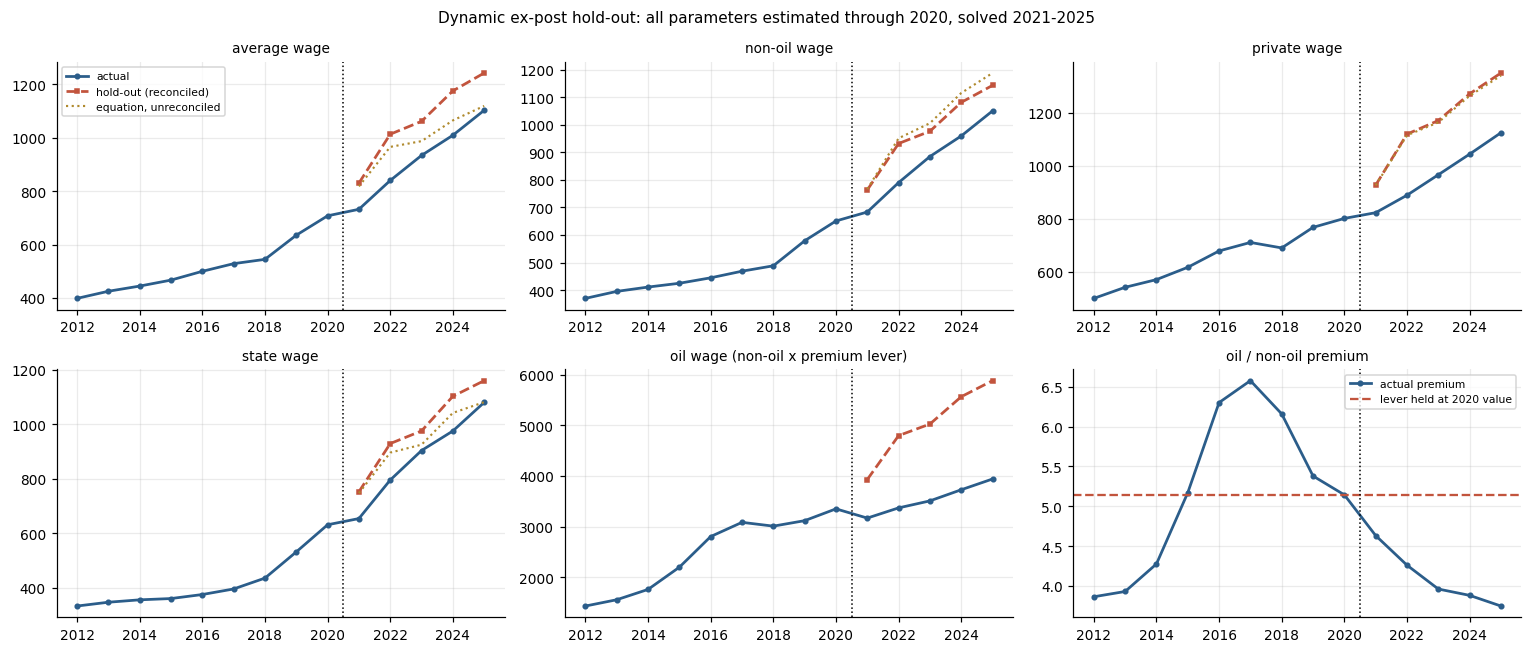

In [29]:
fig, ax = plt.subplots(2, 3, figsize=(14, 6))
for i, (k, lbl) in enumerate(TARGETS3.items()):
    a = ax[i//3, i%3]
    hist = W[k].loc[2012:LAST_ACT]
    a.plot(hist.index, hist.values, 'o-', color=PAL[0], lw=1.8, ms=3, label='actual')
    a.plot(HO3.index, HO3[k].values, 's--', color=PAL[1], lw=1.8, ms=3, label='hold-out (reconciled)')
    if k in HO3_RAW: a.plot(HO3_RAW.index, HO3_RAW[k].values, ':', color=PAL[3], lw=1.4, label='equation, unreconciled')
    a.axvline(CUT3+.5, color='k', ls=':', lw=1); a.set_title(lbl, fontsize=9)
    if i == 0: a.legend(fontsize=7)
a = ax[1, 2]
a.plot(W.prem_oil.loc[2012:LAST_ACT], 'o-', color=PAL[0], lw=1.8, ms=3, label='actual premium')
a.axhline(PREM_HO, color=PAL[1], ls='--', lw=1.5, label=f'lever held at {CUT3} value')
a.axvline(CUT3+.5, color='k', ls=':', lw=1); a.legend(fontsize=7); a.set_title('oil / non-oil premium', fontsize=9)
plt.suptitle(f'Dynamic ex-post hold-out: all parameters estimated through {CUT3}, solved {CUT3+1}-{LAST_ACT}', fontsize=10)
plt.tight_layout(); plt.show()


## Part 14 — Nowcasting 2026 from monthly actuals

Every published wage series has observations for **January and February 2026**. The workbook's monthly columns hold the
**cumulative-period average**, not a cumulated flow, and the annual figure exceeds the early-year average because of year-end
bonuses. The nowcast divides the 2026 January–February average by the **average ratio of that window to the annual average over
2021–2025** (a seasonal factor). A backtest gives the nowcast error band, which enters the fan charts. The nowcast increment
over the model applies fully in 2026 and then **decays with a one-year half-life** (a judgemental adjustment rule, not a model
of the dependent variable).


In [30]:
def month_frame(name):
    m = MON.get(name)
    if m is None or not len(m): return None
    df = pd.DataFrame({'v': m})
    df['year']  = [i[0] for i in df.index]
    df['month'] = [i[1] for i in df.index]
    return df.pivot_table(index='year', columns='month', values='v')

WAGE_SERIES = {'w_avg':'average wage','w_oil':'oil sector','w_non':'non-oil sector',
               'w_state':'state sector','w_priv':'private sector'}
# REVISION: the nowcast divides the 2026 year-to-date average by the MULTI-YEAR AVERAGE ratio of the
# same window to the annual average (a seasonal factor), instead of applying one year's y/y ratio to
# the 2025 level. A backtest of both rules gives the nowcast error band.
rows, bt = [], []
for k, lbl in WAGE_SERIES.items():
    piv = month_frame(k)
    if piv is None or NOWCAST_Y not in piv.index: continue
    m_last = int(piv.loc[NOWCAST_Y].dropna().index.max())
    ytd = piv[m_last].dropna()
    ratio = (ytd/W[k]).dropna()                                  # window average / annual average
    ratio = ratio.loc[:LAST_ACT]
    for y in ratio.index[1:]:                                     # backtest: use only earlier years' ratios
        prior = ratio.loc[:y-1]
        nc_avg = ytd[y]/prior.mean()
        nc_yoy = W[k][y-1]*ytd[y]/ytd[y-1]
        bt.append(dict(series=lbl, key=k, year=y, n_prior=len(prior),
                       err_avg_ratio=(nc_avg/W[k][y]-1)*100, err_yoy=(nc_yoy/W[k][y]-1)*100))
    rows.append(dict(series=lbl, key=k, months_observed=m_last, ytd_2026=ytd[NOWCAST_Y],
                     ratio_years=f"{ratio.index.min()}-{ratio.index.max()}", avg_ratio=ratio.mean(),
                     ratio_min=ratio.min(), ratio_max=ratio.max(),
                     nowcast=ytd[NOWCAST_Y]/ratio.mean(),
                     nowcast_old_yoy=W[k][LAST_ACT]*ytd[NOWCAST_Y]/ytd[LAST_ACT], full_2025=W[k][LAST_ACT]))
NC3 = pd.DataFrame(rows).set_index('series')
NCBT = pd.DataFrame(bt)
band = NCBT.groupby('series').agg(rmse_avg_ratio=('err_avg_ratio', lambda e: np.sqrt((e**2).mean())),
                                  rmse_yoy=('err_yoy', lambda e: np.sqrt((e**2).mean())),
                                  min_err=('err_avg_ratio', 'min'), max_err=('err_avg_ratio', 'max'), n=('year', 'size'))
NC3 = NC3.join(band)
NC3['growth_2026_%'] = (NC3.nowcast/NC3.full_2025 - 1)*100
NC3['band_lo'] = NC3.nowcast*(1 - NC3.rmse_avg_ratio/100); NC3['band_hi'] = NC3.nowcast*(1 + NC3.rmse_avg_ratio/100)
print("backtest of the two nowcast rules (error of the annual average, %):")
display(NCBT.pivot_table(index='year', columns='series', values=['err_avg_ratio', 'err_yoy']).round(2))
display(NC3.drop(columns='key').round(3))
NOWCAST_W  = {r.key: float(r.nowcast) for _, r in NC3.iterrows()}
NOWCAST_SE = {r.key: float(r.rmse_avg_ratio)/100 for _, r in NC3.iterrows()}
NC_ERR = NCBT.pivot_table(index='year', columns='key', values='err_avg_ratio')/100   # joint error vectors
print(f"\n{NOWCAST_Y} nominal wage nowcasts, AZN per month (+- backtest RMSE):")
for k, lbl in WAGE_SERIES.items():
    if k in NOWCAST_W:
        print(f"   {lbl:<16} {NOWCAST_W[k]:8.1f}  +-{NOWCAST_SE[k]*100:4.1f}%   ({LAST_ACT}: {W[k][LAST_ACT]:8.1f}, "
              f"{(NOWCAST_W[k]/W[k][LAST_ACT]-1)*100:+5.2f}%;  old y/y rule {NC3.loc[lbl,'nowcast_old_yoy']:8.1f})")
print(f"\nimplied {NOWCAST_Y} oil / non-oil premium: {NOWCAST_W['w_oil']/NOWCAST_W['w_non']:.2f}x   ({LAST_ACT}: {W.prem_oil[LAST_ACT]:.2f}x)")
print(f"implied {NOWCAST_Y} state / private ratio : {NOWCAST_W['w_state']/NOWCAST_W['w_priv']:.3f}   ({LAST_ACT}: {W.prem_sp[LAST_ACT]:.3f})")
_b = NC3[['rmse_avg_ratio', 'rmse_yoy']]
print(f"\nbacktest RMSE, multi-year seasonal ratio vs single-year y/y rule: "
      + "; ".join(f"{i} {r.rmse_avg_ratio:.2f} vs {r.rmse_yoy:.2f}" for i, r in _b.iterrows()))
print("The multi-year ratio is not more accurate in this short backtest; it is preferred because it does not")
print("rest on a single year's January-February seasonality, and its error band is carried into the fan charts.")
print(f'''
The seasonal ratio is observed only for {NC3.ratio_years.iloc[0]} (monthly data start in 2021), so the backtest has
{int(NC3.n.iloc[0])} years and the band is itself imprecise. The nowcast is a judgemental anchor with that error band, and
- contract decision 4 - its increment over the model applies fully in {NOWCAST_Y} and then decays with a
one-year half-life, rather than being held to {H_END}.''')


backtest of the two nowcast rules (error of the annual average, %):


err_avg_ratio                                                            err_yoy                                                      
series  average wage non-oil sector oil sector private sector state sector average wage non-oil sector oil sector private sector state sector
year                                                                                                                                         
2022          -3.280         -2.090    -10.700         -2.370       -4.250       -3.280         -2.090    -10.700         -2.370       -4.250
2023          -1.630         -1.100     -6.740         -1.170       -2.280        0.040         -0.040     -1.150          0.030       -0.110
2024           1.390          1.560     -0.740          1.330        1.400        2.510          2.310      4.040          2.130        2.980
2025           1.930          2.170     -0.310          2.000        1.610        0.880          0.990      0.250          1.000        0.560

,months_observed,ytd_2026,ratio_years,avg_ratio,ratio_min,ratio_max,nowcast,nowcast_old_yoy,full_2025,rmse_avg_ratio,rmse_yoy,min_err,max_err,n,growth_2026_%,band_lo,band_hi
series,,,,,,,,,,,,,,,,,
average wage,2,"1,099.100",2021-2025,0.932,0.915,0.946,"1,179.425","1,161.554","1,102.900",2.183,2.112,-3.277,1.931,4,6.939,"1,153.673","1,205.176"
oil sector,2,"4,006.800",2021-2025,0.927,0.887,1.005,"4,320.249","4,330.849","3,938.600",6.335,5.748,-10.699,-0.306,4,9.690,"4,046.552","4,593.945"
non-oil sector,2,"1,046.500",2021-2025,0.931,0.916,0.947,"1,124.448","1,105.305","1,050.700",1.786,1.638,-2.093,2.174,4,7.019,"1,104.367","1,144.529"
state sector,2,"1,070.800",2021-2025,0.917,0.897,0.938,"1,167.156","1,152.365","1,080.800",2.638,2.612,-4.254,1.610,4,7.990,"1,136.361","1,197.951"
private sector,2,"1,126.700",2021-2025,0.949,0.935,0.964,"1,187.126","1,168.476","1,124.400",1.787,1.670,-2.372,2.003,4,5.579,"1,165.911","1,208.341"



2026 nominal wage nowcasts, AZN per month (+- backtest RMSE):
   average wage       1179.4  +- 2.2%   (2025:   1102.9, +6.94%;  old y/y rule   1161.6)
   oil sector         4320.2  +- 6.3%   (2025:   3938.6, +9.69%;  old y/y rule   4330.8)
   non-oil sector     1124.4  +- 1.8%   (2025:   1050.7, +7.02%;  old y/y rule   1105.3)
   state sector       1167.2  +- 2.6%   (2025:   1080.8, +7.99%;  old y/y rule   1152.4)
   private sector     1187.1  +- 1.8%   (2025:   1124.4, +5.58%;  old y/y rule   1168.5)

implied 2026 oil / non-oil premium: 3.84x   (2025: 3.75x)
implied 2026 state / private ratio : 0.983   (2025: 0.961)

backtest RMSE, multi-year seasonal ratio vs single-year y/y rule: average wage 2.18 vs 2.11; oil sector 6.34 vs 5.75; non-oil sector 1.79 vs 1.64; state sector 2.64 vs 2.61; private sector 1.79 vs 1.67
The multi-year ratio is not more accurate in this short backtest; it is preferred because it does not
rest on a single year's January-February seasonality, and its error b

## Part 15 — Scenarios and the 2026–2030 forecast

### 15.1 What is exogenous to the wage block

The macro drivers come from **FR1's three scenarios** — productivity (from sector value added and employment), the price level,
and employment — so FR3 and FR1 describe the same economy. FR3 adds two levers of its own, because both are wage-policy
decisions rather than macro outcomes:

| Lever | Baseline | Adverse | Reform |
|---|---|---|---|
| **Minimum wage**, nominal growth p.a. | 6% (continues indexation at roughly the pace of average pay) | 3% (fiscal restraint) | 9% (accelerated floor) |
| **Oil / non-oil premium** path | continues compressing to 3.4× by 2030 | compresses faster, to 3.2× | stabilises at 3.7× |

The premium is a lever and not a forecast for the reason Part 10.3 established: its recent compression is a structural break
that no estimated relationship anticipates, so the honest treatment is to make the assumption explicit and adjustable. The
path starts from the premium implied by the 2026 monthly data and glides linearly to the target. Hired employment follows FR1's
total employment at the 2025 hired share, starting from the DVX level; the state/private and oil employment shares are held.
FR3 uses no population assumption.

In [31]:
FY3 = [y for y in FY if y <= H_END]
MW_GROWTH   = {'Baseline': 0.06, 'Adverse': 0.03, 'Reform': 0.09}
PREM_TARGET = {'Baseline': 3.40, 'Adverse': 3.20, 'Reform': 3.70}

def build_ex(fc, scen):
    '''Exogenous driver paths for the wage block from one FR1 macro path (a scenario or a bootstrap
    draw; `fc` is indexed by year) plus FR3's own policy levers.'''
    ex, mw = {}, float(W.minwage[LAST_ACT])
    hired0, emp0 = float(W.hired_dvx[LAST_ACT]), float(W.emp_tot[LAST_ACT])
    for i, y in enumerate(FY3):
        mw *= (1 + MW_GROWTH[scen])
        emp_t = float(fc.loc[y, 'emp'])
        hired = hired0*emp_t/emp0                           # hired share of employment held at 2025
        ex[y] = dict(cpi=float(fc.loc[y, 'cpi']), prod_tot=float(fc.loc[y, 'rgdp'])/emp_t,
                     prod_non=float(fc.loc[y, 'rgdpnon'])/(emp_t*(1 - OIL_EMP_SHARE)),   # non-oil employment
                     exp_per_emp=float(fc.loc[y, 'rexp_cur'])/emp_t, minwage=mw, D18=1.0, hired=hired,
                     e_state=hired*SH25['s_state']*(1-SH25['s_oil']), e_nonstate=hired*SH25['s_priv']*(1-SH25['s_oil']),
                     prem_target=PREM_TARGET[scen], year=y, i=i)
    return ex

def build_wage_scenario(scen):
    return build_ex(FC1[FC1.scenario == scen], scen)

SCEN3 = {s: build_wage_scenario(s) for s in SCEN_NAMES}
tab = []
for s, ex in SCEN3.items():
    for y in FY3:
        tab.append(dict(scenario=s, year=y, minimum_wage=ex[y]['minwage'], cpi=ex[y]['cpi'],
                        productivity=ex[y]['prod_tot'], non_oil_productivity=ex[y]['prod_non'],
                        hired_employment=ex[y]['hired'], premium_target=ex[y]['prem_target']))
display(pd.DataFrame(tab).set_index(['scenario','year']).round(2))
print(f"hired employment starts from the DVX {LAST_ACT} level ({W.hired[LAST_ACT]:,.1f} thousand), the same level the")
print("spliced history ends on, so the wage bill has no break at the forecast origin (Part 3).")


minimum_wage     cpi  productivity  non_oil_productivity  hired_employment  premium_target
scenario year                                                                                            
Baseline 2026       424.000 198.730        12.180                10.140         2,070.960           3.400
         2027       449.440 208.480        12.460                10.660         2,085.550           3.400
         2028       476.410 218.280        12.760                11.130         2,099.750           3.400
         2029       504.990 228.290        13.070                11.580         2,113.790           3.400
         2030       535.290 238.690        13.410                12.030         2,127.840           3.400
Adverse  2026       412.000 198.720        12.180                10.140         2,070.950           3.200
         2027       424.360 207.450        12.260                10.490         2,084.340           3.200
         2028       437.090 216.340        12.400                10.800         2,097.570           3.200
         2029       450.200 225.510        12.580                11.110         2,110.770           3.200
         2030       463.710 235.000        12.760                11.420         2,123.990           3.200
Reform   2026       436.000 198.740        12.180                10.140         2,070.970           3.700
         2027       475.240 209.320        12.630                10.810         2,086.530           3.700
         2028       518.010 219.950        13.080                11.420         2,101.620           3.700
         2029       564.630 230.870        13.530                12.020         2,116.550           3.700
         2030       615.450 242.240        14.020                12.640         2,131.510           3.700

hired employment starts from the DVX 2025 level (2,059.9 thousand), the same level the
spliced history ends on, so the wage bill has no break at the forecast origin (Part 3).


In [32]:
HALF_LIFE = 1.0                                   # nowcast increment: full in 2026, factor 0.5 per year after

def run_wage_forecast(scen, ex=None, coefs=None, addf_base=None, nowcast=None, var=None,
                      base_decay=None, mw_override=None, prem_override=None, shock=None, prem_shock=None):
    '''Solve the wage block forward for one scenario (or one bootstrap replication).
    Add-factors: base = each equation's own 2025 residual, held constant (decision 4) - or decaying at
    rho^h when base_decay is given (sensitivity); plus the 2026 nowcast increment, decaying with a
    one-year half-life; plus an optional level shock path (bootstrap).'''
    ex = {y: dict(v) for y, v in (ex or SCEN3[scen]).items()}
    coefs = coefs or CF3; var = var or VAR_REC
    nowcast = NOWCAST_W if nowcast is None else nowcast
    if mw_override is not None:
        mw = float(W.minwage[LAST_ACT])
        for y in FY3: mw *= (1 + mw_override); ex[y]['minwage'] = mw
    base = addf_base if addf_base is not None else base_addf(coefs, LAST_ACT)
    def addf_at(y, inc):
        h = y - LAST_ACT
        a = {nm: base[nm]*(base_decay[nm]**h if base_decay else 1.0) + inc.get(nm, 0.0)*0.5**((y-NOWCAST_Y)/HALF_LIFE)
             for nm in FC_EQS}
        if shock is not None:
            for nm in FC_EQS: a[nm] += shock[nm].get(y, 0.0)
        return a
    # nowcast increment: what each equation needs, on top of its base add-factor, to hit the nowcast
    x0 = eq_values(ex[NOWCAST_Y], coefs, addf_at(NOWCAST_Y, {}))
    inc = {EQ_OF3[k]: float(np.log(nowcast[k]/x0[k])) for k in EQ_OF3}
    prem_start = nowcast['w_oil']/nowcast['w_non']
    out = {}
    for y in FY3:
        if prem_override is not None: prem_y = prem_override
        elif y == FY3[0]: prem_y = prem_start
        else: prem_y = prem_start + (ex[y]['prem_target'] - prem_start)*(y - FY3[0])/max(len(FY3)-1, 1)
        if prem_shock is not None: prem_y *= float(np.exp(prem_shock.get(y, 0.0)))
        sol = solve_year(ex[y], coefs, addf_at(y, inc), SH25, KAP25, prem_y, var)
        sol['balance_factor'] = sol['factor_w_priv']
        sol['wagebill'] = sol['w_avg']*ex[y]['hired']*12/1000
        sol['minwage'] = ex[y]['minwage']; sol['cpi'] = ex[y]['cpi']
        sol['hired'] = ex[y]['hired']; sol['kaitz'] = ex[y]['minwage']/sol['w_avg']
        for nm in FC_EQS: sol['nowcast_incr_'+VAR_OF[nm]] = inc[nm]*0.5**((y-NOWCAST_Y)/HALF_LIFE)
        out[y] = sol
    return pd.DataFrame(out).T, inc

FC3, INC3 = {}, {}
for s in SCEN_NAMES:
    FC3[s], INC3[s] = run_wage_forecast(s)
BASE25 = base_addf(CF3, LAST_ACT)
print("add-factors (log points): base = own 2025 residual (constant); nowcast increment (full in 2026, x0.5 per year):")
display(pd.DataFrame({'base (2025 residual)': pd.Series(BASE25), 'nowcast increment 2026': pd.Series(INC3['Baseline']),
                      'increment by 2030': pd.Series(INC3['Baseline'])*0.5**(H_END-NOWCAST_Y)}).rename(index=VAR_OF).round(4))

print(f"\n{NOWCAST_Y}: nowcast targets vs the reconciled model (both identities imposed):")
anch = pd.DataFrame({'nowcast': NOWCAST_W, 'model (reconciled)': {k: FC3['Baseline'][k][NOWCAST_Y] for k in NOWCAST_W}})
anch['difference %'] = (anch['model (reconciled)']/anch['nowcast'] - 1)*100
anch['nowcast band +-%'] = pd.Series(NOWCAST_SE)*100
display(anch.round(3))
print("the reconciliation moves the nowcasts by far less than their own backtest error band.")

print("\nJOINT RECONCILIATION - reconciled level / equation level (baseline). E1 is NOT a constraint: its column is the")
print("CROSS-CHECK ratio of the reconciled aggregate to E1's own prediction:")
REC_FAC = FC3['Baseline'][[f'factor_{k}' for k in ['w_avg', 'w_state', 'w_priv', 'w_non']]].astype(float)
display(REC_FAC.round(4))
_g = max(max(FC3[s].agg_gap_pct.abs().max(), FC3[s].oil_split_gap_pct.abs().max()) for s in SCEN_NAMES)
print(f"identity residuals, all scenarios and years, both breakdowns: {_g:.1e}%")
assert _g < 1e-6, "an aggregation identity is not holding"
print("institutional: w_avg = k1 x (state/private employment-weighted); oil/non-oil: w_avg = k2 x (oil/non-oil")
print(f"weighted), with the data's own {LAST_ACT} discrepancies k1={KAP25['k1']:.4f}, k2={KAP25['k2']:.4f} held fixed.")

# sensitivity 1: reconcile TO E1 (aggregate fixed); sensitivity 2: base add-factors decaying at rho
RHO = {nm: float(np.clip(REG[nm]['rho'], 0, 1)) for nm in FC_EQS}
FC3_E1FIX = run_wage_forecast('Baseline', var={**VAR_REC, 'w_avg': 0.0})[0]
FC3_RHO = run_wage_forecast('Baseline', base_decay=RHO)[0]
FC3_E1W = run_wage_forecast('Baseline', var={**VAR_REC, 'w_avg': E1_MSE})[0]
def cagr(s, k): return ((s[k][H_END]/W[k][LAST_ACT])**(1/len(FY3)) - 1)*100
SENS3 = pd.DataFrame({'main (joint WLS, constant base add-factors)': {k: cagr(FC3['Baseline'], k) for k in WAGE_SERIES},
                      'reconciled TO E1 (aggregate fixed)': {k: cagr(FC3_E1FIX, k) for k in WAGE_SERIES},
                      'E1 as a weighted constraint (rolling MSE)': {k: cagr(FC3_E1W, k) for k in WAGE_SERIES},
                      'base add-factors decay at rho': {k: cagr(FC3_RHO, k) for k in WAGE_SERIES}})
def alt_run(changes):
    '''Forecast with some equations replaced by an alternative specification (full-sample DOLS).'''
    keep_s, keep_c = dict(SPEC), dict(CF3)
    for nm, sp in changes.items():
        SPEC[nm] = sp; y_, X_, d_ = design(sp); CF3[nm] = estimate_lr(y_, X_, d_).lr
    out = run_wage_forecast('Baseline', coefs=CF3)[0]
    coef = {nm: dict(CF3[nm]) for nm in changes}
    SPEC.update(keep_s); CF3.update(keep_c)
    return out, coef
E3_UNR = dict(SPEC['E3_w_priv'], form='nominal')
FC3_E3U, cE3U = alt_run({'E3_w_priv': E3_UNR})
SENS3['E3 unrestricted (ln CPI free, homogeneity not imposed)'] = {k: cagr(FC3_E3U, k) for k in WAGE_SERIES}
E3_MW = dict(SPEC['E3_w_priv'], regs=['prod_non', 'mw'], form='real')
FC3_E3M, cE3M = alt_run({'E3_w_priv': E3_MW})
SENS3['E3 with the minimum wage (fails lever coherence)'] = {k: cagr(FC3_E3M, k) for k in WAGE_SERIES}
E4_UNR = dict(SPEC['E4_w_state'], form='nominal')
FC3_E4U, cE4U = alt_run({'E4_w_state': E4_UNR})
SENS3['E4 unrestricted (ln CPI free)'] = {k: cagr(FC3_E4U, k) for k in WAGE_SERIES}
E4_D18 = dict(dep='w_state', regs=['prod_non', 'mw'], form='real', dummies=('D18',))
FC3_E4D, cE4D = alt_run({'E4_w_state': E4_D18})
SENS3['E4 = productivity + minimum wage + 2018 dummy (unscored)'] = {k: cagr(FC3_E4D, k) for k in WAGE_SERIES}
E4_D18_MW = float(cE4D['E4_w_state']['ln_rmw']); E3U_CPI = float(cE3U['E3_w_priv']['ln_cpi'])
print(f"E3 with the minimum wage: coefficient {float(cE3M['E3_w_priv']['ln_rmw']):+.3f}")
print(f"sensitivity equations: E3 unrestricted ln CPI elasticity {E3U_CPI:.3f}; E4 with D18 minimum-wage elasticity {E4_D18_MW:.3f}")
SENS3.index = [WAGE_SERIES[k] for k in SENS3.index]
print("\nSENSITIVITY - baseline nominal growth 2025-2030, % per year:")
display(SENS3.round(2))

# FR1's own wage column against FR3's average wage
print("\nFR3 average wage against FR1's 'wage' column (FR1 forecasts the same DSK series with its own equation):")
cmp1 = pd.DataFrame({s: (FC3[s].w_avg/FC1[FC1.scenario == s].wage.reindex(FY3) - 1)*100 for s in SCEN_NAMES})
FR1_GAP = pd.concat({'FR3 w_avg': FC3['Baseline'].w_avg, 'FR1 wage': FC1[FC1.scenario == 'Baseline'].wage.reindex(FY3)}, axis=1)
FR1_GAP['gap %'] = cmp1['Baseline']
display(FR1_GAP.round(2)); print("gap %, all scenarios:"); display(cmp1.round(2))
print(f"The two modules differ by {cmp1.min().min():+.1f}% to {cmp1.max().max():+.1f}% in level: FR1's wage equation is a")
print("macro-block relation, FR3's is the reconciled structural wage block anchored on the 2026 monthly data.")
print("FR3 is the published wage forecast; FR1's wage enters only FR1's own household-income block.")


add-factors (log points): base = own 2025 residual (constant); nowcast increment (full in 2026, x0.5 per year):


,base (2025 residual),nowcast increment 2026,increment by 2030
w_avg,0.139,0.036,0.002
w_non,0.043,0.033,0.002
w_priv,-0.092,0.020,0.001
w_state,0.077,0.033,0.002



2026: nowcast targets vs the reconciled model (both identities imposed):


,nowcast,model (reconciled),difference %,nowcast band +-%
w_avg,"1,179.425","1,179.098",-0.028,2.183
w_oil,"4,320.249","4,306.308",-0.323,6.335
w_non,"1,124.448","1,120.820",-0.323,1.786
w_state,"1,167.156","1,173.349",0.531,2.638
w_priv,"1,187.126","1,187.944",0.069,1.787


the reconciliation moves the nowcasts by far less than their own backtest error band.

JOINT RECONCILIATION - reconciled level / equation level (baseline). E1 is NOT a constraint: its column is the
CROSS-CHECK ratio of the reconciled aggregate to E1's own prediction:


...


FR3 average wage against FR1's 'wage' column (FR1 forecasts the same DSK series with its own equation):


,FR3 w_avg,FR1 wage,gap %
2026,"1,179.100","1,137.760",3.630
2027,"1,266.100","1,231.570",2.800
2028,"1,360.140","1,324.250",2.710
2029,"1,461.310","1,418.870",2.990
2030,"1,571.280","1,518.560",3.470


gap %, all scenarios:


,Baseline,Adverse,Reform
2026,3.630,3.650,3.620
2027,2.800,2.290,3.330
2028,2.710,1.740,3.740
2029,2.990,1.580,4.510
2030,3.470,1.640,5.490


The two modules differ by +1.6% to +5.5% in level: FR1's wage equation is a
macro-block relation, FR3's is the reconciled structural wage block anchored on the 2026 monthly data.
FR3 is the published wage forecast; FR1's wage enters only FR1's own household-income block.


### 15.2 Forecast results — levels and growth rates, by every available breakdown

In [33]:
def wage_table(scen):
    f = FC3[scen]
    t = pd.DataFrame(index=FY3)
    for k, lbl in WAGE_SERIES.items():
        s = pd.concat([pd.Series({LAST_ACT: W[k][LAST_ACT]}), f[k]])
        t[f'{lbl} (AZN)'] = f[k]
        t[f'{lbl} growth %'] = (s.pct_change()*100).loc[FY3]
    t['CPI inflation %'] = (pd.concat([pd.Series({LAST_ACT: W.cpi[LAST_ACT]}), f.cpi])
                            .pct_change()*100).loc[FY3]
    t['real average wage growth %'] = t['average wage growth %'] - t['CPI inflation %']
    t['minimum wage (AZN)'] = f.minwage
    t['Kaitz index'] = f.kaitz
    t['oil premium'] = f.prem_oil
    t['state / private'] = f.w_state/f.w_priv
    t['wage bill (mln AZN)'] = f.wagebill
    return t

ORDER = pd.DataFrame({s: {WAGE_SERIES[k]: ((FC3[s][k][H_END]/FC3[s].cpi[H_END])/(W[k][LAST_ACT]/W.cpi[LAST_ACT]))**(1/len(FY3))*100-100
                         for k in WAGE_SERIES} for s in SCEN_NAMES})
ORDER['Adverse <= Baseline <= Reform'] = (ORDER.Adverse <= ORDER.Baseline) & (ORDER.Baseline <= ORDER.Reform)
print("SCENARIO ORDERING - real growth 2025-2030, % a year:")
display(ORDER.round(2))
for s in SCEN_NAMES:
    print("="*118); print(f"{s.upper()}".center(118)); print("="*118)
    display(wage_table(s).round(2).T)
    g = (FC3[s].w_avg[H_END]/W.w_avg[LAST_ACT])**(1/len(FY3)) - 1
    gr = ((FC3[s].w_avg[H_END]/FC3[s].cpi[H_END])/(W.w_avg[LAST_ACT]/W.cpi[LAST_ACT]))**(1/len(FY3)) - 1
    print(f"   average nominal wage growth {FY3[0]}-{H_END}: {g*100:+.2f}% per year")
    print(f"   average REAL wage growth    {FY3[0]}-{H_END}: {gr*100:+.2f}% per year\n")

SCENARIO ORDERING - real growth 2025-2030, % a year:


,Baseline,Adverse,Reform,Adverse <= Baseline <= Reform
average wage,2.780,1.670,3.900,True
oil sector,0.960,-1.240,3.650,True
non-oil sector,2.950,1.940,3.920,True
state sector,4.160,2.260,6.050,True
private sector,1.680,1.210,2.130,True


                                                       BASELINE                                                       


,2026,2027,2028,2029,2030
average wage (AZN),"1,179.100","1,266.100","1,360.140","1,461.310","1,571.280"
average wage growth %,6.910,7.380,7.430,7.440,7.520
oil sector (AZN),"4,306.310","4,502.730","4,706.190","4,914.750","5,131.650"
oil sector growth %,9.340,4.560,4.520,4.430,4.410
non-oil sector (AZN),"1,120.820","1,206.660","1,299.670","1,400.000","1,509.310"
non-oil sector growth %,6.670,7.660,7.710,7.720,7.810
state sector (AZN),"1,173.350","1,275.510","1,387.920","1,510.620","1,645.890"
state sector growth %,8.560,8.710,8.810,8.840,8.950
private sector (AZN),"1,187.940","1,263.270","1,343.130","1,427.640","1,517.990"
private sector growth %,5.650,6.340,6.320,6.290,6.330


   average nominal wage growth 2026-2030: +7.34% per year
   average REAL wage growth    2026-2030: +2.78% per year

                                                       ADVERSE                                                        


,2026,2027,2028,2029,2030
average wage (AZN),"1,179.100","1,239.030","1,307.640","1,383.370","1,465.100"
average wage growth %,6.910,5.080,5.540,5.790,5.910
oil sector (AZN),"4,306.310","4,352.560","4,409.990","4,469.720","4,524.920"
oil sector growth %,9.340,1.070,1.320,1.350,1.240
non-oil sector (AZN),"1,120.820","1,182.250","1,252.460","1,330.060","1,414.040"
non-oil sector growth %,6.670,5.480,5.940,6.200,6.310
state sector (AZN),"1,173.350","1,233.810","1,306.320","1,388.330","1,478.060"
state sector growth %,8.560,5.150,5.880,6.280,6.460
private sector (AZN),"1,187.940","1,247.680","1,313.440","1,384.490","1,460.180"
private sector growth %,5.650,5.030,5.270,5.410,5.470


   average nominal wage growth 2026-2030: +5.84% per year
   average REAL wage growth    2026-2030: +1.67% per year

                                                        REFORM                                                        


,2026,2027,2028,2029,2030
average wage (AZN),"1,179.100","1,289.970","1,409.270","1,539.600","1,683.250"
average wage growth %,6.910,9.400,9.250,9.250,9.330
oil sector (AZN),"4,306.310","4,671.570","5,060.220","5,480.690","5,940.040"
oil sector growth %,9.340,8.480,8.320,8.310,8.380
non-oil sector (AZN),"1,120.820","1,227.240","1,341.860","1,467.180","1,605.420"
non-oil sector growth %,6.670,9.490,9.340,9.340,9.420
state sector (AZN),"1,173.350","1,313.530","1,466.740","1,636.920","1,827.740"
state sector growth %,8.560,11.950,11.660,11.600,11.660
private sector (AZN),"1,187.940","1,276.040","1,368.960","1,468.240","1,575.100"
private sector growth %,5.650,7.420,7.280,7.250,7.280


   average nominal wage growth 2026-2030: +8.82% per year
   average REAL wage growth    2026-2030: +3.90% per year



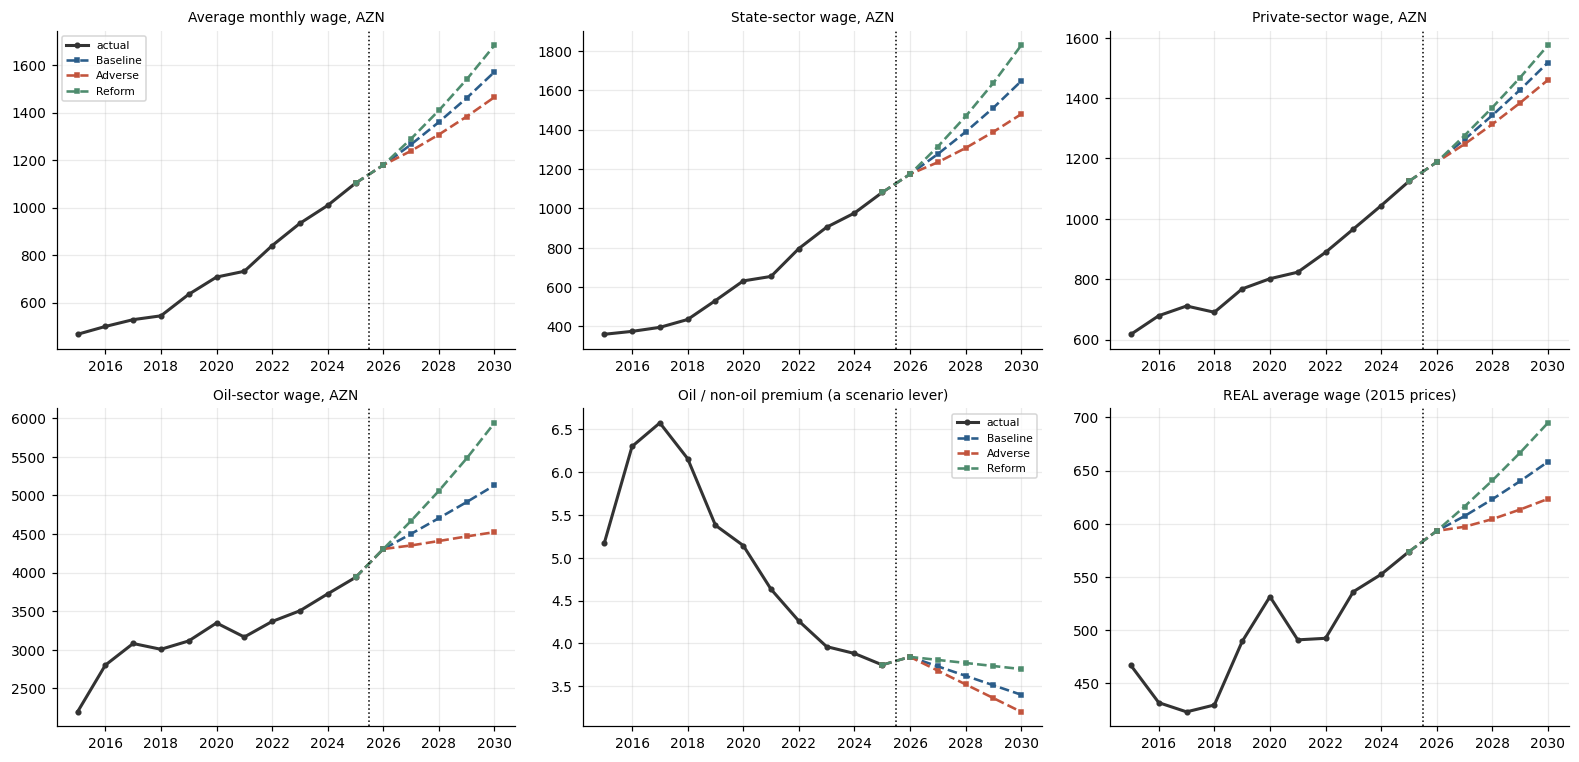

In [34]:
fig, ax = plt.subplots(2, 3, figsize=(14.5, 7))
COLS = dict(zip(SCEN_NAMES, [PAL[0], PAL[1], PAL[2]]))
def panel(a, key, title, hist_from=2015):
    h = W[key].loc[hist_from:LAST_ACT] if key in W.columns else None
    if h is not None:
        a.plot(h.index, h.values, 'o-', color='#333', lw=2, ms=3, label='actual')
    for s in SCEN_NAMES:
        ser = pd.concat([pd.Series({LAST_ACT: W[key][LAST_ACT]}), FC3[s][key]]) if key in W.columns \
              else FC3[s][key]
        a.plot(ser.index, ser.values, 's--', color=COLS[s], lw=1.7, ms=3, label=s)
    a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1); a.set_title(title, fontsize=9)
panel(ax[0,0], 'w_avg',   'Average monthly wage, AZN'); ax[0,0].legend(fontsize=7)
panel(ax[0,1], 'w_state', 'State-sector wage, AZN')
panel(ax[0,2], 'w_priv',  'Private-sector wage, AZN')
panel(ax[1,0], 'w_oil',   'Oil-sector wage, AZN')
a = ax[1,1]
h = W.prem_oil.loc[2015:LAST_ACT]
a.plot(h.index, h.values, 'o-', color='#333', lw=2, ms=3, label='actual')
for s in SCEN_NAMES:
    ser = pd.concat([pd.Series({LAST_ACT: W.prem_oil[LAST_ACT]}), FC3[s].prem_oil])
    a.plot(ser.index, ser.values, 's--', color=COLS[s], lw=1.7, ms=3, label=s)
a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1)
a.set_title('Oil / non-oil premium (a scenario lever)', fontsize=9); a.legend(fontsize=7)
a = ax[1,2]
h = (W.w_avg/W.cpi*100).loc[2015:LAST_ACT]
a.plot(h.index, h.values, 'o-', color='#333', lw=2, ms=3)
for s in SCEN_NAMES:
    ser = pd.concat([pd.Series({LAST_ACT: W.w_avg[LAST_ACT]/W.cpi[LAST_ACT]*100}),
                     FC3[s].w_avg/FC3[s].cpi*100])
    a.plot(ser.index, ser.values, 's--', color=COLS[s], lw=1.7, ms=3)
a.axvline(LAST_ACT+.5, color='k', ls=':', lw=1)
a.set_title('REAL average wage (2015 prices)', fontsize=9)
plt.tight_layout(); plt.show()

### 15.3 Forecast uncertainty — fan charts

The bands combine four sources:

1. **Historical residual paths.** For each replication a start year *s* is drawn from the history and the joint vector of
   deviations $e_h = u_{s+h} - u_s$ ($h$ = 1…4, applied to 2027–2030) of the four forecasting equations' long-run residuals
   **and** the log oil premium is added to the add-factors (and the premium path). This carries the empirical persistence and
   cross-equation correlation of past errors without estimating any residual process — no AR component (see the no-AR table
   below). 2026 is pinned by the nowcast and its own error.
2. **Parameter uncertainty** — each equation's long-run coefficients are drawn from N(β̂, V̂_HAC); the base add-factor is
   recomputed so that 2025 is reproduced.
3. **Nowcast error** — the 2026 anchors are perturbed by a joint normal draw with the covariance of the nowcast backtest errors.
4. **Macro-driver uncertainty** — each replication uses one of FR1's baseline bootstrap paths (`FR1_fan_draws.csv`); draws are
   screened only for non-finite values. Without the file a WARNING is printed and the drivers stay at FR1's baseline.

Growth bands are quantiles of per-replication growth rates. The minimum wage and premium *target* are levers and are not randomised.

**No-AR audit of the uncertainty and adjustment machinery**

| Element | Lagged terms? | Why it is not an autoregression |
|---|---|---|
| Residual-path resampling | uses observed historical residual paths | no parameter of residual dynamics is estimated; paths are resampled as observed |
| Base add-factors | none | each equation's own 2025 residual, held constant |
| Nowcast increment | decays ×0.5 a year | a judgemental adjustment rule for partial-year data, not a model of the dependent variable |
| DOLS | leads/lags of regressor differences | the dependent variable's own lags never enter |
| Lagged minimum wage | instrument only | enters first stages, never an equation for the minimum wage or a wage |


macro drivers: 500 FR1 baseline bootstrap paths


average-wage growth, 90% band from FR3's own sources only (residuals, parameters, nowcast):


,q05,q50,q95
year,,,
2026,3.300,6.800,10.900
2027,-3.000,6.100,18.700
2028,-3.900,6.900,18.500
2029,-4.200,6.000,18.400
2030,-4.100,6.100,18.800


sanity check - FR3-own 90% band half-width (log %, level) vs the 2021-25 hold-out RMSE:


year,2026,2027,2028,2029,2030,hold-out RMSE %
variable,,,,,,
w_avg,3.500,10.000,17.200,12.700,12.600,14.500
w_non,3.000,10.200,17.200,14.300,14.600,11.900
w_priv,2.900,8.600,13.800,13.100,13.700,18.800
w_state,4.100,14.400,22.000,20.300,20.400,11.800
w_oil,10.800,18.400,29.100,35.200,38.400,35.300


historical average-wage growth 2005-2025: min +3.0%, max +44.8%
1000 replications. Baseline 90% bands (5th-95th percentile):


q05       q50       q95   central
variable measure    year                                        
w_avg    level      2026 1,138.100 1,177.700 1,218.700 1,179.100
                    2027 1,062.700 1,253.400 1,498.700 1,266.100
                    2028 1,071.800 1,379.000 1,799.100 1,360.100
                    2029 1,062.900 1,473.900 2,080.500 1,461.300
                    2030 1,115.700 1,609.400 2,300.200 1,571.300
         growth_pct 2026     3.200     6.800    10.500       NaN
                    2027    -9.900     6.400    27.700       NaN
                    2028    -5.400    10.900    31.100       NaN
                    2029    -9.600     5.300    25.200       NaN
                    2030    -4.400     8.300    23.900       NaN
w_priv   level      2026 1,151.500 1,186.500 1,222.100 1,187.900
                    2027 1,035.200 1,252.600 1,516.600 1,263.300
                    2028 1,017.100 1,368.900 1,827.900 1,343.100
                    2029   993.100 1,432.000 2,002.600 1,427.600
                    2030 1,032.600 1,550.100 2,308.300 1,518.000
         growth_pct 2026     2.400     5.500     8.700       NaN
                    2027   -13.400     5.700    27.400       NaN
                    2028    -8.200     9.300    29.800       NaN
                    2029   -10.800     5.400    22.600       NaN
                    2030    -5.100     8.200    20.600       NaN
w_state  level      2026 1,124.000 1,172.400 1,221.200 1,173.300
                    2027 1,071.100 1,244.400 1,549.000 1,275.500
                    2028 1,094.700 1,396.200 1,872.400 1,387.900
                    2029 1,095.200 1,497.700 2,211.500 1,510.600
                    2030 1,141.200 1,646.100 2,430.900 1,645.900
         growth_pct 2026     4.000     8.500    13.000       NaN
                    2027    -8.800     6.700    32.700       NaN
                    2028    -6.400    10.200    35.000       NaN
                    2029    -9.400     5.600    31.300       NaN
                    2030    -5.500     7.200    32.000       NaN
w_oil    level      2026 3,866.600 4,297.900 4,756.700 4,306.300
                    2027 3,476.000 4,470.900 5,637.800 4,502.700
                    2028 3,325.800 4,739.300 7,059.600 4,706.200
                    2029 3,091.200 4,873.300 8,114.800 4,914.800
                    2030 3,029.200 5,069.000 9,385.300 5,131.600
         growth_pct 2026    -1.800     9.100    20.800       NaN
                    2027   -17.600     4.100    28.300       NaN
                    2028   -14.400     6.600    32.100       NaN
                    2029   -17.200     2.300    26.400       NaN
                    2030   -13.900     5.600    26.200       NaN

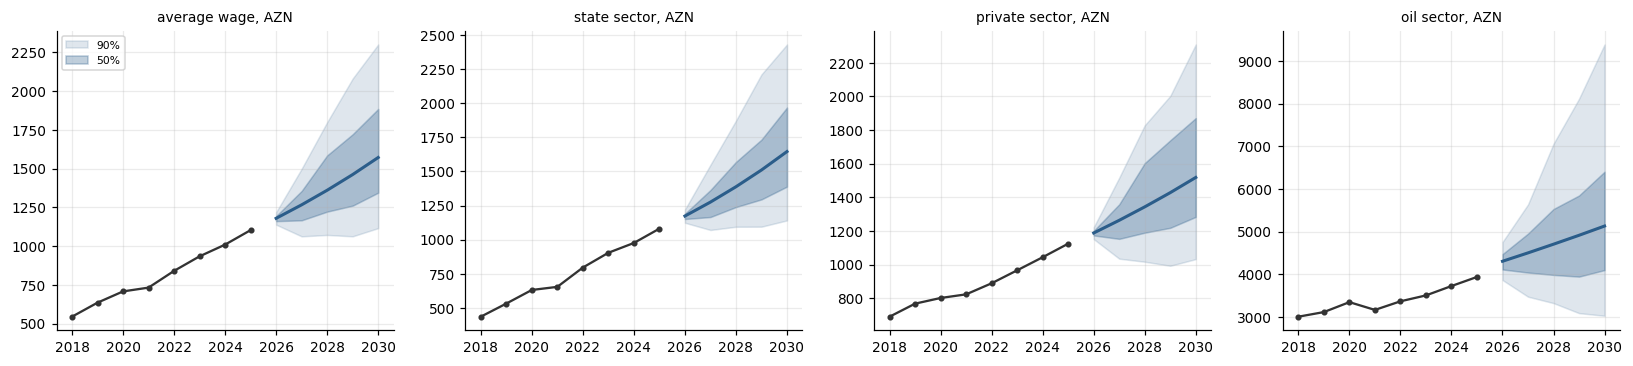

In [35]:
QS = [5, 10, 25, 50, 75, 90, 95]
rng_b = np.random.default_rng(SEED)
# HISTORICAL RESIDUAL-PATH RESAMPLING (no estimated residual dynamics - no AR component):
# for each replication draw a start year s and apply the joint vector of deviations
#   e_h = u_(s+h) - u_s,  h = 1..4  (forecast years 2027-2030; 2026 is pinned by the nowcast and its error)
# of the four equations' long-run residuals AND the log oil premium. This reproduces the empirical
# persistence and cross-equation correlation of the historical errors without fitting any process.
SHK = pd.concat([RES4, L(W.prem_oil).rename('prem')], axis=1).dropna()
H_B = len(FY3) - 1
STARTS = [y for y in SHK.index if y + H_B <= SHK.index.max()]
MACRO_DRAWS = None
if FR1_DRAWS.exists():
    MACRO_DRAWS = pd.read_csv(FR1_DRAWS)
    need = {'draw', 'year', 'cpi', 'rgdp', 'rgdpnon', 'emp', 'rexp_cur'}
    if not need <= set(MACRO_DRAWS.columns):
        print(f"WARNING: FR1_fan_draws.csv lacks {sorted(need - set(MACRO_DRAWS.columns))}; macro drivers held at baseline.")
        MACRO_DRAWS = None
if MACRO_DRAWS is not None:
    # screen the draws: every driver finite and positive, and no year-on-year log change above 0.5
    # (from FR1's 2025 history into 2026 as well) - a guard against explosive replications
    # screen ONLY for non-finite values; FR1 centres
    # and disciplines its own draws at source, FR3 does not re-centre or trim them
    _v = ['cpi', 'rgdp', 'rgdpnon', 'emp', 'rexp_cur']
    bad = set(MACRO_DRAWS.loc[~np.isfinite(MACRO_DRAWS[_v].astype(float)).all(axis=1), 'draw'])
    if bad:
        print(f"WARNING: {len(bad)} of {MACRO_DRAWS['draw'].nunique()} FR1 draws contain non-finite values and are excluded.")
    MACRO_DRAWS = MACRO_DRAWS[~MACRO_DRAWS['draw'].isin(bad)]
    if MACRO_DRAWS['draw'].nunique() == 0: MACRO_DRAWS = None
if MACRO_DRAWS is None:
    print("WARNING: FR1 bootstrap draws unavailable - FR3 fans exclude macro-driver uncertainty (fallback).")
    draw_ids = [None]
else:
    draw_ids = sorted(MACRO_DRAWS['draw'].unique())
    print(f"macro drivers: {len(draw_ids)} FR1 baseline bootstrap paths")

NC_KEYS = list(NC_ERR.columns)
NC_COV = (NC_ERR.T @ NC_ERR).to_numpy(float)/len(NC_ERR)     # joint nowcast error covariance (zero mean)
FAN_VARS = ['w_avg', 'w_non', 'w_priv', 'w_state', 'w_oil', 'rw_avg', 'wagebill']

def bootstrap(use_macro):
    reps = []
    for r in range(N_BOOT):
        did = draw_ids[r % len(draw_ids)] if use_macro else None
        ex = SCEN3['Baseline'] if did is None else build_ex(
            MACRO_DRAWS[MACRO_DRAWS['draw'] == did].set_index('year'), 'Baseline')
        coefs = {nm: pd.Series(rng_b.multivariate_normal(REG[nm]['coef'].values, REG[nm]['V']), index=REG[nm]['coef'].index)
                 for nm in FC_EQS}
        e_nc = rng_b.multivariate_normal(np.zeros(len(NC_KEYS)), NC_COV, method='svd')
        nowc = {k: NOWCAST_W[k]/(1 + e_nc[j]) for j, k in enumerate(NC_KEYS)}   # err = nowcast/actual - 1
        s0 = STARTS[rng_b.integers(0, len(STARTS))]
        path = (SHK.loc[s0+1:s0+H_B].values - SHK.loc[s0].values)     # e_h = u_(s+h) - u_s, h = 1..4
        shock = {nm: {y: path[i-1, j] for i, y in enumerate(FY3) if i > 0} for j, nm in enumerate(RES4.columns)}
        pshock = {y: path[i-1, -1] for i, y in enumerate(FY3) if i > 0}
        f, _ = run_wage_forecast('Baseline', ex=ex, coefs=coefs, addf_base=base_addf(coefs, LAST_ACT),
                                 nowcast=nowc, shock=shock, prem_shock=pshock)
        f['rep'] = r; reps.append(f)
    B = pd.concat(reps).rename_axis('year').reset_index()
    rows = []
    for v in FAN_VARS:
        lev = B.pivot(index='rep', columns='year', values=v).astype(float)
        base0 = float(W[v][LAST_ACT]) if v in W.columns else np.nan
        prev = pd.concat([pd.Series(base0, index=lev.index, name=LAST_ACT), lev], axis=1)
        gro = pd.DataFrame((prev.iloc[:, 1:].values/prev.iloc[:, :-1].values - 1)*100, index=lev.index, columns=lev.columns)
        for meas, M in [('level', lev), ('growth_pct', gro)]:
            for y in FY3:
                q = np.nanpercentile(M[y].values, QS)
                rows.append(dict(variable=v, measure=meas, year=y, **{f'q{p:02d}': q[i] for i, p in enumerate(QS)},
                                 central=float(FC3['Baseline'][v][y]) if meas == 'level' else np.nan))
    return pd.DataFrame(rows)

FAN3 = bootstrap(use_macro=MACRO_DRAWS is not None).assign(sources='all' if MACRO_DRAWS is not None else 'FR3 own (no macro draws)')
if MACRO_DRAWS is not None:
    FAN3 = pd.concat([FAN3, bootstrap(use_macro=False).assign(sources='FR3 own (macro at baseline)')], ignore_index=True)
_own = FAN3[(FAN3.sources != 'all') & (FAN3.variable == 'w_avg') & (FAN3.measure == 'growth_pct')].set_index('year')
print("average-wage growth, 90% band from FR3's own sources only (residuals, parameters, nowcast):")
display(_own[['q05', 'q50', 'q95']].round(1))
FAN_MAIN = FAN3[FAN3.sources == FAN3.sources.iloc[0]]
# sanity check: FR3-own 90% half-widths against the hold-out RMSE at comparable horizons
_o = FAN3[(FAN3.sources != 'all') & (FAN3.measure == 'level')].copy()
_o['halfwidth_%'] = (np.log(_o.q95) - np.log(_o.q05))/2*100
_chk = _o.pivot_table(index='variable', columns='year', values='halfwidth_%').loc[['w_avg', 'w_non', 'w_priv', 'w_state', 'w_oil']]
_chk['hold-out RMSE %'] = HOT3.model_RMSE.values
print("sanity check - FR3-own 90% band half-width (log %, level) vs the 2021-25 hold-out RMSE:")
display(_chk.round(1))
_hist = (W.w_avg.pct_change()*100).loc[2005:LAST_ACT]
print(f"historical average-wage growth 2005-2025: min {_hist.min():+.1f}%, max {_hist.max():+.1f}%")
print(f"{N_BOOT} replications. Baseline 90% bands (5th-95th percentile):")
show_ = FAN_MAIN[FAN_MAIN.variable.isin(['w_avg', 'w_state', 'w_priv', 'w_oil'])].set_index(['variable', 'measure', 'year'])
display(show_[['q05', 'q50', 'q95', 'central']].round(1))
fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for a, v in zip(ax, ['w_avg', 'w_state', 'w_priv', 'w_oil']):
    d = FAN_MAIN[(FAN_MAIN.variable == v) & (FAN_MAIN.measure == 'level')].set_index('year')
    a.fill_between(d.index, d.q05, d.q95, color=PAL[0], alpha=.15, label='90%')
    a.fill_between(d.index, d.q25, d.q75, color=PAL[0], alpha=.3, label='50%')
    a.plot(d.index, d.central, color=PAL[0], lw=2)
    a.plot(W[v].loc[2018:LAST_ACT], 'o-', color='#333', ms=3)
    a.set_title(WAGE_SERIES[v] + ', AZN', fontsize=9)
ax[0].legend(fontsize=7); plt.tight_layout(); plt.show()


## Part 16 — Decomposition: within-group pay rises versus workforce reallocation

The average wage can rise for two quite different reasons: because pay rises **within** each group, or because workers move
**between** groups with different pay. FR3 asks for growth rates, and separating these two is what makes a growth rate
interpretable — a rise driven by reallocation out of low-paid work means something different for policy than one driven by pay
settlements.

The split is an **exact identity**, not an estimate. For groups $i$ with employment shares $s_i$ and wages $W_i$:

$$\Delta \bar W = \underbrace{\textstyle\sum_i \bar s_i \Delta W_i}_{\text{within}} + \underbrace{\textstyle\sum_i \bar W_i \Delta s_i}_{\text{between}}$$

using period-average shares and wages so the two terms sum exactly to the total change.

In [36]:
def shift_share(wages, shares, years):
    '''Exact decomposition of the change in the employment-weighted average wage.'''
    rows = []
    ks = list(wages.columns)
    for a, b in zip(years[:-1], years[1:]):
        w0, w1 = wages.loc[a], wages.loc[b]
        s0, s1 = shares.loc[a], shares.loc[b]
        wbar0, wbar1 = float((w0*s0).sum()), float((w1*s1).sum())
        sbar, wbar = (s0+s1)/2, (w0+w1)/2
        within  = float((sbar*(w1-w0)).sum())
        between = float((wbar*(s1-s0)).sum())
        rows.append(dict(period=f"{a}-{b}", total_change=wbar1-wbar0,
                         within=within, between=between,
                         residual=(wbar1-wbar0)-(within+between),
                         total_pct=(wbar1/wbar0-1)*100,
                         within_pct=within/wbar0*100, between_pct=between/wbar0*100))
    return pd.DataFrame(rows).set_index('period')

print("=== HISTORY: state vs private, the exact partition ===")
hy = [y for y in W.index if np.isfinite(W.e_state.get(y, np.nan))]
Wh = pd.DataFrame({'state': W.w_state, 'private': W.w_priv}).loc[hy]
Eh = pd.DataFrame({'state': W.e_state, 'private': W.e_nonstate}).loc[hy]
Sh = Eh.div(Eh.sum(axis=1), axis=0)
DEC_H = shift_share(Wh, Sh, hy); display(DEC_H.round(2))
print(f'''  Almost all of the rise is the WITHIN term: pay went up inside both groups. The BETWEEN term is
  small ({DEC_H.between_pct.min():+.2f} to {DEC_H.between_pct.max():+.2f} pp a year): employment has shifted from the state sector - where pay
  is lower - toward the better-paid non-state sector, which adds slightly to the average.
''')
print("=== FORECAST: the same decomposition, baseline ===")
s = 'Baseline'
fy_all = [LAST_ACT] + FY3
Wf = pd.DataFrame({'state': pd.concat([pd.Series({LAST_ACT: W.w_state[LAST_ACT]}), FC3[s].w_state]),
                   'private': pd.concat([pd.Series({LAST_ACT: W.w_priv[LAST_ACT]}), FC3[s].w_priv])})
ef_s = pd.concat([pd.Series({LAST_ACT: W.e_state[LAST_ACT]}), FC3[s].index.to_series().map(
        lambda y: SCEN3[s][y]['e_state'])])
ef_n = pd.concat([pd.Series({LAST_ACT: W.e_nonstate[LAST_ACT]}), FC3[s].index.to_series().map(
        lambda y: SCEN3[s][y]['e_nonstate'])])
Ef = pd.DataFrame({'state': ef_s, 'private': ef_n})
Sf = Ef.div(Ef.sum(axis=1), axis=0)
DEC_FC = shift_share(Wf, Sf, fy_all)
display(DEC_FC.round(2))
print("  The forecast holds the state employment share at its latest value, so the between term is")
print("  zero by construction. That is an assumption, stated here rather than buried: the model does")
print("  not claim to forecast the institutional composition of employment.")

=== HISTORY: state vs private, the exact partition ===


,total_change,within,between,residual,total_pct,within_pct,between_pct
period,,,,,,,
2021-2022,107.260,105.030,2.230,0.000,14.610,14.310,0.300
2022-2023,94.330,92.730,1.600,-0.000,11.210,11.020,0.190
2023-2024,76.770,74.900,1.870,-0.000,8.200,8.000,0.200
2024-2025,92.610,91.560,1.050,-0.000,9.150,9.040,0.100


  Almost all of the rise is the WITHIN term: pay went up inside both groups. The BETWEEN term is
  small (+0.10 to +0.30 pp a year): employment has shifted from the state sector - where pay
  is lower - toward the better-paid non-state sector, which adds slightly to the average.

=== FORECAST: the same decomposition, baseline ===


,total_change,within,between,residual,total_pct,within_pct,between_pct
period,,,,,,,
2025-2026,76.350,76.350,0.000,0.000,6.910,6.910,0.000
2026-2027,87.180,87.180,0.000,0.000,7.380,7.380,0.000
2027-2028,94.240,94.240,0.000,-0.000,7.430,7.430,0.000
2028-2029,101.370,101.370,-0.000,0.000,7.440,7.440,-0.000
2029-2030,110.190,110.190,0.000,-0.000,7.520,7.520,0.000


  The forecast holds the state employment share at its latest value, so the between term is
  zero by construction. That is an assumption, stated here rather than buried: the model does
  not claim to forecast the institutional composition of employment.


In [37]:
print("=== the sector composition channel: what reallocation across the eight DSK sectors did ===")
Ssec = E8.loc[yrs8].div(E8.loc[yrs8].sum(axis=1), axis=0)
display((Ssec*100).round(2))
chg = (Ssec.loc[max(yrs8)] - Ssec.loc[min(yrs8)])*100
display(chg.sort_values().round(2).to_frame(f'change in employment share, pp {min(yrs8)}-{max(yrs8)}')
        .rename(index=SECLAB))
print('''  Employment has shifted toward trade, construction and social services and away from - in share
  terms - the rest. Because sector WAGES are not published (Part 11), the wage effect of this
  reallocation cannot be quantified: that is precisely the gap the missing sector wage-fund series
  would close. What can be said is the direction: the fastest-growing shares are in sectors that the
  industry panel and regional panel both suggest pay below the industrial average.
''')
print("=== forecast sector employment composition ===")
EMPF = {}
for s_ in SCEN_NAMES:
    fc = FC1[FC1.scenario == s_]
    gva_f = pd.DataFrame({'ind': fc.rva_min+fc.rva_man+fc.rva_elc+fc.rva_wat, 'agr': fc.rva_agr,
                          'con': fc.rva_con, 'trd': fc.rva_trd, 'tou': fc.rva_tou,
                          'tra': fc.rva_tra, 'ict': fc.rva_ict, 'oth': fc.rva_oth})
    base_e, base_g = E8.loc[LAST_ACT], GVA8.loc[LAST_ACT]
    raw = pd.DataFrame({k: base_e[k]*(gva_f[k]/base_g[k])**EMP_EL for k in SEC8})
    tot = pd.Series({y: SCEN3[s_][y]['hired'] for y in FY3})
    EMPF[s_] = raw.div(raw.sum(axis=1), axis=0).mul(tot, axis=0)   # renormalised to total hired
print("baseline sector hired employment, thousand:")
display(EMPF['Baseline'].round(1).rename(columns=SECLAB).T)
print("baseline sector employment shares, %:")
sh_f = EMPF['Baseline'].div(EMPF['Baseline'].sum(axis=1), axis=0)*100
display(sh_f.round(2).rename(columns=SECLAB).T)
print(f"shares are renormalised to the total hired employment the wage block uses, so composition")
print(f"cannot drift away from the total (Part 12.2). Sum check {LAST_ACT+1}: {sh_f.loc[FY3[0]].sum():.4f}%")

=== the sector composition channel: what reallocation across the eight DSK sectors did ===


,ind,agr,con,trd,tou,tra,ict,oth
year,,,,,,,,
2021,10.630,2.570,6.230,14.020,3.150,4.400,1.750,57.260
2022,10.450,2.580,5.900,14.440,3.640,4.310,1.760,56.920
2023,10.480,2.560,6.030,14.900,3.880,4.480,1.800,55.880
2024,10.500,2.620,6.000,15.700,4.080,4.770,1.940,54.390
2025,10.380,2.640,6.340,16.270,4.480,4.760,1.920,53.210


,"change in employment share, pp 2021-2025"
Social & other services,-4.050
Industry,-0.250
Agriculture,0.070
Construction,0.110
Information & communication,0.170
Transport & storage,0.360
Tourism & catering,1.330
Trade,2.250


  Employment has shifted toward trade, construction and social services and away from - in share
  terms - the rest. Because sector WAGES are not published (Part 11), the wage effect of this
  reallocation cannot be quantified: that is precisely the gap the missing sector wage-fund series
  would close. What can be said is the direction: the fastest-growing shares are in sectors that the
  industry panel and regional panel both suggest pay below the industrial average.

=== forecast sector employment composition ===
baseline sector hired employment, thousand:


,2026,2027,2028,2029,2030
Industry,215.700,213.300,212.000,211.300,211.100
Agriculture,55.000,55.500,55.900,56.400,56.800
Construction,122.400,125.800,127.400,128.100,128.300
Trade,340.800,343.000,345.700,348.700,351.900
Tourism & catering,93.500,96.900,100.000,103.000,106.100
Transport & storage,99.800,100.700,101.800,102.900,104.100
Information & communication,40.900,41.900,42.800,43.800,44.800
Social & other services,"1,102.800","1,108.600","1,114.100","1,119.500","1,124.700"


baseline sector employment shares, %:


,2026,2027,2028,2029,2030
Industry,10.420,10.230,10.100,10.000,9.920
Agriculture,2.660,2.660,2.660,2.670,2.670
Construction,5.910,6.030,6.070,6.060,6.030
Trade,16.460,16.440,16.470,16.500,16.540
Tourism & catering,4.510,4.640,4.760,4.870,4.990
Transport & storage,4.820,4.830,4.850,4.870,4.890
Information & communication,1.980,2.010,2.040,2.070,2.110
Social & other services,53.250,53.150,53.060,52.960,52.860


shares are renormalised to the total hired employment the wage block uses, so composition
cannot drift away from the total (Part 12.2). Sum check 2026: 100.0000%


## Part 17 — Industrial wages at 2-digit level

This is the sector dimension the data genuinely support: **all 29 industrial sub-branches with published wages**.
**v2 (2026-10-05) baseline — anchored:** following the add-factor convention every other module uses, each branch's own 2025
residual from the between-branch relation (Part 7) is held constant, so the forecast starts from the published 2025 branch wages;
the two branches without value added (metal ores, other mining) keep their 2025 relative wage. The employment-weighted average over
**all 29** branches reproduces the industry wage exactly. Because FR1 supplies industry value added but no branch-specific productivity
path, the common productivity scale cancels and every branch grows at the industry-wage rate (+6.7% in 2026). The **unanchored** path —
each branch moved to its productivity-implied relative wage, which produces 2026 jumps of −25% to +76% — is kept only as a labelled
sensitivity (`FR3_industry_branch_wages_unanchored.csv`; engine lever `branch_anchor = False`). The plausibility of the branch growth
rates against each branch's own 2017–2025 history is tabulated in `FR3_branch_wage_plausibility.csv`.


In [38]:
IPL = IP[IP.year == LAST_ACT].set_index('branch')
br_w0 = IPL.wage; br_e0 = IPL.emp; br_p0 = IPL['prod']
w_ind_0 = float((br_w0*br_e0).sum()/br_e0.sum())
print(f"industry average wage {LAST_ACT}, employment-weighted across branches: {w_ind_0:,.1f} AZN")
print(f"national average wage {LAST_ACT}: {W.w_avg[LAST_ACT]:,.1f} AZN  "
      f"(industry pays {w_ind_0/W.w_avg[LAST_ACT]:.2f}x the national average)")

# v2 (2026-10-05). BASELINE = ANCHORED, the add-factor convention used in every other module: each branch's
# own 2025 residual from the between-branch relation (log actual wage minus log productivity-implied wage) is
# held constant, so the forecast starts from the published 2025 branch wages. Branches without value added
# (metal ores, other mining) keep their 2025 relative wage. The employment-weighted average over ALL 29
# branches equals the industry wage the aggregate block implies (adding-up exact). Because FR1 gives no
# branch-specific productivity path, the common productivity scale cancels and every branch then grows at the
# industry-wage rate; the between elasticity matters only for the UNANCHORED path, kept as a labelled
# sensitivity (it moves each branch to its productivity-implied relative wage in 2026).
BR_NOVA = br_p0.index[br_p0.isna()].tolist()          # no value added: relative wage held at 2025
BR_VA = br_p0.index[br_p0.notna()].tolist()
REL_NOVA0 = br_w0[BR_NOVA]/w_ind_0
print(f"branches without value added (relative wage held at {LAST_ACT}): {BR_NOVA}")

def branch_paths(s_, anchored=True):
    fc = FC1[FC1.scenario == s_]
    gva_ind = (fc.rva_min+fc.rva_man+fc.rva_elc+fc.rva_wat)
    gva_ind0 = float(GVA8.loc[LAST_ACT, 'ind'])
    emp_ind = EMPF[s_]['ind']
    E = float(br_e0.sum())
    rel0 = (br_p0/br_p0.mean())**BETA_PANEL_BETWEEN                       # 2025 productivity-implied relative wage
    k0 = (w_ind_0*E - float((br_w0[BR_NOVA]*br_e0[BR_NOVA]).sum()))/(rel0*br_e0).sum()
    U = np.log(br_w0/(rel0*k0))                                           # each branch's own 2025 residual (add-factor)
    rows = {}
    for y in FY3:
        # branch productivity moves with industry value added per industrial worker; branch wages respond with the
        # cross-branch elasticity from Part 7 (+ the held 2025 residual when anchored), then are rescaled so the
        # employment-weighted average over ALL branches equals the industry wage the aggregate block implies
        gscale = (float(gva_ind[y])/gva_ind0)/(float(emp_ind[y])/float(br_e0.sum()))
        rel = (br_p0*gscale/br_p0.mean())**BETA_PANEL_BETWEEN
        if anchored:
            rel = rel*np.exp(U)
        w_ind_y = FC3[s_].w_non[y]*(w_ind_0/W.w_non[LAST_ACT])           # industry keeps its non-oil premium
        w_nova = REL_NOVA0*w_ind_y
        k = (w_ind_y*E - float((w_nova*br_e0[BR_NOVA]).sum()))/(rel*br_e0).sum()
        row = rel*k
        row[BR_NOVA] = w_nova
        rows[y] = row
    return pd.DataFrame(rows).T

BRF = {s_: branch_paths(s_, anchored=True) for s_ in SCEN_NAMES}           # baseline (exported)
BRF_UNANCH = {s_: branch_paths(s_, anchored=False) for s_ in SCEN_NAMES}   # labelled sensitivity
for s_ in SCEN_NAMES:
    for nm_, B_ in (('anchored', BRF[s_]), ('unanchored', BRF_UNANCH[s_])):
        _c = (B_*br_e0).sum(axis=1)/br_e0.sum()
        _t = FC3[s_].w_non*(w_ind_0/W.w_non[LAST_ACT])
        assert float((_c/_t - 1).abs().max()) < 1e-12, f"branch adding-up does not hold ({nm_}, {s_})"
        assert B_.notna().all().all(), "a branch wage is missing"
    # anchoring holds every branch's 2025 relative wage exactly (the common productivity scale cancels)
    _ref = pd.DataFrame({y: br_w0*(FC3[s_].w_non[y]*(w_ind_0/W.w_non[LAST_ACT]))/w_ind_0 for y in FY3}).T
    assert float((BRF[s_]/_ref - 1).abs().max().max()) < 1e-12
pd.concat({s_: BRF_UNANCH[s_] for s_ in SCEN_NAMES}).to_csv(OUTDIR/'FR3_industry_branch_wages_unanchored.csv')

# ---- plausibility: 2026 growth and 2026-2030 average growth against each branch's own history ----------------
_H = IP.pivot(index='year', columns='branch', values='wage').sort_index()
_G = _H.pct_change()*100
_rows = []
for s_ in SCEN_NAMES:
    for b in br_w0.index:
        gh = _G[b].dropna()
        h5 = {e: ((_H[b][e]/_H[b][e-5])**(1/5) - 1)*100 for e in _H.index if (e-5) in _H.index and np.isfinite(_H[b].get(e-5, np.nan))}
        g26 = (BRF[s_].loc[FY3[0], b]/br_w0[b] - 1)*100
        g26u = (BRF_UNANCH[s_].loc[FY3[0], b]/br_w0[b] - 1)*100
        avg = ((BRF[s_].loc[H_END, b]/br_w0[b])**(1/len(FY3)) - 1)*100
        _rows.append(dict(scenario=s_, branch=b, growth_2026_pct=g26, growth_2026_unanchored_pct=g26u,
                          avg_growth_2026_2030_pct=avg, hist_growth_min_pct=gh.min(), hist_growth_median_pct=gh.median(),
                          hist_growth_max_pct=gh.max(), hist_years=f"{int(gh.index.min())}-{int(gh.index.max())}",
                          hist_5yr_avg_min_pct=min(h5.values()), hist_5yr_avg_max_pct=max(h5.values()),
                          flag_2026=not (gh.min() <= g26 <= gh.max()),
                          flag_2026_unanchored=not (gh.min() <= g26u <= gh.max()),
                          flag_avg_2026_2030=not (min(h5.values()) <= avg <= max(h5.values()))))
BR_PLAUS = pd.DataFrame(_rows)
print(f"\nbranch wage growth {FY3[0]} (anchored baseline): {BR_PLAUS.growth_2026_pct.min():+.2f}% to {BR_PLAUS.growth_2026_pct.max():+.2f}% "
      f"in every scenario (the industry-wage rate); unanchored sensitivity: {BR_PLAUS.growth_2026_unanchored_pct.min():+.0f}% to "
      f"{BR_PLAUS.growth_2026_unanchored_pct.max():+.0f}%")
print(f"plausibility against each branch's own {BR_PLAUS.hist_years.iloc[0]} history (all scenarios):")
print(f"   2026 growth outside the branch's own annual range: anchored {int(BR_PLAUS.flag_2026.sum())} of {len(BR_PLAUS)} "
      f"branch-scenarios; unanchored {int(BR_PLAUS.flag_2026_unanchored.sum())}")
print(f"   2026-2030 average growth outside the branch's own range of 5-year averages: anchored {int(BR_PLAUS.flag_avg_2026_2030.sum())}")
_fl = BR_PLAUS[BR_PLAUS.flag_2026 | BR_PLAUS.flag_avg_2026_2030]
if len(_fl):
    display(_fl[['scenario', 'branch', 'growth_2026_pct', 'avg_growth_2026_2030_pct', 'hist_growth_min_pct', 'hist_growth_max_pct',
                 'hist_5yr_avg_min_pct', 'hist_5yr_avg_max_pct']].round(2))
print(f"\nbaseline branch wage forecasts, AZN per month (top and bottom five in {H_END}):")
end = BRF['Baseline'].loc[H_END].sort_values(ascending=False)
disp = pd.DataFrame({f'{LAST_ACT} actual': br_w0, f'{H_END} baseline': BRF['Baseline'].loc[H_END],
                     f'{H_END} unanchored (sensitivity)': BRF_UNANCH['Baseline'].loc[H_END]})
disp['growth % p.a.'] = ((disp.iloc[:,1]/disp.iloc[:,0])**(1/len(FY3))-1)*100
disp['employment (thousand)'] = br_e0/1000
display(pd.concat([disp.loc[end.index[:5]], disp.loc[end.index[-5:]]]).round(2))
chk = (BRF['Baseline']*br_e0).sum(axis=1)/br_e0.sum()
print("\nadding-up check: employment-weighted average over all 29 branches vs the industry wage it must match")
display(pd.DataFrame({'weighted branch average': chk,
                      'industry wage implied by the aggregate block':
                      FC3['Baseline'].w_non*(w_ind_0/W.w_non[LAST_ACT])}).round(2))
print("Branch employment is held at its 2025 structure, so these are relative-wage paths within")
print("industry rather than a forecast of industrial restructuring - an assumption, stated.")


industry average wage 2025, employment-weighted across branches: 1,198.9 AZN
national average wage 2025: 1,102.9 AZN  (industry pays 1.09x the national average)
branches without value added (relative wage held at 2025): ['Metal filizlərinin hasilatı', 'Mədənçıxarma sənayesinin digər sahələri']

branch wage growth 2026 (anchored baseline): +6.67% to +6.67% in every scenario (the industry-wage rate); unanchored sensitivity: -25% to +76%
plausibility against each branch's own 2017-2025 history (all scenarios):
   2026 growth outside the branch's own annual range: anchored 0 of 87 branch-scenarios; unanchored 54
   2026-2030 average growth outside the branch's own range of 5-year averages: anchored 34


,scenario,branch,growth_2026_pct,avg_growth_2026_2030_pct,hist_growth_min_pct,hist_growth_max_pct,hist_5yr_avg_min_pct,hist_5yr_avg_max_pct
3,Baseline,"Elektrik enerjisi, qaz və buxar istehsalı, böl...",6.670,7.510,3.250,16.520,8.820,11.420
4,Baseline,Geyim istehsalı,6.670,7.510,-4.620,7.900,0.570,4.620
9,Baseline,Maşın və avadanlıqların istehsalı,6.670,7.510,1.240,25.630,13.220,17.590
13,Baseline,Metal filizlərinin hasilatı,6.670,7.510,-9.220,23.930,11.390,16.060
15,Baseline,Mədənçıxarma sənayesinin digər sahələri,6.670,7.510,-11.160,38.170,9.870,19.460
16,Baseline,Neft məhsullarının istehsalı,6.670,7.510,-3.410,57.150,8.270,16.710
23,Baseline,Toxuculuq sənayesi,6.670,7.510,0.760,25.220,10.040,14.930
24,Baseline,Tütün məmulatlarının istehsalı,6.670,7.510,-4.240,34.690,11.520,16.800
25,Baseline,Xam neft və təbii qaz hasilatı,6.670,7.510,-9.010,13.480,-0.350,1.860
26,Baseline,"Zərgərlik məmulatları, musiqi alətləri,idman m...",6.670,7.510,-11.620,32.130,7.720,11.780



baseline branch wage forecasts, AZN per month (top and bottom five in 2030):


,2025 actual,2030 baseline,2030 unanchored (sensitivity),growth % p.a.,employment (thousand)
branch,,,,,
Xam neft və təbii qaz hasilatı,"3,788.400","5,441.960","4,893.280",7.510,18.390
Neft məhsullarının istehsalı,"2,827.300","4,061.360","3,556.140",7.510,3.790
Metal filizlərinin hasilatı,"2,602.200","3,738.010","3,738.010",7.510,2.450
"Komputer, elektron və optik məhsulların istehsalı","1,839.200","2,641.970","1,980.830",7.510,0.250
Kimya sənayesi,"1,616.200","2,321.640","1,865.430",7.510,8.700
"Zərgərlik məmulatları, musiqi alətləri,idman mallarının və tibb avadanlıqlarının istehsalı",697.400,"1,001.800","1,301.400",7.510,1.970
Mebeldən başqa ağacın emalı və ağacdan məmulatların istehsalı,617.600,887.170,"1,215.090",7.510,0.800
"Dəri və dəridən məmulatların,ayaqqabıların istehsalı",569.000,817.360,"1,157.840",7.510,0.570
Mebellərin istehsalı,509.500,731.890,"1,206.670",7.510,8.240



adding-up check: employment-weighted average over all 29 branches vs the industry wage it must match


,weighted branch average,industry wage implied by the aggregate block
2026,"1,278.910","1,278.910"
2027,"1,376.850","1,376.850"
2028,"1,482.990","1,482.990"
2029,"1,597.470","1,597.470"
2030,"1,722.190","1,722.190"


Branch employment is held at its 2025 structure, so these are relative-wage paths within
industry rather than a forecast of industrial restructuring - an assumption, stated.


## Part 18 — Budget versus non-budget organisations

This is the weakest of the four required breakdowns, and the reason is specific. The workbook publishes, for budget and
non-budget organisations separately, their **social insurance contributions** and, for budget organisations, their **headcount**
— but not their wage bills. A wage bill can be inferred from contributions only if the effective contribution rate is known,
and Azerbaijan applies **differentiated rates**: budget organisations pay the full statutory 22% employer plus 3% employee,
while the non-oil private sector has had a reduced regime since 2019.

What follows therefore reports the **observables** and shows the inferred average wage as a **range** across rate assumptions,
rather than presenting a single number as if it were measured.

In [39]:
print("=== observable: social insurance contributions, budget vs non-budget (mln AZN) ===")
OBS = pd.DataFrame({'pension: budget': W.si_budget, 'pension: non-budget': W.si_nonbud,
                    'medical: budget': W.mi_budget, 'medical: non-budget': W.mi_nonbud,
                    'unemployment: budget': W.ui_budget, 'unemployment: non-budget': W.ui_nonbud,
                    'budget headcount (thousand)': W.e_budget}).dropna(how='all')
display(OBS.round(2))
tot_si = W.si_budget + W.si_nonbud
print("check: budget + non-budget pension contributions vs the reported total")
display(pd.DataFrame({'sum': tot_si, 'reported': W.si_tot,
                      'difference': tot_si - W.si_tot}).dropna().round(4))

print("\n=== the statutory employer rate, recovered from the budget's own accounts ===")
pay_line = W.fisc_w_staff + W.fisc_w_nonstaff.fillna(0) + W.fisc_w_other.fillna(0)
rate_impl = W.fisc_si/pay_line
display(pd.DataFrame({'budget pay lines (211xxx)': pay_line,
                      'employer contributions (212100)': W.fisc_si,
                      'implied rate': rate_impl}).dropna().round(4))
RATE_EMPLOYER = float(rate_impl.dropna().mean())
print(f"implied employer rate: {RATE_EMPLOYER:.4f} - recovering the statutory 22% almost exactly,")
print("which confirms the fiscal block is internally consistent and pins the rate to use.")
print()
print("BUT that pay line cannot be the whole budget payroll:")
print(f"   211xxx pay lines, {LAST_ACT}     : {pay_line[LAST_ACT]:>10,.1f} mln AZN")
print(f"   education spending alone   : {W.fisc_edu[LAST_ACT]:>10,.1f} mln AZN")
print(f"   health spending alone      : {W.fisc_health[LAST_ACT]:>10,.1f} mln AZN")
print("   Education and health are mostly pay, so the 211 lines cover only the institutions inside")
print("   that block - central bodies - and exclude staff funded through agencies and the health")
print("   insurance fund. The 211 line is therefore NOT the budget-organisation payroll.")

print("\n=== inferred budget-organisation average wage, as a RANGE over rate assumptions ===")
rows = []
for lbl, rate in [('employer only, 22%', 0.22), ('employer + employee, 25%', 0.25),
                  ('employer + employee + medical + unemployment, 29%', 0.29)]:
    for y in [y for y in W.index if np.isfinite(W.e_budget.get(y, np.nan))]:
        payroll = W.si_budget[y]/rate
        w_b = payroll*1e6/(W.e_budget[y]*1e3*12)
        e_nb = W.hired_dvx[y] - W.e_budget[y]
        payroll_nb = W.wf_tot[y] - payroll
        w_nb = payroll_nb*1e6/(e_nb*1e3*12)
        rows.append(dict(rate_assumption=lbl, year=y, budget_payroll_mln=payroll,
                         budget_wage=w_b, non_budget_wage=w_nb,
                         budget_vs_national=w_b/W.w_avg[y]))
BNB = pd.DataFrame(rows)
display(BNB.pivot_table(index='year', columns='rate_assumption',
                        values=['budget_wage','non_budget_wage']).round(1))
print(f'''  The inferred budget wage in {LAST_ACT} ranges from {BNB[BNB.year==LAST_ACT].budget_wage.min():,.0f} to {BNB[BNB.year==LAST_ACT].budget_wage.max():,.0f} AZN depending only on the rate
  assumed - a spread of {(BNB[BNB.year==LAST_ACT].budget_wage.max()/BNB[BNB.year==LAST_ACT].budget_wage.min()-1)*100:.0f}%. For comparison the published STATE-sector wage is {W.w_state[LAST_ACT]:,.0f} AZN and the
  private-sector wage is {W.w_priv[LAST_ACT]:,.0f}.

  Note also that every variant puts the budget wage ABOVE the non-budget wage, whereas the published
  state wage sits BELOW the published private wage. The two orderings are inconsistent, which is the
  signature of the differentiated contribution rates: the non-oil private sector's reduced rate makes
  its contributions understate its payroll, so this method flatters budget organisations.

  CONCLUSION: the budget / non-budget split is reported here in terms of what is OBSERVED - headcount
  ({W.e_budget[LAST_ACT]:,.0f} thousand, {W.e_budget[LAST_ACT]/W.hired_dvx[LAST_ACT]*100:.0f}% of hired employees - and contributions ({W.si_budget[LAST_ACT]/W.si_tot[LAST_ACT]*100:.0f}% of the total) - and NOT
  as a forecast average wage. Closing it needs either the statutory rate schedule by segment or,
  better, the budget-organisation wage fund, which the tax service already compiles.''')
print("\nWARNING - a data error in the source, found while building this section:")
for rn, lbl in [(127,'taxpayer count'), (128,'turnover'), (129,'receipts'), (130,'employee count')]:
    print(f"   row {rn} 'Büdcə təşkilatları üzrə {lbl}': {row_series(V_, rn).loc[2022:LAST_ACT].round(2).tolist()}")
for rn, lbl in [(123,'taxpayer count'), (124,'turnover'), (125,'receipts'), (126,'employee count')]:
    print(f"   row {rn} 'Mikro vergi ödəyiciləri {lbl}':  {row_series(V_, rn).loc[2022:LAST_ACT].round(2).tolist()}")
print("   Rows 127-129 are byte-identical to rows 123-125: the budget-organisation taxpayer count,")
print("   turnover and receipts have been copied from the MICRO taxpayer block. Only row 130, the")
print("   employee count, is genuine. Rows 127-129 are therefore discarded, and this should be")
print("   reported to the data provider.")

=== observable: social insurance contributions, budget vs non-budget (mln AZN) ===


,pension: budget,pension: non-budget,medical: budget,medical: non-budget,unemployment: budget,unemployment: non-budget,budget headcount (thousand)
year,,,,,,,
2021,"1,406.200","2,442.300",212.700,382.500,35.400,99.200,NaN
2022,"1,675.400","2,910.900",258.300,563.900,43.700,116.500,636.730
2023,"1,847.200","3,349.600",283.300,655.500,48.800,134.200,640.670
2024,"1,953.450","3,809.950",298.640,721.260,51.200,156.900,645.860
2025,"2,172.470","4,275.800",333.680,793.440,55.520,173.340,588.020


check: budget + non-budget pension contributions vs the reported total


,sum,reported,difference
year,,,
2021,"3,848.500","3,848.500",0.000
2022,"4,586.300","4,586.300",0.000
2023,"5,196.800","5,196.800",0.000
2024,"5,763.400","5,763.400",0.000
2025,"6,448.271","6,448.271",0.000



=== the statutory employer rate, recovered from the budget's own accounts ===


,budget pay lines (211xxx),employer contributions (212100),implied rate
year,,,
2019,"2,516.698",552.662,0.220
2020,"2,899.952",606.433,0.209
2021,"2,874.769",625.169,0.217
2022,"3,414.464",750.216,0.220
2023,"3,821.892",839.992,0.220
2024,"3,867.879",851.360,0.220
2025,"4,016.903",880.847,0.219


implied employer rate: 0.2179 - recovering the statutory 22% almost exactly,
which confirms the fiscal block is internally consistent and pins the rate to use.

BUT that pay line cannot be the whole budget payroll:
   211xxx pay lines, 2025     :    4,016.9 mln AZN
   education spending alone   :    4,618.3 mln AZN
   health spending alone      :    1,275.3 mln AZN
   Education and health are mostly pay, so the 211 lines cover only the institutions inside
   that block - central bodies - and exclude staff funded through agencies and the health
   insurance fund. The 211 line is therefore NOT the budget-organisation payroll.

=== inferred budget-organisation average wage, as a RANGE over rate assumptions ===


budget_wage                                                                               non_budget_wage                                            
rate_assumption employer + employee + medical + unemployment, 29% employer + employee, 25% employer only, 22% employer + employee + medical + unemployment, 29% employer + employee, 25% employer only, 22%
year                                                                                                                                                                                                       
2022                                                      756.100                  877.100            996.700                                           905.700                  843.000            781.000
2023                                                      828.500                  961.100          1,092.100                                           978.000                  912.900            848.600
2024                                                      869.100                1,008.200          1,145.700                                         1,012.200                  949.300            887.200
2025                                                    1,061.600                1,231.500          1,399.400                                         1,077.700                1,009.900            942.800

  The inferred budget wage in 2025 ranges from 1,062 to 1,399 AZN depending only on the rate
  assumed - a spread of 32%. For comparison the published STATE-sector wage is 1,081 AZN and the
  private-sector wage is 1,124.

  Note also that every variant puts the budget wage ABOVE the non-budget wage, whereas the published
  state wage sits BELOW the published private wage. The two orderings are inconsistent, which is the
  signature of the differentiated contribution rates: the non-oil private sector's reduced rate makes
  its contributions understate its payroll, so this method flatters budget organisations.

  CONCLUSION: the budget / non-budget split is reported here in terms of what is OBSERVED - headcount
  (588 thousand, 29% of hired employees - and contributions (34% of the total) - and NOT
  as a forecast average wage. Closing it needs either the statutory rate schedule by segment or,
  better, the budget-organisation wage fund, which the tax service already compiles.

WARNING 

## Part 19 — Complete wage accounts and export

For every breakdown the data support: **nominal level, nominal growth rate, real level, real growth rate** and the associated
**wage bill** — history and forecast, all three scenarios. This is the compact answer to FR3's requirement for *"səviyyəsi və
artım sürətləri"* — levels and growth rates.

In [40]:
def wage_accounts(scen):
    f = FC3[scen]
    recs = []
    for k, lbl in WAGE_SERIES.items():
        hist = W[k].dropna()
        for y in hist.index:
            recs.append(dict(scenario='ACTUAL', breakdown=lbl, year=int(y),
                             nominal=float(hist[y]), real=float(hist[y]/W.cpi[y]*100)))
        for y in FY3:
            recs.append(dict(scenario=scen, breakdown=lbl, year=int(y),
                             nominal=float(f[k][y]), real=float(f[k][y]/f.cpi[y]*100)))
    return pd.DataFrame(recs)

ACC3 = pd.concat([wage_accounts(s) for s in SCEN_NAMES], ignore_index=True)
ACC3 = ACC3.drop_duplicates(subset=['scenario','breakdown','year'])
ACC3 = ACC3.sort_values(['breakdown','scenario','year'])
for m in ['nominal','real']:
    g = []
    for (b, s_), sub in ACC3.groupby(['breakdown','scenario']):
        sub = sub.sort_values('year')
        base = ACC3[(ACC3.breakdown==b) & (ACC3.scenario=='ACTUAL') & (ACC3.year==LAST_ACT)][m]
        prev = ([float(base.iloc[0])] + sub[m].tolist()[:-1]) if (s_ != 'ACTUAL' and len(base)) \
               else ([np.nan] + sub[m].tolist()[:-1])
        g.append(pd.DataFrame({'breakdown': b, 'scenario': s_, 'year': sub.year.values,
                               f'{m}_growth_pct': (sub[m].values/np.array(prev) - 1)*100}))
    ACC3 = ACC3.merge(pd.concat(g), on=['breakdown','scenario','year'], how='left')
print("wage accounts (long form):", ACC3.shape)
display(ACC3[ACC3.scenario=='Baseline'].set_index(['breakdown','year'])
        [['nominal','nominal_growth_pct','real','real_growth_pct']].round(2))

SUMM3 = []
for s_ in SCEN_NAMES:
    for k, lbl in WAGE_SERIES.items():
        n0, n1 = float(W[k][LAST_ACT]), float(FC3[s_][k][H_END])
        r0 = n0/float(W.cpi[LAST_ACT])*100; r1 = n1/float(FC3[s_].cpi[H_END])*100
        SUMM3.append(dict(scenario=s_, breakdown=lbl, nominal_2025=n0, nominal_2030=n1,
                          nominal_growth_avg_pct=((n1/n0)**(1/len(FY3))-1)*100,
                          real_2025=r0, real_2030=r1,
                          real_growth_avg_pct=((r1/r0)**(1/len(FY3))-1)*100,
                          cumulative_nominal_pct=(n1/n0-1)*100))
SUMM3 = pd.DataFrame(SUMM3).set_index(['scenario','breakdown'])
print("\nSUMMARY: 2025 -> 2030 by breakdown and scenario")
display(SUMM3.round(2))

ACC3.to_csv(OUTDIR/'FR3_wage_accounts_long.csv', index=False)
SUMM3.to_csv(OUTDIR/'FR3_wage_summary.csv')
pd.concat({s: FC3[s] for s in SCEN_NAMES}).to_csv(OUTDIR/'FR3_wage_forecast_full.csv')
pd.concat({s: BRF[s] for s in SCEN_NAMES}).to_csv(OUTDIR/'FR3_industry_branch_wages.csv')
pd.concat({s: EMPF[s] for s in SCEN_NAMES}).to_csv(OUTDIR/'FR3_sector_employment.csv')
HOT3.to_csv(OUTDIR/'FR3_holdout_validation.csv')
AUD_OUT = []
for k, v in REG.items():
    AUD_OUT.append({'equation': k, 'dependent': v['dep'], 'spec': v['label'], 'estimator': v['estimator'],
                    'n': v['n'], 'residual_df': v['dof'], 'R2': round(v['r2'], 3), 'DW': round(v['dw'], 2),
                    'eg_coint_p': round(v['eg_coint_p'], 3), 'inference': v['inference'],
                    'residual_rho': round(v['rho'], 3),
                    'coefficients': '; '.join(f"{c}={v['coef'][c]:+.3f} (se {v['se'][c]:.3f})" for c in v['coef'].index),
                    'difference_form': '; '.join(f"{c}={v['diff'][c]:+.3f}" for c in v['diff'].index if c != 'const'),
                    'level_outside_diff_CI': ', '.join(v['outside_diff_ci']) or '-',
                    'tests': ' | '.join(f"{t}: {x}" for t, x in v['tests'].items()),
                    'sample': f"{v['sample'][0]}-{v['sample'][1]}", 'note': v['note']})
AUD_OUT.append({'equation': 'P1_minwage', 'dependent': 'minwage', 'spec': 'ln minimum wage ~ ln average wage',
                'estimator': fP.estimator, 'n': fP.n, 'residual_df': fP.dof, 'R2': round(fP.r2, 3),
                'eg_coint_p': round(egP1, 3), 'inference': 'descriptive' if egP1 > 0.10 else 'standard',
                'coefficients': f"ln_w_avg={P1_EL:+.3f}", 'note': 'historical indexation pattern; not used to forecast'})
pd.DataFrame(AUD_OUT).to_csv(OUTDIR/'FR3_equation_audit.csv', index=False)
SEL.to_csv(OUTDIR/'FR3_specification_selection.csv')
HOMOG.to_csv(OUTDIR/'FR3_homogeneity_break_tests.csv')
MWV.to_csv(OUTDIR/'FR3_minimum_wage_elasticities.csv', index=False)
FAN3.to_csv(OUTDIR/'FR3_fan_wages.csv', index=False)
NC3.to_csv(OUTDIR/'FR3_nowcast_2026.csv')
SENS3.to_csv(OUTDIR/'FR3_forecast_sensitivity.csv')
FAILED.to_csv(OUTDIR/'FR3_rejected_specifications.csv', index=False)
BNB.to_csv(OUTDIR/'FR3_budget_nonbudget_range.csv', index=False)
W.to_csv(OUTDIR/'FR3_wage_dataset.csv')
IP.to_csv(OUTDIR/'FR3_industry_wage_panel.csv', index=False)
RP.to_csv(OUTDIR/'FR3_region_wage_panel.csv', index=False)
print("\nwritten to", OUTDIR)
for p in sorted(OUTDIR.glob('FR3_*.csv')): print("  ", p.name)

wage accounts (long form): (190, 7)


nominal  nominal_growth_pct      real  real_growth_pct
breakdown      year                                                         
average wage   2026 1,179.100               6.910   593.320            3.390
               2027 1,266.100               7.380   607.290            2.360
               2028 1,360.140               7.430   623.120            2.610
               2029 1,461.310               7.440   640.100            2.730
               2030 1,571.280               7.520   658.290            2.840
non-oil sector 2026 1,120.820               6.670   563.990            3.160
               2027 1,206.660               7.660   578.780            2.620
               2028 1,299.670               7.710   595.420            2.870
               2029 1,400.000               7.720   613.250            2.990
               2030 1,509.310               7.810   632.330            3.110
oil sector     2026 4,306.310               9.340 2,166.910            5.740
               2027 4,502.730               4.560 2,159.760           -0.330
               2028 4,706.190               4.520 2,156.040           -0.170
               2029 4,914.750               4.430 2,152.820           -0.150
               2030 5,131.650               4.410 2,149.930           -0.130
private sector 2026 1,187.940               5.650   597.770            2.170
               2027 1,263.270               6.340   605.930            1.370
               2028 1,343.130               6.320   615.330            1.550
               2029 1,427.640               6.290   625.350            1.630
               2030 1,517.990               6.330   635.970            1.700
state sector   2026 1,173.350               8.560   590.420            4.990
               2027 1,275.510               8.710   611.800            3.620
               2028 1,387.920               8.810   635.850            3.930
               2029 1,510.620               8.840   661.700            4.070
               2030 1,645.890               8.950   689.550            4.210


SUMMARY: 2025 -> 2030 by breakdown and scenario


nominal_2025  nominal_2030  nominal_growth_avg_pct  real_2025  real_2030  real_growth_avg_pct  cumulative_nominal_pct
scenario breakdown                                                                                                                            
Baseline average wage       1,102.900     1,571.280                   7.340    573.860    658.290                2.780                  42.470
         oil sector         3,938.600     5,131.650                   5.430  2,049.330  2,149.930                0.960                  30.290
         non-oil sector     1,050.700     1,509.310                   7.510    546.700    632.330                2.950                  43.650
         state sector       1,080.800     1,645.890                   8.780    562.360    689.550                4.160                  52.280
         private sector     1,124.400     1,517.990                   6.190    585.050    635.970                1.680                  35.000
Adverse  average wage       1,102.900     1,465.100                   5.840    573.860    623.440                1.670                  32.840
         oil sector         3,938.600     4,524.920                   2.810  2,049.330  1,925.500               -1.240                  14.890
         non-oil sector     1,050.700     1,414.040                   6.120    546.700    601.720                1.940                  34.580
         state sector       1,080.800     1,478.060                   6.460    562.360    628.960                2.260                  36.760
         private sector     1,124.400     1,460.180                   5.370    585.050    621.350                1.210                  29.860
Reform   average wage       1,102.900     1,683.250                   8.820    573.860    694.860                3.900                  52.620
         oil sector         3,938.600     5,940.040                   8.560  2,049.330  2,452.120                3.650                  50.820
         non-oil sector     1,050.700     1,605.420                   8.850    546.700    662.730                3.920                  52.790
         state sector       1,080.800     1,827.740                  11.080    562.360    754.510                6.050                  69.110
         private sector     1,124.400     1,575.100                   6.970    585.050    650.220                2.130                  40.080


written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output
   FR3_budget_nonbudget_range.csv
   FR3_coef_sensitivity.csv
   FR3_equation_audit.csv
   FR3_fan_wages.csv
   FR3_forecast_sensitivity.csv
   FR3_forecast_tidy.csv
   FR3_holdout_validation.csv
   FR3_homogeneity_break_tests.csv
   FR3_indicator_catalog.csv
   FR3_industry_branch_wages.csv
   FR3_industry_branch_wages_unanchored.csv
   FR3_industry_wage_panel.csv
   FR3_minimum_wage_elasticities.csv
   FR3_not_forecast.csv
   FR3_nowcast_2026.csv
   FR3_region_wage_panel.csv
   FR3_rejected_specifications.csv
   FR3_robustness_summary.csv
   FR3_sector_employment.csv
   FR3_specification_selection.csv
   FR3_strings_az.csv
   FR3_wage_accounts_long.csv
   FR3_wage_dataset.csv
   FR3_wage_forecast_full.csv
   FR3_wage_summary.csv


## Part 20 — Limitations

Specific and traceable to the data, not generic caveats.

1. **Average wages by economic sector are not published** in this workbook, and Part 11 shows they cannot be credibly derived
   from sector value added and hired employment: the method over-predicts the industry wage by 25–42% because industrial value
   added is largely resource rent, and it makes agriculture the best-paid sector because only ~5% of agricultural labour is
   hired. **What would fix it:** a sector breakdown of the wage fund (*əmək haqqı fondu*) or of compensation of employees. The
   State Tax Service already publishes the total wage fund alongside sector employment and sector turnover in this very sheet,
   so this is a data request, not a modelling problem.
2. **Budget versus non-budget average wages cannot be pinned down** (Part 18). Contributions and headcount are observed, but
   converting contributions into a wage bill requires the differentiated statutory rates, which are not in the workbook; the
   inferred wage varies by about a third across plausible rate assumptions, and every variant contradicts the published
   state–private ordering.
3. **A data error in the source:** rows 127–129 of the DVX sheet (budget-organisation taxpayer count, turnover and receipts) are
   byte-identical to rows 123–125 (micro taxpayers). Only the employee count in row 130 is genuine.
4. **The oil-sector wage is not forecast by an equation.** Neither oil-sector productivity nor the oil price explains it and
   E5 has no long-run relation (Engle–Granger p 0.93). The oil wage is the reconciled non-oil wage times a stated premium lever;
   in the hold-out (lever held at its 2020 value) a random walk beats it (Theil U 3.79) and constant growth roughly ties (1.07).
5. **The hold-out is poor against constant growth.** Anchored exactly as the forecast is (own 2020 residual), the model beats a
   random walk for 4 of 5 series but constant growth for none (average wage U 0.49 vs random walk, 3.03 vs constant growth;
   +12.7% level error by 2025). Anchoring on the 2018–2020 average residual instead would cut the average-wage error from
   14.5% to 5.3%, which shows how much the forecast depends on the single anchor year.
6. **Cointegration is not established for any equation** (Engle–Granger p 0.33–0.93; Gregory–Hansen with one level shift also
   does not establish it). t-statistics are descriptive; base add-factors are held constant.
6a. **Homogeneity is imposed on theory grounds** in all forecasting equations although the short sample rejects it for the
   private wage (≤2020 p = 0.001) and the full sample rejects it for the aggregate. Unrestricted forms are reported as
   sensitivities (private wage growth 4.66% instead of 5.07% a year).
6b. **The minimum-wage effect is imprecise.** The state-wage elasticity ranges 0.24–0.84 across credible variants (forecast
   0.386; the 0.843 break-dummy version is an unscored sensitivity). In the private wage its estimates are negative and fail the
   policy-lever coherence rule (wrong sign, and it vanishes with the 2018 break control), so it is excluded there; any true
   private-sector effect is not captured (the E3-with-minimum-wage variant is a sensitivity).
7. **No labour-market tightness channel** is identifiable: measured unemployment has stayed within 4.9–5.6% every year except
   2020, so there is no variation to estimate a Phillips relation.
8. **Hired employment before 2021 is derived**, not observed — from compensation of employees divided by the annual wage, with a
   wedge calibrated on 2021–2023 (in-sample error ≤ 1.5%) and validated on 2024–2025 (out-of-sample error up to 4.6%). History is
   spliced to the DVX level, so pre-2021 growth rates rest on the derived series.
9. **Short samples.** The forecasting equations are estimated on 20–25 annual observations (residual df 11–20), the selection
   rests on 15 overlapping errors per candidate, the hold-out on 5 years, the
   DVX employment and contribution series only 5, and the regional panel 5 years. Every panel estimate here is correspondingly
   imprecise.
10. **Employment composition is held fixed in the forecast** — the state and oil shares of hired employment, branch employment
    inside industry, and the hired share of total employment. So the between-group (reallocation) term is zero by construction beyond
    2026, and the forecast is a forecast of pay rates, not of workforce restructuring.
11. **FR3 inherits FR1's macro uncertainty.** Productivity and prices come from FR1's scenarios. The fan charts propagate it
    through FR1's bootstrap draws when FR1 exports them; otherwise (WARNING printed) the macro drivers are held at baseline and
    the bands are too narrow. Residual paths are resampled from 17 historical start years, so the bands are lumpy.
12. **The two source systems disagree by −4% to +2%** on the average wage (DSK survey versus DVX tax records). FR3 forecasts the
    DSK series and uses DVX only for employment weights, but users comparing against tax data should expect that gap.

### What would most improve FR3

1. **Sector wage funds or compensation of employees by sector** — unlocks the single largest gap, sector wages, which is the
   first breakdown FR3 asks for.
2. **The statutory social-contribution rate schedule by segment**, or the budget-organisation wage fund — closes the budget /
   non-budget breakdown.
3. **Hired employment by sector and institution back to 2005** — would let the aggregation identities and the decomposition run
   over the whole estimation sample instead of only five years.
4. **A published wage distribution or median wage** — the average alone cannot show the minimum wage's compression effects,
   which Part 9 shows are central to how pay is actually set here.

## Part 21 — v2: tənliklər reyestri, ssenari mühərriki, göstərici kataloqu və dayanıqlıq (MicroUnit v2)

Bu hissə notebook-un öz qiymətləndirmələrini dəyişmir; onları ortaq `microlib` kitabxanası vasitəsilə ixrac edir və yoxlayır:

* **21.1–21.5 Tənliklər reyestri** — notebook-da qiymətləndirilən hər tənlik (proqnoz tənlikləri E1–E4, analitik E5, sürüşən
  başlanğıc namizədləri, həssaslıq variantları, qırılma/homogenlik test reqressiyaları, P1, minimum əmək haqqı OLS/2SLS/DWH,
  Gregory–Hansen, rədd edilmiş spesifikasiyalar, 2SLS/3SLS, panellər (within və between), 2026 nowcast) `output/FR3_equations.json`-a
  yazılır; reyestr hər tənliyi statsmodels ilə müstəqil yenidən qiymətləndirir və əmsalların notebook-unkuna bərabər olduğunu yoxlayır.
* **21.6–21.7 Ssenari mühərriki** — `microlib/engines/fr3.py` (+ `_fr3_core.py`): notebook-un həll kodu (homogenlik forması, birgə
  WLS uzlaşdırması, nowcast artımının yarım ömürlə sönməsi) köçürülüb; `output/engine/FR3_state.*` vəziyyəti; `selftest()` hər ssenari
  üçün CSV çıxışlarını 1e-8 dəqiqliklə təkrarlayır.
* **21.8–21.9 Kataloq və tam proqnoz cədvəli** — `FR3_indicator_catalog.csv`, `FR3_forecast_tidy.csv`, `FR3_not_forecast.csv`.
* **21.10 Dayanıqlıq** — `FR3_robustness_summary.csv`, `FR3_coef_sensitivity.csv` (±1 SE, 2030, tornado).
* **21.11 Azərbaycan dilində mətnlər** — `FR3_strings_az.csv`.

*English:* Part 21 exports the notebook's own estimates through `microlib` (registry, engine state and self-test, indicator catalogue,
complete forecast table, robustness summary, Azerbaijani strings); it changes no estimate or forecast.


In [41]:
# [v2] 21.1 Tənliklər reyestri — quraşdırma və köməkçi funksiyalar (contract A, microlib.registry)
import time as _time, json as _json
_T0_V2 = _time.perf_counter()
from microlib.registry import EquationRegistry
REGX = EquationRegistry('FR3', data_mode='OBSERVED')
REFV = {}                      # notebook's own estimates per registry id (asserted at the end)
SUBT = {'A': 'A. Orta aylıq əmək haqqı (aqreqat)',
        'B': 'B. Neft və qeyri-neft sektoru',
        'C': 'C. Dövlət və qeyri-dövlət sektoru',
        'D': 'D. İqtisadiyyatın sahələri: sənaye alt-sahələri (panel)',
        'E': 'E. İqtisadiyyatın sahələri: sektorlar üzrə muzdlu məşğulluq',
        'F': 'F. Minimum əmək haqqı: indeksləşmə və endogenlik (IV/DWH)',
        'G': 'G. Struktur qırılma, homogenlik və kointeqrasiya testləri',
        'H': 'H. Regional panel (14 iqtisadi rayon)',
        'I': 'I. Sistem qiymətləndirməsi (2SLS/3SLS)',
        'J': 'J. 2026 nowcast (aylıq faktiki məlumat)',
        'K': 'K. Rədd edilmiş spesifikasiyalar'}
LAB3 = {'ln_prod_tot': 'ln ümumi məhsuldarlıq (real ÜDM / məşğul)',
        'ln_prod_non': 'ln qeyri-neft məhsuldarlığı (qeyri-neft ÜDM / qeyri-neft məşğulluğu)',
        'ln_rmw': 'ln real minimum əmək haqqı', 'ln_mw': 'ln nominal minimum əmək haqqı',
        'ln_cpi': 'ln istehlak qiymətləri indeksi', 'ln_rw_state': 'ln real dövlət sektoru əmək haqqı',
        'ln_w_state': 'ln dövlət sektoru əmək haqqı', 'ln_rw_oil': 'ln real neft sektoru əmək haqqı',
        'ln_w_oil': 'ln neft sektoru əmək haqqı', 'ln_rw_non': 'ln real qeyri-neft əmək haqqı',
        'ln_w_non': 'ln qeyri-neft əmək haqqı', 'ln_rw_priv': 'ln real qeyri-dövlət əmək haqqı',
        'ln_w_priv': 'ln qeyri-dövlət əmək haqqı', 'ln_exp_pe': 'ln real cari xərclər / məşğul',
        'ln_exp_per_emp': 'ln real cari xərclər / məşğul', 'D18': '2018 islahatı dummy-si (səviyyə sürüşməsi)',
        'ln_prod': 'ln məhsuldarlıq', 'ln_emp': 'ln məşğulluq', 'ln_gva': 'ln real əlavə dəyər',
        'emp_rate': 'məşğulluq / əhali, %', 'ln_firms': 'ln müəssisələrin sayı', 'unemp': 'işsizlik səviyyəsi, %',
        'infl': 'inflyasiya, %', 'dlnprod': 'Δln məhsuldarlıq ×100', 'dlnmw': 'Δln minimum əmək haqqı ×100',
        'emprate': 'məşğulluq / işçi qüvvəsi, %', 'ln_prod_oil': 'ln neft məhsuldarlığı',
        'ln_brent': 'ln Brent neft qiyməti', 'trend': 'xətti trend', 'tr2': 'trend kvadratı',
        'ln_relprod': 'ln nisbi məhsuldarlıq (neft / qeyri-neft)', 'ln_w_avg': 'ln orta əmək haqqı',
        'shift': 'səviyyə sürüşməsi (Gregory–Hansen qırılma ili)', 'avg_ratio': 'yanvar–fevral / illik orta nisbəti',
        'ln_rmw_lag': 'ln real minimum əmək haqqı, bir il əvvəlki fərman səviyyəsi', 'v_hat': 'birinci mərhələ qalığı'}
SIGN3 = {'ln_prod_tot': 1, 'ln_prod_non': 1, 'ln_rmw': 1, 'ln_mw': 1, 'ln_cpi': 1, 'ln_prod': 1, 'ln_gva': 1}
WAGE_IDS = ['fr3:w_avg', 'fr3:w_state', 'fr3:w_priv', 'fr3:w_non', 'fr3:w_oil']
# industrial branches -> NACE Rev.2 division codes (stable indicator ids fr3:brw:nXX)
BR_CODE = {'Xam neft və təbii qaz hasilatı': 'n06', 'Metal filizlərinin hasilatı': 'n07',
           'Mədənçıxarma sənayesinin digər sahələri': 'n08', 'Qida məhsullarının istehsalı': 'n10',
           'İçki istehsalı': 'n11', 'Tütün məmulatlarının istehsalı': 'n12', 'Toxuculuq sənayesi': 'n13',
           'Geyim istehsalı': 'n14', 'Dəri və dəridən məmulatların,ayaqqabıların istehsalı': 'n15',
           'Mebeldən başqa ağacın emalı və ağacdan məmulatların istehsalı': 'n16', 'Kağız və karton istehsalı': 'n17',
           'Poliqrafiya məhsullarının istehsalı': 'n18', 'Neft məhsullarının istehsalı': 'n19', 'Kimya sənayesi': 'n20',
           'Əczaçılıq məhsullarının istehsalı': 'n21', 'Rezin və plastik kütlə məmulatlarının istehsalı': 'n22',
           'Tikinti materiallarının istehsalı': 'n23', 'Metallurgiya sənayesi': 'n24', 'Hazır metal məmulatların istehsalı': 'n25',
           'Komputer, elektron və optik məhsulların istehsalı': 'n26', 'Elektrik avadanlıqlarının istehsalı': 'n27',
           'Maşın və avadanlıqların istehsalı': 'n28', 'Avtomobil, qoşqu və yarımqoşquların istehsalı': 'n29',
           'Sair nəqliyyat vasitələrinin istehsalı': 'n30', 'Mebellərin istehsalı': 'n31',
           'Zərgərlik məmulatları, musiqi alətləri,idman mallarının və tibb avadanlıqlarının istehsalı': 'n32',
           'Maşın və avadanlıqların quraşdırılması və təmiri': 'n33',
           'Elektrik enerjisi, qaz və buxar istehsalı, bölüşdürülməsi və təchizatı': 'n35',
           'Su təchizatı, tullantıların təmizlənməsi və emalı': 'n36_39'}
assert set(BR_CODE) == set(BRF['Baseline'].columns), 'branch code map out of sync with the branch list'
COMP3 = {'E1_w_avg': ['fr3:w_avg_unbalanced', 'fr3:factor_w_avg', 'fr3:w_avg', 'fr3:rw_avg'],
         'E2_w_non': ['fr3:w_non', 'fr3:rw_non', 'fr3:w_oil', 'fr3:rw_oil', 'fr3:w_avg', 'fr3:rw_avg',
                      'fr3:wagebill', 'fr3:w_non_unbalanced', 'fr3:factor_w_non'],
         'E3_w_priv': ['fr3:w_priv', 'fr3:rw_priv', 'fr3:w_avg', 'fr3:rw_avg', 'fr3:prem_sp',
                       'fr3:w_priv_unbalanced', 'fr3:factor_w_priv'],
         'E4_w_state': ['fr3:w_state', 'fr3:rw_state', 'fr3:w_avg', 'fr3:rw_avg', 'fr3:prem_sp',
                        'fr3:w_state_unbalanced', 'fr3:factor_w_state'],
         'E5_w_oil': ['fr3:w_oil']}
DEPAZ = {'w_avg': 'orta aylıq əmək haqqı', 'w_non': 'qeyri-neft sektorunda əmək haqqı',
         'w_priv': 'qeyri-dövlət (özəl) sektorda əmək haqqı', 'w_state': 'dövlət sektorunda əmək haqqı',
         'w_oil': 'neft sektorunda əmək haqqı', 'rel_priv': 'özəl / dövlət əmək haqqı nisbəti'}
REGAZ = {'prod_tot': 'ümumi məhsuldarlıq', 'prod_non': 'qeyri-neft məhsuldarlığı', 'mw': 'minimum əmək haqqı',
         'w_state': 'dövlət əmək haqqı', 'w_oil': 'neft əmək haqqı', 'w_non': 'qeyri-neft əmək haqqı',
         'exp_pe': 'cari xərclər / məşğul'}


def _depcode(sp):
    if sp['dep'] == 'rel_priv':
        return 'ln_w_priv_over_w_state'
    return ('ln_r' if sp['form'] == 'real' else 'ln_') + sp['dep']


def _spec_az(sp):
    d = DEPAZ[sp['dep']]
    f = 'real forma (homogenlik qoyulub)' if sp['form'] == 'real' else 'nominal forma (ln İQİ sərbəst)'
    dm = ' + D18' if sp.get('dummies') else ''
    return f"ln {d} ~ {' + '.join(REGAZ.get(r, r) for r in sp['regs'])}{dm}; {f}"


def reg_lr(eid, y, X, det, f, *, used=False, components, subtask, title_az, title_en, dep_az, dep_code,
           notes='', restrictions=None, holdout=None, extra=None, editable=None, coint='auto'):
    '''Register a level relation estimated by the notebook's estimate_lr (DOLS rule) - the registry
    re-estimates it with statsmodels (same y, X; DOLS terms rebuilt) and asserts the coefficients.'''
    det = det if det is not None else pd.DataFrame(index=X.index)
    Xl = pd.concat([X, det], axis=1) if det.shape[1] else X
    est = f.estimator
    ll = (1, 1) if '+-1' in est else ((0, 0) if est.startswith('DOLS') else None)
    if editable is None:
        editable = [c for c in f.lr.index if c != 'const'] if used else []
    REGX.add(eid, y, Xl, estimator=est if ll else 'OLS', cov='hac', dols_leads_lags=ll, det=list(det.columns),
             fit_coef=f.lr, fit_se=f.lr_se, used_in_forecast=used, components=components, subtask=subtask,
             title_az=title_az, title_en=title_en, dependent_label_az=dep_az, dependent_code=dep_code,
             coef_labels_az=LAB3, sign_expected={k: v for k, v in SIGN3.items() if k in f.lr.index},
             restrictions=restrictions, holdout=holdout, extra=extra, editable=editable, coint=coint,
             notes_az=notes + ('' if ll else ' Qiymətləndirici: DOLS üçün sərbəstlik dərəcəsi çatmır, statik OLS.'))
    REFV[eid] = {k: float(v) for k, v in f.lr.items()}
    return f


def reg_spec(eid, spec, upto=LAST_ACT, **kw):
    y, X, det = design(spec, upto)
    f = estimate_lr(y, X, det)
    kw.setdefault('dep_code', _depcode(spec))
    kw.setdefault('dep_az', 'ln ' + DEPAZ[spec['dep']] + (' (real, İQİ ilə deflyasiya)' if spec['form'] == 'real'
                                                           and spec['dep'] != 'rel_priv' else ''))
    return reg_lr(eid, y, X, det, f, **kw)


def reg_ols(eid, y, X, f, *, cov='hac', components, subtask, title_az, title_en, dep_az, dep_code=None,
            notes='', coint=False, restrictions=None, holdout=None, used=False, extra=None, chow=(2015, 2020)):
    '''Register a plain OLS estimated by the notebook's ols() (y, X exactly as passed to it).'''
    REGX.add(eid, y, X, estimator='OLS', cov=cov, fit_coef=dict(zip(f.names, f.beta)),
             fit_se=dict(zip(f.names, f.se)), used_in_forecast=used, components=components, subtask=subtask,
             title_az=title_az, title_en=title_en, dependent_label_az=dep_az, dependent_code=dep_code,
             coef_labels_az=LAB3, notes_az=notes, coint=coint, restrictions=restrictions, holdout=holdout,
             extra=extra, editable=[], chow_breaks=chow)
    REFV[eid] = dict(zip(f.names, map(float, f.beta)))


def ho_sel(g, key):
    '''Rolling-origin selection evidence (origins 2014-2016, scored <= 2020) as a hold-out block.'''
    r = SEL.loc[(g, key)]
    e = SEL_ERR[(g, key)]
    return dict(cut=None, years=sorted(set(int(v) for v in e.year)), rmse=float(r.rolling_RMSE), theil_u_rw=None,
                theil_u_const=None, dm_p_rw=None, kind='rolling origins 2014-2016, scored <= 2020 (log % x100)',
                mean_error=float(r.mean_error), dm_vs_best=None if pd.isna(r.DM_vs_best) else float(r.DM_vs_best),
                dm_p_vs_best=None if pd.isna(r.DM_p) else float(r.DM_p), lever_coherent=str(r.lever_coherent))
print('registry helpers ready')


registry helpers ready


In [42]:
# [v2] 21.2 Reyestr: proqnoz tənlikləri E1–E5, sürüşən başlanğıc namizədləri, həssaslıq variantları
HOKEY = {'E1_w_avg': 'average wage', 'E2_w_non': 'non-oil wage', 'E3_w_priv': 'private wage', 'E4_w_state': 'state wage'}
G_OF = {v: k for k, v in EQNAME.items()}
TITLE_EN = {'E1_w_avg': 'Average monthly wage (cross-check, not a level constraint)', 'E2_w_non': 'Non-oil sector wage',
            'E3_w_priv': 'Private (non-state) sector wage', 'E4_w_state': 'State sector wage',
            'E5_w_oil': 'Oil sector wage (analytical only)'}
TITLE_AZ = {'E1_w_avg': 'Orta aylıq əmək haqqı (çarpaz yoxlama, səviyyə məhdudiyyəti deyil)',
            'E2_w_non': 'Qeyri-neft sektorunda əmək haqqı', 'E3_w_priv': 'Qeyri-dövlət (özəl) sektorda əmək haqqı',
            'E4_w_state': 'Dövlət sektorunda əmək haqqı', 'E5_w_oil': 'Neft sektorunda əmək haqqı (yalnız analitik)'}
SUB_OF = {'E1_w_avg': SUBT['A'], 'E2_w_non': SUBT['B'], 'E5_w_oil': SUBT['B'], 'E3_w_priv': SUBT['C'],
          'E4_w_state': SUBT['C'], 'E3r': SUBT['C']}
CAND_SUB = {'E1': SUBT['A'], 'E2': SUBT['B'], 'E3': SUBT['C'], 'E3r': SUBT['C'], 'E4': SUBT['C']}


def restr_tests(eq, regs, imposed_homog):
    h = HOMOG.loc[(eq, ' + '.join(regs))]
    return [dict(text_az='Uzunmüddətli nominal homogenlik: ln İQİ + nominal izahedicilərin elastiklikləri cəmi = '
                         + ('0 (nisbət modeli)' if eq == 'E3r' else '1') + (' — real forma ilə QOYULUB' if imposed_homog else ''),
                 test='HAC-F, DOLS qaydası, məlumat ≤2020 (qərar verir)', stat=None, p=float(h['HAC-F p (<=2020)']),
                 imposed=bool(imposed_homog), sum=float(h['sum of price elast. (<=2020)']), se=float(h['se']),
                 p_le2025=float(h['HAC-F p (<=2025)']), sum_le2025=float(h['sum (<=2025)'])),
            dict(text_az='2018 minimum əmək haqqı islahatında səviyyə sürüşməsi (D18 = 0)', test='HAC-F, nominal forma, ≤2020',
                 stat=None, p=float(h['break p (<=2020)']), imposed=False, d18=float(h['D18 (<=2020)']),
                 p_le2025=float(h['break p (<=2025)']), decision=str(h['decision']))]


def ho_main(nm):
    r = HOT3.loc[HOKEY[nm]]
    raw = r['E1_crosscheck_RMSE'] if nm == 'E1_w_avg' else r['raw_equation_RMSE']
    g = G_OF[nm]
    return dict(cut=int(CUT3), years=list(HO_YEARS), rmse=float(r.model_RMSE), theil_u_rw=float(r['U vs random walk']),
                theil_u_const=float(r['U vs const growth']), dm_p_rw=float(r.DM_p_vs_rw), dm_p_const=float(r.DM_p_vs_cg),
                rmse_equation_unreconciled=float(raw), err_2025_pct=float(r.err_2025), units='log-faiz x100',
                coef_le2020={k: float(v) for k, v in CF3_CUT[nm].items()}, estimator_le2020=EST_CUT[nm],
                note_az=('≤2020 məlumatla yenidən qiymətləndirilib, 2021–2025 dinamik simulyasiya (faktiki sürücülər, '
                         'öz 2020 qalığı ilə lövbər, birgə WLS uzlaşdırması)'),
                selection=ho_sel(g, CHOSEN[g]['key']))


# ---- the four forecasting equations (homogeneity imposed) and E5 -------------------------------------
for nm in FC_EQS + ['E5_w_oil']:
    e = REG[nm]; sp = SPEC[nm]
    used = nm in FC_EQS
    if used:
        g = G_OF[nm]; c = CHOSEN[g]
        rs = restr_tests(c['eq'], c['regs'], True)
        ho = ho_main(nm)
    else:
        rs, ho = [], None
    notes = e['note'] + ('' if not used else f" Seçim: {CHOSEN[G_OF[nm]]['key']} (sürüşən başlanğıclar, ≤2020).")
    if nm == 'E1_w_avg':
        notes += (' E1 səviyyə məhdudiyyəti deyil: uzlaşdırmada dispersiyası 1e6 (praktik olaraq sıfır çəki); '
                  'aqreqat komponentlərin eyniliyidir, E1 çarpaz yoxlamadır.')
    reg_spec('FR3.' + nm, sp, used=used, components=COMP3[nm], subtask=SUB_OF[nm], title_az=TITLE_AZ[nm],
             title_en=TITLE_EN[nm], notes=notes, restrictions=rs, holdout=ho,
             extra={'notebook': dict(eg_coint_p=e['eg_coint_p'], eg_stat=e['eg_stat'], dw_levels=e['dw'],
                                     resid_rho=e['rho'], jb_p_levels=e['jb_p'], r2=e['r2'],
                                     outside_diff_ci=e['outside_diff_ci'], tests=e['tests'], inference=e['inference']),
                    'spec_az': _spec_az(sp)})
    assert np.allclose(pd.Series(REFV['FR3.' + nm]).reindex(e['coef'].index).values, e['coef'].values, rtol=1e-12)

# ---- rolling-origin candidates that were not chosen (full-sample DOLS, real form, no dummy) ----------
for g, eqs in GROUPS.items():
    for eq in eqs:
        for regs in CANDS[eq][1]:
            key = f"{'ratio: ' if eq == 'E3r' else ''}{' + '.join(regs)}"
            if key == CHOSEN[g]['key']:
                continue
            sp = spec_for(eq, regs, drop_dummy=True)
            okc, txt = COHERENCE[(g, key)]
            dep_id = 'fr3:' + TARGET[g]
            notes = (f"Sürüşən başlanğıc namizədi ({g}), seçilməyib: {CHOSEN[g]['key']} seçilib. "
                     + ('Siyasət rıçağı uyğunluq qaydasından KEÇMİR: ' + txt + '. ' if not okc else
                        ('Rıçaq uyğunluğu: ' + txt + '. ' if txt else ''))
                     + 'Əmsallar tam nümunə üzrə DOLS (notebook-un estimate_lr funksiyası); seçim sübutu hold-out blokundadır.')
            if eq == 'E3' and regs == ['prod_non', 'mw']:
                notes += ' Eyni tənlik Part 15 həssaslığıdır: "E3 minimum əmək haqqı ilə".'
            reg_spec(f"FR3.C_{eq}_{'_'.join(regs)}", sp, used=False, components=[dep_id],
                     subtask=CAND_SUB[eq],
                     title_az=f"Namizəd: {_spec_az(sp)}", title_en=f"Candidate {eq}: {key} (not chosen)",
                     notes=notes, restrictions=restr_tests(eq, regs, True), holdout=ho_sel(g, key),
                     extra={'spec_az': _spec_az(sp), 'lever_coherent': bool(okc)})

# ---- forecast sensitivities of Part 15 (full-sample DOLS) ----------------------------------------------
SENS_REG = [('S_E3_unrestricted', E3_UNR, cE3U['E3_w_priv'], 'C', 'E3 sərbəst forma (ln İQİ sərbəst, homogenlik qoyulmayıb)',
             'E3 unrestricted (homogeneity not imposed)', ['fr3:w_priv']),
            ('S_E4_unrestricted', E4_UNR, cE4U['E4_w_state'], 'C', 'E4 sərbəst forma (ln İQİ sərbəst)',
             'E4 unrestricted (homogeneity not imposed)', ['fr3:w_state']),
            ('S_E4_D18', E4_D18, cE4D['E4_w_state'], 'C', 'E4 + 2018 dummy-si (sürüşən başlanğıclarda qiymətləndirilə bilmir)',
             'E4 with the 2018 break dummy (unscorable before 2018)', ['fr3:w_state'])]
for sid, sp, ref, sub, taz, ten, comp in SENS_REG:
    col = {'S_E3_unrestricted': 'E3 unrestricted (ln CPI free, homogeneity not imposed)',
           'S_E4_unrestricted': 'E4 unrestricted (ln CPI free)',
           'S_E4_D18': 'E4 = productivity + minimum wage + 2018 dummy (unscored)'}[sid]
    reg_spec('FR3.' + sid, sp, used=False, components=comp, subtask=SUBT[sub], title_az='Həssaslıq: ' + taz, title_en=ten,
             notes='Part 15 proqnoz həssaslığı (baza proqnozda istifadə olunmur).',
             extra={'forecast_growth_2025_2030_pct_pa': {k: float(v) for k, v in SENS3[col].items()},
                    'baseline_growth_2025_2030_pct_pa': {k: float(v) for k, v in
                                                         SENS3['main (joint WLS, constant base add-factors)'].items()}})
    assert all(abs(REFV['FR3.' + sid][k] - float(v)) <= 1e-10 * max(1, abs(float(v))) for k, v in ref.items()), sid
print(f'{len(REGX)} equations registered so far')


16 equations registered so far


In [43]:
# [v2] 21.3 Reyestr: qırılma və homogenlik testləri, P1, minimum əmək haqqı IV/DWH, Gregory–Hansen
# ---- break / homogeneity test regressions: general nominal form + D18, data <= 2020 (Part 9.1) ----------
for eq, (dep, cand) in CANDS.items():
    for regs in cand:
        sp = dict(dep=dep, regs=regs, form='nominal', dummies=('D18',))
        y, X, det = design(sp, CUT_SEL); f = estimate_lr(y, X, det)
        Fb, pb, seb, vb = restrict_sum(f, ['D18'], 0.0)
        h = HOMOG.loc[(eq, ' + '.join(regs))]
        assert abs(round(pb, 3) - h['break p (<=2020)']) < 1e-9, (eq, regs)
        keep = pb < ALPHA
        sp2 = dict(dep=dep, regs=regs, form='nominal', dummies=('D18',) if keep else ())
        y2, X2, det2 = design(sp2, CUT_SEL); f2 = estimate_lr(y2, X2, det2)
        tgt = 0.0 if dep == 'rel_priv' else 1.0
        hn = homog_names(sp2)
        Fh, ph, seh, vh = restrict_sum(f2, hn, tgt)
        assert abs(round(ph, 3) - h['HAC-F p (<=2020)']) < 1e-9, (eq, regs)
        rs = [dict(text_az='2018 islahatında səviyyə sürüşməsi yoxdur: D18 = 0', test='HAC-F(1, n-k)', stat=Fb, p=pb,
                   imposed=False, d18=vb, se=seb, p_le2025=float(h['break p (<=2025)']), kept=bool(keep)),
              dict(text_az=f"Nominal homogenlik: {' + '.join(hn)} = {tgt:g}" + (' (D18 ilə)' if keep else ' (D18-siz)'),
                   test='HAC-F(1, n-k)', stat=Fh, p=ph, imposed=False, sum=vh, se=seh,
                   p_le2025=float(h['HAC-F p (<=2025)']), decision=str(h['decision']))]
        reg_lr(f"FR3.T_{eq}_{'_'.join(regs)}", y, X, det, f, used=False,
               components=['fr3:' + ('w_priv' if dep == 'rel_priv' else dep)], subtask=SUBT['G'],
               title_az=f"Qırılma və homogenlik testi (≤{CUT_SEL}): {_spec_az(sp)}",
               title_en=f"Break and homogeneity test regression {eq}: {' + '.join(regs)} [nominal + D18, <= {CUT_SEL}]",
               dep_az='ln ' + DEPAZ[dep] + ' (nominal)', dep_code=_depcode(sp),
               notes=(f'Ümumi nominal forma, ≤{CUT_SEL} məlumatı: forma və dummy qərarı bu testlərlə verilir; '
                      '≤2025 nəticələri yalnız məlumat üçündür (məhdudiyyət sətirlərində p_le2025).'),
               restrictions=rs, extra={'homogeneity_regression': {'dummies': list(sp2['dummies']), 'estimator': f2.estimator,
                                                                  'coef': {k: float(v) for k, v in f2.lr.items()}}})

# ---- the aggregate OLS-in-levels variants of the first vintage (HAC-F homogeneity) ----------------------
for tag, xd in [('prod_cpi', {'ln_prod': L(W.prod_tot), 'ln_cpi': L(W.cpi)}),
                ('prod_cpi_mw', {'ln_prod': L(W.prod_tot), 'ln_cpi': L(W.cpi), 'ln_mw': L(W.minwage)})]:
    Xa = pd.DataFrame(xd); ya = L(W.w_avg); fa = ols(ya, Xa, cov='hac')
    nmz = ['ln_cpi'] + (['ln_mw'] if 'ln_mw' in Xa else [])
    Fh, ph, seh, vh = restrict_sum(fa, nmz, 1.0)
    assert abs(round(ph, 3) - AGG_H.p.iloc[0 if tag == 'prod_cpi' else 1]) < 1e-9
    reg_ols('FR3.T_AGG_OLS_' + tag, ya, Xa, fa, coint='auto', components=['fr3:w_avg'], subtask=SUBT['G'],
            title_az='Aqreqat əmək haqqı, OLS səviyyələrdə (ilk versiyanın cədvəli): ' + ' + '.join(Xa.columns),
            title_en='Aggregate wage, OLS in levels (first-vintage table): ' + ' + '.join(Xa.columns),
            dep_az='ln nominal orta əmək haqqı', dep_code='ln_w_avg',
            notes='Yalnız homogenlik məhdudiyyətinin düzgün formasını göstərmək üçün; proqnozda istifadə olunmur.',
            restrictions=[dict(text_az=' + '.join(nmz) + ' = 1 (nominal homogenlik)', test='HAC-F(1, n-k)', stat=Fh,
                               p=ph, imposed=False, sum=vh, se=seh)])

# ---- P1: historical minimum-wage indexation ---------------------------------------------------------------
reg_lr('FR3.P1_minwage', yP, XP, None, fP, used=False, components=['fr3:minwage'], subtask=SUBT['F'],
       title_az='P1: minimum əmək haqqının tarixi indeksləşməsi (ln minimum ~ ln orta əmək haqqı)',
       title_en='P1: historical minimum-wage indexation (ln minimum wage on ln average wage)',
       dep_az='ln nominal minimum əmək haqqı', dep_code='ln_minwage',
       notes='Proqnozda istifadə olunmur: minimum əmək haqqı ssenari rıçağıdır (Part 15).',
       restrictions=[dict(text_az='Vahid indeksləşmə: ln orta əmək haqqı əmsalı = 1', test='HAC-F(1, n-k)', stat=FP1,
                          p=pP1, imposed=False)], extra={'notebook_eg_coint_p': float(egP1)})

# ---- minimum-wage endogeneity: OLS levels, 2SLS with the lagged decree level (+ DWH), DOLS + D18 ---------
for eq, regs in [('E1', ['prod_tot', 'mw']), ('E2', ['prod_non', 'mw']), ('E3', ['prod_non', 'mw']),
                 ('E4', ['prod_non', 'mw'])]:
    dep = CANDS[eq][0]
    for dums in [(), ('D18',)]:
        sp = dict(dep=dep, regs=list(regs), form='real', dummies=dums)
        y, X, det = design(sp); mwc = xname('mw', 'real'); XX = pd.concat([X, det], axis=1)
        o = ols(y, XX, cov='hac')
        z = X[[mwc]].shift(1).rename(columns={mwc: mwc + '_lag'}); ex = XX.drop(columns=[mwc])
        iv = tsls(y, X[[mwc]], ex if ex.shape[1] else None, z, cov='hac')
        fs = ols(X[mwc], pd.concat([ex, z], axis=1), cov='nonrobust')
        cf = ols(y, pd.concat([XX, fs.resid.rename('v_hat')], axis=1), cov='hac')
        tag, vt = ('_D18', ' + D18') if dums else ('', '')
        row = MWV[(MWV['eq'] == eq) & (MWV.variant == '2SLS, lagged decree' + vt)].iloc[0]
        j = cf.names.index('v_hat')
        assert abs(row.mw_coef - iv.beta[iv.names.index(mwc)]) < 1e-12 and abs(row.DWH_p - cf.pval[j]) < 1e-12
        comp = ['fr3:' + dep]
        reg_ols(f'FR3.MW_{eq}_OLS{tag}', y, XX, o, coint='auto', components=comp, subtask=SUBT['F'],
                title_az=f'Minimum əmək haqqı elastikliyi, OLS səviyyələr: {_spec_az(sp)}',
                title_en=f'Minimum-wage elasticity, OLS levels: {eq} {" + ".join(regs)}{vt}',
                dep_az='ln real ' + DEPAZ[dep], dep_code=_depcode(sp),
                notes='Part 9.3 hesabat variantı; DWH ekzogenliyi rədd etdikdə OLS əmsalı səbəbli oxunmur.')
        REGX.add(f'FR3.MW_{eq}_2SLS{tag}', y, XX, estimator='2SLS', cov='hac', fit_coef=dict(zip(iv.names, iv.beta)),
                 fit_se=dict(zip(iv.names, iv.se)), iv={'endog': [mwc], 'Z': z}, used_in_forecast=False,
                 components=comp, subtask=SUBT['F'], coef_labels_az=LAB3, editable=[],
                 title_az=f'Minimum əmək haqqı, 2SLS (alət: bir il əvvəlki fərman səviyyəsi): {_spec_az(sp)}',
                 title_en=f'Minimum-wage elasticity, 2SLS with the lagged decree level: {eq}{vt}',
                 dependent_label_az='ln real ' + DEPAZ[dep], dependent_code=_depcode(sp),
                 restrictions=[dict(text_az='Durbin–Wu–Hausman (nəzarət funksiyası): minimum əmək haqqı ekzogendir (v_hat = 0)',
                                    test='t (HAC), nəzarət funksiyası reqressiyası', stat=float(cf.tstat[j]),
                                    p=float(cf.pval[j]), imposed=False)],
                 notes_az=('Zəif alət (birinci mərhələ F < 10): bu qiymətləndirmə etibarlı diapazona daxil edilmir. '
                           if iv.first_stage_F[mwc] < 10 else '') + 'Part 9.3: elastiklik nöqtə deyil, diapazon kimi oxunur.',
                 extra={'first_stage_F_notebook': float(iv.first_stage_F[mwc]), 'weak_iv': bool(iv.first_stage_F[mwc] < 10)})
        REFV[f'FR3.MW_{eq}_2SLS{tag}'] = dict(zip(iv.names, map(float, iv.beta)))
        if dums and eq != 'E4':                       # E4 + D18 is registered as the S_E4_D18 sensitivity
            reg_spec(f'FR3.MW_{eq}_DOLS_D18', sp, used=False, components=comp, subtask=SUBT['F'],
                     title_az=f'Minimum əmək haqqı, DOLS + D18: {_spec_az(sp)}', title_en=f'Minimum-wage elasticity, DOLS + D18: {eq}',
                     notes='Part 9.3 hesabat variantı (qırılma dummy-si ilə).')

# ---- Gregory-Hansen (level-shift model C): one break at an unknown date ------------------------------------
for nm in ['E1_w_avg', 'E2_w_non', 'E3_w_priv', 'E4_w_state']:
    sp = dict(REG[nm]['spec']); sp['dummies'] = ()
    y, X, det = design(sp)
    st, tb = gregory_hansen(y, X)
    d = pd.concat([y.rename('y'), X], axis=1).dropna()
    Z = X.loc[d.index].copy(); Z['shift'] = (d.index >= tb).astype(float)
    fg = ols(d.y, Z, cov='nonrobust')
    r = GH.loc[nm]
    assert abs(round(st, 2) - r.ADF_star) < 1e-9 and tb == r.break_year
    reg_ols(f'FR3.GH_{nm}', d.y, Z, fg, cov='nonrobust', coint=False, components=COMP3[nm][:1], subtask=SUBT['G'],
            title_az=f'Gregory–Hansen (C modeli) reqressiyası: {_spec_az(sp)}, qırılma ili {int(tb)}',
            title_en=f'Gregory-Hansen level-shift regression for {nm} (break {int(tb)})',
            dep_az='ln real ' + DEPAZ[sp['dep']], dep_code=_depcode(sp),
            notes=f"Nəticə: {r.verdict} (ADF* {st:.2f}; 5% kritik {r.cv_5}, 10% {r.cv_10}).",
            restrictions=[dict(text_az='Gregory–Hansen H0: bir səviyyə sürüşməsinə icazə verildikdə belə kointeqrasiya yoxdur',
                               test='ADF* (Gregory–Hansen 1996, C modeli)', stat=float(st), p=None, imposed=False,
                               break_year=int(tb), cv_5=float(r.cv_5), cv_10=float(r.cv_10), verdict_en=str(r.verdict))])
print(f'{len(REGX)} equations registered so far')


55 equations registered so far


In [44]:
# [v2] 21.4 Reyestr: rədd edilmiş spesifikasiyalar, 2SLS/3SLS, panellər, nowcast; yazma və yoxlama
_g = pd.DataFrame({'dlnw': L(W.w_avg).diff()*100, 'unemp': W.unemp, 'infl': W.infl,
                   'dlnprod': L(W.prod_tot).diff()*100, 'dlnmw': L(W.minwage).diff()*100,
                   'emprate': W.emp_tot/W.lf*100})                      # rebuilt exactly as in Part 10
for i, sp in enumerate([['unemp', 'infl'], ['unemp', 'infl', 'dlnprod'], ['unemp', 'infl', 'dlnmw']], 1):
    f = ols(_g.dlnw, _g[sp], cov='hac')
    reg_ols(f'FR3.F_phillips_{i}', _g.dlnw, _g[sp], f, components=['fr3:w_avg'], subtask=SUBT['K'],
            title_az='Əmək haqqı Phillips əyrisi: əmək haqqı artımı ~ ' + ' + '.join(LAB3[c] for c in sp),
            title_en='Wage Phillips curve: wage growth on ' + ' + '.join(sp), dep_az='Δln orta əmək haqqı ×100',
            dep_code='dlnw', notes='RƏDD EDİLİB: işsizlik müsbət işarə ilə daxil olur; gərginlik kanalı müəyyən edilmir (Part 10).')
_X = pd.DataFrame({'ln_prod': L(W.prod_tot), 'ln_rmw': L(W.rminwage), 'emprate': _g.emprate})
f = ols(L(W.rw_avg), _X, cov='hac')
reg_ols('FR3.F_rw_emprate', L(W.rw_avg), _X, f, coint='auto', components=['fr3:rw_avg'], subtask=SUBT['K'],
        title_az='Real orta əmək haqqı ~ məhsuldarlıq + real minimum + məşğulluq səviyyəsi',
        title_en='Real average wage on productivity, real minimum wage and the employment rate',
        dep_az='ln real orta əmək haqqı', dep_code='ln_rw_avg', notes='RƏDD EDİLİB: məşğulluq səviyyəsi əhəmiyyətsizdir (Part 10).')
for tag, nm, xd in [('oil_prod', 'oil productivity', {'ln_prod_oil': L(D1.rgdpoil/W.emp_tot)}),
                    ('oil_brent', 'Brent price', {'ln_brent': L(D1.brent)}),
                    ('oil_prod_trend', 'oil productivity + trend', {'ln_prod_oil': L(D1.rgdpoil/W.emp_tot), 'trend': W.trend}),
                    ('oil_premium_relprod', 'relative productivity (premium form)', {'ln_relprod': L(D1.rgdpoil/D1.rgdpnon)})]:
    dep = L(W.rw_oil/W.rw_non) if 'premium' in nm else L(W.rw_oil)
    Xo = pd.DataFrame(xd); f = ols(dep, Xo, cov='hac')
    reg_ols('FR3.F_' + tag, dep, Xo, f, coint='auto', components=['fr3:w_oil', 'fr3:prem_oil'], subtask=SUBT['K'],
            title_az=('Neft mükafatı' if 'premium' in nm else 'Real neft sektoru əmək haqqı') + ' ~ ' + ' + '.join(LAB3[c] for c in Xo),
            title_en=('Oil premium' if 'premium' in nm else 'Real oil wage') + ' on ' + nm,
            dep_az='ln neft / qeyri-neft əmək haqqı' if 'premium' in nm else 'ln real neft sektoru əmək haqqı',
            dep_code='ln_prem_oil' if 'premium' in nm else 'ln_rw_oil',
            notes='RƏDD EDİLİB: neft əmək haqqı neft sektorunun fundamentalları ilə izah olunmur (Part 10).')
reg_ols('FR3.F_state_on_private', L(W.rw_state), pd.DataFrame({'ln_exp_pe': L(W.exp_per_emp), 'ln_rw_priv': L(W.rw_priv),
        'ln_rmw': L(W.rminwage)}), f_sp2, coint='auto', components=['fr3:w_state'], subtask=SUBT['K'],
        title_az='Dövlət əmək haqqı ~ fiskal imkan + özəl əmək haqqı + real minimum', title_en='State pay on private pay (spillover test)',
        dep_az='ln real dövlət sektoru əmək haqqı', dep_code='ln_rw_state', notes='RƏDD EDİLİB: özəl əmək haqqı termini əhəmiyyətsizdir.')
for tag, q in [('lin', False), ('quad', True)]:
    o = max(ORIGINS); pr = L(W.prem_oil).loc[2005:o]
    Xt = pd.DataFrame({'trend': W.trend.loc[2005:o]})
    if q: Xt['tr2'] = Xt.trend**2
    f = ols(pr, Xt, cov='nonrobust')
    lbl = 'premium on a quadratic trend' if q else 'premium on a linear trend'
    rr = PREM_SEL.loc[lbl]
    reg_ols(f'FR3.F_premium_trend_{tag}', pr, Xt, f, cov='nonrobust', components=['fr3:prem_oil'], subtask=SUBT['K'],
            title_az='Neft mükafatı ' + ('kvadratik' if q else 'xətti') + f' trend üzrə (son başlanğıc {o})',
            title_en=f'Oil premium on a {"quadratic" if q else "linear"} trend (last origin {o})', dep_az='ln neft / qeyri-neft əmək haqqı',
            dep_code='ln_prem_oil', notes='RƏDD EDİLİB: trend qaydaları mükafatı son dəyərdə saxlamaqdan pisdir; mükafat ssenari rıçağıdır.',
            holdout=dict(cut=None, years=list(range(min(ORIGINS) + 1, CUT_SEL + 1)), rmse=float(rr.rolling_RMSE), theil_u_rw=None,
                         theil_u_const=None, dm_p_rw=None, dm_p_vs_hold=float(rr.DM_p_vs_hold), kind='rolling origins 2014-2016'))
# ---- system estimation: OLS vs 2SLS (full instrument set) and 3SLS on the forecasting core ---------------
for key, y, En, Ex in [('E4', L(W.rw_state), pd.DataFrame({'ln_rmw': L(W.rminwage)}), pd.DataFrame({'ln_prod_non': L(W.prod_non), 'D18': W.D18})),
                       ('E5', L(W.w_oil), pd.DataFrame({'ln_w_non': L(W.w_non)}), pd.DataFrame({'ln_cpi': L(W.cpi)}))]:
    Xall = pd.concat([En, Ex], axis=1); fo = ols(y, Xall, cov='hac')
    Z = INSTR3.drop(columns=[c for c in Ex.columns if c in INSTR3.columns]); fi = tsls(y, En, Ex, Z, cov='hac')
    dz = 'ln real dövlət sektoru əmək haqqı' if key == 'E4' else 'ln neft sektoru əmək haqqı'
    comp = ['fr3:w_state'] if key == 'E4' else ['fr3:w_oil']
    reg_ols(f'FR3.SYS_{key}_OLS', y, Xall, fo, coint='auto', components=comp, subtask=SUBT['I'], dep_az=dz,
            title_az=f'{key}: OLS (2SLS ilə müqayisə üçün)', title_en=f'{key}: OLS benchmark for 2SLS', notes='Part 12 müqayisəsi.')
    REGX.add(f'FR3.SYS_{key}_2SLS', y, Xall, estimator='2SLS', cov='hac', fit_coef=dict(zip(fi.names, fi.beta)),
             fit_se=dict(zip(fi.names, fi.se)), iv={'endog': list(En.columns), 'Z': Z}, used_in_forecast=False,
             components=comp, subtask=SUBT['I'], coef_labels_az=LAB3, editable=[], dependent_label_az=dz,
             title_az=f'{key}: 2SLS, tam alət dəsti (Part 12)', title_en=f'{key}: 2SLS with the full instrument set',
             notes_az=f"Birinci mərhələ F = {SIM3.iloc[0 if key == 'E4' else 1].first_stage_F}; Sargan p = "
                      f"{SIM3.iloc[0 if key == 'E4' else 1].sargan_p} — alət dəsti birgə etibarlı deyil; istinad kimi istifadə olunmur.")
    REFV[f'FR3.SYS_{key}_2SLS'] = dict(zip(fi.names, map(float, fi.beta)))
for nm in ['E1_w_avg', 'E2_w_non', 'E3_w_priv', 'E4_w_state']:
    t = s3[nm]; y, X, det = design(REG[nm]['spec']); Xs = pd.concat([X, det], axis=1).loc[s3idx]
    REGX.add(f'FR3.SYS3_{nm}', y.loc[s3idx], Xs, estimator='3SLS', cov='3SLS (iterated GLS, normal p)', fit_coef=t.coef,
             fit_se=t.se, p_dist='normal', resid=s3res[nm], used_in_forecast=False, components=COMP3[nm][:1],
             subtask=SUBT['I'], coef_labels_az=LAB3, editable=[], dependent_label_az='ln real ' + DEPAZ[REG[nm]['dep']],
             title_az=f'{nm}: 3SLS sistem çarpaz yoxlaması (alət: bir il əvvəlki minimum, neft dəyişənləri)',
             title_en=f'{nm}: 3SLS system cross-check', notes_az='Sistem çarpaz yoxlaması; proqnoz DOLS uzunmüddətli əmsallarından istifadə edir.')
    REFV[f'FR3.SYS3_{nm}'] = {c: float(v) for c, v in t.coef.items()}
# ---- panels: within (two-way and one-way FE, Driscoll-Kraay) and between -----------------------------------
def reg_panel(eid, df, dep, regs, fit, twoway, used=False, comps=(), sub=SUBT['D'], taz='', ten='', note=''):
    d = df.set_index(['unit', 'year'])
    REGX.add(eid, d[dep], d[regs], estimator='FE-twoway' if twoway else 'FE-entity', cov='DK',
             fit_coef=dict(zip(regs, fit.beta)), fit_se=dict(zip(regs, fit.se)), panel={'entity': 'unit', 'time': 'year', 'twoway': twoway},
             used_in_forecast=used, components=list(comps), subtask=sub, coef_labels_az=LAB3, editable=list(regs) if used else [],
             title_az=taz, title_en=ten, dependent_label_az=LAB3.get(dep, dep), notes_az=note,
             sign_expected={r: 1 for r in regs if r in SIGN3})
    REFV[eid] = dict(zip(regs, map(float, fit.beta)))
def reg_between(eid, df, dep, regs, fit, used=False, comps=(), sub=SUBT['D'], taz='', ten='', note=''):
    d = df[['unit', dep] + regs].replace([np.inf, -np.inf], np.nan).dropna(); m = d.groupby('unit')[[dep] + regs].mean()
    REGX.add(eid, m[dep], m[regs], estimator='OLS', cov='hc1', fit_coef=dict(zip(fit.names, fit.beta)), fit_se=dict(zip(fit.names, fit.se)),
             used_in_forecast=used, components=list(comps), subtask=sub, coef_labels_az=LAB3, editable=list(regs) if used else [],
             title_az=taz, title_en=ten, dependent_label_az=LAB3.get(dep, dep), coint=False, chow_breaks=(),
             notes_az=note + ' Kəsişmə (vahid ortaları): rekursiv/bir-çıxarma yoxlamaları vahidlər üzrədir (il yox).',
             sign_expected={r: 1 for r in regs if r in SIGN3})
    REFV[eid] = dict(zip(fit.names, map(float, fit.beta)))
BRW_IDS = ['fr3:brw:' + BR_CODE[b] for b in BR_VA]
reg_panel('FR3.PAN_ind_2w', IP, 'ln_wage', ['ln_prod'], pw1, True, comps=BRW_IDS, taz='Sənaye alt-sahələri: ln əmək haqqı ~ ln məhsuldarlıq (iki tərəfli FE)',
          ten='Industry branches: wage on productivity, two-way FE (DK)', note='Daxili (within) elastiklik; proqnozda istifadə olunmur.')
reg_panel('FR3.PAN_ind_1w', IP, 'ln_wage', ['ln_prod'], pw2, False, comps=BRW_IDS, taz='Sənaye alt-sahələri: bir tərəfli (sahə) FE',
          ten='Industry branches: entity FE only', note='Ümumi zaman trendini də götürür; proqnozda istifadə olunmur.')
reg_panel('FR3.PAN_ind_2w_emp', IP, 'ln_wage', ['ln_prod', 'ln_emp'], pw3, True, comps=BRW_IDS, taz='Sənaye alt-sahələri: + ln məşğulluq (iki tərəfli FE)',
          ten='Industry branches: productivity + employment, two-way FE')
reg_between('FR3.PAN_ind_between', IP, 'ln_wage', ['ln_prod'], pwb, used=False, comps=BRW_IDS,
            taz='Sənaye alt-sahələri: BETWEEN (sahə ortaları) — yalnız lövbərsiz sahə həssaslığında istifadə olunur',
            ten='Industry branches: between estimator (unanchored branch sensitivity only)',
            note=('Sahələrarası elastiklik (Part 17). Baza proqnozda hər sahə öz 2025 qalığı ilə lövbərlənir; FR1 sahəyə xas '
                  'məhsuldarlıq yolu vermədiyi üçün ümumi miqyas sadələşir və bu əmsalın təsiri sıfırdır. Yalnız lövbərsiz '
                  'həssaslıqda (FR3_industry_branch_wages_unanchored.csv) nisbi əmək haqqını müəyyən edir.'))
for i, regs in enumerate([['ln_prod'], ['ln_prod', 'emp_rate'], ['ln_prod', 'ln_firms']]):
    if any(r not in RP for r in regs): continue
    fr = panel_fe(RP, 'ln_wage', regs, entity='unit', time='year')
    reg_panel('FR3.PAN_reg_2w' + ('' if i == 0 else '_' + regs[1]), RP, 'ln_wage', regs, fr, True, sub=SUBT['H'],
              taz='Regionlar: ln əmək haqqı ~ ' + ' + '.join(LAB3[r] for r in regs) + ' (iki tərəfli FE)',
              ten='Regions: wage on ' + ' + '.join(regs) + ', two-way FE', note='Çarpaz yoxlama; proqnozda istifadə olunmur.')
reg_panel('FR3.PAN_reg_1w', RP, 'ln_wage', ['ln_prod'], panel_fe(RP, 'ln_wage', ['ln_prod'], entity='unit', time='year', twoway=False),
          False, sub=SUBT['H'], taz='Regionlar: bir tərəfli (region) FE', ten='Regions: entity FE only')
reg_between('FR3.PAN_reg_between', RP, 'ln_wage', ['ln_prod'], fb, sub=SUBT['H'], taz='Regionlar: BETWEEN (region ortaları)',
            ten='Regions: between estimator', note='Yalnız 13 region; qeyri-dəqiq.')
EMP_IDS = [f'fr3:emp:{k}' for k in SEC8] + [f'fr3:empsh:{k}' for k in SEC8]
reg_panel('FR3.PAN_sec_emp_2w', EP, 'ln_emp', ['ln_gva'], fe1, True, used=True, comps=EMP_IDS, sub=SUBT['E'],
          taz='Sektor məşğulluğu: ln muzdlu məşğulluq ~ ln real əlavə dəyər (iki tərəfli FE) — proqnozda istifadə olunur',
          ten='Sector hired employment on sector real value added, two-way FE (used)',
          note='Yalnız 5 il daxili variasiya: zəif qiymətləndirmə; paylar ümumi muzdlu məşğulluğa yenidən normallaşdırılır.')
reg_panel('FR3.PAN_sec_emp_1w', EP, 'ln_emp', ['ln_gva'], fe2, False, comps=EMP_IDS, sub=SUBT['E'],
          taz='Sektor məşğulluğu: bir tərəfli FE', ten='Sector employment: entity FE only')
print(f'{len(REGX)} equations registered so far')


85 equations registered so far


In [45]:
# [v2] 21.5 Reyestr: 2026 nowcast (mövsümi nisbət), notebook qiymətləri ilə yoxlama və FR3_equations.json
for k, lbl in WAGE_SERIES.items():
    if k not in NOWCAST_W:
        continue
    piv = month_frame(k); m_last = int(piv.loc[NOWCAST_Y].dropna().index.max())
    ytd = piv[m_last].dropna(); ratio = (ytd/W[k]).dropna().loc[:LAST_ACT]
    r = NC3.loc[lbl]; bt = NCBT[NCBT.key == k]
    assert abs(ratio.mean() - r.avg_ratio) < 1e-12 and abs(ytd[NOWCAST_Y]/ratio.mean() - NOWCAST_W[k]) < 1e-9
    n_ = len(ratio); se_ = float(ratio.std(ddof=1)/np.sqrt(n_))
    REGX.add(f'FR3.NC_{k}', ratio.rename('ratio'), None, estimator='seasonal-ratio nowcast (calibrated mean)',
             cov='sample mean, SE = sd/sqrt(n)', fit_coef={'avg_ratio': float(ratio.mean())}, fit_se={'avg_ratio': se_},
             fit_df=n_ - 1, p_dist='t', resid=ratio - ratio.mean(), fitted=pd.Series(float(ratio.mean()), index=ratio.index),
             used_in_forecast=True, components=['fr3:' + k], subtask=SUBT['J'], coef_labels_az=LAB3, editable=[],
             title_az=f'2026 nowcast: {DEPAZ.get(k, k)} = yanvar–{m_last}. ay ortası / çoxillik mövsümi nisbət',
             title_en=f'2026 nowcast of the {lbl}: year-to-date average / multi-year seasonal ratio',
             dependent_label_az='yanvar–fevral ortasının illik ortaya nisbəti', dependent_code=f'ratio_{k}',
             notes_az=(f"Nowcast {NOWCAST_W[k]:,.1f} AZN ({NOWCAST_Y}); artım əmsalı 2026-da tam, sonra yarım ömrü "
                       f"{HALF_LIFE:g} il ilə sönür. Reqressiya deyil: kalibrlənmiş orta nisbət."),
             holdout=dict(cut=None, years=[int(v) for v in bt.year], rmse=float(r.rmse_avg_ratio), theil_u_rw=None,
                          theil_u_const=None, dm_p_rw=None, rmse_yoy_rule=float(r.rmse_yoy), units='illik orta, %',
                          kind='backtest: only earlier years\' ratios', nowcast_2026=float(NOWCAST_W[k]),
                          band_lo=float(r.band_lo), band_hi=float(r.band_hi)))
    REFV[f'FR3.NC_{k}'] = {'avg_ratio': float(ratio.mean())}

# ---- every registry coefficient equals the notebook's own estimate; solver coefficients = used_value ----
bad = []
for e in REGX.equations:
    ref = REFV.get(e['id'])
    assert ref is not None, f"no notebook reference recorded for {e['id']}"
    rows = {r['name']: r for r in e['coefficients']}
    for c, v in ref.items():
        if c not in rows or not np.isclose(rows[c]['coef'], v, rtol=1e-10, atol=1e-12):
            bad.append((e['id'], c))
assert not bad, f'registry coefficients differ from the notebook: {bad[:10]}'
for nm in FC_EQS:
    uv = {r['name']: r['used_value'] for r in REGX.get('FR3.' + nm)['coefficients'] if r['used_value'] is not None}
    assert all(abs(uv[c] - float(v)) <= 1e-12*max(1, abs(float(v))) for c, v in CF3[nm].items()), nm
_r = [r for r in REGX.get('FR3.PAN_sec_emp_2w')['coefficients'] if r['role'] == 'regressor'][0]
assert abs(_r['used_value'] - EMP_EL) < 1e-12
_r = [r for r in REGX.get('FR3.PAN_ind_between')['coefficients'] if r['role'] == 'regressor'][0]
assert abs(_r['coef'] - BETA_PANEL_BETWEEN) < 1e-12 and _r['used_value'] is None
assert all(e['checks'].get('coef_match', True) for e in REGX.equations), 'statsmodels recomputation mismatch'
REGX.validate()
REGX.write(OUTDIR/'FR3_equations.json')
REG_TAB3 = REGX.table()
print(f"FR3_equations.json: {len(REGX)} equations, {int(REG_TAB3.used.sum())} used in the forecast; verdicts "
      f"{REG_TAB3.verdict.value_counts().to_dict()}; registry warnings: {len(REGX.warnings)}")
display(REG_TAB3.groupby([REG_TAB3.id.str.split('_').str[0].str.replace('FR3.', '', regex=False), 'used']).size().rename('n').to_frame().T)


FR3_equations.json: 90 equations, 10 used in the forecast; verdicts {'qeyri-stabil': 40, 'qismən stabil': 36, 'stabil': 14}; registry warnings: 0


id       C    E1    E2    E3    E4    E5     F    GH    MW    NC    P1   PAN           S   SYS  SYS3     T
used False True  True  True  True  False False False False True  False False True  False False False False
n        8     1     1     1     1     1    11     4    19     5     1    10     1     3     4     4    15

In [46]:
# [v2] 21.6 Ssenari mühərriki: vəziyyətin ixracı (output/engine/FR3_state.json + .npz; yalnız sadə məlumat)
from microlib.engines.base import save_state
_f = lambda d: {str(k): float(v) for k, v in d.items()}
FR1_COLS3 = ['cpi', 'rgdp', 'rgdpnon', 'emp', 'rexp_cur'] + [f'rva_{s}' for s in
             ['min', 'man', 'elc', 'wat', 'agr', 'con', 'trd', 'tou', 'tra', 'ict', 'oth']]
FR1_LAB3 = {'cpi': ('İstehlak qiymətləri indeksi', '2015 = 100'), 'rgdp': ('Real ÜDM', 'mln AZN, 2015 qiymətləri'),
            'rgdpnon': ('Real qeyri-neft ÜDM', 'mln AZN, 2015 qiymətləri'), 'emp': ('Məşğul əhali', 'min nəfər'),
            'rexp_cur': ('Real cari dövlət xərcləri', 'mln AZN, 2015 qiymətləri'),
            'rva_min': ('Real əlavə dəyər: mədənçıxarma', 'mln AZN, 2015'), 'rva_man': ('Real əlavə dəyər: emal sənayesi', 'mln AZN, 2015'),
            'rva_elc': ('Real əlavə dəyər: elektrik enerjisi, qaz', 'mln AZN, 2015'), 'rva_wat': ('Real əlavə dəyər: su təchizatı', 'mln AZN, 2015'),
            'rva_agr': ('Real əlavə dəyər: kənd təsərrüfatı', 'mln AZN, 2015'), 'rva_con': ('Real əlavə dəyər: tikinti', 'mln AZN, 2015'),
            'rva_trd': ('Real əlavə dəyər: ticarət', 'mln AZN, 2015'), 'rva_tou': ('Real əlavə dəyər: turizm və ictimai iaşə', 'mln AZN, 2015'),
            'rva_tra': ('Real əlavə dəyər: nəqliyyat və anbar', 'mln AZN, 2015'), 'rva_ict': ('Real əlavə dəyər: informasiya və rabitə', 'mln AZN, 2015'),
            'rva_oth': ('Real əlavə dəyər: sosial və digər xidmətlər', 'mln AZN, 2015')}
EXO3 = []
for c in FR1_COLS3:
    base = {s: [float(FC1[FC1.scenario == s].loc[y, c]) for y in FY3] for s in SCEN_NAMES}
    EXO3.append(dict(id=f'fr1:{c}', label_az=FR1_LAB3[c][0] + ' (FR1 ssenarisi)', unit=FR1_LAB3[c][1], years=list(FY3),
                     baseline=base, min=0.0, max=None, step=None, source='FR1_forecast_full.csv', fr1_column=c))
COEF3 = []
for e in REGX.equations:
    if not e['used_in_forecast']:
        continue
    for r in e['coefficients']:
        if r['role'] == 'const' and e['id'].startswith('FR3.PAN_'):
            continue                       # between-estimator constant: the branch rule uses the slope only
        if r['role'] in ('regressor', 'const') and r['used_value'] is not None and not e['id'].startswith('FR3.NC_'):
            COEF3.append(dict(eq_id=e['id'], name=r['name'], label_az=r['label_az'], value=float(r['used_value']),
                              se=r['se'], ci_low=r['ci_low'], ci_high=r['ci_high'], sign_expected=r.get('sign_expected'),
                              editable=bool(r['editable']),
                              note_az=('sabit 2025 düzəliş əmsalı ilə udulur (təsiri yoxdur)' if r['name'] == 'const' else '')))
PREM_START = NOWCAST_W['w_oil']/NOWCAST_W['w_non']
LEV3 = [dict(id='mw_growth', label_az='Minimum əmək haqqının nominal artımı, % / il (boş = ssenari dəyəri; 1 ədəd və ya 5 illik siyahı)',
             unit='%', value=None, baseline={s: MW_GROWTH[s]*100 for s in SCEN_NAMES}, min=-20.0, max=40.0, step=0.5),
        dict(id='prem_target', label_az=f'Neft / qeyri-neft əmək haqqı mükafatı, {H_END} hədəfi (2026 nowcast dəyərindən xətti keçid)',
             unit='dəfə', value=None, baseline=_f(PREM_TARGET), min=1.0, max=8.0, step=0.05),
        dict(id='prem_path', label_az='Neft mükafatı yolu 2026–2030 (5 dəyər; verilərsə hədəfi əvəz edir)', unit='dəfə', value=None,
             baseline={s: [PREM_START + (PREM_TARGET[s] - PREM_START)*i/(len(FY3) - 1) for i in range(len(FY3))] for s in SCEN_NAMES},
             min=1.0, max=8.0, step=0.05),
        dict(id='nowcast_half_life', label_az='2026 nowcast artımının yarım ömrü, il', unit='il', value=float(HALF_LIFE),
             min=0.1, max=50.0, step=0.1),
        dict(id='e1_mode', label_az="E1-in uzlaşdırmada rolu: 'cross-check' (baza), 'fixed' (aqreqat E1-ə bərabər), 'weighted' (E1 MSE çəkisi)",
             value='cross-check', options=['cross-check', 'fixed', 'weighted']),
        dict(id='branch_anchor', label_az=('Sahə əmək haqları öz 2025 qalığı ilə lövbərlənir (baza: bəli). Xeyr = lövbərsiz həssaslıq: '
                                          'between əlaqəsinin məhsuldarlığa uyğun nisbi səviyyəsi (2026-da sıçrayış)'),
             value=True, options=[True, False])]
_H25 = {}
for nm in FC_EQS:
    yv, X, det = design(SPEC[nm]); Xall = pd.concat([X, det], axis=1)
    _H25[nm] = dict(y=float(yv.loc[LAST_ACT]), x={c: float(Xall.loc[LAST_ACT, c]) for c in CF3[nm].index[1:]})
assert all(abs(_H25[nm]['y'] - (CF3[nm]['const'] + sum(CF3[nm][c]*v for c, v in _H25[nm]['x'].items())) - BASE25[nm]) < 1e-12
           for nm in FC_EQS)
STATE3 = dict(
    M=dict(LAST_ACT=int(LAST_ACT), NOWCAST_Y=int(NOWCAST_Y), H_END=int(H_END), FY=[int(y) for y in FY3],
           scenarios=list(SCEN_NAMES), HALF_LIFE=float(HALF_LIFE), generated=pd.Timestamp.now().isoformat(timespec='seconds')),
    FC_EQS=list(FC_EQS), VAR_OF=dict(VAR_OF), REAL_DRV=dict(REAL_DRV), NOM_DRV=dict(NOM_DRV),
    SPEC={nm: dict(dep=SPEC[nm]['dep'], regs=list(SPEC[nm]['regs']), form=SPEC[nm]['form'],
                   dummies=list(SPEC[nm].get('dummies', ()))) for nm in FC_EQS},
    CF={nm: dict(names=list(CF3[nm].index), values=[float(v) for v in CF3[nm].values]) for nm in FC_EQS},
    H25=_H25, VAR_REC=_f(VAR_REC), E1_MSE=float(E1_MSE), SH25=_f(SH25), KAP25=_f(KAP25), NOWCAST_W=_f(NOWCAST_W),
    W25={c: float(W[c][LAST_ACT]) for c in ['minwage', 'hired_dvx', 'emp_tot', 'cpi', 'w_avg', 'w_state', 'w_priv', 'w_non', 'w_oil']},
    OIL_EMP_SHARE=float(OIL_EMP_SHARE), MW_GROWTH=_f(MW_GROWTH), PREM_TARGET=_f(PREM_TARGET),
    SEC8=list(SEC8), base_e={k: float(E8.loc[LAST_ACT, k]) for k in SEC8}, base_g={k: float(GVA8.loc[LAST_ACT, k]) for k in SEC8},
    EMP_EL=float(EMP_EL), BETA_BETWEEN=float(BETA_PANEL_BETWEEN), w_ind_0=float(w_ind_0),
    branch=dict(names=list(br_w0.index), code=[BR_CODE[b] for b in br_w0.index], w0=[float(v) for v in br_w0.values],
                e0=[float(v) for v in br_e0.values], p0=[float(v) for v in br_p0.values], nova=list(BR_NOVA)),
    FR1_COLS=FR1_COLS3, inputs=dict(exogenous=EXO3, coefficients=COEF3, levers=LEV3),
    csv=dict(full='FR3_wage_forecast_full.csv', branch='FR3_industry_branch_wages.csv', branch_unanchored='FR3_industry_branch_wages_unanchored.csv', sector='FR3_sector_employment.csv',
             accounts='FR3_wage_accounts_long.csv', summary='FR3_wage_summary.csv', fr1='FR1_forecast_full.csv'),
    WAGE_SERIES=dict(WAGE_SERIES))
_p3 = save_state('FR3', STATE3)
print('engine state ->', _p3, f"| exogenous {len(EXO3)}, coefficients {len(COEF3)} ({sum(c['editable'] for c in COEF3)} editable), levers {len(LEV3)}")


engine state -> /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output/engine/FR3_state.json | exogenous 16, coefficients 10 (6 editable), levers 6


In [47]:
# [v2] 21.7 Ssenari mühərriki microlib/engines/fr3.py: özünüyoxlama (notebook CSV-ləri ilə, nisbi fərq ≤ 1e-8)
import importlib
import microlib.engines._fr3_core, microlib.engines._fr3_selftest, microlib.engines.fr3 as ENG3
for _m in (microlib.engines._fr3_core, microlib.engines._fr3_selftest, ENG3):
    importlib.reload(_m)
ENG3.reload()
ST3 = ENG3.selftest()
print(f"engine selftest: ok={ST3['ok']}  max rel diff {ST3['max_rel_diff']:.2e}  ({ST3['seconds']:.2f}s for "
      f"{len(ST3['detail'])} scenarios)")
for sc, d in ST3['detail'].items():
    print(f"   {sc:<9}" + '  '.join(f"{k}: {'OK' if v['ok'] else 'FAIL'} ({v['max_rel_diff']:.1e}, n={v['n_rows']})" for k, v in d.items()))
assert ST3['ok'], 'FR3 engine does not reproduce the notebook outputs'
# the engine's reconciliation lever reproduces the notebook's Part 15 sensitivity table exactly
for _col, _mode in {'reconciled TO E1 (aggregate fixed)': 'fixed', 'E1 as a weighted constraint (rolling MSE)': 'weighted',
                    'main (joint WLS, constant base add-factors)': 'cross-check'}.items():
    _e = ENG3.run({'levers': {'e1_mode': _mode}}, 'Baseline')['series']
    for _k, _lbl in WAGE_SERIES.items():
        _g = ((_e['fr3:' + _k][str(H_END)]/W[_k][LAST_ACT])**(1/len(FY3)) - 1)*100
        assert abs(_g - SENS3.loc[_lbl, _col]) < 1e-9, (_col, _k)
print('engine e1_mode lever reproduces the Part 15 sensitivity table (3 reconciliation variants x 5 wages)')
_t = []
for sc in SCEN_NAMES:
    _t0 = _time.perf_counter(); RES3 = ENG3.run({}, sc); _t.append(_time.perf_counter() - _t0)
assert max(_t) < 5, 'engine slower than the 5 s target'
_cat_in = ENG3.inputs()
print(f"engine inputs: {len(_cat_in['exogenous'])} exogenous FR1 paths, {len(_cat_in['coefficients'])} coefficients "
      f"({sum(c['editable'] for c in _cat_in['coefficients'])} editable), {len(_cat_in['levers'])} levers; "
      f"run time per scenario {max(_t):.3f}s")
# a lever and a chained FR1 -> FR3 run, as a smoke test of the override and upstream paths
_lv = ENG3.run({'levers': {'mw_growth': 9.0}}, 'Baseline')['series']
_b = ENG3.run({}, 'Baseline')['series']
print(f"lever check: minimum-wage growth 9% a year instead of 6% -> 2030 state wage "
      f"{(_lv['fr3:w_state']['2030']/_b['fr3:w_state']['2030'] - 1)*100:+.2f}% vs the baseline engine run")
try:
    from microlib.engines.chain import run_chain
    _ch = run_chain({}, 'Baseline', modules=['FR1', 'FR3'])
    if 'FR3' in _ch['results'] and 'FR1' in _ch['results']:
        _d = max(abs(_ch['results']['FR3']['series'][k][y]/_b[k][y] - 1) for k in ['fr3:w_avg', 'fr3:w_state', 'fr3:w_priv']
                 for y in _b[k])
        print(f"chain FR1 -> FR3 (Baseline, no overrides): max rel diff vs stand-alone FR3 {_d:.1e}; "
              f"warnings {len(_ch['warnings'])}; errors {list(_ch['errors'])}")
    else:
        print('chain FR1 -> FR3: FR1 engine not available yet —', _ch['warnings'][:2], list(_ch['errors'])[:2])
except Exception as _e:                                  # the FR1 engine is maintained by another module
    print('chain FR1 -> FR3 skipped:', type(_e).__name__, str(_e)[:200])


engine selftest: ok=True  max rel diff 7.40e-14  (0.16s for 3 scenarios)
   Baseline full: OK (4.5e-14, n=5)  branch: OK (2.2e-16, n=5)  sector: OK (2.2e-16, n=5)  accounts: OK (4.1e-16, n=25)  summary: OK (0.0e+00, n=5)  branch_unanchored: OK (2.2e-16, n=5)
   Adverse  full: OK (4.6e-14, n=5)  branch: OK (2.1e-16, n=5)  sector: OK (1.4e-16, n=5)  accounts: OK (1.8e-16, n=25)  summary: OK (1.8e-16, n=5)  branch_unanchored: OK (2.1e-16, n=5)
   Reform   full: OK (7.4e-14, n=5)  branch: OK (2.1e-16, n=5)  sector: OK (2.1e-16, n=5)  accounts: OK (1.9e-16, n=25)  summary: OK (1.9e-16, n=5)  branch_unanchored: OK (2.2e-16, n=5)


engine e1_mode lever reproduces the Part 15 sensitivity table (3 reconciliation variants x 5 wages)
engine inputs: 16 exogenous FR1 paths, 10 coefficients (6 editable), 6 levers; run time per scenario 0.012s
lever check: minimum-wage growth 9% a year instead of 6% -> 2030 state wage +3.19% vs the baseline engine run
chain FR1 -> FR3 (Baseline, no overrides): max rel diff vs stand-alone FR3 0.0e+00; warnings 0; errors []


In [48]:
# [v2] 21.8 Göstərici kataloqu (FR3_indicator_catalog.csv), tam proqnoz cədvəli (FR3_forecast_tidy.csv), FR3_not_forecast.csv
from microlib.catalog import write_catalog, check_catalog
WAZ = {'w_avg': ('Orta aylıq əmək haqqı', 'Average monthly wage'), 'w_state': ('Dövlət sektorunda əmək haqqı', 'State sector wage'),
       'w_priv': ('Qeyri-dövlət (özəl) sektorda əmək haqqı', 'Private sector wage'),
       'w_non': ('Qeyri-neft sektorunda əmək haqqı', 'Non-oil sector wage'), 'w_oil': ('Neft sektorunda əmək haqqı', 'Oil sector wage')}
EQ_W = {'w_avg': ['FR3.E1_w_avg', 'FR3.NC_w_avg'], 'w_state': ['FR3.E4_w_state', 'FR3.NC_w_state'],
        'w_priv': ['FR3.E3_w_priv', 'FR3.NC_w_priv'], 'w_non': ['FR3.E2_w_non', 'FR3.NC_w_non'],
        'w_oil': ['FR3.E2_w_non', 'FR3.NC_w_oil', 'FR3.NC_w_non']}
ALL_EQ = ['FR3.E1_w_avg', 'FR3.E2_w_non', 'FR3.E3_w_priv', 'FR3.E4_w_state']
FAN_ALL = FAN3[FAN3.sources == 'all']
SECAZ = {'ind': 'Sənaye', 'agr': 'Kənd təsərrüfatı', 'con': 'Tikinti', 'trd': 'Ticarət', 'tou': 'Turizm və ictimai iaşə',
         'tra': 'Nəqliyyat və anbar təsərrüfatı', 'ict': 'İnformasiya və rabitə', 'oth': 'Sosial və digər xidmətlər'}
HIRED_IMP = [int(y) for y in W.index if y < SPLICE_Y and np.isfinite(W.hired.get(y, np.nan))]
CAT3, HIST3 = [], {}
def _cat(i, grp, laz, len_, unit, kind, src, col, eqs, band=False, hist=None, imp=()):
    CAT3.append(dict(id=i, group_az=grp, label_az=laz, label_en=len_, unit_az=unit, kind=kind, has_forecast=True,
                     scenarios=list(SCEN_NAMES), has_band=band, source_csv=src, source_column=col, equation_ids=eqs,
                     imputed_years=list(imp)))
    if hist is not None:
        HIST3[i] = hist.dropna()
for k, (az, en) in WAZ.items():
    h = W[k].dropna(); hr = (W[k]/W.cpi*100).dropna()
    _cat(f'fr3:{k}', 'Bölgülər üzrə əmək haqqı (nominal)', az, en, 'AZN/ay', 'level', 'FR3_wage_forecast_full.csv', k, EQ_W[k] + ALL_EQ, True, h)
    _cat(f'fr3:r{k}', 'Bölgülər üzrə əmək haqqı (real)', az + ', real (2015 qiymətləri)', en + ', real (2015 prices)',
         'AZN/ay, 2015 qiymətləri', 'level', 'FR3_wage_forecast_full.csv', 'r' + k, EQ_W[k] + ALL_EQ, k == 'w_avg', hr)
    _cat(f'fr3:{k}_g', 'Artım sürətləri (nominal)', az + ': nominal artım', en + ': nominal growth', '%', 'rate',
         'FR3_wage_accounts_long.csv', 'nominal_growth_pct', EQ_W[k], True, h.pct_change()*100)
    _cat(f'fr3:r{k}_g', 'Artım sürətləri (real)', az + ': real artım', en + ': real growth', '%', 'rate',
         'FR3_wage_accounts_long.csv', 'real_growth_pct', EQ_W[k], k == 'w_avg', hr.pct_change()*100)
_cat('fr3:wagebill', 'Əmək haqqı fondu və göstəricilər', 'Əmək haqqı fondu (orta əmək haqqı × muzdlu işçilər × 12)', 'Wage bill',
     'mln AZN', 'level', 'FR3_wage_forecast_full.csv', 'wagebill', ALL_EQ, True, W.wagebill, HIRED_IMP)
_cat('fr3:prem_oil', 'Əmək haqqı fondu və göstəricilər', 'Neft / qeyri-neft əmək haqqı mükafatı (ssenari rıçağı)', 'Oil / non-oil wage premium (lever)',
     'dəfə', 'index', 'FR3_wage_forecast_full.csv', 'prem_oil', ['FR3.NC_w_oil', 'FR3.NC_w_non'], False, W.prem_oil)
_cat('fr3:prem_sp', 'Əmək haqqı fondu və göstəricilər', 'Dövlət / özəl əmək haqqı nisbəti', 'State / private wage ratio', 'nisbət',
     'index', 'FR3_wage_forecast_full.csv', 'w_state/w_priv', ['FR3.E3_w_priv', 'FR3.E4_w_state'], False, W.prem_sp)
_cat('fr3:minwage', 'Əmək haqqı fondu və göstəricilər', 'Minimum aylıq əmək haqqı (ssenari rıçağı)', 'Minimum wage (lever)', 'AZN/ay',
     'level', 'FR3_wage_forecast_full.csv', 'minwage', [], False, W.minwage)
_cat('fr3:kaitz', 'Əmək haqqı fondu və göstəricilər', 'Kaitz indeksi (minimum / orta əmək haqqı)', 'Kaitz index', 'nisbət', 'index',
     'FR3_wage_forecast_full.csv', 'kaitz', ALL_EQ, False, W.kaitz)
_cat('fr3:hired', 'Əmək haqqı fondu və göstəricilər', 'Muzdlu işçilərin sayı (FR1 məşğulluğu ilə, 2025 payı sabit)', 'Hired employees',
     'min nəfər', 'level', 'FR3_wage_forecast_full.csv', 'hired', [], False, W.hired, HIRED_IMP)
_cat('fr3:cpi', 'Əmək haqqı fondu və göstəricilər', 'İstehlak qiymətləri indeksi (FR1-dən)', 'Consumer price index (from FR1)',
     '2015 = 100', 'index', 'FR3_wage_forecast_full.csv', 'cpi', [], False, W.cpi)
DIAG3 = {'w_avg_unbalanced': 'E1 tənliyinin uzlaşdırılmamış dəyəri (çarpaz yoxlama)', 'w_non_unbalanced': 'E2 uzlaşdırılmamış dəyəri',
         'w_priv_unbalanced': 'E3 uzlaşdırılmamış dəyəri', 'w_state_unbalanced': 'E4 uzlaşdırılmamış dəyəri',
         'factor_w_avg': 'Uzlaşdırma əmsalı: orta (E1-ə nisbət)', 'factor_w_non': 'Uzlaşdırma əmsalı: qeyri-neft',
         'factor_w_priv': 'Uzlaşdırma əmsalı: özəl', 'factor_w_state': 'Uzlaşdırma əmsalı: dövlət',
         'w_avg_from_parts': 'Orta əmək haqqı: institusional eynilikdən', 'agg_gap_pct': 'İnstitusional eynilik qalığı, %',
         'w_avg_from_oil_split': 'Orta əmək haqqı: neft/qeyri-neft eyniliyindən', 'oil_split_gap_pct': 'Neft/qeyri-neft eyniliyi qalığı, %',
         'balance_factor': 'Balans əmsalı (özəl)', 'nowcast_incr_w_state': 'Nowcast artımı: dövlət (log)',
         'nowcast_incr_w_avg': 'Nowcast artımı: orta (log)', 'nowcast_incr_w_non': 'Nowcast artımı: qeyri-neft (log)',
         'nowcast_incr_w_priv': 'Nowcast artımı: özəl (log)'}
for c, az in DIAG3.items():
    unit = '%' if c.endswith('_pct') else ('AZN/ay' if c.startswith('w_') else 'log / nisbət')
    eqs = [f"FR3.{n}" for n, v in VAR_OF.items() if v in c] or ALL_EQ
    _cat(f'fr3:{c}', 'Model diaqnostikası (uzlaşdırma və nowcast)', az, c, unit, 'rate' if c.endswith('_pct') else 'index',
         'FR3_wage_forecast_full.csv', c, eqs)
for k in SEC8:
    _cat(f'fr3:emp:{k}', 'Sektorlar üzrə muzdlu işçilər', SECAZ[k] + ': muzdlu işçilər', SECLAB[k] + ': hired employees', 'min nəfər',
         'level', 'FR3_sector_employment.csv', k, ['FR3.PAN_sec_emp_2w'], False, E8[k].loc[yrs8])
    _cat(f'fr3:empsh:{k}', 'Sektorlar üzrə muzdlu işçilər', SECAZ[k] + ': muzdlu məşğulluqda pay', SECLAB[k] + ': share of hired employment',
         '%', 'share', 'FR3_sector_employment.csv', k + ' / cəm', ['FR3.PAN_sec_emp_2w'], False,
         (E8[k]/E8[SEC8].sum(axis=1)*100).loc[yrs8])
for b in br_w0.index:
    hb = IP[IP.branch == b].set_index('year').wage
    _cat(f'fr3:brw:{BR_CODE[b]}', 'Sənaye sahələri üzrə əmək haqqı (2 rəqəmli)', b, f'Industry branch wage, NACE {BR_CODE[b][1:]}',
         'AZN/ay', 'level', 'FR3_industry_branch_wages.csv', b,
         ['FR3.E2_w_non', 'FR3.NC_w_non'] + (['FR3.PAN_ind_between'] if b in BR_VA else []), False, hb)
CATDF3 = write_catalog(CAT3, OUTDIR/'FR3_indicator_catalog.csv', 'FR3')
_pc = check_catalog(OUTDIR/'FR3_indicator_catalog.csv', OUTDIR/'FR3_equations.json', RES3)
assert not _pc, _pc[:10]
assert set(CATDF3.id) == set(RES3['series']), set(CATDF3.id) ^ set(RES3['series'])
print(f'catalog: {len(CATDF3)} indicators; consistent with the registry and the engine')


catalog: 89 indicators; consistent with the registry and the engine


In [49]:
# [v2] 21.9 Tam proqnoz cədvəli: hər komponent × hər ssenari × 2026–2030 (+ tarix), zolaqlar; tamlıq yoxlaması
def nb_series3(s):
    '''Forecast paths straight from the notebook objects (FC3, ACC3, EMPF, BRF) - the engine must match them.'''
    f3 = FC3[s].astype(float)
    out = {f'fr3:{c}': f3[c] for c in f3.columns}
    out['fr3:prem_sp'] = f3.w_state/f3.w_priv
    for k, lbl in WAGE_SERIES.items():
        a = ACC3[(ACC3.scenario == s) & (ACC3.breakdown == lbl)].set_index('year')
        out[f'fr3:{k}_g'] = a.nominal_growth_pct; out[f'fr3:r{k}_g'] = a.real_growth_pct
    for k in SEC8:
        out[f'fr3:emp:{k}'] = EMPF[s][k]; out[f'fr3:empsh:{k}'] = EMPF[s][k]/EMPF[s].sum(axis=1)*100
    for b in br_w0.index:
        out[f'fr3:brw:{BR_CODE[b]}'] = BRF[s][b]
    return out
BAND3 = {f'fr3:{k}': (k, 'level') for k in WAGE_SERIES} | {f'fr3:{k}_g': (k, 'growth_pct') for k in WAGE_SERIES} | \
        {'fr3:rw_avg': ('rw_avg', 'level'), 'fr3:rw_avg_g': ('rw_avg', 'growth_pct'), 'fr3:wagebill': ('wagebill', 'level')}
assert {r['id'] for r in CAT3 if r['has_band']} == set(BAND3)
NBS3 = {s: nb_series3(s) for s in SCEN_NAMES}
_mx = 0.0
for s in SCEN_NAMES:
    e = ENG3.run({}, s)['series']
    assert set(e) == set(NBS3[s]), set(e) ^ set(NBS3[s])
    for i, ser in NBS3[s].items():
        a = np.array([e[i][str(y)] for y in FY3], float); b = ser.reindex(FY3).to_numpy(float)
        _mx = max(_mx, float(np.max(np.abs(a - b)/np.maximum(np.abs(b), 1e-10))))
assert _mx < 1e-8, f'engine vs notebook objects: {_mx}'
UNIT3 = {r['id']: (r['unit_az'], r['kind']) for r in CAT3}
IMP3 = {r['id']: set(r['imputed_years']) for r in CAT3}
rows = []
for i in CATDF3.id:
    u, kd = UNIT3[i]
    for y, v in HIST3.get(i, pd.Series(dtype=float)).items():
        if int(y) <= LAST_ACT:
            rows.append((i, 'ACTUAL', int(y), float(v), np.nan, np.nan, u, kd, False, int(y) in IMP3[i]))
    for s in SCEN_NAMES:
        ser = NBS3[s][i]
        for y in FY3:
            lo = hi = np.nan
            if s == 'Baseline' and i in BAND3:
                q = FAN_ALL[(FAN_ALL.variable == BAND3[i][0]) & (FAN_ALL.measure == BAND3[i][1]) & (FAN_ALL.year == y)]
                lo, hi = float(q.q05.iloc[0]), float(q.q95.iloc[0])
            rows.append((i, s, int(y), float(ser[y]), lo, hi, u, kd, True, False))
TIDY3 = pd.DataFrame(rows, columns=['id', 'scenario', 'year', 'value', 'lower_5', 'upper_95', 'unit_az', 'kind', 'is_forecast', 'imputed'])
TIDY3.to_csv(OUTDIR/'FR3_forecast_tidy.csv', index=False)
# ---- completeness: every catalogue component, every scenario, every year 2026-2030, finite -------------------
_fc = TIDY3[TIDY3.is_forecast]
_cnt = _fc.groupby(['id', 'scenario']).apply(lambda d: sorted(d.year) == list(FY3) and np.isfinite(d.value).all())
assert len(_cnt) == len(CATDF3)*len(SCEN_NAMES) and _cnt.all(), _cnt[~_cnt].index.tolist()[:10]
_bd = _fc[_fc.id.isin(BAND3) & (_fc.scenario == 'Baseline')]
assert np.isfinite(_bd[['lower_5', 'upper_95']]).all().all()
print(f"FR3_forecast_tidy.csv: {len(CATDF3)} components x {len(SCEN_NAMES)} scenarios x {len(FY3)} years = "
      f"{len(_fc)} forecast values (all finite); {int((~TIDY3.is_forecast).sum())} history values; "
      f"bands for {len(BAND3)} components (Baseline). Engine vs notebook objects: max rel diff {_mx:.1e}")
# ---- branch-wage plausibility table (anchored baseline vs each branch's own history; unanchored sensitivity) -------
BR_PLAUS.insert(2, 'nace', BR_PLAUS.branch.map(BR_CODE).str.replace('n', 'NACE ', regex=False))
BR_PLAUS.to_csv(OUTDIR/'FR3_branch_wage_plausibility.csv', index=False)
print(f"FR3_branch_wage_plausibility.csv: {BR_PLAUS.branch.nunique()} branches x {BR_PLAUS.scenario.nunique()} scenarios; "
      f"flags (anchored): 2026 {int(BR_PLAUS.flag_2026.sum())}, 2026-2030 average {int(BR_PLAUS.flag_avg_2026_2030.sum())}; "
      f"(unanchored sensitivity, 2026: {int(BR_PLAUS.flag_2026_unanchored.sum())})")
# ---- components the requirement names that cannot be forecast, with the reason ---------------------------------
NF = []
for k in ['agr', 'con', 'trd', 'tou', 'tra', 'ict', 'oth']:
    NF.append(dict(id=f'fr3:sw:{k}', component_az=f'{SECAZ[k]}: orta aylıq əmək haqqı', component_en=f'{SECLAB[k]}: average wage',
                   reason_az=('İş kitabı bu sektor üzrə orta əmək haqqını dərc etmir. Əlavə dəyər / muzdlu işçi əsasında '
                              'hesablama iki üsulla sınanıb və rədd edilib (Part 11): sənaye əmək haqqını 25–42% artıq '
                              'qiymətləndirir və kənd təsərrüfatını ən yüksək maaşlı sektor edir. Sektorun muzdlu '
                              'məşğulluğu (fr3:emp:*) proqnozlaşdırılır. Lazım olan məlumat: sektorlar üzrə əmək haqqı fondu (DVX).'),
                   evidence='FR3_rejected_specifications.csv; Part 11', alternative_ids=f'fr3:emp:{k};fr3:empsh:{k}'))
for k, az, en in [('budget', 'Büdcə təşkilatlarında orta əmək haqqı', 'Budget organisations: average wage'),
                  ('nonbudget', 'Qeyri-büdcə təşkilatlarında orta əmək haqqı', 'Non-budget organisations: average wage')]:
    NF.append(dict(id=f'fr3:w_{k}', component_az=az, component_en=en,
                   reason_az=('Əmək haqqı səviyyəsi müşahidə olunmur: sosial sığorta ayırmalarından yalnız dərəcə fərziyyəsindən '
                              'asılı diapazon kimi çıxarılır (22–29%: 30%-dən çox fərq) və nəşr olunan dövlət / özəl sıralaması ilə '
                              'ziddiyyət təşkil edir (Part 18). Müşahidə olunanlar: işçi sayı və ayırmalar. Lazım olan məlumat: büdcə '
                              'təşkilatlarının əmək haqqı fondu.'),
                   evidence='FR3_budget_nonbudget_range.csv; Part 18', alternative_ids=''))
NF3 = pd.DataFrame(NF)
NF3.to_csv(OUTDIR/'FR3_not_forecast.csv', index=False)
print(f'FR3_not_forecast.csv: {len(NF3)} components the requirement names but the data cannot support '
      '(7 non-industry sector wages, budget / non-budget wages); all 29 industrial branch wages ARE forecast.')


FR3_forecast_tidy.csv: 89 components x 3 scenarios x 5 years = 1335 forecast values (all finite); 982 history values; bands for 13 components (Baseline). Engine vs notebook objects: max rel diff 0.0e+00
FR3_branch_wage_plausibility.csv: 29 branches x 3 scenarios; flags (anchored): 2026 0, 2026-2030 average 34; (unanchored sensitivity, 2026: 54)
FR3_not_forecast.csv: 9 components the requirement names but the data cannot support (7 non-industry sector wages, budget / non-budget wages); all 29 industrial branch wages ARE forecast.


In [50]:
# [v2] 21.10 Dayanıqlıq xülasəsi (reyestrdən) və əmsal həssaslığı (mühərrikdən, ±1 SE, 2030 təsiri — tornado)
def robustness_summary(reg):
    rows = []
    for e in reg.equations:
        rob = e['robustness']; rws = e['coefficients']
        used = [r['name'] for r in rws if r['role'] == 'regressor']
        full = {r['name']: r['coef'] for r in rws}
        fails = []
        rec = rob.get('recursive') or {}
        for c in used:
            s0 = np.sign(full.get(c) or 0.0)
            path = np.asarray([v for v in (rec.get('coef') or {}).get(c, []) if v is not None], float)
            if s0 and path.size:
                bad = np.sign(path) != s0
                if bad[len(path)//2:].any():
                    fails.append(f'rekursiv: {c} işarəsi yolun son yarısında dəyişir')
                elif bad.any():
                    fails.append(f'rekursiv: {c} işarəsi yolun ilk yarısında dəyişir')
            lo = np.asarray((rob.get('loo') or {}).get('coef', {}).get(c, []), float)
            if s0 and lo.size and (np.sign(lo) != s0).any():
                fails.append(f'bir ili çıxarmaqla: {c} işarəsi dəyişir')
        for t in rob.get('chow_tests') or []:
            if t.get('p') is not None and t['p'] <= 0.05:
                fails.append(f"Chow {t['break_year']} ({t.get('label', '')}): p = {t['p']:.3f}")
        if rob.get('cusum_p') is not None and rob['cusum_p'] <= 0.05:
            fails.append(f"CUSUM p = {rob['cusum_p']:.3f}")
        tested = not (rob.get('recursive') is None and rob.get('loo') is None)
        rows.append(dict(equation=e['id'], title_az=e['title_az'], subtask=e['subtask'], estimator=e['estimator'],
                         used_in_forecast=e['used_in_forecast'], verdict=rob['verdict'],
                         failed_tests_az='; '.join(fails) if fails else ('heç biri' if tested else
                                                                          'dayanıqlıq testləri bu qiymətləndirici üçün aparılmayıb'),
                         chow_min_p=(rob.get('chow') or {}).get('p'), cusum_p=rob.get('cusum_p'),
                         eg_coint_p=e['diagnostics'].get('eg_coint_p'), coint_established=e['diagnostics'].get('coint_established'),
                         note_az=rob.get('notes_az', '')))
    return pd.DataFrame(rows)


def coef_sensitivity(eng, heads, scen='Baseline', year=None):
    year = str(year or H_END)
    base = eng.run({}, scen)['series']
    rows = []
    for c in eng.inputs()['coefficients']:
        if not c.get('editable') or not c.get('se'):
            continue
        key = f"{c['eq_id']}|{c['name']}"
        alt = {sg: eng.run({'coefficients': {key: c['value'] + sg*c['se']}}, scen)['series'] for sg in (-1, 1)}
        for hid, hlab in heads.items():
            b0 = base[hid][year]
            rows.append(dict(eq_id=c['eq_id'], coefficient=c['name'], label_az=c['label_az'], value=c['value'], se=c['se'],
                             ci_low=c['ci_low'], ci_high=c['ci_high'], component_id=hid, component_label_az=hlab,
                             year=int(year), baseline=b0, value_minus_se=c['value'] - c['se'], value_plus_se=c['value'] + c['se'],
                             level_minus_se=alt[-1][hid][year], level_plus_se=alt[1][hid][year],
                             effect_minus_se_pct=(alt[-1][hid][year]/b0 - 1)*100, effect_plus_se_pct=(alt[1][hid][year]/b0 - 1)*100))
    d = pd.DataFrame(rows)
    d['swing_pct'] = (d.effect_plus_se_pct - d.effect_minus_se_pct).abs()
    return d.sort_values(['component_id', 'swing_pct'], ascending=[True, False]).reset_index(drop=True)


ROB3 = robustness_summary(REGX)
ROB3.to_csv(OUTDIR/'FR3_robustness_summary.csv', index=False)
print('robustness verdicts (all equations):', ROB3.verdict.value_counts().to_dict(),
      '| used in the forecast:', ROB3[ROB3.used_in_forecast].verdict.value_counts().to_dict())
display(ROB3[ROB3.used_in_forecast][['equation', 'verdict', 'failed_tests_az', 'eg_coint_p']])
HEAD3 = {'fr3:rw_avg': 'Real orta aylıq əmək haqqı', 'fr3:rw_state': 'Real dövlət sektoru əmək haqqı',
         'fr3:rw_priv': 'Real qeyri-dövlət (özəl) sektor əmək haqqı'}
SENSC3 = coef_sensitivity(ENG3, HEAD3)
SENSC3.to_csv(OUTDIR/'FR3_coef_sensitivity.csv', index=False)
print(f'coefficient sensitivity (tornado), {H_END}, Baseline, ±1 SE: {SENSC3.eq_id.nunique()} equations, '
      f'{len(SENSC3)//len(HEAD3)} coefficients x {len(HEAD3)} headline components')
display(SENSC3[['component_id', 'eq_id', 'coefficient', 'value', 'se', 'effect_minus_se_pct', 'effect_plus_se_pct']].round(3))


robustness verdicts (all equations): {'qeyri-stabil': 40, 'qismən stabil': 36, 'stabil': 14} | used in the forecast: {'qismən stabil': 7, 'qeyri-stabil': 2, 'stabil': 1}


,equation,verdict,failed_tests_az,eg_coint_p
0,FR3.E4_w_state,qismən stabil,Chow 2015 (orta nöqtə = 2015): p = 0.029; CUSU...,0.330
1,FR3.E1_w_avg,qeyri-stabil,Chow 2013 (orta nöqtə): p = 0.002; Chow 2015 (...,0.339
2,FR3.E2_w_non,qismən stabil,CUSUM p = 0.040,0.794
3,FR3.E3_w_priv,qeyri-stabil,Chow 2015 (orta nöqtə = 2015): p = 0.000; Chow...,0.614
83,FR3.PAN_sec_emp_2w,stabil,heç biri,NaN
85,FR3.NC_w_avg,qismən stabil,dayanıqlıq testləri bu qiymətləndirici üçün ap...,NaN
86,FR3.NC_w_oil,qismən stabil,dayanıqlıq testləri bu qiymətləndirici üçün ap...,NaN
87,FR3.NC_w_non,qismən stabil,dayanıqlıq testləri bu qiymətləndirici üçün ap...,NaN
88,FR3.NC_w_state,qismən stabil,dayanıqlıq testləri bu qiymətləndirici üçün ap...,NaN
89,FR3.NC_w_priv,qismən stabil,dayanıqlıq testləri bu qiymətləndirici üçün ap...,NaN


coefficient sensitivity (tornado), 2030, Baseline, ±1 SE: 5 equations, 6 coefficients x 3 headline components


,component_id,eq_id,coefficient,value,se,effect_minus_se_pct,effect_plus_se_pct
0,fr3:rw_avg,FR3.E2_w_non,ln_prod_non,1.052,0.086,-0.707,0.717
1,fr3:rw_avg,FR3.E4_w_state,ln_prod_non,0.626,0.154,-0.654,0.657
2,fr3:rw_avg,FR3.E3_w_priv,ln_prod_non,0.432,0.129,-0.589,0.614
3,fr3:rw_avg,FR3.E4_w_state,ln_rmw,0.386,0.074,-0.133,0.133
4,fr3:rw_avg,FR3.E1_w_avg,ln_prod_tot,1.040,0.054,-0.000,0.000
5,fr3:rw_avg,FR3.PAN_sec_emp_2w,ln_gva,0.333,0.036,0.000,0.000
6,fr3:rw_priv,FR3.E3_w_priv,ln_prod_non,0.432,0.129,-2.085,2.121
7,fr3:rw_priv,FR3.E2_w_non,ln_prod_non,1.052,0.086,-0.154,0.151
8,fr3:rw_priv,FR3.E4_w_state,ln_prod_non,0.626,0.154,0.141,-0.139
9,fr3:rw_priv,FR3.E4_w_state,ln_rmw,0.386,0.074,0.028,-0.028


In [51]:
# [v2] 21.11a Azərbaycan dilində mətnlər: dəqiq tərcümələr (ingiliscə mətn -> azərbaycanca), 260 qeyd
TR3 = {
    'year': 'il',
    'employer only, 22%': 'yalnız işəgötürən ayırması, 22%',
    'employer + employee, 25%': 'işəgötürən + işçi ayırması, 25%',
    'employer + employee + medical + unemployment, 29%': 'işəgötürən + işçi + icbari tibbi sığorta + işsizlik sığortası ayırmaları, 29%',
    'equation': 'tənlik',
    'dependent': 'asılı dəyişən',
    'spec': 'spesifikasiya',
    'estimator': 'qiymətləndirmə üsulu',
    'inference': 'statistik nəticə (inferensiya)',
    'coefficients': 'əmsallar',
    'tests': 'testlər',
    'sample': 'nümunə',
    'note': 'qeyd',
    'minwage': 'minimum əmək haqqı',
    'ln minimum wage ~ ln average wage': 'ln minimum əmək haqqı ~ ln orta əmək haqqı',
    't-stats descriptive (cointegration not established)': 't-statistikaları təsviri xarakterlidir (kointeqrasiya müəyyən edilməyib)',
    'descriptive': 'təsviri',
    'chosen on rolling origins <= 2020 (Part 9.2)': 'sürüşən başlanğıclarda (≤2020) seçilib (Part 9.2)',
    'chosen on rolling origins <= 2020 (Part 9.2); long-run homogeneity IMPOSED on theory grounds although rejected on this short sample: with a sum of price elasticities c != 1 the real wage would drift by (c-1) x inflation every year forever (money illusion). The rejection reflects episodes such as the 2021-22 inflation spike, when nominal pay lagged prices, and the 2018 floor reform. The unrestricted version is a sensitivity': 'sürüşən başlanğıclarda (≤2020) seçilib (Part 9.2); uzunmüddətli homogenlik bu qısa nümunədə rədd edilsə də nəzəri əsasla QOYULUB: qiymət elastiklikləri cəmi c ≠ 1 olduqda real əmək haqqı hər il (c−1) × inflyasiya qədər sonsuzadək sürüşərdi (pul illüziyası). Rədd edilmə 2021–22 inflyasiya sıçrayışı (nominal əmək haqqının qiymətlərdən geri qaldığı dövr) və 2018 minimum əmək haqqı islahatı kimi epizodları əks etdirir. Məhdudiyyətsiz versiya həssaslıq kimi verilir',
    'chosen on rolling origins <= 2020 (Part 9.2); the D18 dummy passed the break test but could not be scored out of sample (not estimable before 2018), so the baseline uses the scored specification without it; the D18 version is a sensitivity': 'sürüşən başlanğıclarda (≤2020) seçilib (Part 9.2); D18 dummy-si qırılma testindən keçib, lakin nümunədən kənar qiymətləndirilə bilmir (2018-dən əvvəl qiymətləndirilə bilməz), ona görə baza proqnoz onsuz qiymətləndirilmiş spesifikasiyadan istifadə edir; D18 versiyası həssaslıqdır',
    'NOT used to forecast: the oil wage is the non-oil wage times the premium lever. Oil-sector productivity and the oil price were rejected as drivers (Part 10).': 'Proqnozda İSTİFADƏ OLUNMUR: neft əmək haqqı qeyri-neft əmək haqqının mükafat rıçağına hasilidir. Neft sektorunun məhsuldarlığı və neft qiyməti sürücü kimi rədd edilib (Part 10).',
    'historical indexation pattern; not used to forecast': 'tarixi indeksləşmə nümunəsi; proqnozda istifadə olunmur',
    'variable': 'dəyişən',
    'measure': 'ölçü',
    'central': 'mərkəzi proqnoz',
    'sources': 'qeyri-müəyyənlik mənbələri',
    'wagebill': 'əmək haqqı fondu',
    'level': 'səviyyə',
    'all': 'bütün mənbələr (qalıqlar, parametrlər, nowcast xətası, FR1 makro çəkilişləri)',
    'FR3 own (macro at baseline)': 'yalnız FR3-ün öz mənbələri (makro sürücülər baza səviyyəsində)',
    'main (joint WLS, constant base add-factors)': 'əsas (birgə WLS, sabit baza düzəliş əmsalları)',
    'reconciled TO E1 (aggregate fixed)': 'E1-ə uzlaşdırılmış (aqreqat sabit)',
    'E1 as a weighted constraint (rolling MSE)': 'E1 çəkili məhdudiyyət kimi (sürüşən MSE)',
    'base add-factors decay at rho': 'baza düzəliş əmsalları ρ ilə sönür',
    'E3 unrestricted (ln CPI free, homogeneity not imposed)': 'E3 məhdudiyyətsiz (ln İQİ sərbəst, homogenlik qoyulmayıb)',
    'E3 with the minimum wage (fails lever coherence)': 'E3 minimum əmək haqqı ilə (rıçaq uyğunluğu qaydasından keçmir)',
    'E4 unrestricted (ln CPI free)': 'E4 məhdudiyyətsiz (ln İQİ sərbəst)',
    'E4 = productivity + minimum wage + 2018 dummy (unscored)': 'E4 = məhsuldarlıq + minimum əmək haqqı + 2018 dummy-si (qiymətləndirilməyib)',
    'average wage': 'orta aylıq əmək haqqı',
    'oil sector': 'neft sektoru',
    'non-oil sector': 'qeyri-neft sektoru',
    'state sector': 'dövlət sektoru',
    'private sector': 'qeyri-dövlət (özəl) sektor',
    'U vs random walk': 'Theil U (təsadüfi gəzişməyə qarşı)',
    'U vs const growth': 'Theil U (sabit artıma qarşı)',
    'non-oil wage': 'qeyri-neft sektorunda əmək haqqı',
    'private wage': 'özəl sektorda əmək haqqı',
    'state wage': 'dövlət sektorunda əmək haqqı',
    'oil wage (non-oil x premium lever)': 'neft sektorunda əmək haqqı (qeyri-neft × mükafat rıçağı)',
    'eq': 'tənlik',
    'drivers': 'izahedici dəyişənlər',
    'break p (<=2020)': 'qırılma testi p (≤2020)',
    'break p (<=2025)': 'qırılma testi p (≤2025)',
    'sum of price elast. (<=2020)': 'qiymət elastiklikləri cəmi (≤2020)',
    'HAC-F p (<=2020)': 'HAC-F p-dəyəri (≤2020)',
    'estimator (<=2020)': 'qiymətləndirmə üsulu (≤2020)',
    'sum (<=2025)': 'cəm (≤2025)',
    'HAC-F p (<=2025)': 'HAC-F p-dəyəri (≤2025)',
    'decision': 'qərar',
    'full sample agrees': 'tam nümunə (≤2025) eyni qərarı verir',
    'OLS (df too small for DOLS)': 'OLS (DOLS üçün sərbəstlik dərəcəsi çatmır)',
    'False': 'xeyr',
    'True': 'bəli',
    'Baseline': 'Əsas',
    'Adverse': 'Mənfi',
    'Reform': 'İslahat',
    'sheet': 'vərəq (iş kitabı)',
    'branch': 'sahə',
    'emp': 'işçilərin orta siyahı sayı',
    'gva': 'əlavə dəyər, mln AZN',
    'inv': 'əsas kapitala investisiya, mln AZN',
    'output': 'məhsul buraxılışı, mln AZN',
    'wage': 'orta aylıq əmək haqqı, AZN',
    'unit': 'vahid (panel)',
    'prod': 'işçi başına əlavə dəyər, AZN/il',
    'lshare': 'əməyin əlavə dəyərdə payı',
    'rwage': 'real əmək haqqı (2015 qiymətləri)',
    'Elektrik enerjisi ': 'Elektrik enerjisi ',
    'inf': 'sonsuz (inf)',
    'form': 'forma',
    'variant': 'variant',
    'OLS levels': 'OLS (səviyyələr)',
    'DOLS long run': 'DOLS uzunmüddətli',
    '2SLS, lagged decree': '2SLS, alət: bir il əvvəlki fərman səviyyəsi',
    'OLS levels + D18': 'OLS (səviyyələr) + D18',
    'DOLS long run + D18': 'DOLS uzunmüddətli + D18',
    '2SLS, lagged decree + D18': '2SLS, alət: bir il əvvəlki fərman səviyyəsi + D18',
    'series': 'sıra',
    'key': 'kod',
    'nowcast': 'nowcast (2026)',
    'region': 'region',
    'credit': 'kredit qoyuluşu',
    'firms': 'müəssisə və təşkilatların sayı',
    'newjobs': 'yeni açılmış iş yerləri',
    'pop': 'əhalinin sayı',
    'tax': 'vergi daxilolmaları',
    'Qazax-Tovuz': 'Qazax-Tovuz',
    'what': 'nə sınanıb',
    'evidence': 'sübut',
    'response': 'qərar / cavab',
    'Wage Phillips curve / labour-market tightness': 'Əmək haqqı Phillips əyrisi / əmək bazarında gərginlik',
    'Oil wage on oil-sector productivity or the oil price': 'Neft əmək haqqı neft sektorunun məhsuldarlığı və ya neft qiyməti üzrə',
    'Private-wage spillover into state-sector pay': 'Özəl əmək haqqının dövlət sektoru əmək haqqına təsiri',
    'Minimum wage in the PRIVATE wage equation': 'Özəl sektor əmək haqqı tənliyində minimum əmək haqqı',
    'Oil-sector wage spillover into private pay (Dutch disease)': 'Neft sektoru əmək haqqının özəl sektora təsiri (Holland xəstəliyi)',
    'State-wage spillover into private pay': 'Dövlət əmək haqqının özəl sektora təsiri',
    'Private wage as a ratio to the state wage': 'Özəl əmək haqqı dövlət əmək haqqına nisbət kimi',
    'Private wage on the real non-oil wage (the original E3)': 'Özəl əmək haqqı real qeyri-neft əmək haqqı üzrə (ilkin E3)',
    'Deriving sector average wages from value added per hired worker': 'Sektorlar üzrə orta əmək haqqının muzdlu işçi başına əlavə dəyərdən çıxarılması',
    'unemployment enters POSITIVELY in growth form and insignificantly in levels; measured unemployment sat in 4.9-5.6% every year except 2020': 'işsizlik artım formasında MÜSBƏT, səviyyələrdə isə əhəmiyyətsiz daxil olur; ölçülən işsizlik 2020-dən başqa hər il 4.9–5.6% aralığında olub',
    'productivity insignificant; Brent enters NEGATIVELY; the premium is unexplained (R2 below 0.1)': 'məhsuldarlıq əhəmiyyətsizdir; Brent MƏNFİ işarə ilə daxil olur; mükafat izah olunmur (R2 0.1-dən aşağı)',
    'near-tautological: private pay is over half of the non-oil wage bill, so the regressor contains the dependent variable; no cointegration and a coefficient that falls from 0.53 (OLS) to 0.17 (2SLS)': 'demək olar ki, tavtoloji: özəl əmək haqqı qeyri-neft əmək haqqı fondunun yarıdan çoxudur, ona görə izahedici dəyişən asılı dəyişəni ehtiva edir; kointeqrasiya yoxdur və əmsal 0.53-dən (OLS) 0.17-yə (2SLS) düşür',
    'no tightness term. Activity still reaches wages through productivity, but an independent unemployment effect is not identified and is not invented.': 'gərginlik termini yoxdur. Fəallıq əmək haqqına məhsuldarlıq vasitəsilə təsir edir, lakin müstəqil işsizlik təsiri müəyyən edilmir və uydurulmur.',
    'the oil wage is modelled as a mobility linkage to the non-oil real wage (E5), and flagged as the weakest equation. Oil is 2.5% of hired employment, so the aggregate stake is small.': 'neft əmək haqqı qeyri-neft real əmək haqqı ilə mobillik əlaqəsi kimi modelləşdirilib (E5) və ən zəif tənlik kimi qeyd olunub. Neft muzdlu məşğulluğun 2.5%-ni təşkil edir, ona görə aqreqata təsiri kiçikdir.',
    'state pay modelled as administered: non-oil productivity plus the statutory floor (E4).': 'dövlət əmək haqqı inzibati kimi modelləşdirilib: qeyri-neft məhsuldarlığı və qanuni minimum (E4).',
    'excluded by the policy-lever coherence rule (wrong sign, does not survive the 2018 break control)': 'siyasət rıçağı uyğunluq qaydası ilə xaric edilib (yanlış işarə, 2018 qırılma nəzarətindən keçmir)',
    'not selected on the pre-2021 rolling-origin comparison.': '2021-dən əvvəlki sürüşən başlanğıc müqayisəsində seçilməyib.',
    'replaced by a private-wage equation on its own fundamentals (non-oil productivity, prices).': 'özəl əmək haqqı öz fundamentalları üzrə tənliklə əvəz edilib (qeyri-neft məhsuldarlığı, qiymətlər).',
    'NOT USED. Sector wages are reported only where published: the 27 industrial sub-branches. For the other seven sectors FR3 forecasts EMPLOYMENT composition and quantifies its contribution to the aggregate wage, and names the missing series in Part 20.': 'İSTİFADƏ OLUNMUR. Sektor əmək haqları yalnız dərc olunduğu yerdə verilir: 27 sənaye alt-sahəsi. Qalan yeddi sektor üçün FR3 MƏŞĞULLUQ strukturunu proqnozlaşdırır, onun orta əmək haqqına töhfəsini ölçür və çatışmayan sıranı Part 20-də göstərir. (v2 qeydi: indi 29 sənaye alt-sahəsinin hamısı proqnozlaşdırılır.)',
    'ind': 'Sənaye',
    'agr': 'Kənd təsərrüfatı',
    'con': 'Tikinti',
    'trd': 'Ticarət',
    'tou': 'Turizm və ictimai iaşə',
    'tra': 'Nəqliyyat və anbar',
    'ict': 'İnformasiya və rabitə',
    'oth': 'Sosial və digər xidmətlər',
    'group': 'qrup',
    'candidate': 'namizəd',
    'estimators': 'qiymətləndirmə üsulları',
    'yes': 'bəli',
    'NO': 'XEYR',
    'not rejected': 'rədd edilmir',
    'rejected': 'rədd edilir',
    'break': 'qırılma var',
    'scenario': 'ssenari',
    'breakdown': 'bölgü',
    'ACTUAL': 'FAKTİKİ',
    'lf': 'iqtisadi fəal əhali, min nəfər',
    'unemp': 'işsizlik səviyyəsi, %',
    'subsist': 'yaşayış minimumu, AZN',
    'pension': 'orta aylıq pensiya, AZN',
    'hhinc': 'əhalinin nominal gəlirləri, mln AZN',
    'hired': 'muzdlu işçilər (DVX səviyyəsinə uzlaşdırılmış), min nəfər',
    'trend': 'xətti trend',
    'rminwage': 'real minimum əmək haqqı',
    'infl': 'inflyasiya, %',
    'kaitz': 'Kaitz indeksi (minimum / orta əmək haqqı)',
    'DM_p': 'Diebold–Mariano p (ən yaxşıya qarşı)',
    'DM_p_vs_cg': 'Diebold–Mariano p (sabit artıma qarşı)',
    'DM_p_vs_rw': 'Diebold–Mariano p (təsadüfi gəzişməyə qarşı)',
    'DM_vs_best': 'Diebold–Mariano statistikası (ən yaxşıya qarşı)',
    'DW': 'Durbin–Watson',
    'DWH_p': 'Durbin–Wu–Hausman p-dəyəri',
    'E1_crosscheck_RMSE': 'E1 çarpaz yoxlama RMSE, %',
    'E1_fixed_RMSE': 'E1-ə uzlaşdırma ilə RMSE, %',
    'E1_weighted_RMSE': 'E1 çəkili məhdudiyyət ilə RMSE, %',
    'agg_gap_pct': 'institusional eynilik qalığı, %',
    'avg2018_20_anchor_RMSE': '2018–20 orta lövbəri ilə RMSE, %',
    'avg_ratio': 'orta mövsümi nisbət (yanvar–fevral / illik)',
    'balance_factor': 'balans əmsalı (özəl sektor)',
    'band_hi': 'zolaq, yuxarı sərhəd',
    'band_lo': 'zolaq, aşağı sərhəd',
    'break_test': 'qırılma testi',
    'budget_payroll_mln': 'büdcə təşkilatlarının əmək haqqı fondu, mln AZN',
    'budget_vs_national': 'büdcə əmək haqqı / ölkə üzrə orta əmək haqqı',
    'budget_wage': 'büdcə təşkilatlarında orta əmək haqqı, AZN',
    'cg_RMSE': 'sabit artım RMSE, %',
    'cg_rate_pct': 'sabit artım tempi, %',
    'cpi': 'istehlak qiymətləri indeksi (2015 = 100)',
    'cpi_reg': 'regional istehlak qiymətləri indeksi',
    'cumulative_nominal_pct': 'kumulyativ nominal artım 2025–2030, %',
    'difference_form': 'fərq forması əmsalları',
    'e_oil_proxy': 'neft sektoru məşğulluğu (proksi), min nəfər',
    'eg_coint_p': 'Engle–Granger kointeqrasiya p-dəyəri',
    'emp_non': 'qeyri-neft məşğulluğu, min nəfər',
    'emp_rate': 'muzdlu işçilər / əhali, %',
    'err_2025': '2025 səviyyə xətası, %',
    'exp_per_emp': 'real cari dövlət xərcləri / məşğul',
    'factor_w_avg': 'uzlaşdırma əmsalı: orta (E1-ə nisbət)',
    'factor_w_non': 'uzlaşdırma əmsalı: qeyri-neft',
    'factor_w_priv': 'uzlaşdırma əmsalı: özəl',
    'factor_w_state': 'uzlaşdırma əmsalı: dövlət',
    'first_stage_F': 'birinci mərhələ F-statistikası',
    'full_2025': '2025 illik faktiki, AZN',
    'growth_2026_%': '2026 artımı, %',
    'hired_derived': 'muzdlu işçilər (işçilərə ödənişlərdən hesablanmış), min nəfər',
    'homogeneity_test': 'homogenlik testi',
    'level_outside_diff_CI': 'səviyyə əmsalı fərq formasının 95% intervalından kənardadır',
    'lever_coherent': 'rıçaq uyğunluğu',
    'ln_credit': 'ln kredit qoyuluşu',
    'ln_emp': 'ln məşğulluq',
    'ln_firms': 'ln müəssisələrin sayı',
    'ln_gva': 'ln əlavə dəyər',
    'ln_out_lvl': 'ln məhsul buraxılışı',
    'ln_output': 'ln məhsul buraxılışı',
    'ln_pop': 'ln əhali',
    'ln_prod': 'ln məhsuldarlıq',
    'ln_rwage': 'ln real əmək haqqı',
    'ln_wage': 'ln əmək haqqı',
    'max_err': 'maksimum xəta, %',
    'mean_error': 'orta xəta, %',
    'min_err': 'minimum xəta, %',
    'model_MAE': 'model MAE, %',
    'model_RMSE': 'model RMSE, %',
    'months_observed': 'müşahidə olunan aylar',
    'mw_coef': 'minimum əmək haqqı əmsalı',
    'n_drivers': 'izahedici dəyişənlərin sayı',
    'nominal': 'nominal, AZN',
    'nominal_2025': 'nominal, 2025',
    'nominal_2030': 'nominal, 2030',
    'nominal_growth_avg_pct': 'orta illik nominal artım 2026–2030, %',
    'nominal_growth_pct': 'nominal artım, %',
    'non_budget_wage': 'qeyri-büdcə təşkilatlarında orta əmək haqqı, AZN',
    'nowcast_incr_w_avg': 'nowcast artımı (log): orta',
    'nowcast_incr_w_non': 'nowcast artımı (log): qeyri-neft',
    'nowcast_incr_w_priv': 'nowcast artımı (log): özəl',
    'nowcast_incr_w_state': 'nowcast artımı (log): dövlət',
    'nowcast_old_yoy': 'köhnə illik-artım qaydası ilə nowcast',
    'oil_split_gap_pct': 'neft / qeyri-neft eyniliyi qalığı, %',
    'out_lvl': 'məhsul buraxılışı, mln AZN',
    'prem_oil': 'neft / qeyri-neft əmək haqqı mükafatı (dəfə)',
    'prem_sp': 'dövlət / özəl əmək haqqı nisbəti',
    'prod_h': 'muzdlu işçi başına real ÜDM',
    'prod_non': 'qeyri-neft məhsuldarlığı',
    'prod_tot': 'ümumi məhsuldarlıq (real ÜDM / məşğul)',
    'rate_assumption': 'ayırma dərəcəsi fərziyyəsi',
    'ratio_max': 'nisbət, maksimum',
    'ratio_min': 'nisbət, minimum',
    'ratio_years': 'nisbət illəri',
    'raw_equation_RMSE': 'uzlaşdırılmamış tənlik RMSE, %',
    'real': 'real, AZN (2015 qiymətləri)',
    'real_2025': 'real, 2025',
    'real_2030': 'real, 2030',
    'real_growth_avg_pct': 'orta illik real artım 2026–2030, %',
    'real_growth_pct': 'real artım, %',
    'residual_df': 'qalıq sərbəstlik dərəcəsi',
    'residual_rho': 'qalığın birinci dərəcəli avtokorrelyasiyası (ρ)',
    'rexp_cur': 'real cari dövlət xərcləri',
    'rmse_avg_ratio': 'geri test RMSE: mövsümi nisbət qaydası, %',
    'rmse_yoy': 'geri test RMSE: illik-artım qaydası, %',
    'rolling_RMSE': 'sürüşən başlanğıc RMSE, %',
    'rw_RMSE': 'təsadüfi gəzişmə RMSE, %',
    'rw_avg': 'real orta əmək haqqı',
    'rw_non': 'real qeyri-neft əmək haqqı',
    'rw_oil': 'real neft sektoru əmək haqqı',
    'rw_priv': 'real özəl sektor əmək haqqı',
    'rw_state': 'real dövlət sektoru əmək haqqı',
    'se': 'standart xəta',
    'w_avg_from_oil_split': 'orta əmək haqqı (neft / qeyri-neft eyniliyindən)',
    'w_avg_from_parts': 'orta əmək haqqı (institusional eynilikdən)',
    'w_avg_unbalanced': 'E1-in uzlaşdırılmamış dəyəri',
    'w_non_unbalanced': 'E2-nin uzlaşdırılmamış dəyəri',
    'w_priv_unbalanced': 'E3-ün uzlaşdırılmamış dəyəri',
    'w_state_unbalanced': 'E4-ün uzlaşdırılmamış dəyəri',
    'weak_iv': 'zəif alət (birinci mərhələ F < 10)',
    'ytd_2026': '2026 yanvar–fevral ortası, AZN',
    'rw_RMSE ': 'təsadüfi gəzişmə RMSE, %',
    'growth_pct': 'artım, %',
    'rw_avg ': 'real orta əmək haqqı',
}


In [52]:
# [v2] 21.11b Azərbaycan dilində mətnlər: rəqəmli (şablon) mətnlər üçün ifadə qaydaları və iş kitabının öz etiketləri
# workbook variable codes (Part 2 variable map): the workbook's own Azerbaijani row labels
for _r in AUD.itertuples():
    TR3.setdefault(_r.name, _r.found)
TR3.update({'trend': 'xətti trend', 'hired': 'muzdlu işçilər (DVX səviyyəsinə uzlaşdırılmış), min nəfər', 'D18': '2018 islahatı dummy-si'})
TR3.update({'growth_2026_pct': '2026 artımı, % (baza, lövbərlənmiş)', 'growth_2026_unanchored_pct': '2026 artımı, % (lövbərsiz həssaslıq)',
            'avg_growth_2026_2030_pct': '2026–2030 orta illik artım, %', 'hist_growth_min_pct': 'tarixi illik artım, minimum, %',
            'hist_growth_median_pct': 'tarixi illik artım, median, %', 'hist_growth_max_pct': 'tarixi illik artım, maksimum, %',
            'hist_years': 'tarixi illər', 'hist_5yr_avg_min_pct': 'tarixi 5 illik orta artım, minimum, %',
            'hist_5yr_avg_max_pct': 'tarixi 5 illik orta artım, maksimum, %', 'flag_2026': 'bayraq: 2026 artımı öz tarixi diapazonundan kənarda',
            'flag_2026_unanchored': 'bayraq: lövbərsiz 2026 artımı öz tarixi diapazonundan kənarda',
            'flag_avg_2026_2030': 'bayraq: 2026–2030 orta artımı öz 5 illik orta diapazonundan kənarda', 'nace': 'NACE bölməsi',
            'branch': 'sahə', 'scenario': 'ssenari'})
PH3 = [
    (r'homogeneity \(<=2020, decides\)', 'homogenlik (≤2020, qərar verir)'),
    (r'homogeneity \(<=2025, information\)', 'homogenlik (≤2025, məlumat üçün)'),
    (r'break at 2018 \(<=2020 decides / <=2025\)', '2018 qırılması (≤2020 qərar verir / ≤2025)'),
    (r'\bsum=', 'cəm='),
    (r'-> not rejected \(low power\); imposed', '→ rədd edilmir (aşağı güc); qoyulub'),
    (r'-> REJECTED; imposed on theory grounds \(see note\)', '→ RƏDD EDİLİR; nəzəri əsasla qoyulub (qeydə bax)'),
    (r'-> no dummy', '→ dummy yoxdur'),
    (r'-> break found; D18 NOT in the baseline \(unscorable\), sensitivity only',
     '→ qırılma var; D18 baza proqnozda DEYİL (qiymətləndirilə bilmir), yalnız həssaslıq'),
    (r'\(se ', '(st. xəta '),
    (r"rolling-origin RMSE ([0-9.]+) vs ([0-9.]+) for the chosen '([^']+)' \(DM p=([0-9.]+)\)",
     r"sürüşən başlanğıc RMSE \1; seçilmiş '\3' üçün \2 (DM p=\4)"),
    (r'; lever coherence: level ', '; rıçaq uyğunluğu: səviyyə '), (r'; diff-form ', '; fərq forması '),
    (r'; with D18 ', '; D18 ilə '), (r'\(a\) FAIL', '(a) KEÇMİR'), (r'\(b\) FAIL', '(b) KEÇMİR'),
    (r'\(a\) pass', '(a) keçir'), (r'\(b\) pass', '(b) keçir'),
    (r'private-wage term ([-+0-9.]+) \(p=([0-9.]+)\) once real current expenditure per worker and the real minimum wage are included',
     r'özəl əmək haqqı termini \1 (p=\2) — işçi başına real cari xərclər və real minimum əmək haqqı daxil edildikdə'),
    (r'over-predicts the industry wage by ([0-9]+-[0-9]+)% \(resource rent\) and makes agriculture the best-paid sector at '
     r'~([0-9.]+)x the average \(only ~5% of agricultural labour is hired\)',
     r'sənaye əmək haqqını \1% artıq qiymətləndirir (resurs rentası) və kənd təsərrüfatını orta səviyyənin ~\2 misli ilə ən '
     r'yüksək maaşlı sektora çevirir (kənd təsərrüfatı əməyinin yalnız ~5%-i muzdludur)'),
    (r'^ratio: ', 'nisbət modeli: '), (r'\[real\]', '[real forma]'), (r'\[nominal\]', '[nominal forma]'),
    (r'\bprod_tot\b', 'ümumi məhsuldarlıq'), (r'\bprod_non\b', 'qeyri-neft məhsuldarlığı'), (r'\bw_state\b', 'dövlət əmək haqqı'),
    (r'\bw_oil\b', 'neft əmək haqqı'), (r'\bexp_pe\b', 'cari xərclər / məşğul'), (r'\bmw\b', 'minimum əmək haqqı')]
STRICT_AZ3 = True


In [53]:
# [v2] 21.11 Azərbaycan dilində mətnlər: FR3 CSV-lərindəki hər ingiliscə mətn (başlıqlar və dəyərlər) -> FR3_strings_az.csv
import re as _re
_AZ_CH = set('əğışçöüıƏĞŞÇÖÜİ')
_EN_WORDS = {'the', 'and', 'of', 'with', 'for', 'not', 'is', 'on', 'at', 'by', 'to', 'in', 'wage', 'wages', 'used', 'sector',
             'average', 'growth', 'level', 'chosen', 'rejected', 'equation', 'from', 'only', 'than', 'are', 'was',
             'which', 'that', 'this', 'its', 'own', 'private', 'state', 'oil', 'productivity', 'price',
             'forecast', 'break', 'sum', 'imposed', 'sample', 'share', 'value', 'volume', 'service', 'services',
             'type', 'types', 'income', 'total', 'shares', 'elasticity', 'selection', 'window', 'windows', 'years', 'year'}
_CODE_OK = {'const', 'dols', 'ols', 'hac', 'real', 'nominal', 'ln', 'mw', 'se', 'p', 'sls', 'dm', 'rmse', 'mae', 'cpi', 'dw',
            'n', 'k', 'r', 'x', 'q', 'u', 'df', 'id', 'nace'}
def _is_code(s):
    '''identifiers / numbers / formulas: language-neutral, carried over unchanged'''
    toks = _re.findall(r'[A-Za-z_][A-Za-z0-9_]*', s)
    return bool(toks) and all(('_' in w) or any(ch.isdigit() for ch in w) or w.lower() in _CODE_OK for w in toks)


def tr_az(s, exact, phrases):
    if s in exact:
        return exact[s], 'dəqiq tərcümə'
    t = s
    for pat, rep in phrases:
        t = _re.sub(pat, rep, t)
    if t == s and _is_code(s):
        return s, 'kod / düstur (tərcümə tələb olunmur)'
    return t, 'ifadə qaydaları ilə'


def residual_english(t):
    return sorted({w for w in _re.findall(r'\b[A-Za-z]+\b', t) if w.lower() in _EN_WORDS})


def collect_strings(prefix, skip):
    seen = {}
    for p in sorted(OUTDIR.glob(f'{prefix}_*.csv')):
        if p.name in skip:
            continue
        d = pd.read_csv(p, dtype=str, keep_default_na=False)
        cand = [('başlıq', c) for c in d.columns if not c.startswith('Unnamed')]
        for c in d.columns:
            cand += [('dəyər', v) for v in d[c].unique()]
        for kind, v in cand:
            if not v or not _re.search(r'[A-Za-z]{2,}', v) or _re.fullmatch(r'[-+0-9.eE]+', v) or (set(v) & _AZ_CH):
                continue
            seen.setdefault(v, [kind, set()])[1].add(p.name)
    return seen


def build_strings(prefix, skip, exact, phrases, out):
    rows = []
    for en, (kind, files) in collect_strings(prefix, skip).items():
        az, how = tr_az(en, exact, phrases)
        rows.append(dict(en=en, az=az, kind=kind, method=how, source_csv=';'.join(sorted(files)),
                         residual_english=' '.join(residual_english(az)) if how != 'dəqiq tərcümə' else ''))
    d = pd.DataFrame(rows).sort_values(['source_csv', 'kind', 'en']).reset_index(drop=True)
    d.to_csv(out, index=False)
    return d


_SKIP3 = {'FR3_strings_az.csv', 'FR3_forecast_tidy.csv', 'FR3_indicator_catalog.csv', 'FR3_not_forecast.csv',
          'FR3_robustness_summary.csv', 'FR3_coef_sensitivity.csv'}
STR3 = build_strings('FR3', _SKIP3, globals().get('TR3', {}), globals().get('PH3', []), OUTDIR/'FR3_strings_az.csv')
_left = STR3[STR3.residual_english != '']
print(f"FR3_strings_az.csv: {len(STR3)} English strings -> Azerbaijani "
      f"({STR3.method.value_counts().to_dict()}); strings with residual English words: {len(_left)}")
if len(_left):
    display(_left[['en', 'az', 'residual_english']].head(20))
assert len(_left) == 0 or not globals().get('STRICT_AZ3', False), 'untranslated English text left in FR3 CSVs'


FR3_strings_az.csv: 391 English strings -> Azerbaijani ({'dəqiq tərcümə': 314, 'kod / düstur (tərcümə tələb olunmur)': 50, 'ifadə qaydaları ilə': 27}); strings with residual English words: 0


In [54]:
# [v2] 21.12 Yekun yoxlama (mühərrik notebook-un bütün ssenari çıxışlarını təkrarlayır, contract B) və sənədin v2 bloku
ENG3.reload()
_st3 = ENG3.selftest()
assert _st3['ok'], f"FR3 engine selftest FAILED: max rel diff {_st3['max_rel_diff']}"
for _f in ['FR3_equations.json', 'FR3_indicator_catalog.csv', 'FR3_forecast_tidy.csv', 'FR3_not_forecast.csv',
           'FR3_robustness_summary.csv', 'FR3_coef_sensitivity.csv', 'FR3_strings_az.csv', 'engine/FR3_state.json',
           'FR3_industry_branch_wages_unanchored.csv', 'FR3_branch_wage_plausibility.csv']:
    assert (OUTDIR/_f).exists(), f'missing v2 output {_f}'
# ---- docs/FR3_Methodology.md: the v2 block is regenerated from this run's outputs (between AUTO:v2 markers) ----
_u = ROB3[ROB3.used_in_forecast]
_vc = lambda d: ', '.join(f'{k} {v}' for k, v in d.value_counts().items())
_tor = SENSC3.loc[SENSC3.groupby('component_id').swing_pct.idxmax()]
_jmp = (BRF['Baseline'].loc[FY3[0]]/br_w0 - 1)*100
_v2 = f"""**Tənliklər reyestri** (`output/FR3_equations.json`): {len(REGX)} tənlik, onlardan {int(REG_TAB3.used.sum())}-i proqnozda istifadə olunur
(E1–E4 DOLS, homogenlik real forma ilə qoyulub; sektor məşğulluğu üçün iki tərəfli FE; beş 2026 nowcast nisbəti; sahə
between paneli yalnız lövbərsiz həssaslıqda). Qalanları: E5, sürüşən başlanğıc namizədləri, həssaslıq variantları, ≤2020 qırılma/homogenlik test
reqressiyaları, P1, minimum əmək haqqı OLS/2SLS (DWH ilə), Gregory–Hansen, rədd edilmiş spesifikasiyalar, 2SLS/3SLS, sənaye və
region panelləri (within və between). Hər OLS/DOLS/2SLS/panel tənliyi statsmodels ilə yenidən qiymətləndirilib, əmsallar notebook-un
öz qiymətləri ilə yoxlanılıb (uyğunsuzluq: 0). Dayanıqlıq hökmləri (bütün tənliklər): {_vc(ROB3.verdict)};
proqnozda istifadə olunanlar: {_vc(_u.verdict)} — qeyri-stabil: {', '.join(_u[_u.verdict == 'qeyri-stabil'].equation)}
(`FR3_robustness_summary.csv`).

**Ssenari mühərriki** (`microlib/engines/fr3.py`, `_fr3_core.py`; vəziyyət `output/engine/FR3_state.json` + `.npz`): notebook-un həll
kodu dəyişmədən köçürülüb (real forma/homogenlik, E4 → E1 → E2 → E3 ardıcıllığı, birgə WLS uzlaşdırması, nowcast artımının yarım
ömürlə sönməsi, sektor məşğulluğu, sahə əmək haqları). Girişlər: {len(_cat_in['exogenous'])} FR1 yolu (`fr1:cpi`, `fr1:rgdp`,
`fr1:rgdpnon`, `fr1:emp`, `fr1:rexp_cur`, `fr1:rva_*`), {sum(c['editable'] for c in _cat_in['coefficients'])} redaktə edilə bilən əmsal
(SE və 95% interval reyestrdən), {len(_cat_in['levers'])} rıçaq (minimum əmək haqqı artımı, neft mükafatı hədəfi/yolu, nowcast yarım ömrü,
E1-in uzlaşdırmada rolu, sahə lövbəri). `selftest()`: bütün {len(_st3['detail'])} ssenaridə CSV çıxışları təkrarlanır (maks. nisbi fərq
{_st3['max_rel_diff']:.1e}); rıçaqlar Part 15 həssaslıq cədvəlini dəqiq təkrarlayır. Bir ssenari < 0.1 s.

**Tam proqnoz cədvəli** (`FR3_forecast_tidy.csv`, `FR3_indicator_catalog.csv`): {len(CATDF3)} komponent × {len(SCEN_NAMES)} ssenari × 2026–2030
(hamısı dolu), tarix ilə; 5–95% zolaqlar {len(BAND3)} komponent üçün (Əsas ssenari). `FR3_not_forecast.csv`: {len(NF3)} komponent —
yeddi qeyri-sənaye sektorunun orta əmək haqqı və büdcə/qeyri-büdcə əmək haqları (məlumat yoxdur; §8).

**Sahə əmək haqları (v2).** Baza proqnoz LÖVBƏRLƏNİB (digər modullardakı düzəliş əmsalı qaydası): hər sahənin between əlaqəsindən
2025 qalığı sabit saxlanılır, əlavə dəyəri olmayan iki sahə (metal filizləri, digər mədənçıxarma; əvvəllər boş) 2025 nisbi əmək
haqqında saxlanılır və məşğulluqla çəkilmiş orta bütün 29 sahə üzrə sənaye əmək haqqına dəqiq bərabərdir. FR1 sahəyə xas məhsuldarlıq
yolu vermədiyi üçün bütün sahələr sənaye əmək haqqı tempi ilə artır: 2026-da {BR_PLAUS.growth_2026_pct.min():+.2f}%…{BR_PLAUS.growth_2026_pct.max():+.2f}%
(bütün ssenarilərdə). Hər sahənin öz {BR_PLAUS.hist_years.iloc[0]} tarixi ilə müqayisə (`FR3_branch_wage_plausibility.csv`): 2026 artımı öz
illik diapazonundan kənarda — {int(BR_PLAUS.flag_2026.sum())} / {len(BR_PLAUS)} sahə-ssenari; 2026–2030 orta artımı öz 5 illik orta
diapazonundan kənarda — {int(BR_PLAUS.flag_avg_2026_2030.sum())}{(' (' + ', '.join(sorted(set(BR_PLAUS[BR_PLAUS.flag_avg_2026_2030].branch))) + ')') if BR_PLAUS.flag_avg_2026_2030.any() else ''}.
Lövbərsiz yol (sahə məhsuldarlığına uyğun nisbi səviyyə; 2026-da {BR_PLAUS.growth_2026_unanchored_pct.min():+.0f}%…{BR_PLAUS.growth_2026_unanchored_pct.max():+.0f}%,
{int(BR_PLAUS.flag_2026_unanchored.sum())} sahə-ssenari öz tarixi diapazonundan kənarda) yalnız həssaslıqdır:
`FR3_industry_branch_wages_unanchored.csv`, mühərrikdə `branch_anchor = False`.

**Əmsal həssaslığı** (`FR3_coef_sensitivity.csv`, ±1 SE, 2030, Əsas): ən böyük təsirlər — """ + '; '.join(
    f"{r.component_label_az}: {r.eq_id}|{r.coefficient} ({r.effect_minus_se_pct:+.2f}% / {r.effect_plus_se_pct:+.2f}%)" for r in _tor.itertuples()) + \
    f""". Mətnlər: `FR3_strings_az.csv` ({len(STR3)} ingiliscə mətn → azərbaycanca). Kernel: `miis-model` (Python 3.13)."""
_DOC3 = OUTDIR.parent/'docs'/'FR3_Methodology.md'
_doc = _DOC3.read_text(encoding='utf-8')
_blk = f"<!-- AUTO:v2 -->\n{_v2}\n<!-- /AUTO:v2 -->"
if '<!-- AUTO:v2 -->' in _doc:
    _doc = re.sub(r'<!-- AUTO:v2 -->.*?<!-- /AUTO:v2 -->', lambda m: _blk, _doc, flags=re.S)
else:
    _doc = _doc.replace('## Revision note (2026-09-27)', '## v2 (2026-10-05): tənliklər reyestri, ssenari mühərriki, dayanıqlıq\n\n'
                        + _blk + '\n\n---\n\n## Revision note (2026-09-27)', 1)
_DOC3.write_text(_doc, encoding='utf-8')
print(f"FR3 v2: engine selftest OK in all {len(_st3['detail'])} scenarios (max rel diff {_st3['max_rel_diff']:.1e}); "
      f"docs/FR3_Methodology.md v2 block updated; Part 21 ran in {_time.perf_counter() - _T0_V2:.1f}s")


FR3 v2: engine selftest OK in all 3 scenarios (max rel diff 7.4e-14); docs/FR3_Methodology.md v2 block updated; Part 21 ran in 1.9s
